# Structured EDA: Polymarket, Bitcoin, and Market Signals

This notebook combines the eight original EDA notebooks into one readable workflow. The original notebooks are preserved in Downloads; this version removes repeated setup cells, keeps analysis grouped by research question, and leaves heavy model/trade-table cells for intentional execution.


## Notebook Roadmap

1. Shared setup and data loading
2. Data audit and category overview
3. Politics and global-politics market EDA
4. Crypto-market EDA
5. Other/rest category EDA
6. Event-study and causal-signal workflow
7. Question classification, NLP clustering, and direction labels
8. LSTM/BERT classification experiments
9. Country/election/geopolitical event analysis
10. Focused validation checks: Fed rate and ETH signals
11. Final synthesis and next steps


## How To Use This Notebook

Run the setup section first. Then run one chapter at a time. Several source notebooks used different local paths, so this version centralizes paths below and expects the LSE capstone data folders that already exist on this machine.


In [13]:
# Copy and uncomment your own data paths 

# Mig: --------------------------------------------------------------------------------------------------------------------------------------

BASE_CANDIDATES = [
    Path('/Users/mig/Documents/LSE/Capstone Project/lse-bitcoin-analytics-capstone-template'),
    Path('/Users/mig/Documents/LSE/Capstone Project/bitcoin-analytics-capstone-template'),
    Path('/Users/mig/Documents/LSE/Capstone Project'),
]

DATA_CANDIDATES = [
    Path('/Users/mig/Documents/LSE/Capstone Project/lse-bitcoin-analytics-capstone-template/eda/data'),
    Path('/Users/mig/Documents/LSE/Capstone Project/bitcoin-analytics-capstone-template/eda/data'),
    Path('/Users/mig/Documents/LSE/Capstone Project/data'),
]

DATA_ROOT = first_existing(DATA_CANDIDATES)
POLYMARKET_DIR = DATA_ROOT / 'Polymarket'
COINMETRICS_PATH = first_existing([
    Path('/Users/mig/Documents/LSE/Capstone Project/lse-bitcoin-analytics-capstone-template/data/Coin Metrics/coinmetrics_btc.csv'),
    Path('/Users/mig/Documents/LSE/Capstone Project/bitcoin-analytics-capstone-template/data/Coin Metrics/coinmetrics_btc.csv'),
    DATA_ROOT / 'Coin Metrics' / 'coinmetrics_btc.csv',
])

# Heran:-------------------------------------------------------------------------------------------------------------------------------------

# DATA_ROOT = Path("D:/Heran Du/Study material/The London School of Economics and Politics/ST498 Capstone Project Bitcoin/lse-bitcoin-analytics-capstone-template/eda/data")
# COINMETRICS_PATH = DATA_ROOT / "Coin Metrics" / "coinmetrics_btc.csv"
# POLYMARKET_DIR = DATA_ROOT / "Polymarket"

# ----------------------------------------------------------------------------------------------------------------------------------------

In [14]:
from pathlib import Path
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

try:
    import polars as pl
except Exception:
    pl = None

def first_existing(paths):
    for path in paths:
        if path.exists():
            return path
    raise FileNotFoundError('None of the expected data paths exists. Update BASE_CANDIDATES/DATA_CANDIDATES.')

# Switch the following code with your own version -------------------------------------------------------------------------------------

# DATA_ROOT = Path("D:/Heran Du/Study material/The London School of Economics and Politics/ST498 Capstone Project Bitcoin/lse-bitcoin-analytics-capstone-template/eda/data")
# COINMETRICS_PATH = DATA_ROOT / "Coin Metrics" / "coinmetrics_btc.csv"
# POLYMARKET_DIR = DATA_ROOT / "Polymarket"

# # -------------------------------------------------------------------------------------------------------------------------------------

# print('DATA_ROOT:', DATA_ROOT)
# print('POLYMARKET_DIR:', POLYMARKET_DIR)
# print('COINMETRICS_PATH:', COINMETRICS_PATH)


In [15]:
# Load BTC data. Keep both pandas and polars-friendly forms because the original notebooks use both styles.
btc_pd = pd.read_csv(COINMETRICS_PATH)
btc_pd['time'] = pd.to_datetime(btc_pd['time'], errors='coerce')
btc_pd = btc_pd.sort_values('time')

if pl is not None:
    btc_df = pl.from_pandas(btc_pd)
else:
    btc_df = btc_pd

# Load Polymarket tables. The trades table is large; keep LOAD_TRADES=False for a runnable notebook. Set True only for full trade-level analysis.
LOAD_TRADES = True
poly_files = {
    'markets': 'finance_politics_markets.parquet',
    'event_stats': 'finance_politics_event_stats.parquet',
    'odds_history': 'finance_politics_odds_history.parquet',
    'summary': 'finance_politics_summary.parquet',
    'tokens': 'finance_politics_tokens.parquet',
    'trades': 'finance_politics_trades.parquet',
}

poly_data = {}
for name, file_name in poly_files.items():
    if name == 'trades' and not LOAD_TRADES:
        continue
    path = POLYMARKET_DIR / file_name
    poly_data[name] = pd.read_parquet(path)
    print(f'{name}: {poly_data[name].shape}')

markets_df = poly_data['markets'].copy()
event_stats_df = poly_data['event_stats'].copy()
odds_history_df = poly_data['odds_history'].copy()
summary_df = poly_data['summary'].copy()
tokens_df = poly_data['tokens'].copy()
trades_df = poly_data.get('trades')


markets: (78321, 10)
event_stats: (44033, 5)
odds_history: (2143181, 4)
summary: (78321, 9)
tokens: (156636, 3)
trades: (27013724, 9)


In [16]:
# Shared derived tables used by several chapters.
keyword_map = {
    'Crypto': 'bitcoin|btc|eth|ethereum|solana|crypto|token|airdrop|satoshi',
    'Politics': 'trump|biden|harris|election|senate|republican|democrat|congress',
    'Global Politics': 'ukraine|russia|china|israel|gaza|iran|war|nato|tariff|taiwan|uk|london|putin|zelensky|kremlin',
}

markets_df['created_at'] = pd.to_datetime(markets_df.get('created_at'), errors='coerce')
markets_df['end_date'] = pd.to_datetime(markets_df.get('end_date'), errors='coerce')
odds_history_df['timestamp'] = pd.to_datetime(odds_history_df['timestamp'], errors='coerce')
odds_history_df['date'] = odds_history_df['timestamp'].dt.floor('D')

odds_with_questions = odds_history_df.merge(
    markets_df[['market_id', 'question', 'category', 'volume', 'created_at', 'end_date']],
    on='market_id',
    how='left',
)

daily_odds = (
    odds_with_questions
    .groupby(['date', 'market_id', 'question', 'category'], as_index=False)['price']
    .mean()
    .sort_values(['question', 'date'])
)

daily_odds['odds_change'] = daily_odds.groupby('market_id')['price'].diff()
btc_pd['btc_return'] = btc_pd['PriceUSD'].pct_change()
btc_pd['btc_log_return'] = np.log(btc_pd['PriceUSD']).diff()
btc_pd['btc_volatility_7d'] = btc_pd['btc_return'].rolling(7).std()

print('daily_odds:', daily_odds.shape)
display(markets_df.head())
display(daily_odds.head())


# Shared helper: choose a manageable set of high-volume markets for expensive ACF/event-study loops.
FAST_MODE = globals().get('FAST_MODE', True)
MAX_FOCUS_MARKETS = globals().get('MAX_FOCUS_MARKETS', 25)

def get_focus_market_questions(daily_odds_df, markets_df, max_markets=25):
    ranked = (
        markets_df[['market_id', 'question', 'volume']]
        .dropna(subset=['question'])
        .drop_duplicates('market_id')
        .assign(volume=lambda d: pd.to_numeric(d['volume'], errors='coerce'))
        .sort_values('volume', ascending=False)
    )
    available = set(daily_odds_df['question'].dropna().unique())
    questions = [q for q in ranked['question'] if q in available]
    return questions[:max_markets]


daily_odds: (57934, 6)


,market_id,question,slug,event_slug,category,volume,active,closed,created_at,end_date
0,242851,Will Bongbong Marcos be elected President of t...,will-bongbong-marcos-be-elected-president-of-t...,will-bongbong-marcos-be-elected-president-of-t...,Global Politics,21533.53,True,True,2022-04-05 20:37:30,2022-05-09
1,242873,Will Sarah Palin win Alaska's special election...,will-sarah-palin-win-in-the-alaskan-special-el...,will-sarah-palin-win-in-the-alaskan-special-el...,US-current-affairs,79783.23,True,True,2022-04-05 22:41:57,2022-08-16
2,242918,Will US student loan payments resume by Electi...,will-us-student-loan-payments-resume-by-electi...,will-us-student-loan-payments-resume-by-electi...,US-current-affairs,18946.72,True,True,2022-04-05 23:33:47,2022-11-08
3,243183,"Will $ETH be above $3,000 on April 20, 2022?",will-eth-be-above-3000-on-april-20-2022,will-eth-be-above-3000-on-april-20-2022,Crypto,974114.26,True,True,2022-04-12 16:51:10,2022-04-20
4,243192,Will Brian Kemp win the Republican nomination ...,will-brian-kemp-win-the-republican-nomination-...,who-will-win-the-republican-nomination-for-the...,US-current-affairs,7024.92,True,True,2022-04-13 01:40:25,2022-05-24


,date,market_id,question,category,price,odds_change
7434,1970-01-21,525598,"""Drain the Swamp Act"" passes the House before...",,0.5,NaN
394,1970-01-20,253294,Claudine Gay still Harvard President by end o...,,0.5,NaN
8425,1970-01-21,533848,Elon Musk out as Senior Advisor to Trump in A...,,0.5,NaN
9300,1970-01-21,540481,Elon Musk out as Senior Advisor to Trump in May?,,0.5,NaN
1755,1970-01-20,502347,Eric Ciotti next Prime Minister of France?,,0.5,NaN


## 1. Data Audit And Category Overview


This section consolidates the basic Polymarket audit, politics/global politics filtering, and dataset summaries.


In [6]:
# Safe timestamp cleaning helper.
# Important: this returns cleaned copies and does NOT mutate poly_data in place.
def get_cleaned_poly_data(data):
    if not data:
        return {}

    cleaned = {}
    for key, df in data.items():
        # Trades is very large (~27M rows). Do not copy/scan it here.
        cleaned[key] = df if key == 'trades' else df.copy()
    threshold = pd.Timestamp('2020-01-01')

    for key, df in cleaned.items():
        if key == 'trades':
            continue
        for col in df.columns:
            col_lower = col.lower()
            if not any(x in col_lower for x in ['timestamp', 'trade', 'created_at', 'end_date']):
                continue

            # If it is already datetime, keep it and only remove impossible early dates.
            if pd.api.types.is_datetime64_any_dtype(df[col]):
                df[col] = pd.to_datetime(df[col], errors='coerce')
            else:
                numeric = pd.to_numeric(df[col], errors='coerce')
                if numeric.notna().any():
                    unit = 'ms' if numeric.max() > 10**12 else 's'
                    df[col] = pd.to_datetime(numeric, unit=unit, errors='coerce')
                else:
                    df[col] = pd.to_datetime(df[col], errors='coerce')

            df.loc[df[col] < threshold, col] = pd.NaT

    return cleaned

poly_data_clean = get_cleaned_poly_data(poly_data)
print('Success: poly_data_clean is ready for use without mutating poly_data.')


Success: poly_data_clean is ready for use without mutating poly_data.


### Content
1. Understand Data Polymarket(Politics) 
    - Extract Data to get politics related data
    - Import bitcoin data
2. Correlation between btc price and polymarket in politics
    - number of markets
    - trade and token relationship


### 1. Understand Data Polymarket (Politics) 
    - Extract Data to get politics related data
    - Import bitcoin data


In [7]:
# Source: 0. eda_polymarket_politics.ipynb, cell 6
import os
import pandas as pd

# Define the file path
markets_file_path = os.path.join(POLYMARKET_DIR, 'finance_politics_markets.parquet')

# Load the data directly
markets_data = pd.read_parquet(markets_file_path)


In [8]:
# Source: 0. eda_polymarket_politics.ipynb, cell 7
category = markets_data.groupby('category')
print(category.groups.keys())
category.size()
# 1. Define your keyword map
keyword_map = {
    'Crypto': 'bitcoin|eth|solana|crypto|token|airdrop',
    'Politics': 'trump|biden|harris|election|senate|republican|democrat',
    'Ukraine & Russia': 'ukraine|russia|putin|zelensky|kremlin',
    'Pop-Culture': 'oscars|grammy|taylor swift|box office|celebrity',
    'Tech': 'ai|openai|gpt|google|nvidia|meta|apple',
    'Global Politics': 'israel|gaza|iran|china|taiwan|uk|london'
}

# 2. Filter for only the rows where category is blank
blank_mask = (markets_data['category'] == '') | (markets_data['category'].isna())

# 3. Loop through the map and update blank categories based on question text
for cat, keywords in keyword_map.items():
    # Only update if the row is currently blank AND the question contains a keyword
    match_mask = blank_mask & markets_data['question'].str.contains(keywords, case=False, na=False)
    markets_data.loc[match_mask, 'category'] = cat

# 4. See how many are left blank now
print(markets_data['category'].value_counts())


dict_keys(['', 'Business', 'Coronavirus', 'Coronavirus-', 'Crypto', 'Global Politics', 'Politics', 'Pop-Culture ', 'Tech', 'US-current-affairs', 'Ukraine & Russia'])
category
Crypto                57852
Politics              10909
                       7421
Tech                    766
Global Politics         694
Ukraine & Russia        293
US-current-affairs      265
Business                113
Pop-Culture               4
Coronavirus               3
Coronavirus-              1
Name: count, dtype: int64


In [9]:
# Source: 0. eda_polymarket_politics.ipynb, cell 8
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
from scipy.stats import pearsonr
import polars as pl


In [10]:
# Politics/global-politics slices.
poly_market_politics = markets_data[markets_data['category'].isin(['Politics', 'Global Politics'])].copy()
display(poly_market_politics.head())
poly_event_stats_politics = poly_market_politics[['event_slug']].merge(poly_data_clean['event_stats'], on='event_slug', how='left')
poly_odds_history_politics_clean = poly_data_clean['odds_history'].merge(poly_market_politics[['market_id', 'question']], on='market_id', how='inner').dropna(subset=['market_id'])
poly_summary_politics = poly_market_politics[['market_id']].merge(poly_data_clean['summary'], on='market_id', how='left')
poly_tokens_politics_clean = poly_data_clean['tokens'].merge(poly_market_politics[['market_id', 'question']], on='market_id', how='inner').dropna(subset=['market_id'])

if 'trades' in poly_data_clean:
    poly_trades_politics_clean = poly_data_clean['trades'][['market_id','token_id','timestamp','price','size','side']].merge(poly_market_politics[['market_id', 'question']], on='market_id', how='inner').dropna(subset=['market_id'])
else:
    poly_trades_politics_clean = pd.DataFrame(columns=['market_id','token_id','timestamp','price','size','side','question'])
print('politics trades rows:', len(poly_trades_politics_clean))


,market_id,question,slug,event_slug,category,volume,active,closed,created_at,end_date
0,242851,Will Bongbong Marcos be elected President of t...,will-bongbong-marcos-be-elected-president-of-t...,will-bongbong-marcos-be-elected-president-of-t...,Global Politics,21533.53,True,True,2022-04-05 20:37:30,2022-05-09
6,243194,Will Gustavo Petro win the 2022 Colombian pres...,will-gustavo-petro-win-the-2022-colombian-pres...,who-will-win-the-2022-colombian-presidential-e...,Global Politics,29408.39,True,True,2022-04-13 02:00:35,2022-05-29
7,243195,Will Federico Gutiérrez win the 2022 Colombian...,will-federico-gutirrez-win-the-2022-colombian-...,who-will-win-the-2022-colombian-presidential-e...,Global Politics,4606.35,True,True,2022-04-13 02:02:34,2022-05-29
8,243196,Will Sergio Fajardo win the 2022 Colombian pre...,will-sergio-fajardo-win-the-2022-colombian-pre...,who-will-win-the-2022-colombian-presidential-e...,Global Politics,647.64,True,True,2022-04-13 02:07:33,2022-05-29
13,246486,2022 French Legislative Election: Will Macron'...,2022-french-legislative-election-will-macrons-...,2022-french-legislative-election-will-macrons-...,Global Politics,6410.48,True,True,2022-06-06 14:16:14,2022-06-20


politics trades rows: 0


In [11]:
# Source: 0. eda_polymarket_politics.ipynb, cell 10
# summary
print('politics market info', poly_market_politics.info())
print('politics event stats info', poly_event_stats_politics.info())


<class 'pandas.core.frame.DataFrame'>
Index: 11603 entries, 0 to 78319
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   market_id   11603 non-null  object        
 1   question    11603 non-null  object        
 2   slug        11603 non-null  object        
 3   event_slug  11603 non-null  object        
 4   category    11603 non-null  object        
 5   volume      11603 non-null  float64       
 6   active      11603 non-null  bool          
 7   closed      11603 non-null  bool          
 8   created_at  11603 non-null  datetime64[us]
 9   end_date    11269 non-null  datetime64[us]
dtypes: bool(2), datetime64[us](2), float64(1), object(5)
memory usage: 838.5+ KB
politics market info None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11603 entries, 0 to 11602
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----  

In [12]:
# Source: 0. eda_polymarket_politics.ipynb, cell 11
print('politics odds history info', poly_odds_history_politics_clean.info())
print('politics summary info', poly_summary_politics.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1186369 entries, 0 to 1186368
Data columns (total 5 columns):
 #   Column     Non-Null Count    Dtype         
---  ------     --------------    -----         
 0   market_id  1186369 non-null  object        
 1   token_id   1186369 non-null  object        
 2   timestamp  0 non-null        datetime64[us]
 3   price      1186369 non-null  float64       
 4   question   1186369 non-null  object        
dtypes: datetime64[us](1), float64(1), object(3)
memory usage: 45.3+ MB
politics odds history info None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11603 entries, 0 to 11602
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   market_id    11603 non-null  object        
 1   question     11603 non-null  object        
 2   slug         11603 non-null  object        
 3   volume       11603 non-null  float64       
 4   active       11603 non-null  bool 

In [13]:
print('politics tokens info')
print(poly_tokens_politics_clean.info())
print('politics trades rows:', len(poly_trades_politics_clean))
if not poly_trades_politics_clean.empty:
    print(poly_trades_politics_clean.info())


politics tokens info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23204 entries, 0 to 23203
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   market_id  23204 non-null  object
 1   token_id   23204 non-null  object
 2   outcome    23204 non-null  object
 3   question   23204 non-null  object
dtypes: object(4)
memory usage: 725.2+ KB
None
politics trades rows: 0


In [14]:
# Source: 0. eda_polymarket_politics.ipynb, cell 13
print("Preparing BTC data...")
btc_pd = btc_df.to_pandas() if hasattr(btc_df, 'to_pandas') else btc_df
btc_pd['time'] = pd.to_datetime(btc_pd['time'])
btc_pd['date'] = btc_pd['time'].dt.date

# Simple daily average (no min/max)
btc_daily_simple = btc_pd.groupby('date')['PriceUSD'].mean().reset_index()
btc_daily_simple.columns = ['date', 'btc_price']
btc_daily_simple['btc_pct_change'] = btc_daily_simple['btc_price'].pct_change() * 100

print(f" BTC daily data: {len(btc_daily_simple)} days")


Preparing BTC data...
 BTC daily data: 6221 days


In [15]:
# Merge politics markets/trades with BTC daily data.
poly_market_politics['created_at'] = pd.to_datetime(poly_market_politics['created_at'], errors='coerce')
poly_market_politics['created_date'] = poly_market_politics['created_at'].dt.date
poly_market_btc = poly_market_politics.merge(btc_daily_simple, left_on='created_date', right_on='date', how='left')

if poly_trades_politics_clean.empty:
    poly_trades_btc = pd.DataFrame(columns=list(poly_trades_politics_clean.columns) + ['date', 'btc_price', 'btc_pct_change'])
else:
    poly_trades_politics_clean['timestamp'] = pd.to_datetime(poly_trades_politics_clean['timestamp'], errors='coerce')
    poly_trades_politics_clean['trade_date'] = poly_trades_politics_clean['timestamp'].dt.date
    poly_trades_btc = poly_trades_politics_clean.merge(btc_daily_simple, left_on='trade_date', right_on='date', how='left')

print(f'Markets merged: {len(poly_market_btc):,}')
print(f'Trades merged: {len(poly_trades_btc):,}')


Markets merged: 11,603
Trades merged: 0


## 2. Politics And Global Politics EDA


Monthly market counts, volume, buy/sell token relationships, BTC correlations, rolling correlations, and Granger-style checks.


### 2. Correlation between btc price and polymarket in politics
    - number of markets



MARKET CREATION vs BTC PRICE CHANGE
Correlation: -0.0167
P-value: 0.6693
Sample size: 654


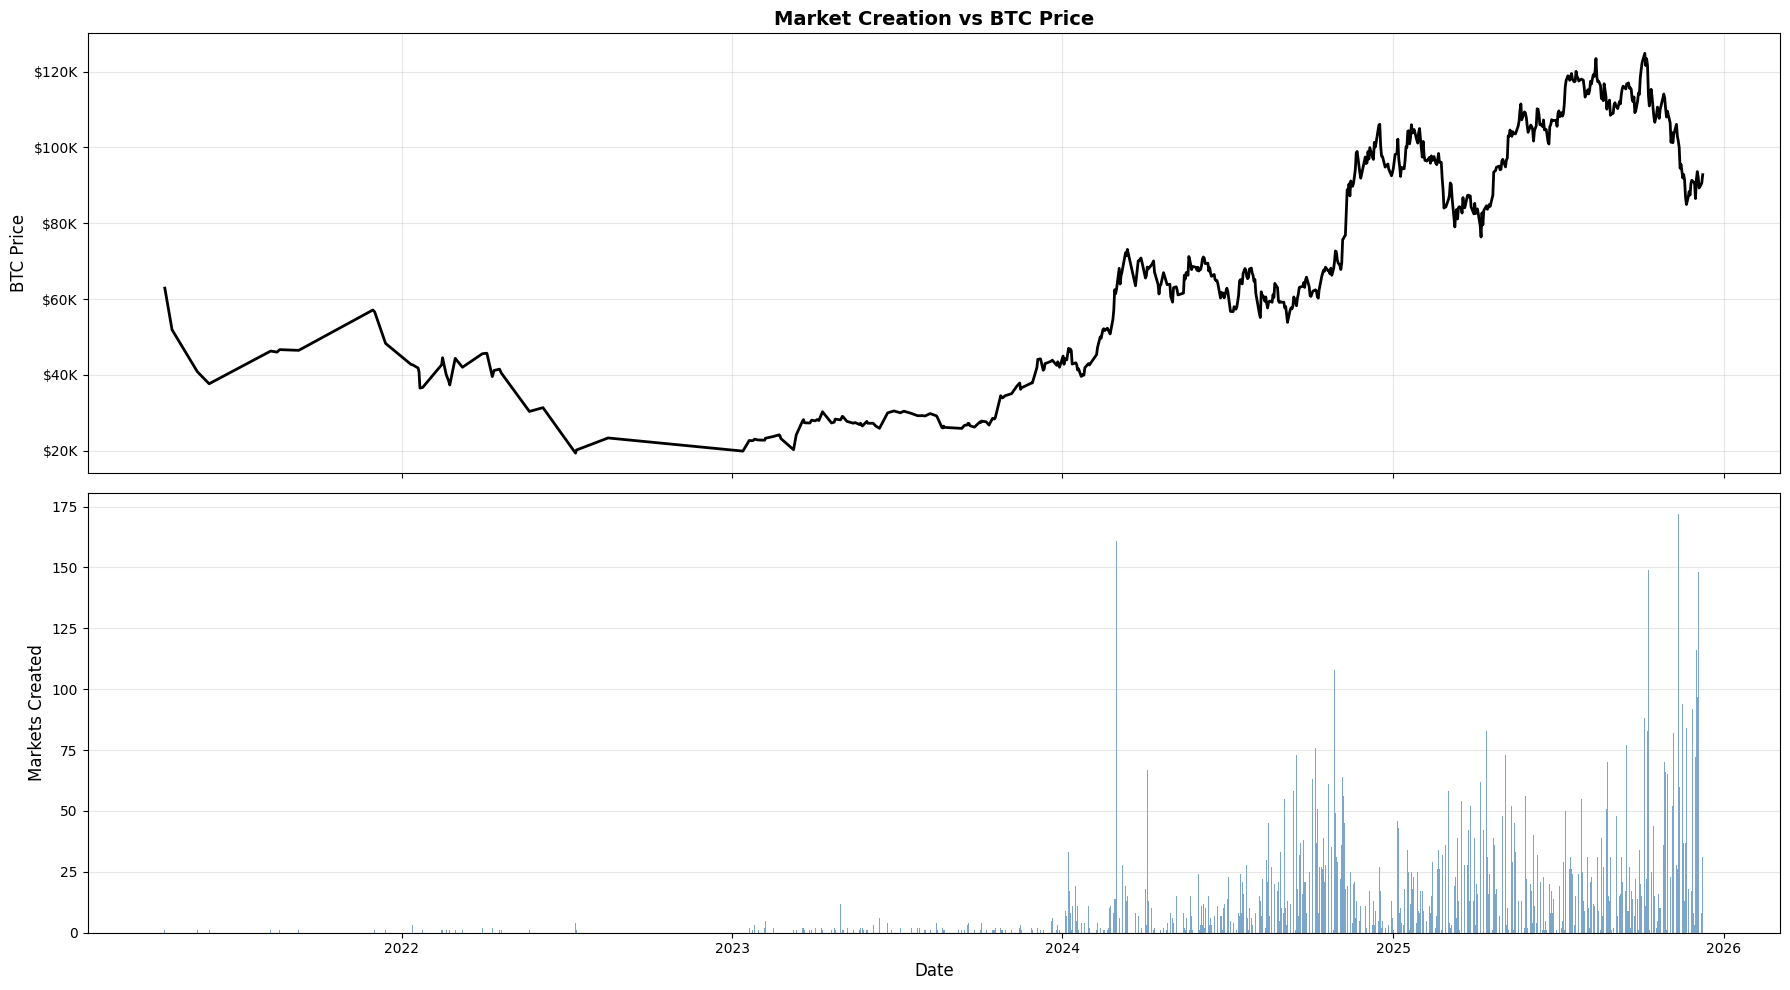

In [16]:
# Source: 0. eda_polymarket_politics.ipynb, cell 16
# Daily aggregation - FILTER OUT ZEROS
daily_markets = poly_market_btc.groupby('created_date').agg({
    'market_id': 'count',
    'btc_price': 'mean'
}).reset_index()

daily_markets.columns = ['date', 'num_markets', 'btc_price']
daily_markets = daily_markets[daily_markets['num_markets'] > 0]  # REMOVE ZEROS

# Calculate BTC change
daily_markets['btc_pct_change'] = daily_markets['btc_price'].pct_change() * 100
daily_markets = daily_markets.dropna()  # REMOVE NaN

# Correlation
if len(daily_markets) > 10:
    corr_creation, pval_creation = pearsonr(
        daily_markets['num_markets'], 
        daily_markets['btc_pct_change']
    )
    
    print("\n" + "="*80)
    print("MARKET CREATION vs BTC PRICE CHANGE")
    print("="*80)
    print(f"Correlation: {corr_creation:.4f}")
    print(f"P-value: {pval_creation:.4f}")
    print(f"Sample size: {len(daily_markets)}")
    
    # Plot
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 10), sharex=True)
    
    # BTC Price
    ax1.plot(pd.to_datetime(daily_markets['date']), daily_markets['btc_price'],
             color='black', linewidth=2)
    ax1.set_ylabel('BTC Price', fontsize=12)
    ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))
    ax1.grid(alpha=0.3)
    ax1.set_title('Market Creation vs BTC Price', fontsize=14, fontweight='bold')
    
    # Markets created
    ax2.bar(pd.to_datetime(daily_markets['date']), daily_markets['num_markets'],
            color='steelblue', alpha=0.7)
    ax2.set_ylabel('Markets Created', fontsize=12)
    ax2.set_xlabel('Date', fontsize=12)
    ax2.grid(alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig('market_creation_analysis.png', dpi=300)
    plt.show()



MONTHLY SUMMARY
         date  num_markets  total_volume      btc_price
41 2025-03-01          586  2.560865e+08   84873.511801
42 2025-04-01          627  5.152724e+08   85639.260015
43 2025-05-01          582  2.124013e+08  102899.980452
44 2025-06-01          386  9.406946e+07  105764.903154
45 2025-07-01          572  6.548924e+08  115568.154570
46 2025-08-01          488  2.866547e+07  113908.291130
47 2025-09-01          548  4.917924e+07  113404.282381
48 2025-10-01          874  3.193384e+07  114848.864490
49 2025-11-01         1348  3.886526e+07   95307.871140
50 2025-12-01          561  3.169436e+06   91133.646141


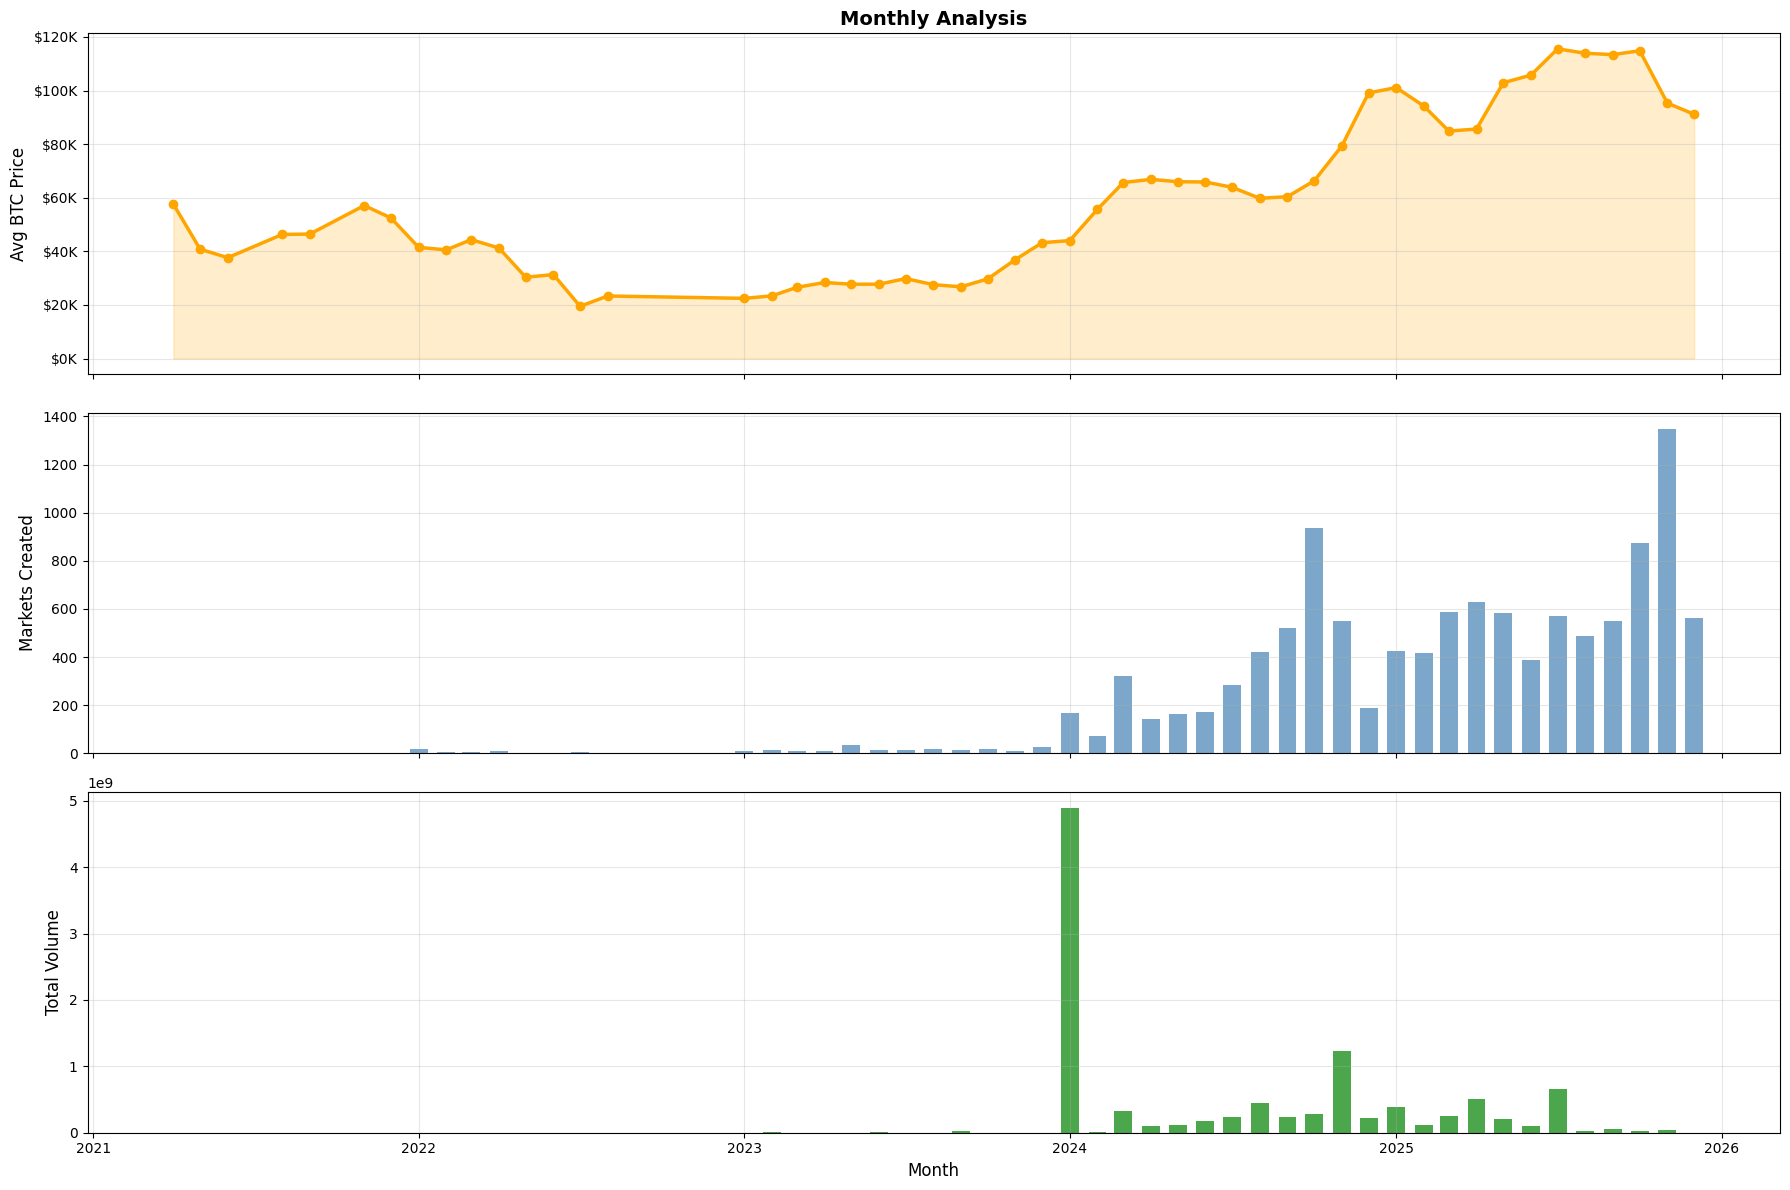

In [17]:
# Source: 0. eda_polymarket_politics.ipynb, cell 17
# Monthly aggregation
poly_market_btc['year_month'] = pd.to_datetime(poly_market_btc['created_at']).dt.to_period('M').dt.to_timestamp()

monthly_markets = poly_market_btc.groupby('year_month').agg({
    'market_id': 'count',
    'volume': 'sum',
    'btc_price': 'mean'
}).reset_index()

monthly_markets.columns = ['date', 'num_markets', 'total_volume', 'btc_price']
monthly_markets = monthly_markets[monthly_markets['num_markets'] > 0]  # Remove zeros

print("\n" + "="*80)
print("MONTHLY SUMMARY")
print("="*80)
print(monthly_markets[['date', 'num_markets', 'total_volume', 'btc_price']].tail(10))

# Plot
fig, axes = plt.subplots(3, 1, figsize=(18, 12), sharex=True)

# BTC Price
axes[0].plot(monthly_markets['date'], monthly_markets['btc_price'],
             marker='o', linewidth=2.5, markersize=6, color='orange')
axes[0].fill_between(monthly_markets['date'], monthly_markets['btc_price'],
                     alpha=0.2, color='orange')
axes[0].set_ylabel('Avg BTC Price', fontsize=12)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))
axes[0].grid(alpha=0.3)
axes[0].set_title('Monthly Analysis', fontsize=14, fontweight='bold')

# Markets created
axes[1].bar(monthly_markets['date'], monthly_markets['num_markets'],
            width=20, color='steelblue', alpha=0.7)
axes[1].set_ylabel('Markets Created', fontsize=12)
axes[1].grid(alpha=0.3)

# Volume
axes[2].bar(monthly_markets['date'], monthly_markets['total_volume'],
            width=20, color='green', alpha=0.7)
axes[2].set_ylabel('Total Volume', fontsize=12)
axes[2].set_xlabel('Month', fontsize=12)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('monthly_analysis.png', dpi=300)
plt.show()


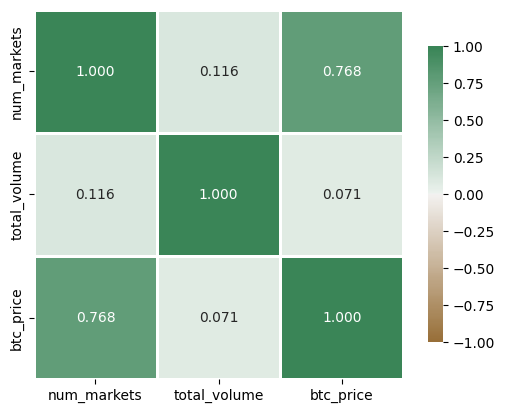

In [18]:
# Source: 0. eda_polymarket_politics.ipynb, cell 18
correlation_monthly_markets = monthly_markets[['num_markets', 'total_volume', 'btc_price']].corr()

axis_corr = sns.heatmap(
correlation_monthly_markets,
vmin=-1, vmax=1, center=0,
cmap=sns.diverging_palette(50, 500, n=500),
square=True,
annot=True,
fmt='.3f',               
linewidths=2,            
cbar_kws={"shrink": 0.8} 
)

plt.show()



TOP 20 MARKETS BY VOLUME
                                                                   question       volume          created_at
                   Will Donald Trump win the 2024 US Presidential Election? 1.531479e+09 2024-01-04 17:33:51
                  Will Kamala Harris win the 2024 US Presidential Election? 1.037039e+09 2024-01-04 17:40:17
                                          Will Donald Trump be inaugurated? 4.004095e+08 2024-11-01 20:59:58
            Will Nicolae Ciucă win the 2024 Romanian Presidential election? 3.265077e+08 2024-11-07 23:53:29
Will any other Republican Politician win the 2024 US Presidential Election? 2.416551e+08 2024-01-06 19:52:35
                                       Kamala Harris wins the popular vote? 1.637798e+08 2024-01-09 18:29:49
                 Will Michelle Obama win the 2024 US Presidential Election? 1.533823e+08 2024-01-05 20:53:17
                     Will Zohran Mamdani win the 2025 NYC mayoral election? 1.432549e+08 2025-04-22 15

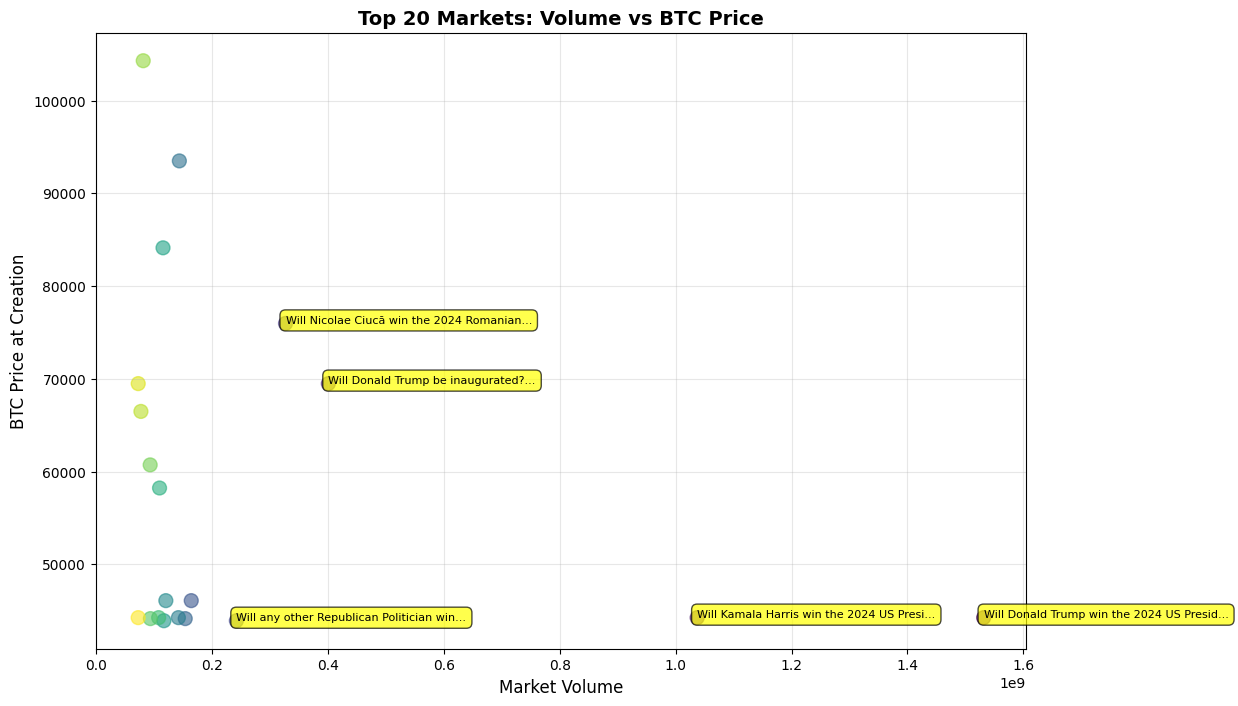

In [19]:
# Source: 0. eda_polymarket_politics.ipynb, cell 19
# Top volume markets
top_volume = poly_market_btc.nlargest(20, 'volume')

print("\n" + "="*80)
print("TOP 20 MARKETS BY VOLUME")
print("="*80)
print(top_volume[['question', 'volume', 'created_at']].to_string(index=False))

# Scatter: Volume vs BTC price at creation
fig, ax = plt.subplots(figsize=(12, 8))

scatter = ax.scatter(top_volume['volume'], top_volume['btc_price'],
                    s=100, alpha=0.6, c=range(len(top_volume)),
                    cmap='viridis')

# Label top 5
for idx, row in top_volume.head(5).iterrows():
    ax.annotate(row['question'][:40] + '...', 
               xy=(row['volume'], row['btc_price']),
               fontsize=8,
               bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7))

ax.set_xlabel('Market Volume', fontsize=12)
ax.set_ylabel('BTC Price at Creation', fontsize=12)
ax.set_title('Top 20 Markets: Volume vs BTC Price', fontsize=14, fontweight='bold')
ax.grid(alpha=0.3)



CAUSALITY ANALYSIS
Optimal lag: -27.0 days
Correlation: -0.0897
P-value: 0.0247

 Market creation LEADS BTC price by 27.0 days
   (More markets created  BTC price moves later)


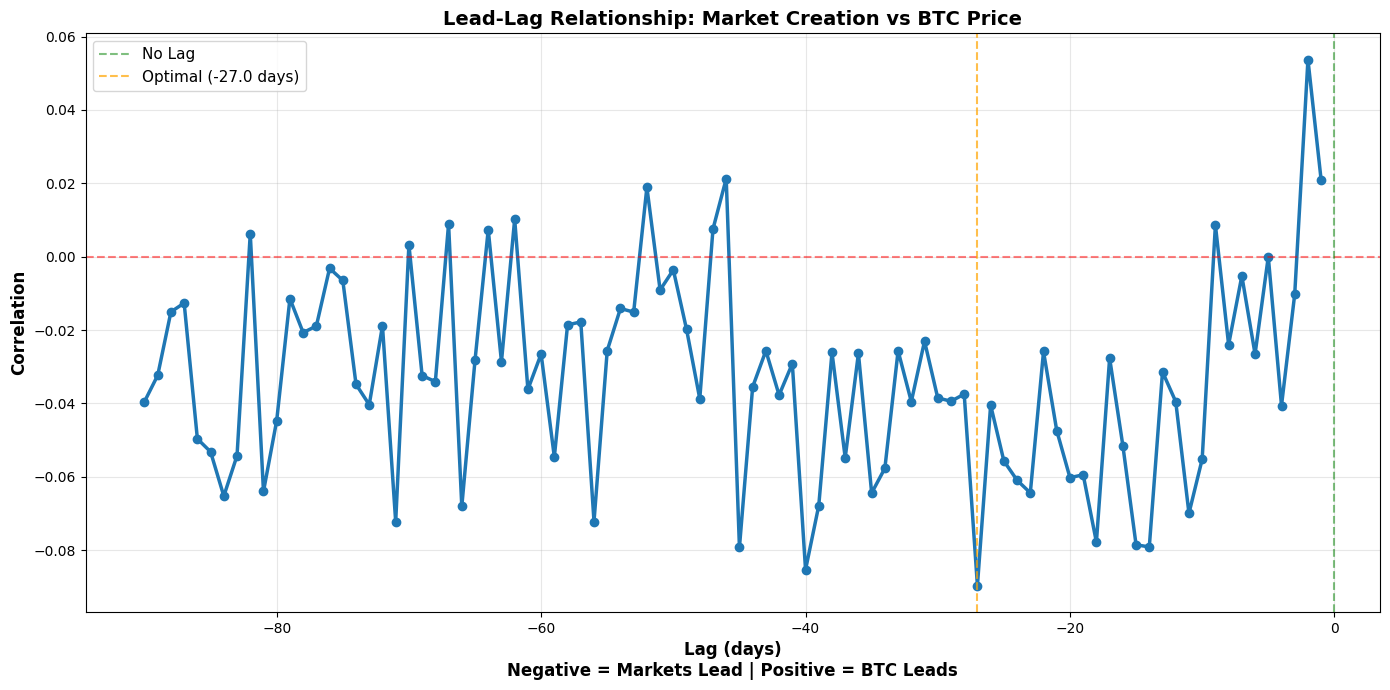

In [20]:
# Source: 0. eda_polymarket_politics.ipynb, cell 20
from scipy.stats import pearsonr
import numpy as np

# ============================================================================
# GRANGER CAUSALITY TEST
# ============================================================================

print("\n" + "="*80)
print("CAUSALITY ANALYSIS")
print("="*80)

# Prepare daily data
daily_for_causality = pd.merge(
    daily_markets[['date', 'num_markets']],
    btc_daily_simple[['date', 'btc_price', 'btc_pct_change']],
    on='date',
    how='inner'
).sort_values('date')

# Remove zeros
daily_for_causality = daily_for_causality[daily_for_causality['num_markets'] > 0]

# Test different lags
max_lag = 90
lag_results = []

for lag in range(-max_lag, 0):
    df_temp = daily_for_causality.copy()
    
    if lag != 0:
        df_temp['markets_lagged'] = df_temp['num_markets'].shift(lag)
        clean = df_temp[['markets_lagged', 'btc_pct_change']].dropna()
        
        if len(clean) > 10:
            corr, pval = pearsonr(clean['markets_lagged'], clean['btc_pct_change'])
            lag_results.append({
                'lag': lag,
                'correlation': corr,
                'pvalue': pval
            })

if lag_results:
    lag_df = pd.DataFrame(lag_results)
    optimal = lag_df.loc[lag_df['correlation'].abs().idxmax()]
    
    print(f"Optimal lag: {optimal['lag']} days")
    print(f"Correlation: {optimal['correlation']:.4f}")
    print(f"P-value: {optimal['pvalue']:.4f}")
    
    if optimal['lag'] < 0:
        print(f"\n Market creation LEADS BTC price by {abs(optimal['lag'])} days")
        print(f"   (More markets created  BTC price moves later)")
    elif optimal['lag'] > 0:
        print(f"\n BTC price LEADS market creation by {optimal['lag']} days")
        print(f"   (BTC price moves  More markets created later)")
    else:
        print(f"\n SIMULTANEOUS movement")
    
    # Plot lag correlation
    plt.figure(figsize=(14, 7))
    
    plt.plot(lag_df['lag'], lag_df['correlation'],
             marker='o', linewidth=2.5, markersize=6)
    plt.axhline(0, color='red', linestyle='--', alpha=0.5)
    plt.axvline(0, color='green', linestyle='--', alpha=0.5, label='No Lag')
    plt.axvline(optimal['lag'], color='orange', linestyle='--', alpha=0.7,
               label=f'Optimal ({optimal["lag"]} days)')
    
    plt.xlabel('Lag (days)\nNegative = Markets Lead | Positive = BTC Leads',
              fontsize=12, fontweight='bold')
    plt.ylabel('Correlation', fontsize=12, fontweight='bold')
    plt.title('Lead-Lag Relationship: Market Creation vs BTC Price',
             fontsize=14, fontweight='bold')
    plt.legend(fontsize=11)
    plt.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('lead_lag_analysis.png', dpi=300)
    plt.show()



MARKET CREATION SPIKES
Spike days: 56
Normal days: 598

Avg BTC price on spike days: $75,482
Avg BTC price on normal days: $74,704

Top 10 spike days:
      date  num_markets     btc_price  btc_pct_change
2025-11-12          172 101682.126653       -1.254952
2024-03-01          161  62524.401817        1.839928
2025-10-10          149 113754.852328       -6.454166
2025-11-25          144  87434.550611       -1.067071
2024-10-28          108  69862.520547        2.738778
2025-11-17           94  91911.471347       -3.799241
2025-10-06           88 124824.453667        2.024000
2025-04-14           83  84589.032414        1.474489
2025-09-16           77 116798.867051        1.193835
2025-05-09           75 102940.802949       -0.124902


Example markets created on spike days:
      date                                                                    question       volume
2024-09-16                Will the Democratic candidate win Pennsylvania by 1.5%-2.0%? 1.090638e+08
2024-01-08   

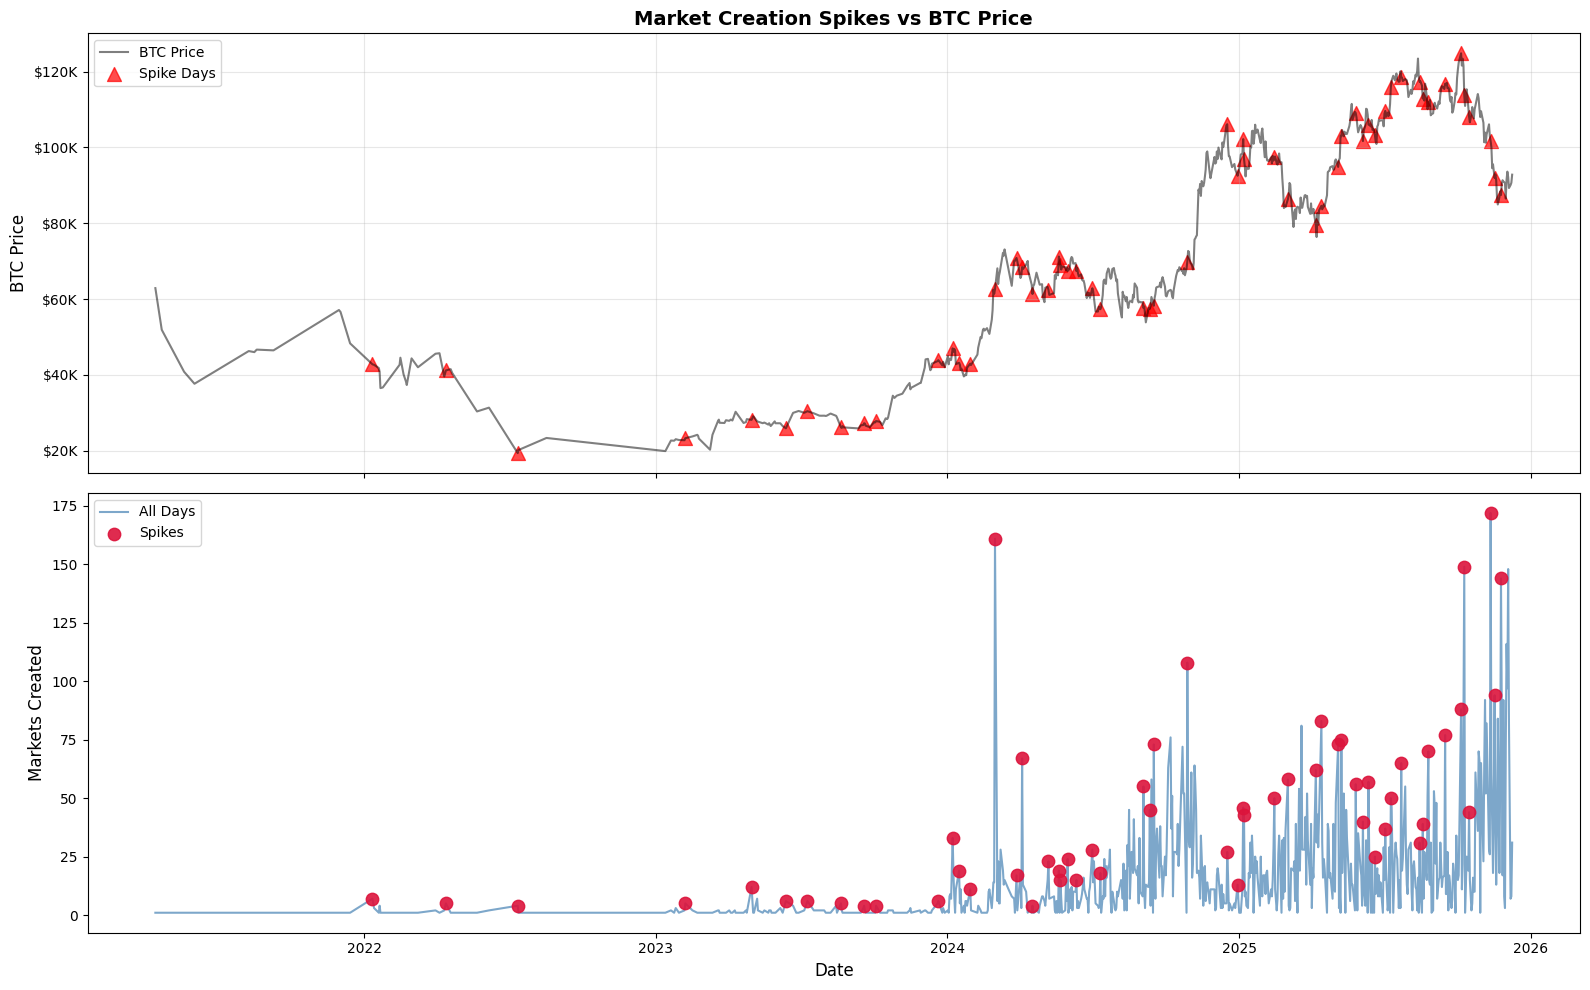

In [21]:
# Source: 0. eda_polymarket_politics.ipynb, cell 21
# ============================================================================
# MARKET CREATION SPIKES
# ============================================================================

# Calculate 7-day moving average
daily_sorted = daily_markets.sort_values('date').copy()
daily_sorted['market_rolling_avg'] = (
    daily_sorted['num_markets'].rolling(window=7, center=True).mean()
)

# Define spike as >2x average
daily_sorted['is_spike'] = (
    daily_sorted['num_markets'] > 2 * daily_sorted['market_rolling_avg']
)

spike_days = daily_sorted[daily_sorted['is_spike']].copy()
normal_days = daily_sorted[~daily_sorted['is_spike']].copy()

print("\n" + "="*80)
print("MARKET CREATION SPIKES")
print("="*80)
print(f"Spike days: {len(spike_days)}")
print(f"Normal days: {len(normal_days)}")

if len(spike_days) > 5:
    print(f"\nAvg BTC price on spike days: ${spike_days['btc_price'].mean():,.0f}")
    print(f"Avg BTC price on normal days: ${normal_days['btc_price'].mean():,.0f}")
    
    print(f"\nTop 10 spike days:")
    spike_top = spike_days.nlargest(10, 'num_markets')[
        ['date', 'num_markets', 'btc_price', 'btc_pct_change']
    ]
    print(spike_top.to_string(index=False))
    
    # Merge with market data to see which markets
    spike_markets = pd.merge(
        spike_days[['date']],
        poly_market_btc[['created_date', 'question', 'volume']],
        left_on='date',
        right_on='created_date',
        how='left'
    )
    
    print(f"\n\nExample markets created on spike days:")
    print(spike_markets.nlargest(10, 'volume')[['date', 'question', 'volume']].to_string(index=False))
    
    # Plot
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), sharex=True)
    
    # BTC Price with spike markers
    ax1.plot(pd.to_datetime(daily_sorted['date']), daily_sorted['btc_price'],
             color='black', linewidth=1.5, alpha=0.5, label='BTC Price')
    ax1.scatter(pd.to_datetime(spike_days['date']), spike_days['btc_price'],
               color='red', s=100, alpha=0.7, marker='^', label='Spike Days')
    ax1.set_ylabel('BTC Price', fontsize=12)
    ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))
    ax1.legend()
    ax1.grid(alpha=0.3)
    ax1.set_title('Market Creation Spikes vs BTC Price', fontsize=14, fontweight='bold')
    
    # Market creation with spikes highlighted
    ax2.plot(pd.to_datetime(daily_sorted['date']), daily_sorted['num_markets'],
         color='steelblue', linewidth=1.5, alpha=0.7, label='All Days')
    ax2.scatter(pd.to_datetime(spike_days['date']), spike_days['num_markets'],
           color='crimson', s=80, alpha=0.9, marker='o', label='Spikes', zorder=5)
    ax2.set_ylabel('Markets Created', fontsize=12)
    ax2.set_xlabel('Date', fontsize=12)
    ax2.legend()
    
    
    plt.tight_layout()
    plt.savefig('market_creation_spikes.png', dpi=300)
    plt.show()



MARKET CREATION BY BTC PRICE RANGE
BTC Price Range  Num Markets   Avg Volume  Avg BTC Price
          <$50K          418 1.183226e+07   37075.018502
      $50K-$75K         3202 7.708307e+05   64137.486382
     $75K-$100K         3709 5.054662e+05   89048.573296
    $100K-$150K         4274 3.290295e+05  110101.112460
         >$150K            0          NaN            NaN


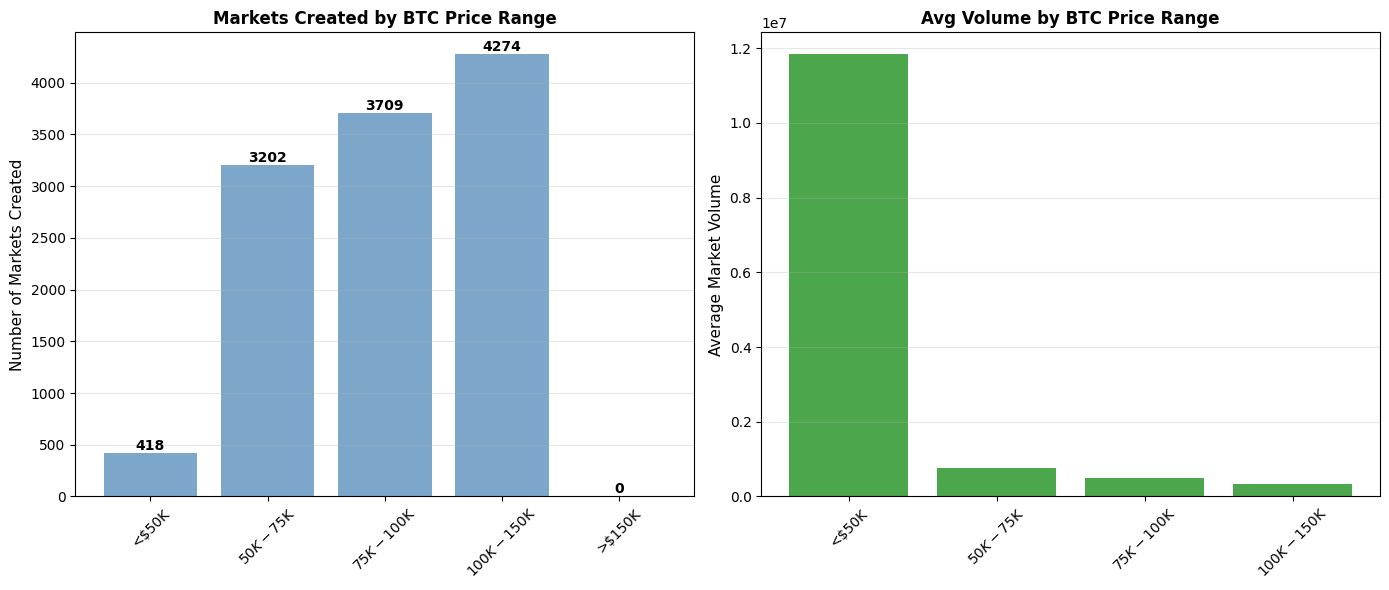

In [22]:
# Source: 0. eda_polymarket_politics.ipynb, cell 22
# ============================================================================
# MARKET CREATION BY BTC PRICE RANGE
# ============================================================================

# Create BTC price buckets
poly_market_btc['btc_bucket'] = pd.cut(
    poly_market_btc['btc_price'],
    bins=[0, 50000, 75000, 100000, 150000, 1000000],
    labels=['<$50K', '$50K-$75K', '$75K-$100K', '$100K-$150K', '>$150K']
)

bucket_analysis = poly_market_btc.groupby('btc_bucket').agg({
    'market_id': 'count',
    'volume': 'mean',
    'btc_price': 'mean'
}).reset_index()

bucket_analysis.columns = ['BTC Price Range', 'Num Markets', 
                          'Avg Volume', 'Avg BTC Price']

print("\n" + "="*80)
print("MARKET CREATION BY BTC PRICE RANGE")
print("="*80)
print(bucket_analysis.to_string(index=False))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Number of markets by bucket
axes[0].bar(bucket_analysis['BTC Price Range'], 
           bucket_analysis['Num Markets'],
           color='steelblue', alpha=0.7)
axes[0].set_ylabel('Number of Markets Created', fontsize=11)
axes[0].set_title('Markets Created by BTC Price Range', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(alpha=0.3, axis='y')

# Add value labels
for i, (idx, row) in enumerate(bucket_analysis.iterrows()):
    axes[0].text(i, row['Num Markets'], f"{row['Num Markets']:.0f}",
                ha='center', va='bottom', fontweight='bold')

# Average volume by bucket
axes[1].bar(bucket_analysis['BTC Price Range'], 
           bucket_analysis['Avg Volume'],
           color='green', alpha=0.7)
axes[1].set_ylabel('Average Market Volume', fontsize=11)
axes[1].set_title('Avg Volume by BTC Price Range', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('btc_bucket_analysis.png', dpi=300)
plt.show()



YEARLY ANALYSIS
 Year  Num Markets  Total Volume  Avg BTC Price
 2021           12  5.612005e+05   49880.063607
 2022           45  2.308201e+06   38039.442890
 2023          191  5.164505e+07   30053.906240
 2024         3938  8.265094e+09   66826.307596
 2025         7417  2.375524e+09  101187.309025


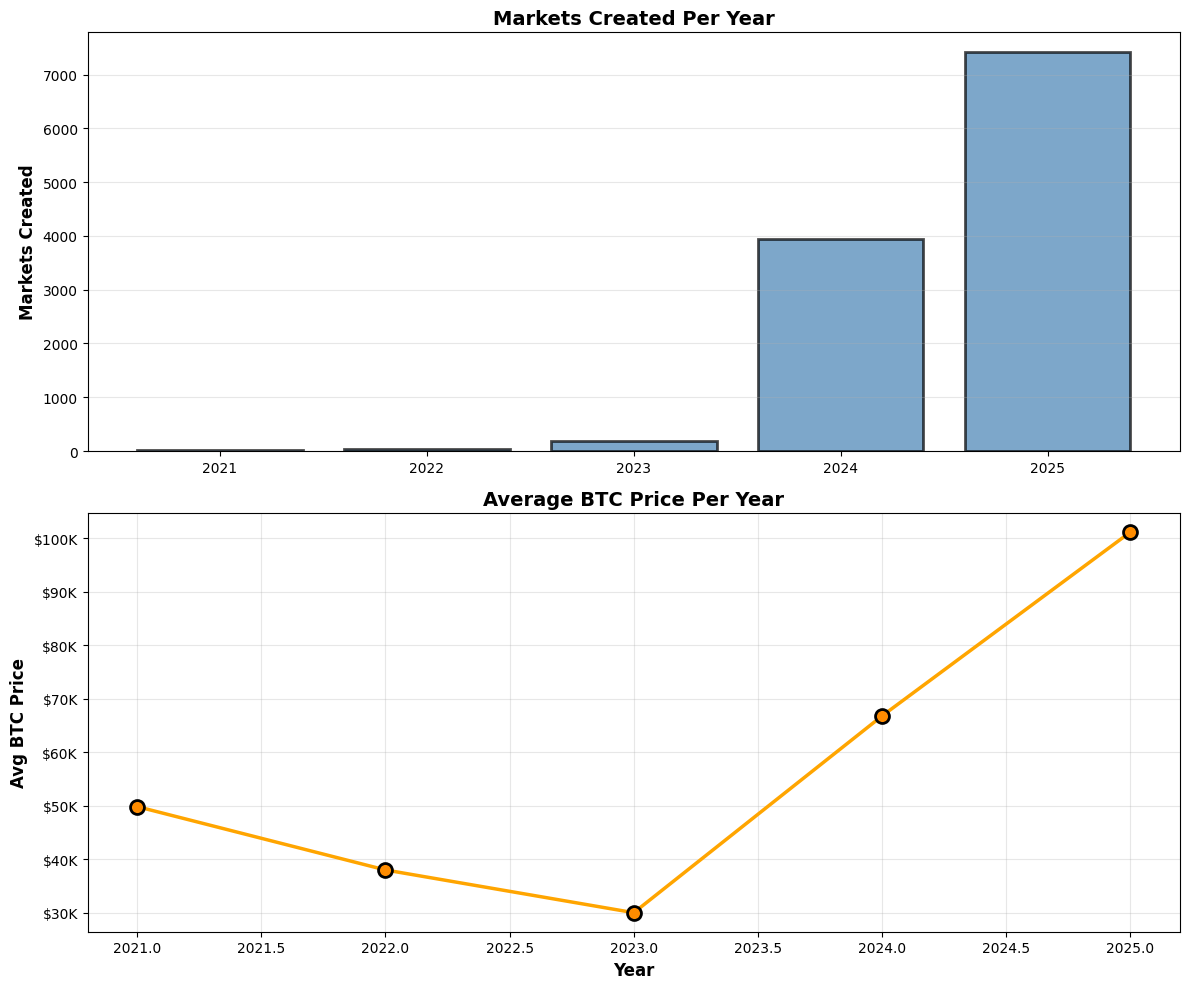


QUARTERLY ANALYSIS
Quarter  Num Markets  Total Volume  Avg BTC Price
 2021Q2            5  3.789953e+05   50248.435155
 2021Q3            4  1.594617e+05   46336.499674
 2021Q4            3  2.274351e+04   53990.862938
 2022Q1           26  1.414916e+06   41747.507223
 2022Q2           13  6.582403e+05   38883.942432
 2022Q3            6  2.350453e+05   20141.415111
 2023Q1           29  8.819557e+06   24111.694114
 2023Q2           61  8.477414e+06   27846.440517
 2023Q3           47  2.645434e+07   28098.469942
 2023Q4           54  7.893739e+06   37440.666737
 2024Q1          562  5.223139e+09   57918.131856
 2024Q2          479  3.921653e+08   66206.697713
 2024Q3         1224  9.255880e+08   61003.066429
 2024Q4         1673  1.724202e+09   74256.573638
 2025Q1         1431  7.470749e+08   92439.373302
 2025Q2         1595  8.217431e+08   96808.060984
 2025Q3         1608  7.327371e+08  114326.975890
 2025Q4         2783  7.396854e+07  100603.267462


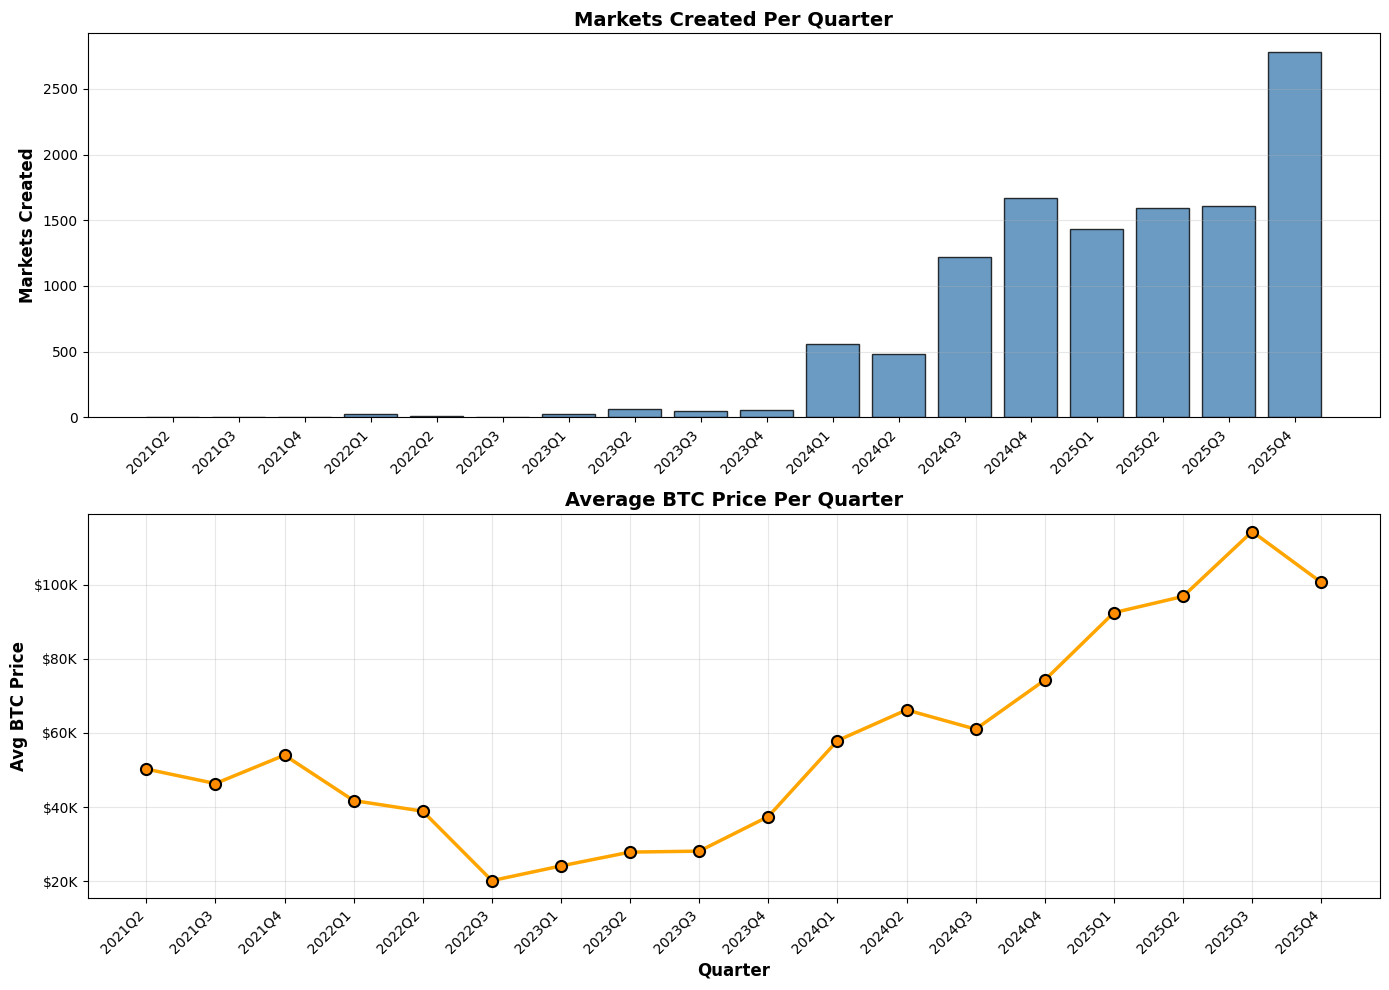

In [23]:
# Source: 0. eda_polymarket_politics.ipynb, cell 23
# ============================================================================
# YEARLY/QUARTERLY BREAKDOWN
# ============================================================================

# Add time periods
poly_market_btc['year'] = pd.to_datetime(poly_market_btc['created_at']).dt.year
poly_market_btc['quarter'] = pd.to_datetime(poly_market_btc['created_at']).dt.to_period('Q')

# Yearly analysis
yearly = poly_market_btc.groupby('year').agg({
    'market_id': 'count',
    'volume': 'sum',
    'btc_price': 'mean'
}).reset_index()

yearly.columns = ['Year', 'Num Markets', 'Total Volume', 'Avg BTC Price']

print("\n" + "="*80)
print("YEARLY ANALYSIS")
print("="*80)
print(yearly.to_string(index=False))

# Plot
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Markets per year
axes[0].bar(yearly['Year'], yearly['Num Markets'],
           color='steelblue', alpha=0.7, edgecolor='black', linewidth=2)
axes[0].set_ylabel('Markets Created', fontsize=12, fontweight='bold')
axes[0].set_title('Markets Created Per Year', fontsize=14, fontweight='bold')
axes[0].grid(alpha=0.3, axis='y')

# BTC price per year
axes[1].plot(yearly['Year'], yearly['Avg BTC Price'],
            marker='o', linewidth=2.5, markersize=10, color='orange',
            markerfacecolor='darkorange', markeredgecolor='black', markeredgewidth=2)
axes[1].set_ylabel('Avg BTC Price', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Year', fontsize=12, fontweight='bold')
axes[1].set_title('Average BTC Price Per Year', fontsize=14, fontweight='bold')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('yearly_analysis.png', dpi=300)
plt.show()

# Quarterly analysis
quarterly = poly_market_btc.groupby('quarter').agg({
    'market_id': 'count',
    'volume': 'sum',
    'btc_price': 'mean'
}).reset_index()
quarterly.columns = ['Quarter', 'Num Markets', 'Total Volume', 'Avg BTC Price']

# Convert quarter back to string for display
quarterly['Quarter'] = quarterly['Quarter'].astype(str)

print("\n" + "="*80)
print("QUARTERLY ANALYSIS")
print("="*80)
print(quarterly.to_string(index=False))

# Plot quarterly
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Markets per quarter
axes[0].bar(range(len(quarterly)), quarterly['Num Markets'],
           color='steelblue', alpha=0.8, edgecolor='black', linewidth=1)
axes[0].set_xticks(range(len(quarterly)))
axes[0].set_xticklabels(quarterly['Quarter'], rotation=45, ha='right')
axes[0].set_ylabel('Markets Created', fontsize=12, fontweight='bold')
axes[0].set_title('Markets Created Per Quarter', fontsize=14, fontweight='bold')
axes[0].grid(alpha=0.3, axis='y')

# BTC price per quarter
axes[1].plot(range(len(quarterly)), quarterly['Avg BTC Price'],
            marker='o', linewidth=2.5, markersize=8, color='orange',
            markerfacecolor='darkorange', markeredgecolor='black', markeredgewidth=1.5)
axes[1].set_xticks(range(len(quarterly)))
axes[1].set_xticklabels(quarterly['Quarter'], rotation=45, ha='right')
axes[1].set_ylabel('Avg BTC Price', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Quarter', fontsize=12, fontweight='bold')
axes[1].set_title('Average BTC Price Per Quarter', fontsize=14, fontweight='bold')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('quarterly_analysis.png', dpi=300)
plt.show()


In [24]:
# Source: 0. eda_polymarket_politics.ipynb, cell 24
# ============================================================================
# BTC PRICE THRESHOLD ANALYSIS
# ============================================================================

# Compare market activity above/below different BTC price thresholds
thresholds = [25000, 50000, 75000, 100000]

threshold_results = []

for threshold in thresholds:
    above = poly_market_btc[poly_market_btc['btc_price'] > threshold]
    below = poly_market_btc[poly_market_btc['btc_price'] <= threshold]
    
    threshold_results.append({
        'Threshold': f'${threshold/1000:.0f}K',
        'Markets Above': len(above),
        'Avg Volume Above': above['volume'].mean(),
        'Markets Below': len(below),
        'Avg Volume Below': below['volume'].mean(),
        'Ratio (Above/Below)': len(above) / max(len(below), 1)
    })

threshold_df = pd.DataFrame(threshold_results)

print("\n" + "="*80)
print("THRESHOLD ANALYSIS")
print("="*80)
print(threshold_df.round(2).to_string(index=False))

# Interpretation
print("\n\nInterpretation:")
for idx, row in threshold_df.iterrows():
    if row['Ratio (Above/Below)'] > 1.2:
        print(f"   MORE markets created when BTC > {row['Threshold']}")
    elif row['Ratio (Above/Below)'] < 0.8:
        print(f"   FEWER markets created when BTC > {row['Threshold']}")
    else:
        print(f"   SIMILAR market creation above/below {row['Threshold']}")



THRESHOLD ANALYSIS
Threshold  Markets Above  Avg Volume Above  Markets Below  Avg Volume Below  Ratio (Above/Below)
     $25K          11575         923233.63             28         310824.53               413.39
     $50K          11185         514013.96            418       11832263.71                26.76
     $75K           7983         411004.17           3620        2048090.09                 2.21
    $100K           4274         329029.53           7329        1267411.68                 0.58


Interpretation:
   MORE markets created when BTC > $25K
   MORE markets created when BTC > $50K
   MORE markets created when BTC > $75K
   FEWER markets created when BTC > $100K


### 2. Correlation between btc price and polymarket in politics
    - trade and token relationship


In [25]:
# Source: 0. eda_polymarket_politics.ipynb, cell 26
display(poly_tokens_politics_clean)


,market_id,token_id,outcome,question
0,240584,3947506494278365205368124689314753252429356373...,Yes,Will Valerie Pecresse win the 2022 French pres...
1,240584,5480256031258914272992158751092692872415626042...,No,Will Valerie Pecresse win the 2022 French pres...
2,240585,6573979316199210406752160392925785635050728828...,Yes,Will Marine Le Pen win the 2022 French preside...
3,240585,7502204389681087970191750614658257994613608356...,No,Will Marine Le Pen win the 2022 French preside...
4,240586,8923537341582753820147490806696122485377828323...,Yes,Will Eric Zemmour win the 2022 French presiden...
...,...,...,...,...
23199,546471,2951804949752556684718002886863045466219610283...,No,Will Siaosi Pōhiva be the next Prime Minister ...
23200,647130,1128619987238474361624505653836002273782742354...,Yes,"Will Reddit say ""Election"" during earnings call?"
23201,647130,6574503765138757589285792212666135796745670688...,No,"Will Reddit say ""Election"" during earnings call?"
23202,647475,8323473105963719224529843098951742049294706270...,Yes,"Will anyone say ""Trump"" during the FED board m..."


In [26]:
if poly_trades_politics_clean.empty:
    trade_token_merge = pd.DataFrame(
        columns=['market_id','token_id','timestamp','price','size','side','question','outcome','date','btc_price','btc_pct_change']
    )
    print('Trade-level politics flow unavailable because LOAD_TRADES=False.')
else:
    # Fix 1: parse timestamp as milliseconds (same as original notebook)
    trade_token_merge = poly_trades_politics_clean.merge(
        poly_tokens_politics_clean[['token_id', 'outcome']],
        on='token_id', how='left'
    )

    trade_token_merge['date'] = pd.to_datetime(
        trade_token_merge['timestamp'].astype('int64'), unit='ms'
    ).dt.normalize()

    # Sanity check — should show 2020–2025 range, not 1970
    print("Date range:", trade_token_merge['date'].min(), "→", trade_token_merge['date'].max())

    # Fix 2: build btc_daily with datetime index to match
    btc_daily = (
        btc_pd[['time', 'PriceUSD']]
        .copy()
        .assign(time=lambda d: pd.to_datetime(d['time']).dt.normalize())
        .groupby('time')['PriceUSD'].mean()
        .reset_index()
        .rename(columns={'time': 'date', 'PriceUSD': 'btc_price'})
    )
    btc_daily['btc_pct_change'] = btc_daily['btc_price'].pct_change() * 100

    # Fix 3: merge on normalized datetime — both sides now datetime64, not mixed types
    trade_token_merge = trade_token_merge.merge(btc_daily, on='date', how='left')

    print(f"Rows: {len(trade_token_merge):,}")
    print(f"BTC price matched: {trade_token_merge['btc_price'].notna().sum():,} / {len(trade_token_merge):,}")
    display(trade_token_merge.head())


Trade-level politics flow unavailable because LOAD_TRADES=False.


In [27]:
# Build side/outcome flow tables.
if trade_token_merge.empty:
    trade_token_merge_btc = pd.DataFrame()
    trade_token_merge_btc_clean = pd.DataFrame()
    daily_buysell = pd.DataFrame()
    buysell_pivot = pd.DataFrame(columns=['question', 'BUY_No', 'BUY_Yes', 'SELL_No', 'SELL_Yes', 'NET_No', 'NET_Yes', 'btc_price'])
    print('Trade-level buy/sell pivot not built because trade data is unavailable.')
else:
    trade_token_merge['dollar_value'] = pd.to_numeric(trade_token_merge['price'], errors='coerce') * pd.to_numeric(trade_token_merge['size'], errors='coerce')
    trade_token_merge['trade_date'] = pd.to_datetime(trade_token_merge['timestamp'], errors='coerce').dt.date
    trade_token_merge_btc_clean = trade_token_merge[trade_token_merge['outcome'].isin(['Yes', 'No'])].copy()
    daily_buysell = trade_token_merge_btc_clean.groupby(['side', 'question', 'outcome']).agg(dollar_value=('dollar_value', 'sum'), size=('size', 'sum'), token_id=('token_id', 'nunique'), btc_price=('btc_price', 'mean')).reset_index()
    daily_buysell['side_outcome'] = daily_buysell['side'] + '_' + daily_buysell['outcome']
    buysell_pivot = daily_buysell.pivot(index='question', columns='side_outcome', values='dollar_value').fillna(0).reset_index()
    for col in ['BUY_No', 'BUY_Yes', 'SELL_No', 'SELL_Yes']:
        if col not in buysell_pivot.columns:
            buysell_pivot[col] = 0
    buysell_pivot['NET_No'] = buysell_pivot['BUY_No'] - buysell_pivot['SELL_No']
    buysell_pivot['NET_Yes'] = buysell_pivot['BUY_Yes'] - buysell_pivot['SELL_Yes']

btc_per_question = (
        trade_token_merge_btc_clean
        .groupby('question')['btc_price']
        .mean()
        .reset_index()
    )
buysell_pivot = buysell_pivot.merge(btc_per_question, on='question', how='left')

print(f"Pivot shape: {buysell_pivot.shape}")
print(f"BTC price matched: {buysell_pivot['btc_price'].notna().sum()} / {len(buysell_pivot)}")
display(buysell_pivot.head())

Trade-level buy/sell pivot not built because trade data is unavailable.


KeyError: 'question'

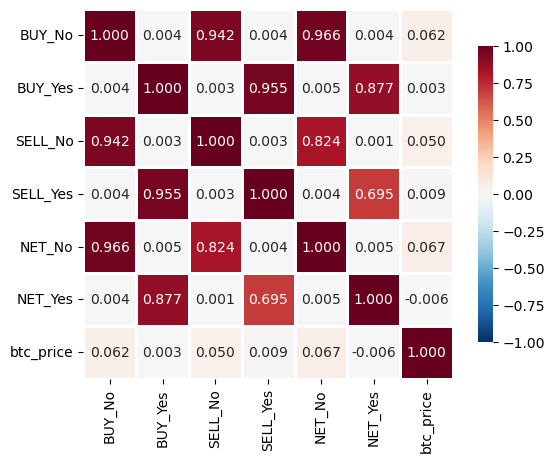

In [137]:
# Correlation heatmap for buy/sell pivot.
cols = ['BUY_No','BUY_Yes', 'SELL_No', 'SELL_Yes', 'NET_No', 'NET_Yes', 'btc_price']
if buysell_pivot.empty or buysell_pivot[cols].dropna(how='all').empty:
    print('No trade-level buy/sell correlation available.')
else:
    correlation_buysell_pivot = buysell_pivot[cols].corr()
    sns.heatmap(correlation_buysell_pivot, vmin=-1, vmax=1, center=0, cmap='RdBu_r', square=True, annot=True, fmt='.3f', linewidths=2, cbar_kws={'shrink': 0.8})
    plt.show()


In [147]:
# trade_token_merge_btc['btc_price'] = trade_token_merge_btc['btc_price_x']
trade_token_merge_btc = trade_token_merge_btc[['market_id', 'token_id', 'timestamp','price', 'size', 'side','question','outcome','date','btc_price','btc_pct_change','dollar_value']]

# Daily buy/sell time series.
if trade_token_merge_btc.empty:
    daily_pivot = pd.DataFrame(columns=['date', 'NET_No', 'NET_Yes', 'btc_price', 'btc_pct_change'])
    print('No trade-level daily pivot available.')
else:
    daily_buysell_time = trade_token_merge_btc.groupby(['date', 'side', 'outcome']).agg(dollar_value=('dollar_value', 'sum')).reset_index()
    daily_buysell_time['side_outcome'] = daily_buysell_time['side'] + '_' + daily_buysell_time['outcome']
    daily_pivot = daily_buysell_time.pivot(index='date', columns='side_outcome', values='dollar_value').fillna(0).reset_index()
    daily_pivot = daily_pivot.merge(btc_daily[['date', 'btc_price', 'btc_pct_change']], on='date', how='left').dropna(subset=['btc_price'])
    for col in ['BUY_No', 'BUY_Yes', 'SELL_No', 'SELL_Yes']:
        if col not in daily_pivot.columns:
            daily_pivot[col] = 0
    daily_pivot['NET_No'] = daily_pivot['BUY_No'] - daily_pivot['SELL_No']
    daily_pivot['NET_Yes'] = daily_pivot['BUY_Yes'] - daily_pivot['SELL_Yes']
    display(daily_pivot.head())


,date,BUY_BBB,BUY_Down,BUY_Fritz,BUY_Harris,BUY_Harris-Stowe Hornets,BUY_No,BUY_SP,BUY_Southeast Missouri State Redhawks,BUY_Topo,...,SELL_No,SELL_SP,SELL_Up,SELL_VVD,SELL_Vukic,SELL_Yes,btc_price,btc_pct_change,NET_No,NET_Yes
0,2025-04-07,0.0,0.0,0.0,0.0,0.0,142523.577339,0.0,0.0,0.0,...,106859.031879,0.0,0.0,0.0,0.0,71020.676189,79421.804411,1.889331,35664.545460,1.004718e+05
1,2025-04-08,0.0,0.0,0.0,0.0,0.0,321165.353981,0.0,0.0,0.0,...,294892.631336,0.0,0.0,0.0,0.0,148213.365271,76351.429530,-3.865909,26272.722645,1.748125e+05
2,2025-04-09,0.0,0.0,0.0,0.0,0.0,283085.225028,0.0,0.0,0.0,...,148293.279230,0.0,0.0,0.0,0.0,136291.118088,82720.603489,8.341918,134791.945798,1.113106e+06
3,2025-04-10,0.0,0.0,0.0,0.0,0.0,255992.009760,0.0,0.0,0.0,...,123396.303687,0.0,0.0,0.0,0.0,148639.427933,79558.955825,-3.822080,132595.706073,1.090917e+05
4,2025-04-11,0.0,0.0,0.0,0.0,0.0,245188.900580,0.0,0.0,0.0,...,130778.460560,0.0,0.0,0.0,0.0,73165.429823,83359.899516,4.777518,114410.440020,6.414206e+04


In [150]:
# Analyze day-over-day flow changes.
if daily_pivot.empty:
    daily_changes = pd.DataFrame(columns=['date', 'YES_NET_change', 'NO_NET_change', 'btc_pct_change'])
    print('No trade-level daily changes available.')
else:
    daily_changes = daily_pivot.sort_values('date').copy()
    daily_changes['YES_NET_change'] = daily_changes.get('NET_Yes', 0).replace(0, np.nan).pct_change() * 100
    daily_changes['NO_NET_change'] = daily_changes.get('NET_No', 0).replace(0, np.nan).pct_change() * 100
    daily_changes = daily_changes.replace([np.inf, -np.inf], np.nan)
    daily_changes = daily_changes[(daily_changes['YES_NET_change'].abs() < 500) & (daily_changes['NO_NET_change'].abs() < 500)].dropna()
    display(daily_changes.head())


,date,BUY_BBB,BUY_Down,BUY_Fritz,BUY_Harris,BUY_Harris-Stowe Hornets,BUY_No,BUY_SP,BUY_Southeast Missouri State Redhawks,BUY_Topo,...,SELL_Up,SELL_VVD,SELL_Vukic,SELL_Yes,btc_price,btc_pct_change,NET_No,NET_Yes,YES_NET_change,NO_NET_change
1,2025-04-08,0.0,0.0,0.0,0.0,0.0,321165.353981,0.0,0.0,0.0,...,0.0,0.0,0.0,148213.365271,76351.429530,-3.865909,26272.722645,174812.467600,73.991640,-26.333780
3,2025-04-10,0.0,0.0,0.0,0.0,0.0,255992.009760,0.0,0.0,0.0,...,0.0,0.0,0.0,148639.427933,79558.955825,-3.822080,132595.706073,109091.695241,-90.199346,-1.629355
4,2025-04-11,0.0,0.0,0.0,0.0,0.0,245188.900580,0.0,0.0,0.0,...,0.0,0.0,0.0,73165.429823,83359.899516,4.777518,114410.440020,64142.064955,-41.203531,-13.714823
5,2025-04-12,0.0,0.0,0.0,0.0,0.0,225225.377009,0.0,0.0,0.0,...,0.0,0.0,0.0,257264.639063,85269.249512,2.290490,79078.501277,135775.261827,111.678969,-30.881744
6,2025-04-13,0.0,0.0,0.0,0.0,0.0,326523.797797,0.0,0.0,0.0,...,0.0,0.0,0.0,309692.417384,83568.954436,-1.994031,137415.898926,684017.234181,403.786349,73.771501


In [151]:
# Robust NO-token flow lead-lag preparation.
print('\n' + '='*80)
print('NO TOKEN NET FLOW: LEAD-LAG PREPARATION')
print('='*80)

if 'daily_pivot' not in globals() or daily_pivot.empty or 'NET_No' not in daily_pivot.columns:
    no_flow_timeseries = pd.DataFrame(columns=['date', 'NET_No', 'NO_NET_change', 'btc_pct_change'])
    lag_df = pd.DataFrame(columns=['lag', 'correlation', 'pvalue', 'sample_size'])
    optimal_lag = {'lag': 0, 'correlation': np.nan, 'pvalue': np.nan, 'sample_size': 0}
    print('No usable NO-token daily pivot. This usually means too few politics trade rows after filtering.')
else:
    no_flow_timeseries = daily_pivot[['date', 'NET_No', 'btc_pct_change']].sort_values('date').copy()
    no_flow_timeseries['NO_NET_change'] = no_flow_timeseries['NET_No'].replace(0, np.nan).pct_change() * 100
    no_flow_timeseries = no_flow_timeseries.replace([np.inf, -np.inf], np.nan)
    no_flow_timeseries = no_flow_timeseries[(no_flow_timeseries['NO_NET_change'].abs() < 500)].dropna(subset=['NO_NET_change', 'btc_pct_change'])

    lag_results = []
    for lag in range(-14, 15):
        temp = no_flow_timeseries.copy()
        temp['NO_lagged'] = temp['NO_NET_change'].shift(lag)
        clean = temp[['NO_lagged', 'btc_pct_change']].dropna()
        if len(clean) > 10 and clean['NO_lagged'].nunique() > 1 and clean['btc_pct_change'].nunique() > 1:
            corr, pval = pearsonr(clean['NO_lagged'], clean['btc_pct_change'])
            lag_results.append({'lag': lag, 'correlation': corr, 'pvalue': pval, 'sample_size': len(clean)})
    lag_df = pd.DataFrame(lag_results, columns=['lag', 'correlation', 'pvalue', 'sample_size'])
    if lag_df.empty:
        optimal_lag = {'lag': 0, 'correlation': np.nan, 'pvalue': np.nan, 'sample_size': len(no_flow_timeseries)}
        print('Not enough non-constant observations for lead-lag correlation.')
    else:
        optimal_lag = lag_df.iloc[lag_df['correlation'].abs().idxmax()].to_dict()
        display(lag_df.sort_values('correlation', key=lambda s: s.abs(), ascending=False).head(10))



NO TOKEN NET FLOW: LEAD-LAG PREPARATION


,lag,correlation,pvalue,sample_size
14,0,0.230953,0.000291,242
4,-10,-0.097197,0.139955,232
19,5,0.093581,0.150946,237
1,-13,-0.084459,0.202886,229
11,-3,-0.083003,0.201014,239
23,9,-0.082331,0.210533,233
28,14,0.077380,0.244530,228
24,10,-0.072384,0.272201,232
21,7,0.063948,0.329030,235
15,1,-0.054241,0.401873,241


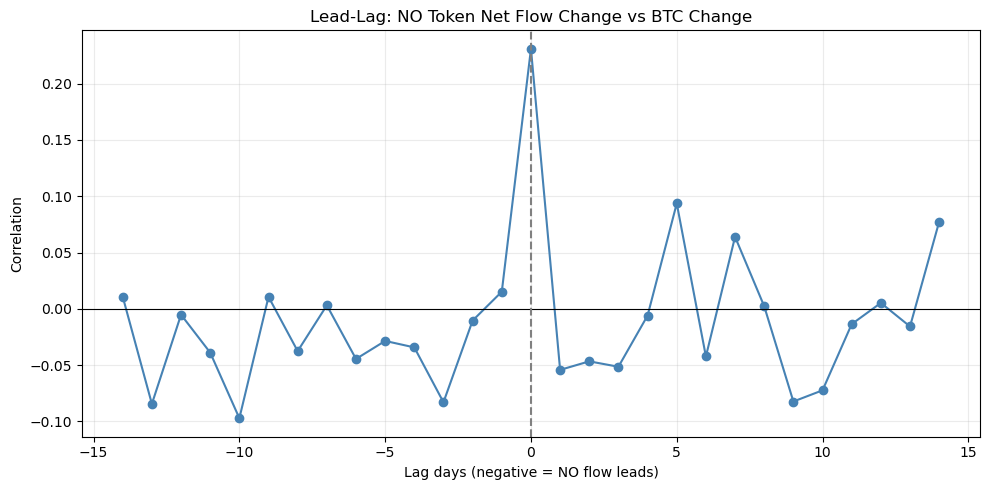

In [152]:
# Lead-lag plot for NO-token flow vs BTC.
if lag_df.empty:
    print('No lag correlations to plot.')
else:
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(lag_df['lag'], lag_df['correlation'], marker='o', color='steelblue')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.axvline(0, color='gray', linestyle='--')
    ax.set_title('Lead-Lag: NO Token Net Flow Change vs BTC Change')
    ax.set_xlabel('Lag days (negative = NO flow leads)')
    ax.set_ylabel('Correlation')
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


In [153]:
# Top lead-lag correlations.
if lag_df.empty:
    print('No lag correlations available.')
else:
    top_lags = lag_df.reindex(lag_df['correlation'].abs().sort_values(ascending=False).index).head(5)
    display(top_lags)


,lag,correlation,pvalue,sample_size
14,0,0.230953,0.000291,242
4,-10,-0.097197,0.139955,232
19,5,0.093581,0.150946,237
1,-13,-0.084459,0.202886,229
11,-3,-0.083003,0.201014,239


In [154]:
# Optional Granger causality test.
from statsmodels.tsa.stattools import grangercausalitytests
if len(no_flow_timeseries) < 30:
    print('Not enough observations for Granger causality test.')
else:
    granger_data = no_flow_timeseries[['NO_NET_change', 'btc_pct_change']].dropna()
    try:
        granger_results = grangercausalitytests(granger_data[['btc_pct_change', 'NO_NET_change']], maxlag=min(14, len(granger_data)//5), verbose=False)
        rows = []
        for lag, result in granger_results.items():
            rows.append({'lag': lag, 'pvalue': result[0]['ssr_ftest'][1]})
        granger_summary = pd.DataFrame(rows)
        display(granger_summary)
    except Exception as e:
        print(f'Granger test could not run: {e}')


,lag,pvalue
0,1,0.366254
1,2,0.529524
2,3,0.639906
3,4,0.472187
4,5,0.392573
5,6,0.443654
6,7,0.514447
7,8,0.650256
8,9,0.670903
9,10,0.516158


In [155]:
# Directional lead-lag accuracy.
if len(no_flow_timeseries) < 20:
    directional_df = pd.DataFrame(columns=['lag', 'accuracy', 'sample_size'])
    print('Not enough observations for directional lead-lag analysis.')
else:
    directional_results = []
    for lag in range(-14, 15):
        temp = no_flow_timeseries.copy()
        temp['NO_direction'] = np.sign(temp['NO_NET_change'].shift(lag))
        temp['btc_direction'] = np.sign(temp['btc_pct_change'])
        clean = temp[(temp['NO_direction'] != 0) & (temp['btc_direction'] != 0)].dropna()
        if len(clean) > 10:
            directional_results.append({'lag': lag, 'accuracy': (clean['NO_direction'] == clean['btc_direction']).mean(), 'sample_size': len(clean)})
    directional_df = pd.DataFrame(directional_results, columns=['lag', 'accuracy', 'sample_size'])
    display(directional_df.sort_values('accuracy', ascending=False).head(10))


,lag,accuracy,sample_size
21,7,0.548936,235
5,-9,0.545064,233
10,-4,0.533613,238
7,-7,0.519149,235
1,-13,0.515284,229
19,5,0.514768,237
17,3,0.514644,239
13,-1,0.514523,241
24,10,0.512931,232
14,0,0.512397,242


In [156]:
# Asymmetric up/down BTC day check.
if len(no_flow_timeseries) < 20:
    print('Not enough observations for asymmetric lead-lag analysis.')
else:
    print(f"BTC up days: {(no_flow_timeseries['btc_pct_change'] > 0).sum()}")
    print(f"BTC down days: {(no_flow_timeseries['btc_pct_change'] < 0).sum()}")
    display(no_flow_timeseries.groupby(no_flow_timeseries['btc_pct_change'] > 0)['NO_NET_change'].describe())


BTC up days: 125
BTC down days: 117


,count,mean,std,min,25%,50%,75%,max
btc_pct_change,,,,,,,,
False,117.0,-7.038188,103.187099,-475.979671,-55.269300,-6.615260,31.513786,335.775402
True,125.0,29.568240,110.139860,-236.458094,-35.930607,-2.596945,69.657028,413.049019


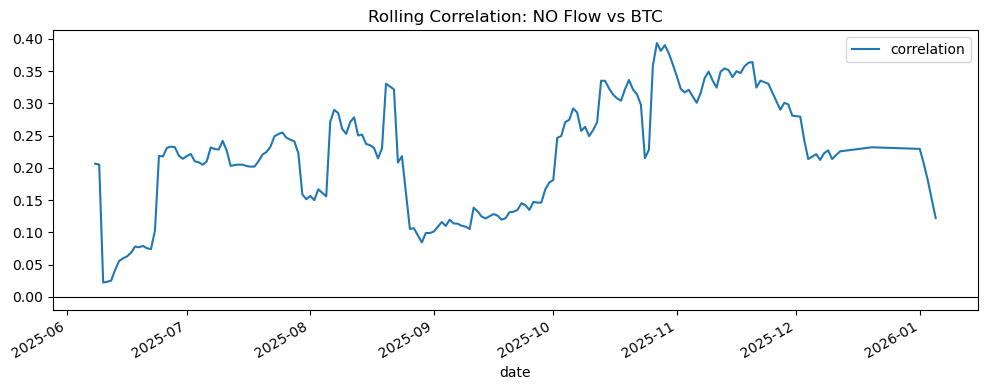

In [158]:
# Rolling correlation.
window = 60
if len(no_flow_timeseries) <= window:
    rolling_df = pd.DataFrame(columns=['date', 'correlation', 'pvalue'])
    print('Not enough observations for rolling correlation.')
else:
    rolling_corrs = []
    for i in range(window, len(no_flow_timeseries)):
        clean = no_flow_timeseries.iloc[i-window:i][['NO_NET_change', 'btc_pct_change']].dropna()
        if len(clean) > 30 and clean['NO_NET_change'].nunique() > 1 and clean['btc_pct_change'].nunique() > 1:
            corr, pval = pearsonr(clean['NO_NET_change'], clean['btc_pct_change'])
            rolling_corrs.append({'date': no_flow_timeseries.iloc[i]['date'], 'correlation': corr, 'pvalue': pval})
    rolling_df = pd.DataFrame(rolling_corrs)
    if rolling_df.empty:
        print('No rolling windows with enough variation.')
    else:
        rolling_df.plot(x='date', y='correlation', figsize=(10, 4), title='Rolling Correlation: NO Flow vs BTC')
        plt.axhline(0, color='black', linewidth=0.8)
        plt.tight_layout()
        plt.show()


In [159]:
# Lead-lag summary.
print('\n' + '='*80)
print('NO TOKEN FLOW vs BTC: LEAD-LAG SUMMARY')
print('='*80)
if not lag_df.empty:
    print(f"Best lag: {int(optimal_lag['lag'])} days")
    print(f"Correlation: {optimal_lag['correlation']:.4f}")
    print(f"P-value: {optimal_lag['pvalue']:.4f}")
    print(f"Sample size: {int(optimal_lag['sample_size'])}")
else:
    print('No reliable lag estimate available from the filtered data.')



NO TOKEN FLOW vs BTC: LEAD-LAG SUMMARY
Best lag: 0 days
Correlation: 0.2310
P-value: 0.0003
Sample size: 242


## 3. Crypto Market EDA


Crypto-specific volume concentration, BTC return/volatility joins, market dispersion, market momentum, and order-imbalance analysis.


### 2. Data Preprocessing and Understanding


In [160]:
# Source: eda_split_work_crypto.ipynb, cell 9
# Check the categories of Polymarket data
category = poly_data['markets'].groupby('category')
print(category.groups.keys())
category.size()


dict_keys(['', 'Business', 'Coronavirus', 'Coronavirus-', 'Crypto', 'Global Politics', 'Politics', 'Pop-Culture ', 'Tech', 'US-current-affairs', 'Ukraine & Russia'])


category
                      77516
Business                113
Coronavirus               3
Coronavirus-              1
Crypto                  340
Global Politics          56
Politics                  1
Pop-Culture               4
Tech                      2
US-current-affairs      265
Ukraine & Russia         20
dtype: int64

In [161]:
# Source: eda_split_work_crypto.ipynb, cell 10
# 1. Define your keyword map
keyword_map = {
    'Crypto': 'bitcoin|eth|solana|crypto|token|airdrop',
    'Politics': 'trump|biden|harris|election|senate|republican|democrat',
    'Ukraine & Russia': 'ukraine|russia|putin|zelensky|kremlin',
    'Pop-Culture': 'oscars|grammy|taylor swift|box office|celebrity',
    'Tech': 'ai|openai|gpt|google|nvidia|meta|apple',
    'Global Politics': 'israel|gaza|iran|china|taiwan|uk|london'
}

# 2. Filter for only the rows where category is blank
blank_mask = (poly_data['markets']['category'] == '') | (poly_data['markets']['category'].isna())

# 3. Loop through the map and update blank categories based on question text
for cat, keywords in keyword_map.items():
    # Only update if the row is currently blank AND the question contains a keyword
    match_mask = blank_mask & poly_data['markets']['question'].str.contains(keywords, case=False, na=False)
    poly_data['markets'].loc[match_mask, 'category'] = cat

# 4. See how many are left blank now
print(poly_data['markets']['category'].value_counts())


category
Crypto                57852
Politics              10909
                       7421
Tech                    766
Global Politics         694
Ukraine & Russia        293
US-current-affairs      265
Business                113
Pop-Culture               4
Coronavirus               3
Coronavirus-              1
Name: count, dtype: int64


In [162]:
# Crypto section table aliases
markets_df = poly_data['markets'].copy()
event_stats_df = poly_data['event_stats'].copy()
odds_history_df = poly_data['odds_history'].copy()
summary_df = poly_data['summary'].copy()
tokens_df = poly_data['tokens'].copy()
trades_df = poly_data.get('trades')
print('trades_df:', None if trades_df is None else trades_df.shape)


trades_df: (27013724, 9)


In [163]:
# Crypto category tables
crypto_markets = markets_df[markets_df['category'] == 'Crypto'].copy()
crypto_event_stats = crypto_markets[['event_slug']].merge(event_stats_df, on='event_slug', how='left')
crypto_odds_history = odds_history_df.merge(crypto_markets[['market_id', 'question']], on='market_id', how='inner').dropna(subset=['market_id'])
crypto_summary = crypto_markets[['market_id']].merge(summary_df, on='market_id', how='left')
crypto_tokens = tokens_df.merge(crypto_markets[['market_id', 'question']], on='market_id', how='inner').dropna(subset=['market_id'])
if trades_df is None:
    crypto_trades = pd.DataFrame(columns=['market_id', 'token_id', 'timestamp', 'price', 'size', 'side', 'question'])
else:
    crypto_trades = trades_df.merge(crypto_markets[['market_id', 'question']], on='market_id', how='inner').dropna(subset=['market_id'])

for frame in [crypto_trades, crypto_odds_history]:
    if not frame.empty and 'timestamp' in frame.columns:
        frame['timestamp'] = pd.to_datetime(frame['timestamp'], errors='coerce')
        if frame['timestamp'].notna().any() and frame['timestamp'].dt.year.eq(1970).all():
            frame['timestamp'] = pd.to_datetime(frame['timestamp'].astype('int64'), unit='ms', errors='coerce')

print('crypto_markets:', crypto_markets.shape)
print('crypto_odds_history:', crypto_odds_history.shape)
print('crypto_trades:', crypto_trades.shape)


crypto_markets: (57852, 10)
crypto_odds_history: (553076, 5)
crypto_trades: (21119439, 10)


In [164]:
# Source: eda_split_work_crypto.ipynb, cell 13
# Check if we have the correct timestamp (without 1970s)
print(crypto_trades["timestamp"].min(), crypto_trades["timestamp"].max())
print(crypto_odds_history["timestamp"].min(), crypto_odds_history["timestamp"].max())


2025-04-07 08:05:19 2026-01-05 06:31:01
2023-02-03 00:00:56 2026-01-05 01:02:10


In [165]:
# Source: eda_split_work_crypto.ipynb, cell 14
# Summary info
print(crypto_markets.info())
print("\nMissing values:")
print(crypto_markets.isna().sum())
print()


<class 'pandas.core.frame.DataFrame'>
Index: 57852 entries, 3 to 78316
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   market_id   57852 non-null  object        
 1   question    57852 non-null  object        
 2   slug        57852 non-null  object        
 3   event_slug  57852 non-null  object        
 4   category    57852 non-null  object        
 5   volume      57852 non-null  float64       
 6   active      57852 non-null  bool          
 7   closed      57852 non-null  bool          
 8   created_at  57852 non-null  datetime64[us]
 9   end_date    57712 non-null  datetime64[us]
dtypes: bool(2), datetime64[us](2), float64(1), object(5)
memory usage: 4.1+ MB
None

Missing values:
market_id       0
question        0
slug            0
event_slug      0
category        0
volume          0
active          0
closed          0
created_at      0
end_date      140
dtype: int64



In [166]:
# Source: eda_split_work_crypto.ipynb, cell 15
print(crypto_event_stats.info())
print("\nMissing values:")
print(crypto_event_stats.isna().sum())
print()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57852 entries, 0 to 57851
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   event_slug          57852 non-null  object        
 1   market_count        57852 non-null  int64         
 2   total_volume        57852 non-null  float64       
 3   first_market_start  57852 non-null  datetime64[us]
 4   last_market_end     57806 non-null  datetime64[us]
dtypes: datetime64[us](2), float64(1), int64(1), object(1)
memory usage: 2.2+ MB
None

Missing values:
event_slug             0
market_count           0
total_volume           0
first_market_start     0
last_market_end       46
dtype: int64



In [167]:
# Source: eda_split_work_crypto.ipynb, cell 16
print(crypto_odds_history.info())
print("\nMissing values:")
print(crypto_odds_history.isna().sum())
print()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 553076 entries, 0 to 553075
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   market_id  553076 non-null  object        
 1   token_id   553076 non-null  object        
 2   timestamp  553076 non-null  datetime64[ns]
 3   price      553076 non-null  float64       
 4   question   553076 non-null  object        
dtypes: datetime64[ns](1), float64(1), object(3)
memory usage: 21.1+ MB
None

Missing values:
market_id    0
token_id     0
timestamp    0
price        0
question     0
dtype: int64



In [168]:
# Source: eda_split_work_crypto.ipynb, cell 17
print(crypto_summary.info())
print("\nMissing values:")
print(crypto_summary.isna().sum())
print()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57852 entries, 0 to 57851
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   market_id    57852 non-null  object        
 1   question     57852 non-null  object        
 2   slug         57852 non-null  object        
 3   volume       57852 non-null  float64       
 4   active       57852 non-null  bool          
 5   token_count  57852 non-null  int64         
 6   trade_count  57852 non-null  int64         
 7   first_trade  28586 non-null  datetime64[us]
 8   last_trade   28586 non-null  datetime64[us]
dtypes: bool(1), datetime64[us](2), float64(1), int64(2), object(3)
memory usage: 3.6+ MB
None

Missing values:
market_id          0
question           0
slug               0
volume             0
active             0
token_count        0
trade_count        0
first_trade    29266
last_trade     29266
dtype: int64



In [169]:
# Source: eda_split_work_crypto.ipynb, cell 18
print(crypto_tokens.info())
print("\nMissing values:")
print(crypto_tokens.isna().sum())
print()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115694 entries, 0 to 115693
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   market_id  115694 non-null  object
 1   token_id   115694 non-null  object
 2   outcome    115694 non-null  object
 3   question   115694 non-null  object
dtypes: object(4)
memory usage: 3.5+ MB
None

Missing values:
market_id    0
token_id     0
outcome      0
question     0
dtype: int64



In [170]:
# Source: eda_split_work_crypto.ipynb, cell 19
print(crypto_trades.info())
print("\nMissing values:")
print(crypto_trades.isna().sum())
print()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21119439 entries, 0 to 21119438
Data columns (total 10 columns):
 #   Column         Dtype         
---  ------         -----         
 0   trade_id       object        
 1   market_id      object        
 2   token_id       object        
 3   timestamp      datetime64[ns]
 4   price          float64       
 5   size           float64       
 6   side           object        
 7   maker_address  object        
 8   taker_address  object        
 9   question       object        
dtypes: datetime64[ns](1), float64(2), object(7)
memory usage: 1.6+ GB
None

Missing values:
trade_id             0
market_id            0
token_id             0
timestamp            0
price                0
size                 0
side                 0
maker_address    11331
taker_address    16015
question             0
dtype: int64



In [171]:
# Source: eda_split_work_crypto.ipynb, cell 20
# Top 10 crypto markets by volumn
top10 = crypto_markets.sort_values("volume", ascending=False).head(10)

print(top10[["question", "volume"]])


                                               question        volume
4965                Will Bitcoin hit $100k in November?  2.858743e+07
218                     Will Bitcoin hit $100k in 2024?  2.280724e+07
627                     Ethereum all time high in 2024?  1.951018e+07
54737  Over $1.4B committed to the MegaETH public sale?  1.688234e+07
14932            Will Satoshi move any Bitcoin in 2025?  1.629100e+07
43395              Will Bitcoin reach $200k in October?  1.561720e+07
53349  Over $1.8B committed to the MegaETH public sale?  1.482415e+07
56394          Will Bitcoin reach $200,000 in November?  1.358862e+07
53492    Over $1B committed to the MegaETH public sale?  1.343146e+07
2141                   Ethereum ETF approved by May 31?  1.322651e+07


In [172]:
# Source cleaned from eda_split_work_crypto.ipynb, cell 21
# Prepare BTC table for the crypto analytic plots.
btc_pd = btc_df.to_pandas() if hasattr(btc_df, 'to_pandas') else btc_df.copy()

btc_pd['time'] = pd.to_datetime(btc_pd['time'], errors='coerce')
btc_pd = btc_pd.sort_values('time')

if 'btc_price' not in btc_pd.columns:
    btc_pd = btc_pd.rename(columns={'PriceUSD': 'btc_price'})

btc_pd['btc_price'] = pd.to_numeric(btc_pd['btc_price'], errors='coerce')
btc_pd['btc_return'] = btc_pd['btc_price'].pct_change()
btc_pd['btc_volatility_7d'] = btc_pd['btc_return'].rolling(7).std()

btc_pd.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6221 entries, 0 to 6220
Data columns (total 34 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   time                         6221 non-null   datetime64[ns]
 1   AdrActCnt                    6220 non-null   float64       
 2   AdrBalCnt                    6220 non-null   float64       
 3   AssetCompletionTime          6220 non-null   float64       
 4   AssetEODCompletionTime       6220 non-null   float64       
 5   BlkCnt                       6220 non-null   float64       
 6   CapMVRVCur                   5659 non-null   float64       
 7   CapMrktCurUSD                5659 non-null   float64       
 8   CapMrktEstUSD                2398 non-null   float64       
 9   FeeTotNtv                    6220 non-null   float64       
 10  FlowInExNtv                  6220 non-null   float64       
 11  FlowInExUSD                  5659 non-null 

In the data frame `btc_pd`, we introduced 2 new variables `btc_return` and `btc_volatility_7d`. The formulas are given below:

At day $t$, the BTC return is given by
$$\text{return}_t = \frac{\text{price}_t-\text{price}_{t-1}}{\text{price}_{t-1}},$$
i.e. daily BTC percentage price change;

The 7-day BTC volatility is given by
$$\text{volatility}^{(7)}_t = \sqrt{\frac{1}{6}\sum_{k=0}^6 (\text{return}_{t-k} - \frac{1}{7}\sum_{j=0}^6 \text{return}_{t-k})^2},$$
i.e. the 7-day rolling standard deviation of BTC return. It reflects short-term risk intensity.

We will use these variables in the following plots.


### 3. Analytical Plots


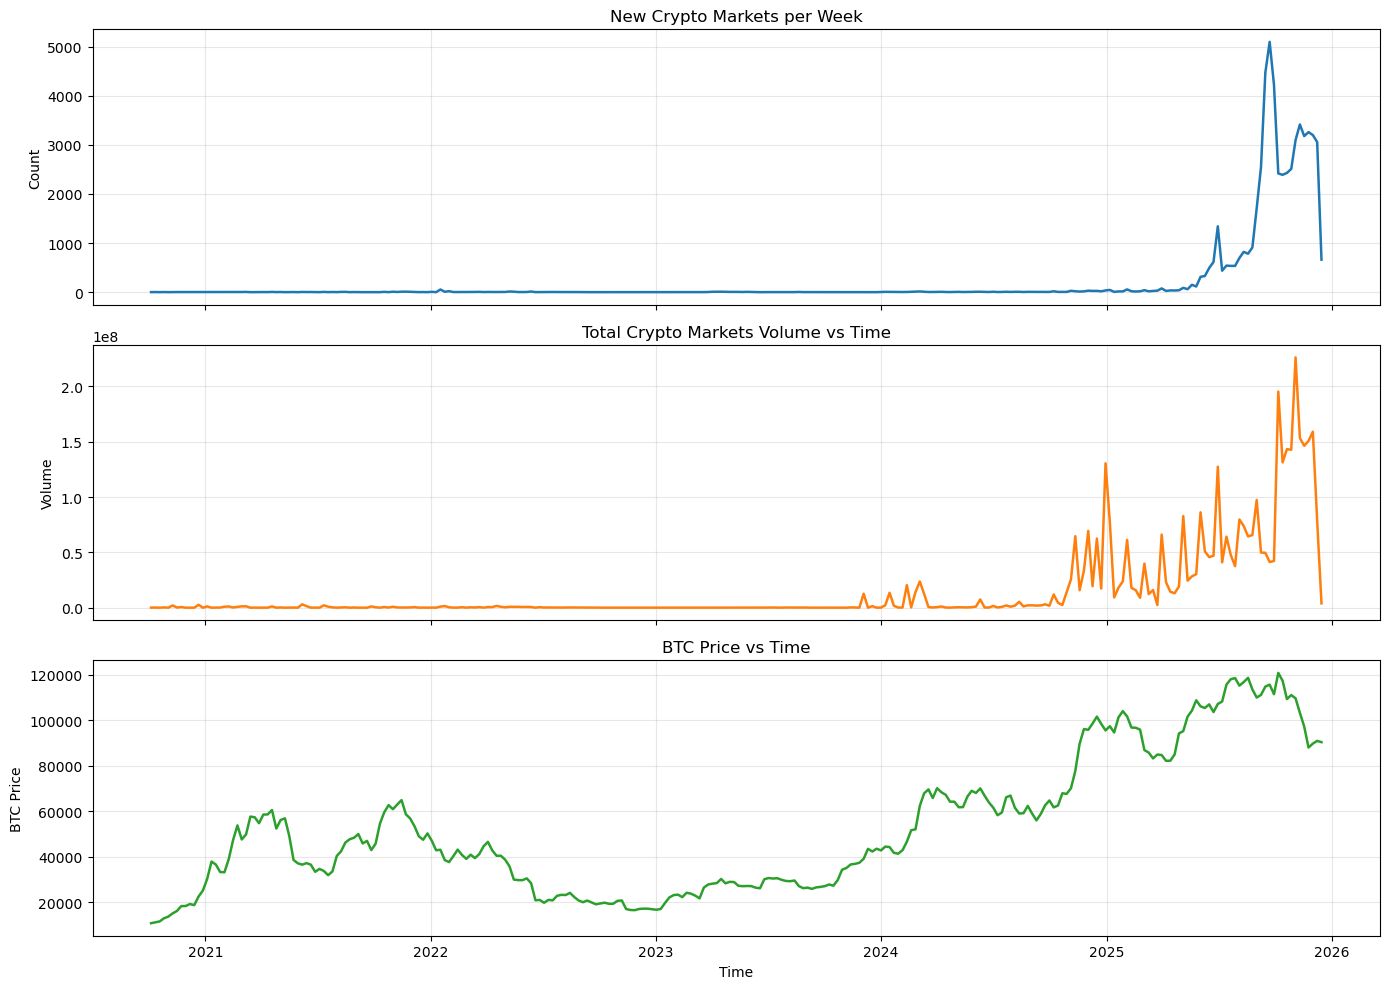

In [173]:
import matplotlib.ticker as mtick
# Weekly crypto market activity and BTC price.
crypto_markets['created_at'] = pd.to_datetime(crypto_markets['created_at'], errors='coerce')
crypto_markets['volume'] = pd.to_numeric(crypto_markets['volume'], errors='coerce')

btc_weekly_source = btc_pd.copy()
if 'btc_price' not in btc_weekly_source.columns and 'PriceUSD' in btc_weekly_source.columns:
    btc_weekly_source = btc_weekly_source.rename(columns={'PriceUSD': 'btc_price'})
btc_weekly_source['time'] = pd.to_datetime(btc_weekly_source['time'], errors='coerce')
btc_weekly_source['btc_price'] = pd.to_numeric(btc_weekly_source['btc_price'], errors='coerce')

crypto_markets_valid = crypto_markets.dropna(subset=['created_at']).copy()
btc_weekly_valid = btc_weekly_source.dropna(subset=['time', 'btc_price']).copy()

markets_per_week = pd.Series(dtype='float64', name='market_count')
volume_per_week = pd.Series(dtype='float64', name='total_volume')
btc_price_per_week = pd.Series(dtype='float64', name='btc_price')

if crypto_markets_valid.empty:
    print('No valid crypto market creation dates available.')
elif btc_weekly_valid.empty:
    print('No valid BTC price dates available.')
else:
    markets_per_week = crypto_markets_valid.set_index('created_at').resample('W-MON').size().rename('market_count')
    volume_per_week = crypto_markets_valid.set_index('created_at').resample('W-MON')['volume'].sum().rename('total_volume')
    btc_price_per_week = btc_weekly_valid.set_index('time').resample('W-MON')['btc_price'].mean().rename('btc_price')
    aligned = pd.concat([markets_per_week, volume_per_week, btc_price_per_week], axis=1, join='inner').dropna()
    if aligned.empty:
        print('No overlapping weekly observations for crypto markets and BTC price.')
    else:
        fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
        axes[0].plot(aligned.index, aligned['market_count'], color='#1f77b4', linewidth=1.8)
        axes[0].set_title('New Crypto Markets per Week')
        axes[0].set_ylabel('Count')
        axes[0].grid(alpha=0.3)
        axes[1].plot(aligned.index, aligned['total_volume'], color='#ff7f0e', linewidth=1.8)
        axes[1].set_title('Total Crypto Markets Volume vs Time')
        axes[1].set_ylabel('Volume')
        axes[1].grid(alpha=0.3)
        axes[2].plot(aligned.index, aligned['btc_price'], color='#2ca02c', linewidth=1.8)
        axes[2].set_title('BTC Price vs Time')
        axes[2].set_ylabel('BTC Price')
        axes[2].set_xlabel('Time')
        axes[2].grid(alpha=0.3)
        plt.tight_layout()
        plt.show()


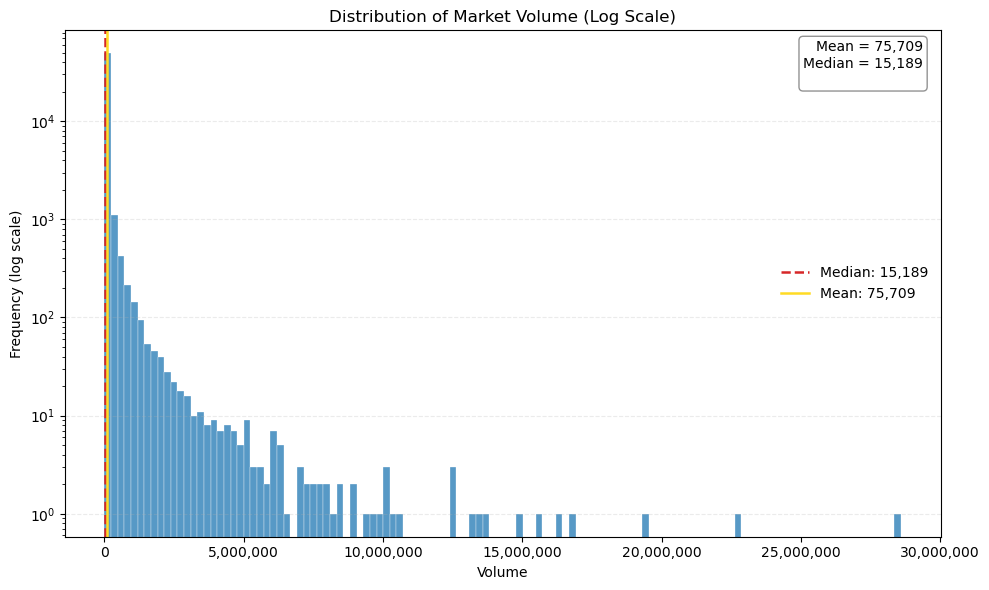

In [174]:
import matplotlib.ticker as mtick
# Source: eda_split_work_crypto.ipynb, cell 25
# Draw distribution of volumn

vol = pd.to_numeric(crypto_markets['volume'], errors='coerce').dropna()
vol = vol[vol > 0]

# Statistics
mean_v = vol.mean()
median_v = vol.median()

plt.figure(figsize=(10, 6))
plt.hist(
    vol,
    bins=120,
    color='#1f77b4',
    alpha=0.75,
    edgecolor='white',
    linewidth=0.3
)

plt.yscale('log')
plt.title("Distribution of Market Volume (Log Scale)")
plt.xlabel("Volume")
plt.ylabel("Frequency (log scale)")
plt.grid(axis='y', alpha=0.25, linestyle='--')
plt.axvline(median_v, color='#d62728', linestyle='--', linewidth=1.8, label=f'Median: {median_v:,.0f}')
plt.axvline(mean_v,   color="#ffdb24", linestyle='-',  linewidth=1.8, label=f'Mean: {mean_v:,.0f}')
plt.gca().xaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

# Text in the graph
txt = (
    f"Mean = {mean_v:,.0f}\n"
    f"Median = {median_v:,.0f}\n"
)
plt.text(
    0.98, 0.98, txt,
    transform=plt.gca().transAxes,
    ha='right', va='top',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85, edgecolor='gray')
)

plt.legend(frameon=False)
plt.tight_layout()
plt.show()


**Interpretation:**

1. Highly right-skewed distribution.

2. Most markets have low volume.

3. A small number of markets dominate total trading.

This is typical of crypto speculation  a few headline markets attract most liquidity.

**Implication:**

Liquidity concentration  any market-level average may be heavily influenced by a few large markets.


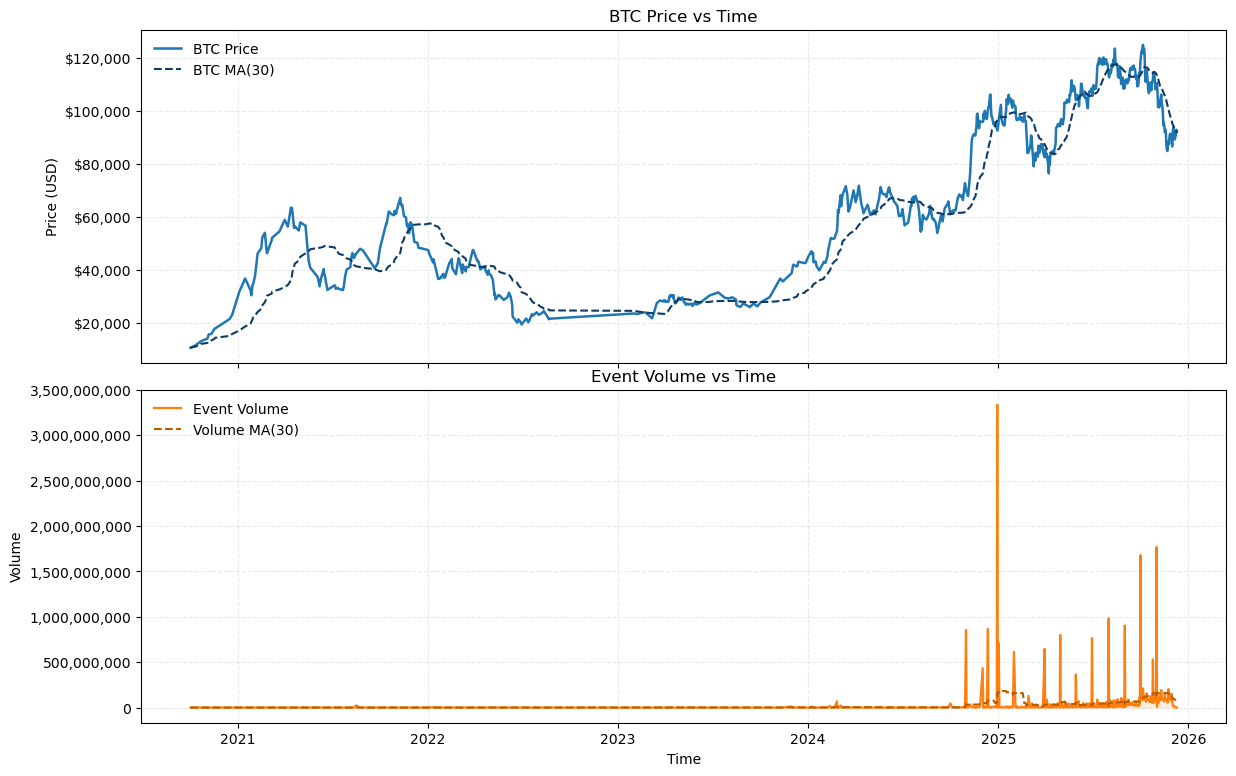

In [175]:
# Source: eda_split_work_crypto.ipynb, cell 27
event_volume = crypto_event_stats.copy()
event_volume['time'] = pd.to_datetime(event_volume['first_market_start'], errors='coerce')
event_volume['date'] = event_volume['time'].dt.normalize()
event_volume = event_volume.groupby('date', as_index=False)['total_volume'].sum()

btc_daily = btc_pd[['time','btc_price']].copy()
btc_daily['date'] = pd.to_datetime(btc_daily['time'], errors='coerce').dt.normalize()
btc_daily = btc_daily.groupby('date', as_index=False)['btc_price'].mean()

merged = pd.merge(event_volume, btc_daily, on='date', how='inner')

merged = merged.sort_values('date').copy()

# Add moving average lines
merged['btc_price_ma30'] = merged['btc_price'].rolling(30, min_periods=1).mean()
merged['event_volume_ma30'] = merged['total_volume'].rolling(30, min_periods=1).mean()

fig, axes = plt.subplots(
    2, 1, figsize=(14, 9), sharex=True, gridspec_kw={'hspace': 0.08}
)

# BTC Price Plot
axes[0].plot(merged['date'], merged['btc_price'], color='#1f77b4', linewidth=1.8, label='BTC Price')
axes[0].plot(merged['date'], merged['btc_price_ma30'], color='#0d3b66', linestyle='--', linewidth=1.5, label='BTC MA(30)')
axes[0].set_title("BTC Price vs Time")
axes[0].set_ylabel("Price (USD)")
axes[0].grid(alpha=0.25, linestyle='--')
axes[0].legend(frameon=False, loc='upper left')
axes[0].yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))

# Event Volume Plot
axes[1].plot(merged['date'], merged['total_volume'], color='#ff7f0e', linewidth=1.6, label='Event Volume')
axes[1].plot(merged['date'], merged['event_volume_ma30'], color='#b85c00', linestyle='--', linewidth=1.5, label='Volume MA(30)')
axes[1].fill_between(merged['date'], merged['total_volume'], color='#ff7f0e', alpha=0.12)
axes[1].set_title("Event Volume vs Time")
axes[1].set_ylabel("Volume")
axes[1].set_xlabel("Time")
axes[1].grid(alpha=0.25, linestyle='--')
axes[1].legend(frameon=False, loc='upper left')
axes[1].yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.show()


**Interpretation:**

1. Large volume spikes likely coincide with large BTC moves or major events.

2. Volume tends to increase during high BTC price volatility regimes.

**Finding:**

Polymarket trading activity increases during BTC price excitement. This suggests that Polymarket may be reactive to crypto macro movements.


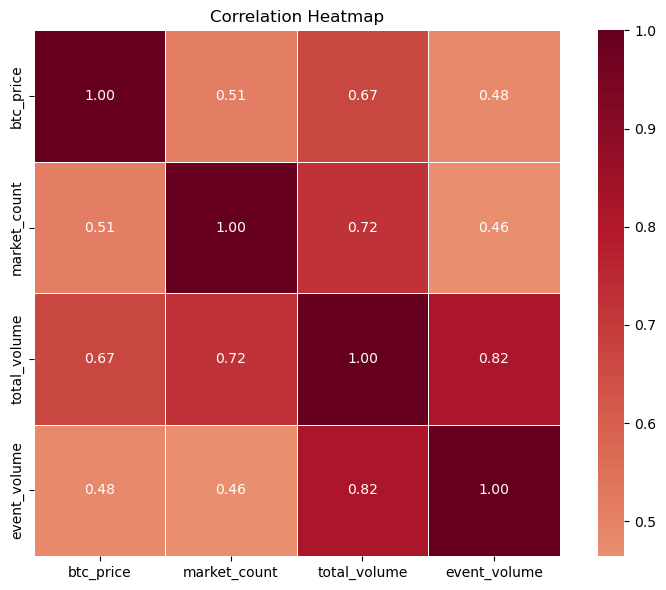

In [176]:
# Source cleaned from eda_split_work_crypto.ipynb, cell 29
# Correlation heatmap between BTC price, crypto market creation, market volume, and event volume.
event_volume_valid = crypto_event_stats.copy()
event_volume_valid['first_market_start'] = pd.to_datetime(event_volume_valid['first_market_start'], errors='coerce')
event_volume_valid['total_volume'] = pd.to_numeric(event_volume_valid['total_volume'], errors='coerce')
event_volume_valid = event_volume_valid.dropna(subset=['first_market_start'])

if event_volume_valid.empty or btc_price_per_week.empty or markets_per_week.empty or volume_per_week.empty:
    print('Note: missing weekly series for correlation heatmap.')
else:
    event_volume_per_week = (
        event_volume_valid
        .set_index('first_market_start')
        .resample('W-MON')['total_volume']
        .sum()
        .rename('event_volume')
    )

    corr_df = pd.concat([btc_price_per_week, markets_per_week, volume_per_week, event_volume_per_week], axis=1, join='inner').dropna()

    if corr_df.empty:
        print('Note: no overlapping weekly observations for correlation heatmap.')
    else:
        corr_mat = corr_df.corr(method='pearson')
        plt.figure(figsize=(8, 6))
        sns.heatmap(corr_mat, annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True, linewidths=0.5)
        plt.title('Correlation Heatmap')
        plt.tight_layout()
        plt.show()


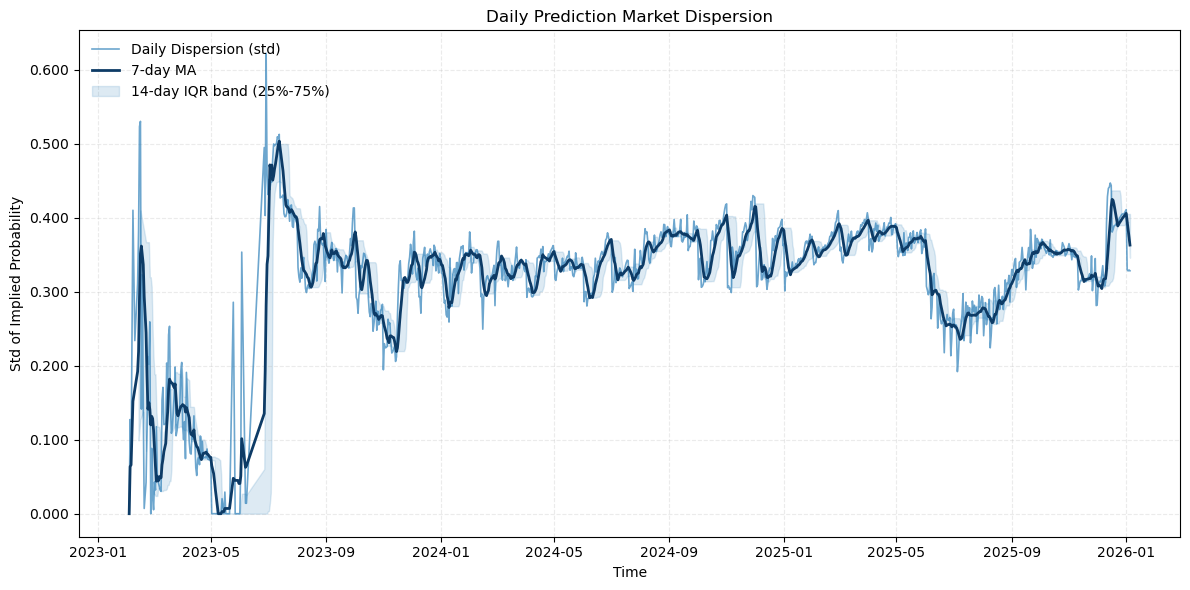

In [177]:
# Source: eda_split_work_crypto.ipynb, cell 30
# Daily implied probability dispersion
crypto_odds_history['date'] = crypto_odds_history['timestamp'].dt.date

daily_dispersion = crypto_odds_history.groupby('date')['price'].std().reset_index()
daily_dispersion['date'] = pd.to_datetime(daily_dispersion['date'])
daily_dispersion = daily_dispersion.sort_values('date')
daily_dispersion['disp_ma7'] = daily_dispersion['price'].rolling(7, min_periods=1).mean()
daily_dispersion['disp_q25'] = daily_dispersion['price'].rolling(14, min_periods=7).quantile(0.25)
daily_dispersion['disp_q75'] = daily_dispersion['price'].rolling(14, min_periods=7).quantile(0.75)


plt.figure(figsize=(12, 6))

# Dispersion
plt.plot(
    daily_dispersion['date'], daily_dispersion['price'],
    color='#1f77b4', linewidth=1.2, alpha=0.65, label='Daily Dispersion (std)'
)

# 7-day moving average
plt.plot(
    daily_dispersion['date'], daily_dispersion['disp_ma7'],
    color='#0d3b66', linewidth=2.0, label='7-day MA'
)

# IQR
plt.fill_between(
    daily_dispersion['date'],
    daily_dispersion['disp_q25'],
    daily_dispersion['disp_q75'],
    color='#1f77b4', alpha=0.15, label='14-day IQR band (25%-75%)'
)

plt.title("Daily Prediction Market Dispersion")
plt.xlabel("Time")
plt.ylabel("Std of Implied Probability")
plt.grid(alpha=0.25, linestyle='--')
plt.legend(frameon=False, loc='upper left')
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:.3f}'))
plt.tight_layout()
plt.show()


The market dispersion on day $t$ is given by:

$$\text{dispersion}_t = std(p_{i, t}),$$
where $p_{i, t}$ is the price of market $i$ on day $t$. It measures cross-sectional disagreement across prediction markets.


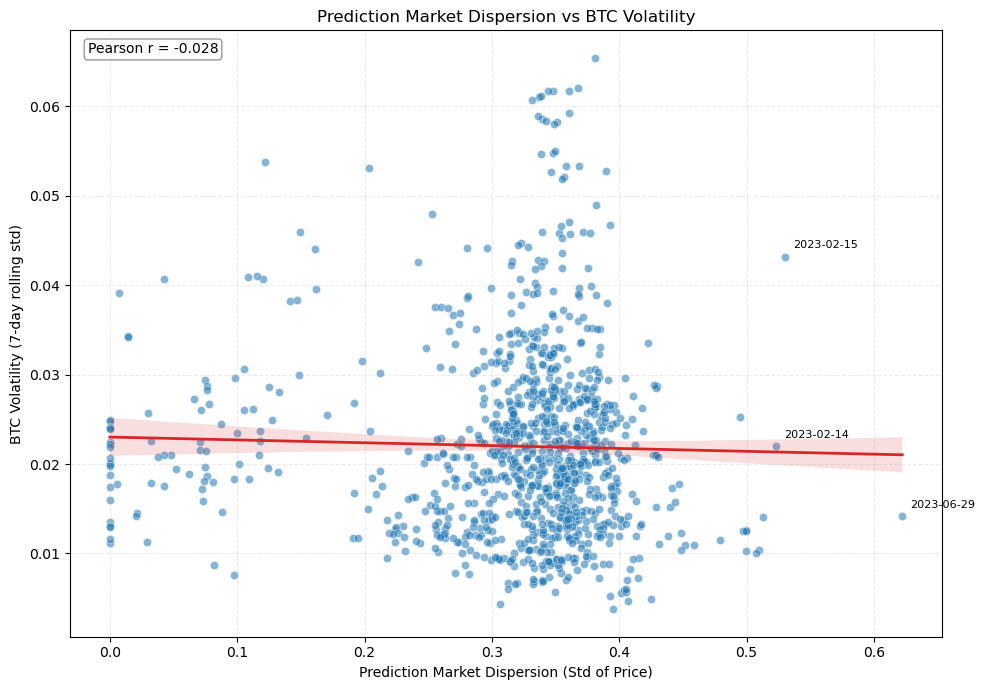

In [178]:
# Source: eda_split_work_crypto.ipynb, cell 32
# Merge volatility by date
vol_df = daily_dispersion[['date', 'price']].copy()
vol_df['date'] = pd.to_datetime(vol_df['date']).dt.normalize()

btc_vol = btc_pd[['time', 'btc_volatility_7d']].copy()
btc_vol['date'] = pd.to_datetime(btc_vol['time']).dt.normalize()
btc_vol = btc_vol.groupby('date', as_index=False)['btc_volatility_7d'].mean()

merged_vol = pd.merge(vol_df, btc_vol, on='date', how='inner').dropna()

# Correlation
corr = merged_vol['price'].corr(merged_vol['btc_volatility_7d'])

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=merged_vol,
    x='price',
    y='btc_volatility_7d',
    s=35,
    alpha=0.55,
    color='#1f77b4'
)

# Regression line + 95% CI
sns.regplot(
    data=merged_vol,
    x='price',
    y='btc_volatility_7d',
    scatter=False,
    ci=95,
    line_kws={'color': '#d62728', 'linewidth': 2}
)

# Pearson r correlation
plt.text(
    0.02, 0.98, f'Pearson r = {corr:.3f}',
    transform=plt.gca().transAxes,
    ha='left', va='top',
    bbox=dict(boxstyle='round,pad=0.25', facecolor='white', alpha=0.8, edgecolor='gray')
)

# Outliers
for i in merged_vol['price'].nlargest(3).index:
    plt.annotate(
        merged_vol.loc[i, 'date'].strftime('%Y-%m-%d'),
        (merged_vol.loc[i, 'price'], merged_vol.loc[i, 'btc_volatility_7d']),
        xytext=(6, 6),
        textcoords='offset points',
        fontsize=8
    )

plt.title("Prediction Market Dispersion vs BTC Volatility")
plt.xlabel("Prediction Market Dispersion (Std of Price)")
plt.ylabel("BTC Volatility (7-day rolling std)")
plt.grid(alpha=0.25, linestyle='--')
plt.tight_layout()
plt.show()


No obvious correlation found between market dispersion and BTC volatility.


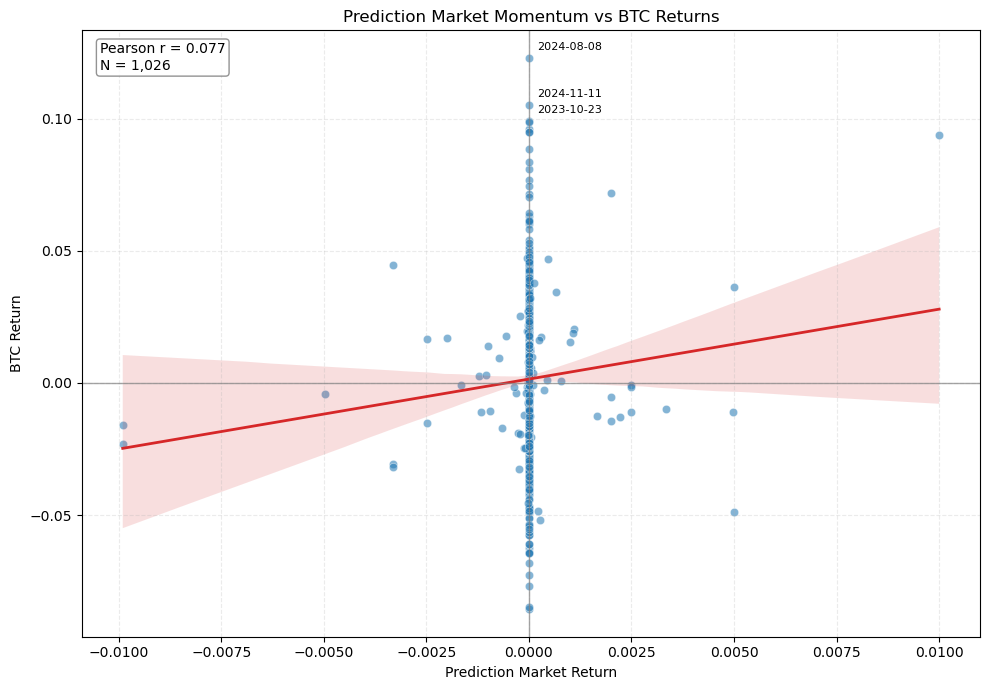

In [179]:
# Source: eda_split_work_crypto.ipynb, cell 34
# Compute daily mean price change rate (price return) in Polymarket data
daily_mean_price = crypto_odds_history.groupby('date')['price'].mean().reset_index()
daily_mean_price['price_return'] = daily_mean_price['price'].pct_change()

# Make join key datetime64 and align to day
daily_mean_price['date'] = pd.to_datetime(daily_mean_price['date'])
btc_daily = btc_pd[['time', 'btc_return']].copy()
btc_daily['time'] = pd.to_datetime(btc_daily['time']).dt.normalize()

# Merge
merged_momentum = pd.merge(
    daily_mean_price,
    btc_daily,
    left_on='date',
    right_on='time',
    how='inner'
)

plot_df = merged_momentum[['date', 'price_return', 'btc_return']].dropna().copy()
corr = plot_df['price_return'].corr(plot_df['btc_return'])
n = len(plot_df)

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=plot_df,
    x='price_return',
    y='btc_return',
    s=36,
    alpha=0.55,
    color='#1f77b4'
)

# Regression line + 95% CI
sns.regplot(
    data=plot_df,
    x='price_return',
    y='btc_return',
    scatter=False,
    ci=95,
    line_kws={'color': '#d62728', 'linewidth': 2}
)

plt.axhline(0, color='gray', linewidth=1, alpha=0.7)
plt.axvline(0, color='gray', linewidth=1, alpha=0.7)

# Text in the graph
plt.text(
    0.02, 0.98, f'Pearson r = {corr:.3f}\nN = {n:,}',
    transform=plt.gca().transAxes,
    ha='left', va='top',
    bbox=dict(boxstyle='round,pad=0.25', facecolor='white', alpha=0.85, edgecolor='gray')
)

# Show the 3 points with largest |btc_return|
for i in plot_df['btc_return'].abs().nlargest(3).index:
    plt.annotate(
        plot_df.loc[i, 'date'].strftime('%Y-%m-%d'),
        (plot_df.loc[i, 'price_return'], plot_df.loc[i, 'btc_return']),
        xytext=(6, 6),
        textcoords='offset points',
        fontsize=8
    )

plt.title("Prediction Market Momentum vs BTC Returns")
plt.xlabel("Prediction Market Return")
plt.ylabel("BTC Return")
plt.grid(alpha=0.25, linestyle='--')
plt.tight_layout()
plt.show()


The market momentum is very much similar with the BTC return, but instead it uses mean market price:

$$\text{momentum}_t = \frac{\bar{p}_t-\bar{p}_{t-1}}{\bar{p}_{t-1}},$$
where $\bar{p}_t = \frac{1}{N_t} \sum_{i=1}^{N_t} p_{i, t}$
and $N_t = \text{\# of active market at day } t$. It measures daily change rate of aggregate belief.

No obvious correlation found between market momentum and BTC return.


In [180]:
# Order-pressure feature for crypto markets.
# If LOAD_TRADES=True, use actual BUY minus SELL trade imbalance.
# If LOAD_TRADES=False, use daily crypto odds momentum as a lightweight proxy so the section still runs.
if not crypto_trades.empty:
    crypto_trades['timestamp'] = pd.to_datetime(crypto_trades['timestamp'], errors='coerce')
    crypto_trades['date'] = crypto_trades['timestamp'].dt.normalize()
    daily_trade_volume = crypto_trades.groupby('date')['size'].sum().reset_index()
    imbalance = crypto_trades.groupby(['date','side'])['size'].sum().unstack(fill_value=0)
    imbalance['order_imbalance'] = imbalance.get('BUY', 0) - imbalance.get('SELL', 0)
    imbalance = imbalance.reset_index()
    trade_features = pd.merge(daily_trade_volume, imbalance[['date','order_imbalance']], on='date')
    feature_label = 'Trade order imbalance'
else:
    proxy = crypto_odds_history.copy()
    proxy['date'] = pd.to_datetime(proxy['timestamp'], errors='coerce').dt.normalize()
    trade_features = proxy.groupby('date')['price'].mean().diff().reset_index(name='order_imbalance').dropna()
    trade_features['size'] = np.nan
    feature_label = 'Odds momentum proxy (LOAD_TRADES=False)'

merged_trade = pd.merge(
    trade_features,
    btc_pd[['time','btc_return']].assign(time=pd.to_datetime(btc_pd['time']).dt.normalize()),
    left_on='date',
    right_on='time',
    how='inner'
)
print(feature_label)
display(merged_trade.head())


Trade order imbalance


,date,size,order_imbalance,time,btc_return
0,2025-04-07,3.194031e+06,7.745286e+05,2025-04-07,0.018893
1,2025-04-08,3.479062e+06,1.317361e+06,2025-04-08,-0.038659
2,2025-04-09,5.283254e+06,1.945718e+06,2025-04-09,0.083419
3,2025-04-10,4.086616e+06,1.928607e+06,2025-04-10,-0.038221
4,2025-04-11,6.721603e+06,3.433479e+06,2025-04-11,0.047775


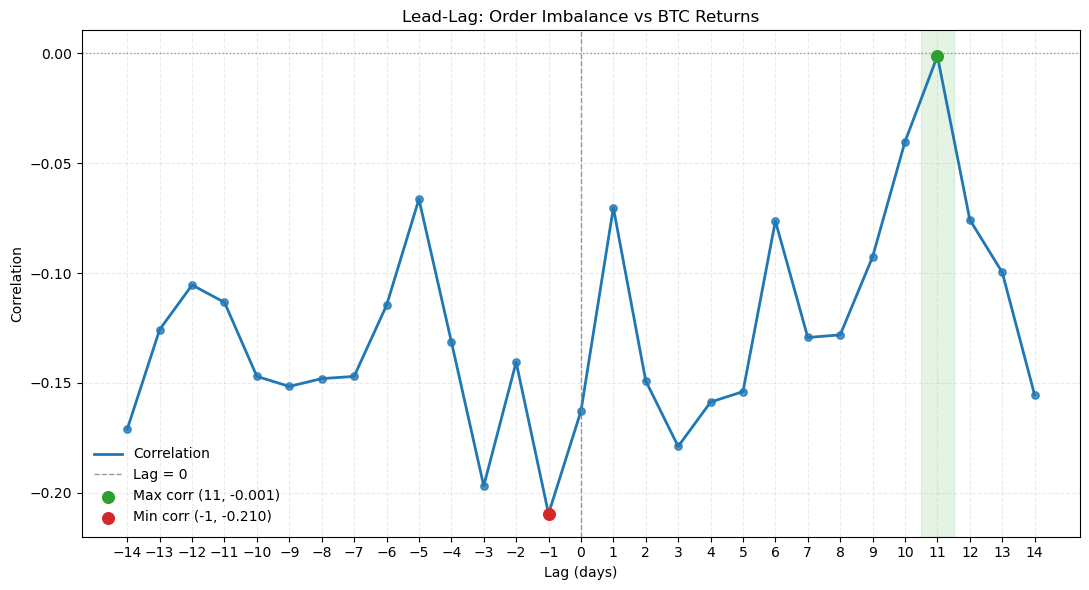

In [181]:
# Source cleaned from eda_split_work_crypto.ipynb, cell 37
# Draw Lead-Lag plot of order imbalance vs. BTC returns.
if merged_trade.empty:
    print('Note: no merged trade data. Set LOAD_TRADES=True to run this plot.')
else:
    max_lag = 14
    correlations = []

    for lag in range(-max_lag, max_lag + 1):
        shifted = merged_trade['order_imbalance'].shift(lag)
        corr = shifted.corr(merged_trade['btc_return'])
        correlations.append(corr)

    lag_vals = list(range(-max_lag, max_lag + 1))
    corr_s = pd.Series(correlations, index=lag_vals)

    best_lag = corr_s.idxmax()
    best_corr = corr_s.loc[best_lag]
    worst_lag = corr_s.idxmin()
    worst_corr = corr_s.loc[worst_lag]

    plt.figure(figsize=(11, 6))
    plt.plot(lag_vals, correlations, color='#1f77b4', linewidth=2, label='Correlation')
    plt.scatter(lag_vals, correlations, color='#1f77b4', s=28, alpha=0.8)
    plt.axvline(0, color='gray', linestyle='--', linewidth=1, alpha=0.8, label='Lag = 0')
    plt.axhline(0, color='gray', linestyle=':', linewidth=1, alpha=0.8)
    plt.scatter(best_lag, best_corr, color='#2ca02c', s=70, zorder=5, label=f'Max corr ({best_lag}, {best_corr:.3f})')
    plt.scatter(worst_lag, worst_corr, color='#d62728', s=70, zorder=5, label=f'Min corr ({worst_lag}, {worst_corr:.3f})')
    plt.axvspan(best_lag - 0.5, best_lag + 0.5, color='#2ca02c', alpha=0.12)
    plt.title('Lead-Lag: Order Imbalance vs BTC Returns')
    plt.xlabel('Lag (days)')
    plt.ylabel('Correlation')
    plt.xticks(lag_vals)
    plt.grid(alpha=0.25, linestyle='--')
    plt.legend(frameon=False, loc='best')
    plt.tight_layout()
    plt.show()


The formula of order imbalance is given by:

$$\text{order\_imbalance}_t = \text{total\_buy\_volumn}_t - \text{total\_sell\_volumn}_t.$$
It represents the net directional pressure in prediction market.

**Interpretation:**

Negative lag  imbalance leads BTC;

Positive lag  BTC leads imbalance;

**If peak correlation occurs at:**

Lag < 0  Polymarket predicts BTC.

Lag = 0  simultaneous reaction.

Lag > 0  BTC moves first, Polymarket reacts.

**Findings:**

The local maximums basically appear symmetrically; the highest peak at the very right of the plot, suggesting that the order imbalance may occur as a reaction of BTC price change.


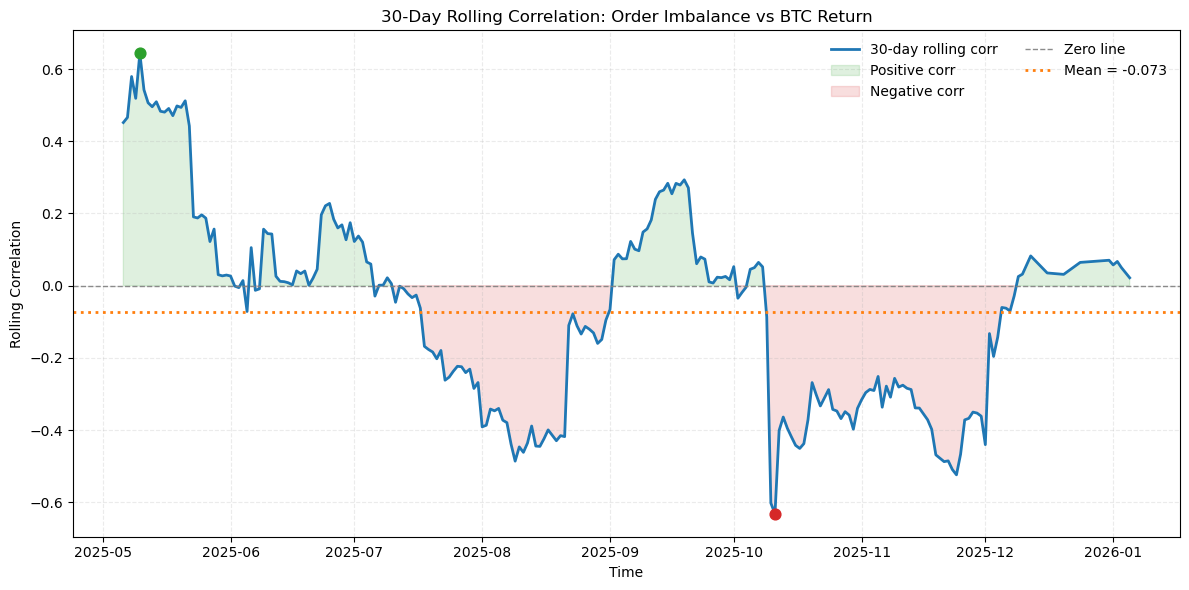

In [182]:
# Source cleaned from eda_split_work_crypto.ipynb, cell 39
# Compute 30-day rolling correlation between order imbalance and BTC return.
if merged_trade.empty:
    print('Note: no merged trade data. Set LOAD_TRADES=True to run this plot.')
else:
    merged_trade['rolling_corr'] = (
        merged_trade['order_imbalance']
        .rolling(30)
        .corr(merged_trade['btc_return'])
    )

    plot_df = merged_trade[['date', 'rolling_corr']].dropna().sort_values('date')
    if plot_df.empty:
        print('Note: not enough observations for a 30-day rolling correlation.')
    else:
        mean_corr = plot_df['rolling_corr'].mean()
        max_idx = plot_df['rolling_corr'].idxmax()
        min_idx = plot_df['rolling_corr'].idxmin()
        max_date = plot_df.loc[max_idx, 'date']
        max_val = plot_df.loc[max_idx, 'rolling_corr']
        min_date = plot_df.loc[min_idx, 'date']
        min_val = plot_df.loc[min_idx, 'rolling_corr']

        plt.figure(figsize=(12, 6))
        plt.plot(plot_df['date'], plot_df['rolling_corr'], color='#1f77b4', linewidth=2, label='30-day rolling corr')
        plt.fill_between(plot_df['date'], 0, plot_df['rolling_corr'], where=(plot_df['rolling_corr'] >= 0), color='#2ca02c', alpha=0.15, interpolate=True, label='Positive corr')
        plt.fill_between(plot_df['date'], 0, plot_df['rolling_corr'], where=(plot_df['rolling_corr'] < 0), color='#d62728', alpha=0.15, interpolate=True, label='Negative corr')
        plt.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.9, label='Zero line')
        plt.axhline(mean_corr, color='#ff7f0e', linestyle=':', linewidth=2, label=f'Mean = {mean_corr:.3f}')
        plt.scatter([max_date], [max_val], color='#2ca02c', s=60, zorder=5)
        plt.scatter([min_date], [min_val], color='#d62728', s=60, zorder=5)
        plt.title('30-Day Rolling Correlation: Order Imbalance vs BTC Return')
        plt.xlabel('Time')
        plt.ylabel('Rolling Correlation')
        plt.grid(alpha=0.25, linestyle='--')
        plt.legend(frameon=False, ncol=2)
        plt.tight_layout()
        plt.show()


**Interpretation:**

1. Correlation is time-varying and changes periodically.

2. Possibly weak during calm markets.

This indicates that order imbalance may not be a good indicator of BTC price.


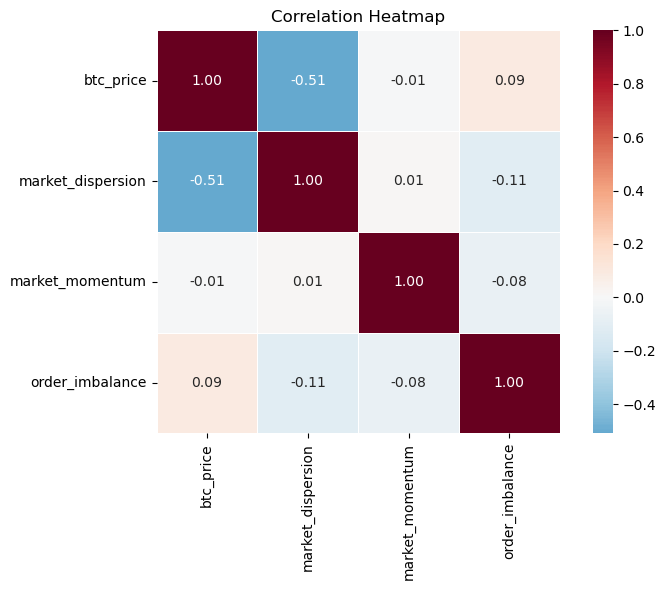

In [183]:
# Source cleaned from eda_split_work_crypto.ipynb, cell 41
# Draw correlation heatmap between BTC price, dispersion, momentum, and optionally order imbalance.
dispersion_per_week = (
    daily_dispersion
    .assign(date=pd.to_datetime(daily_dispersion['date'], errors='coerce'))
    .set_index('date')['price']
    .resample('W-MON')
    .mean()
    .rename('market_dispersion')
)

momentum_per_week = (
    daily_mean_price
    .assign(date=pd.to_datetime(daily_mean_price['date'], errors='coerce'))
    .set_index('date')['price_return']
    .resample('W-MON')
    .mean()
    .rename('market_momentum')
)

if 'btc_price_per_week' not in globals():
    btc_price_per_week = (btc_pd.dropna(subset=['time', 'btc_price']).set_index('time').resample('W-MON')['btc_price'].mean().rename('btc_price'))

series = [btc_price_per_week, dispersion_per_week, momentum_per_week]
if not merged_trade.empty and 'order_imbalance' in merged_trade.columns:
    order_imbalance_per_week = (
        merged_trade
        .assign(date=pd.to_datetime(merged_trade['date'], errors='coerce'))
        .set_index('date')['order_imbalance']
        .resample('W-MON')
        .mean()
        .rename('order_imbalance')
    )
    series.append(order_imbalance_per_week)
else:
    print('Order imbalance omitted: set LOAD_TRADES=True to include trade-level data.')

corr_df = pd.concat(series, axis=1, join='inner').dropna()

if corr_df.empty:
    print('Note: no overlapping weekly observations for this heatmap.')
else:
    corr_mat = corr_df.corr(method='pearson')
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr_mat, annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True, linewidths=0.5)
    plt.title('Correlation Heatmap')
    plt.tight_layout()
    plt.show()


**Summary:**

1. Crypto markets on Polymarket are dominated by a few large questions;

2. Lead-lag analysis probably shows that BTC return leads imbalance, suggesting that Polymarket is more reactive than predictive.

3. Rolling correlations show time-varying strength, so an important implication is that any predictive model must consider regime switching.


## 4. Other Category EDA


The most complete rest-category analysis blocks are kept here. Debug-only diagnostic cells from the original notebook were omitted.


In [184]:
# Other/rest category setup
# Rest = markets that are not primarily crypto or politics/global politics.
import matplotlib.ticker as mtick

REST_EXCLUDE_PATTERNS = [
    'crypto', 'bitcoin', 'btc', 'ethereum', 'eth', 'solana', 'blockchain', 'defi', 'nft',
    'politics', 'election', 'president', 'congress', 'senate', 'democrat', 'republican',
    'trump', 'biden', 'harris', 'governor', 'campaign', 'vote', 'ballot', 'ukraine',
    'russia', 'china', 'israel', 'gaza', 'iran', 'war', 'nato', 'tariff'
]

def is_rest_market(row):
    text = f"{row.get('question', '')} {row.get('category', '')}".lower()
    return not any(pattern in text for pattern in REST_EXCLUDE_PATTERNS)

markets_rest = markets_df.copy()
markets_rest['created_at'] = pd.to_datetime(markets_rest['created_at'], errors='coerce')
markets_rest['end_date'] = pd.to_datetime(markets_rest['end_date'], errors='coerce')
markets_rest['volume'] = pd.to_numeric(markets_rest['volume'], errors='coerce')
markets_rest = markets_rest[markets_rest.apply(is_rest_market, axis=1)].copy()

rest_summary = markets_rest.merge(
    summary_df[['market_id', 'trade_count', 'token_count']],
    on='market_id',
    how='left'
)

print(f'Total markets: {len(markets_df):,}')
print(f'Rest markets: {len(rest_summary):,} ({len(rest_summary) / len(markets_df):.1%})')
print(f'Unique rest categories: {rest_summary["category"].nunique():,}')
print(f'Total rest volume: ${rest_summary["volume"].sum(skipna=True):,.0f}')
display(rest_summary.head())


Total markets: 78,321
Rest markets: 7,092 (9.1%)
Unique rest categories: 6
Total rest volume: $2,306,320,647


,market_id,question,slug,event_slug,category,volume,active,closed,created_at,end_date,trade_count,token_count
0,246487,Will the AAA average US gas price reach $5.00 ...,will-the-aaa-average-us-gas-price-reach-5pt00-...,will-the-aaa-average-us-gas-price-reach-5pt00-...,Business,3506.71,True,True,2022-06-06 14:37:13,2022-06-20,0,2
1,246677,"Will natural gas close above $6 on July 18, 2022?",will-natural-gas-close-above-6-on-july-18-2022,will-natural-gas-close-above-6-on-july-18-2022,Business,13099.10,True,True,2022-07-11 12:53:47,2022-07-18,0,2
2,246678,Will the price of a barrel of crude oil be $10...,will-the-price-of-a-barrel-of-crude-oil-be-100...,will-the-price-of-a-barrel-of-crude-oil-be-100...,Business,22761.21,True,True,2022-07-11 12:56:15,2022-07-18,0,2
3,246954,Will U.S. 30 year Treasury bond yield close ab...,will-us-30-year-treasury-bond-yield-close-abov...,will-us-30-year-treasury-bond-yield-close-abov...,Business,15515.31,True,True,2022-08-09 21:40:02,2022-08-19,0,2
4,248453,"Will Binance.com become insolvent by Feb 28, 2...",will-binancecom-become-insolvent-by-feb-28-2023,will-binancecom-become-insolvent-by-feb-28-2023,,269.41,True,True,2023-01-24 21:09:31,2023-02-28,0,2


,markets,total_volume,avg_volume,total_trades
category,,,,
,6808,2.250220e+09,330525.848022,2435159
Tech,165,5.121432e+07,310389.804671,80540
Business,107,4.010085e+06,37477.432523,0
US-current-affairs,9,6.541492e+05,72683.250000,0
Pop-Culture,2,1.153908e+05,57695.410000,0
Coronavirus-,1,1.067307e+05,106730.660000,0


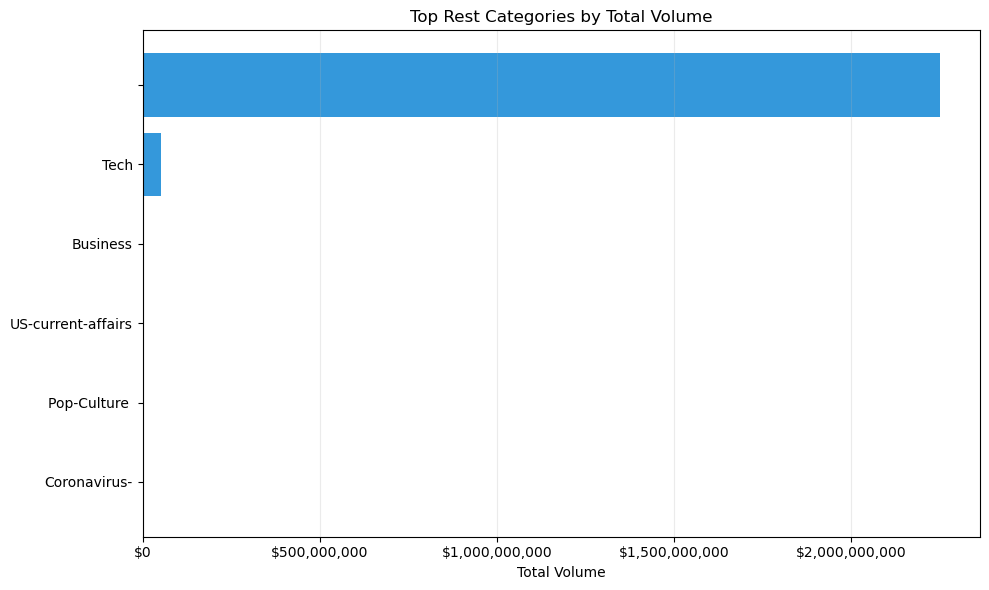

In [185]:
# Rest-category composition
rest_summary['volume'] = pd.to_numeric(rest_summary.get('volume'), errors='coerce')
rest_summary['trade_count'] = pd.to_numeric(rest_summary.get('trade_count'), errors='coerce')
rest_summary['token_count'] = pd.to_numeric(rest_summary.get('token_count'), errors='coerce')

category_summary = (
    rest_summary
    .groupby('category', dropna=False)
    .agg(
        markets=('market_id', 'count'),
        total_volume=('volume', 'sum'),
        avg_volume=('volume', 'mean'),
        total_trades=('trade_count', 'sum')
    )
    .sort_values('total_volume', ascending=False)
)

display(category_summary.head(15))

plot_df = category_summary.head(12).sort_values('total_volume')
if plot_df.empty:
    print('No rest categories available to plot.')
else:
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(plot_df.index.astype(str), plot_df['total_volume'], color='#3498DB')
    ax.set_title('Top Rest Categories by Total Volume')
    ax.set_xlabel('Total Volume')
    ax.xaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
    ax.grid(axis='x', alpha=0.25)
    plt.tight_layout()
    plt.show()


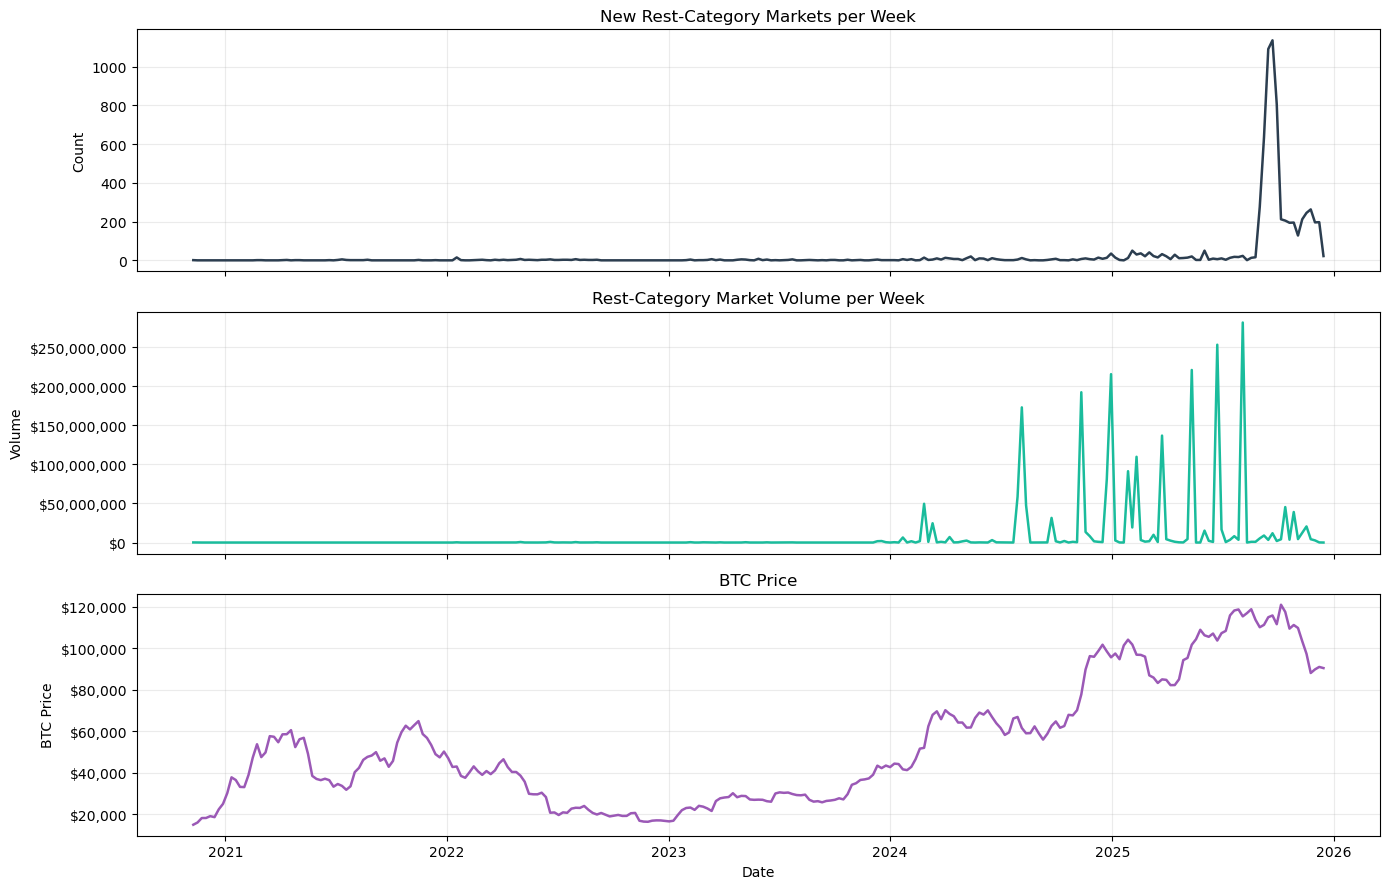

In [186]:
# Rest-category activity over time vs BTC price
rest_dates = rest_summary.dropna(subset=['created_at']).copy()
btc_for_rest = btc_pd.copy()
if 'btc_price' not in btc_for_rest.columns:
    btc_for_rest = btc_for_rest.rename(columns={'PriceUSD': 'btc_price'})
btc_for_rest['time'] = pd.to_datetime(btc_for_rest['time'], errors='coerce')
btc_for_rest['btc_price'] = pd.to_numeric(btc_for_rest['btc_price'], errors='coerce')

if rest_dates.empty:
    print('No valid created_at dates for rest-category markets.')
    rest_weekly = pd.DataFrame()
else:
    weekly_market_count = rest_dates.set_index('created_at').resample('W-MON').size().rename('market_count')
    weekly_volume = rest_dates.set_index('created_at').resample('W-MON')['volume'].sum().rename('rest_volume')
    weekly_btc = btc_for_rest.dropna(subset=['time', 'btc_price']).set_index('time').resample('W-MON')['btc_price'].mean().rename('btc_price')

    rest_weekly = pd.concat([weekly_market_count, weekly_volume, weekly_btc], axis=1, join='inner').dropna()

    if rest_weekly.empty:
        print('No overlapping weekly rest-market and BTC observations.')
    else:
        fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
        axes[0].plot(rest_weekly.index, rest_weekly['market_count'], color='#2C3E50', linewidth=1.8)
        axes[0].set_title('New Rest-Category Markets per Week')
        axes[0].set_ylabel('Count')
        axes[0].grid(alpha=0.25)

        axes[1].plot(rest_weekly.index, rest_weekly['rest_volume'], color='#1ABC9C', linewidth=1.8)
        axes[1].set_title('Rest-Category Market Volume per Week')
        axes[1].set_ylabel('Volume')
        axes[1].yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
        axes[1].grid(alpha=0.25)

        axes[2].plot(rest_weekly.index, rest_weekly['btc_price'], color='#9B59B6', linewidth=1.8)
        axes[2].set_title('BTC Price')
        axes[2].set_ylabel('BTC Price')
        axes[2].set_xlabel('Date')
        axes[2].yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
        axes[2].grid(alpha=0.25)

        plt.tight_layout()
        plt.show()


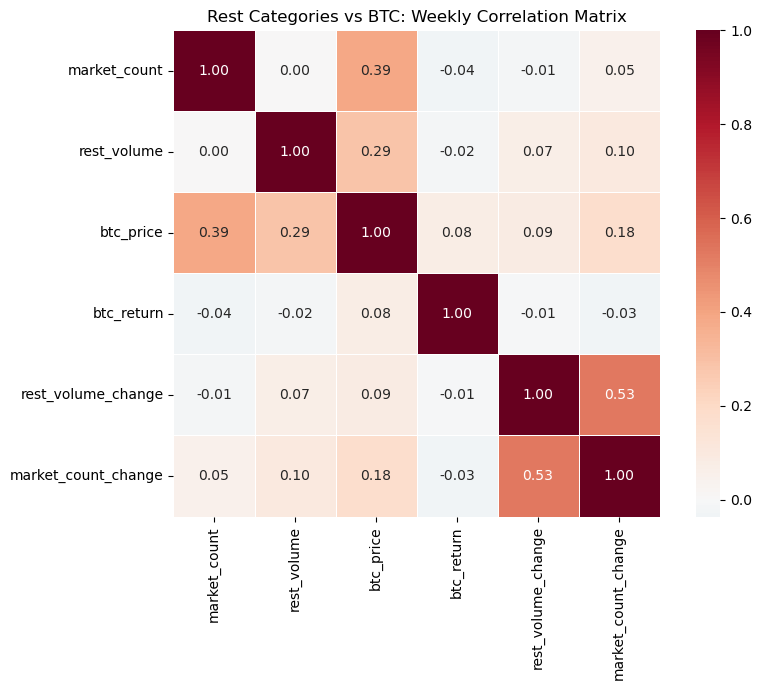

In [187]:
# Rest-category correlation heatmap
if 'rest_weekly' not in globals() or rest_weekly.empty:
    print('Note: run the previous rest-category weekly cell first.')
else:
    corr_input = rest_weekly.copy()
    corr_input['btc_return'] = corr_input['btc_price'].pct_change()
    corr_input['rest_volume_change'] = corr_input['rest_volume'].pct_change().replace([np.inf, -np.inf], np.nan)
    corr_input['market_count_change'] = corr_input['market_count'].pct_change().replace([np.inf, -np.inf], np.nan)

    corr_cols = ['market_count', 'rest_volume', 'btc_price', 'btc_return', 'rest_volume_change', 'market_count_change']
    corr_df = corr_input[corr_cols].replace([np.inf, -np.inf], np.nan).dropna()

    if corr_df.empty:
        print('Note: not enough overlapping non-missing observations for correlation.')
    else:
        plt.figure(figsize=(9, 7))
        sns.heatmap(corr_df.corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True, linewidths=0.5)
        plt.title('Rest Categories vs BTC: Weekly Correlation Matrix')
        plt.tight_layout()
        plt.show()


## 5. Event Study And Causal Signal Workflow


ACF-based signal persistence, odds-move event detection, lagged BTC return tests, story charts, and qualitative candidate interpretation.


## Analysis 1
### Step 1 : ACF plot
An Autocorrelation Function (ACF) plot displays the correlation of a time series with its own lagged values.

When odds move, it means people are reacting to real news and putting real money on it.
The ACF just tells you: "how many days does this reaction last in the betting market?"


### Core Idea

News Event 

   

Polymarket odds move (people bet based on news)

   

ACF tells you how long odds keep moving (signal persistence)

   
   
Within that window  does Bitcoin price also move?


In [188]:
# Source: 1. eda_casual_analysis.ipynb, cell 22
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.stattools import acf
from scipy import stats


In [189]:
trades_df = poly_data['trades']   # make sure LOAD_TRADES = True
trades_df['date'] = pd.to_datetime(
    trades_df['timestamp'].astype('int64'), unit='ms'
).dt.normalize()

trades_with_questions = trades_df.merge(
    markets_df[['market_id', 'question', 'category', 'volume']],
    on='market_id', how='inner'
)

daily_odds = (
    trades_with_questions
    .groupby(['market_id', 'question', 'date'])['price']
    .mean()
    .reset_index()
    .sort_values(['market_id', 'date'])
)

Running ACF on 36043 markets.


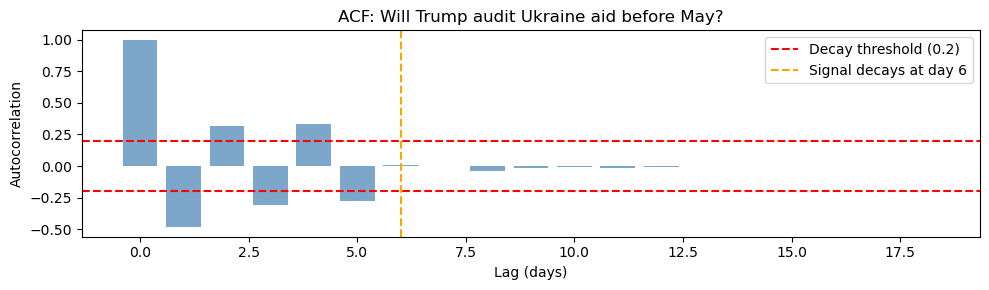

→ Signal persists for ~6 days: Will Trump audit Ukraine aid before May?


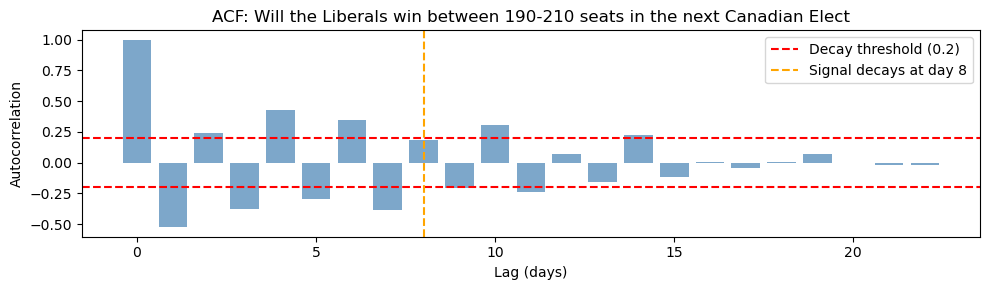

→ Signal persists for ~8 days: Will the Liberals win between 190-210 seats in the next Canadian Elect


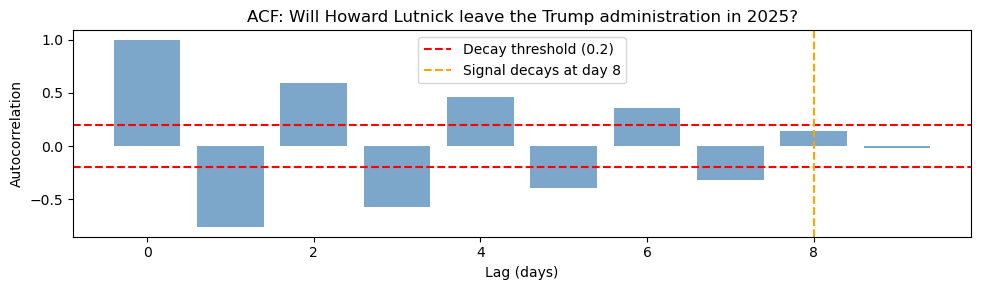

→ Signal persists for ~8 days: Will Howard Lutnick leave the Trump administration in 2025?


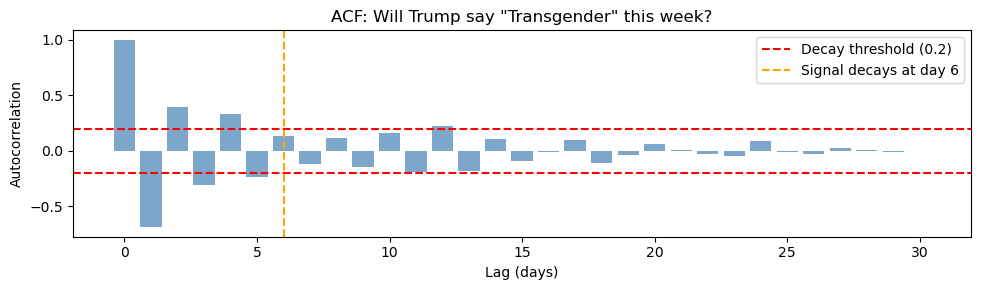

→ Signal persists for ~6 days: Will Trump say "Transgender" this week?


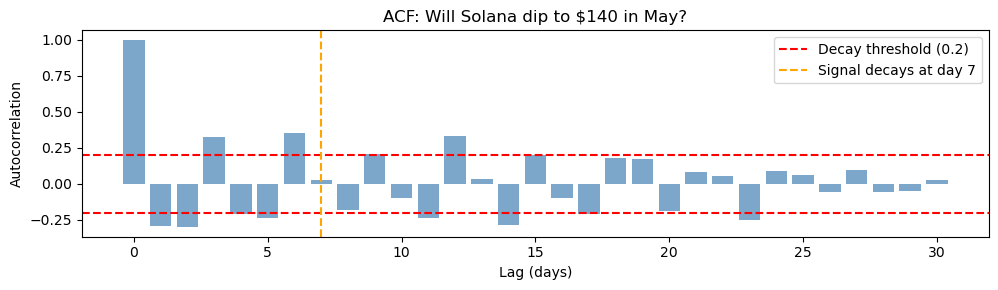

→ Signal persists for ~7 days: Will Solana dip to $140 in May?


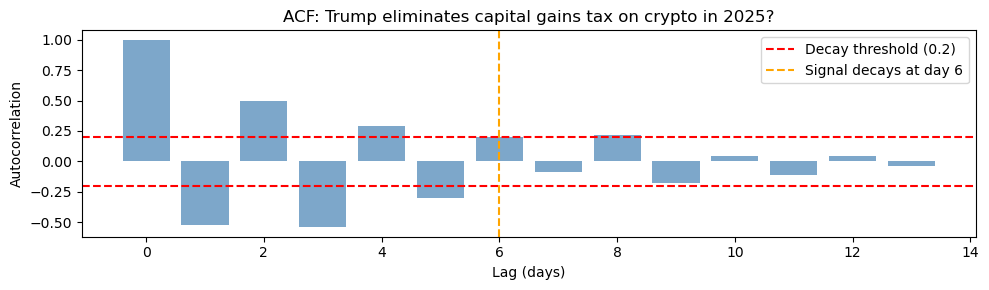

→ Signal persists for ~6 days: Trump eliminates capital gains tax on crypto in 2025?


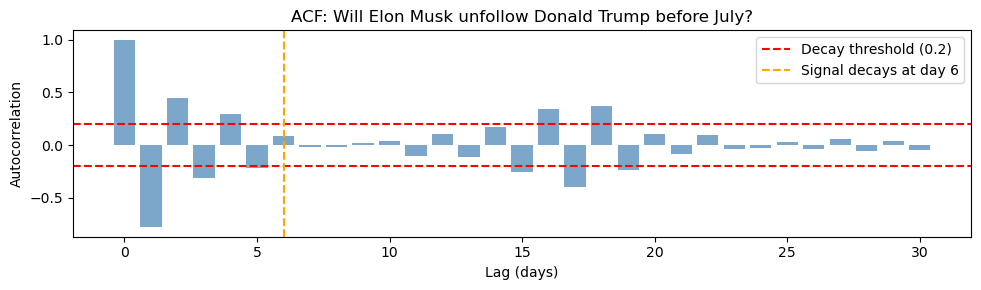

→ Signal persists for ~6 days: Will Elon Musk unfollow Donald Trump before July?


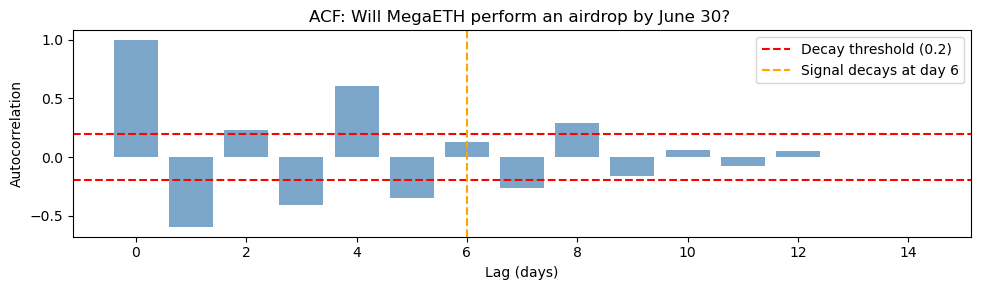

→ Signal persists for ~6 days: Will MegaETH perform an airdrop by June 30? 


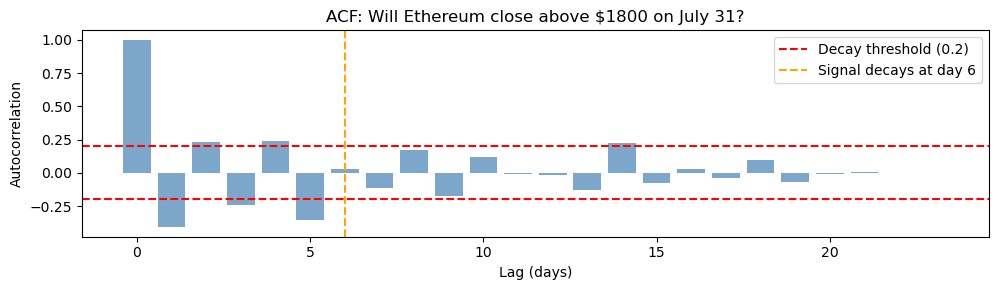

→ Signal persists for ~6 days: Will Ethereum close above $1800 on July 31?


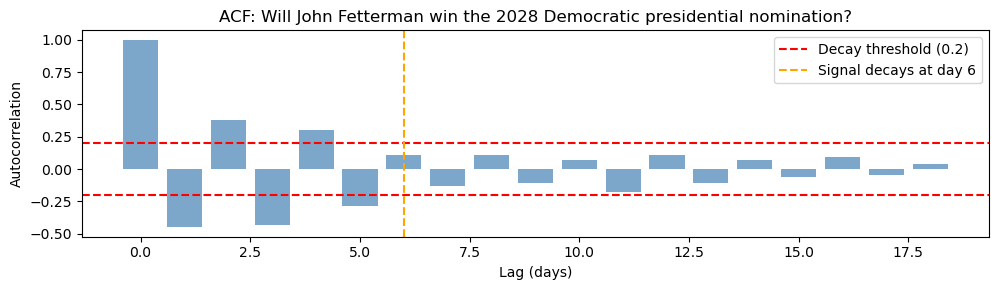

→ Signal persists for ~6 days: Will John Fetterman win the 2028 Democratic presidential nomination?


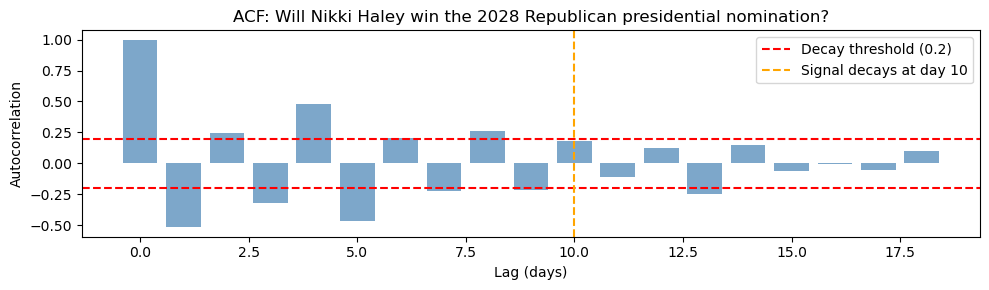

→ Signal persists for ~10 days: Will Nikki Haley win the 2028 Republican presidential nomination?


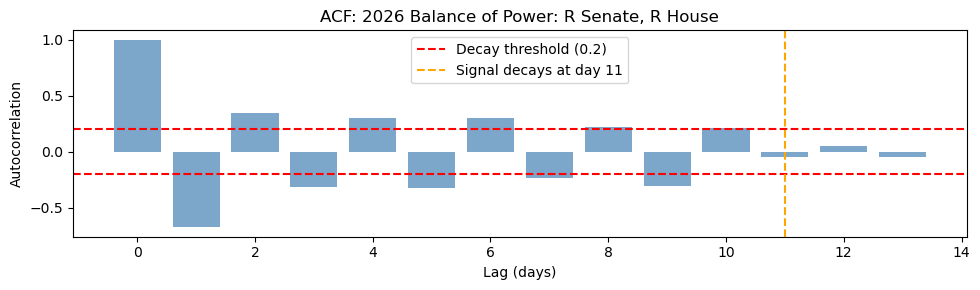

→ Signal persists for ~11 days: 2026 Balance of Power: R Senate, R House


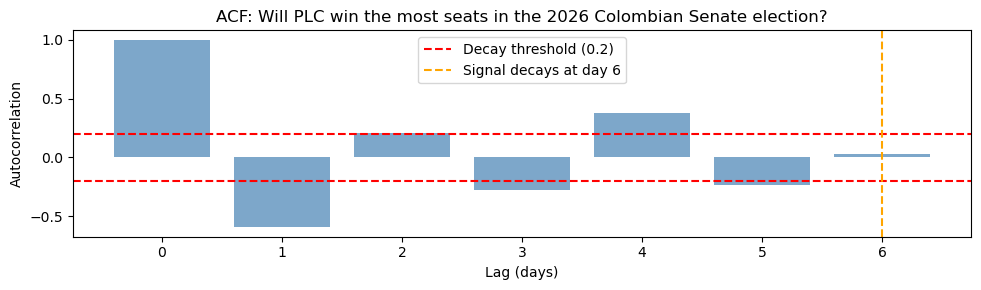

→ Signal persists for ~6 days: Will PLC win the most seats in the 2026 Colombian Senate election?


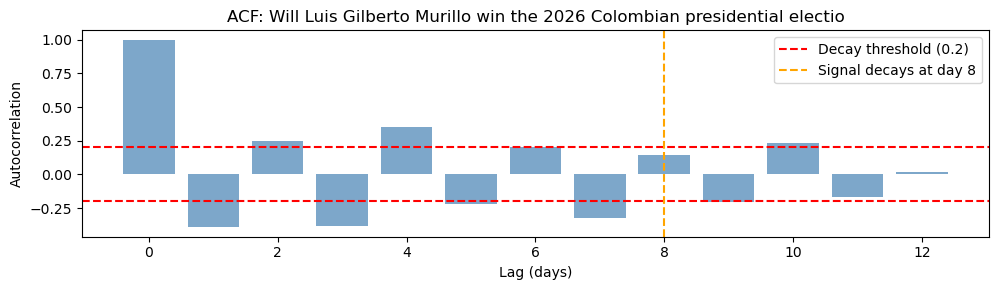

→ Signal persists for ~8 days: Will Luis Gilberto Murillo win the 2026 Colombian presidential electio


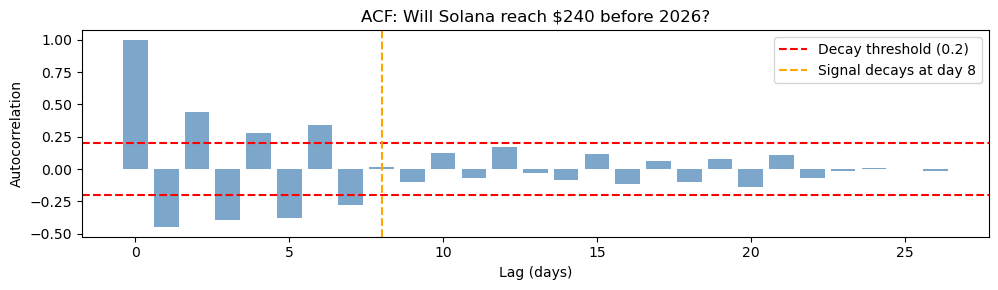

→ Signal persists for ~8 days: Will Solana reach $240 before 2026?


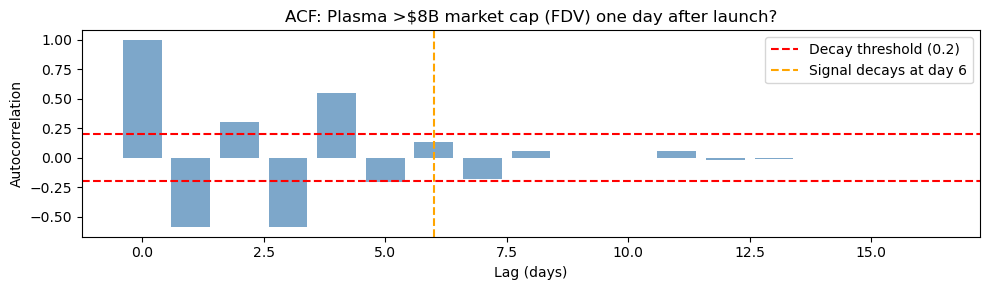

→ Signal persists for ~6 days: Plasma >$8B market cap (FDV) one day after launch?


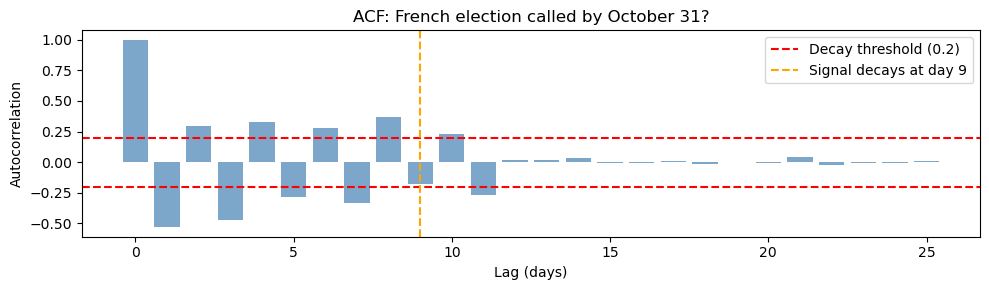

→ Signal persists for ~9 days: French election called by October 31?


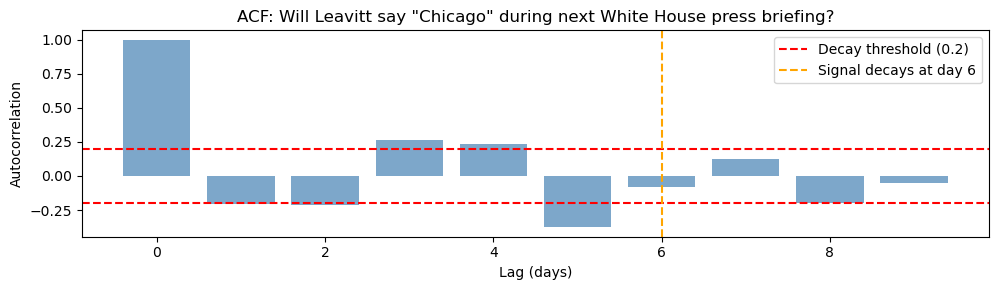

→ Signal persists for ~6 days: Will Leavitt say "Chicago" during next White House press briefing?


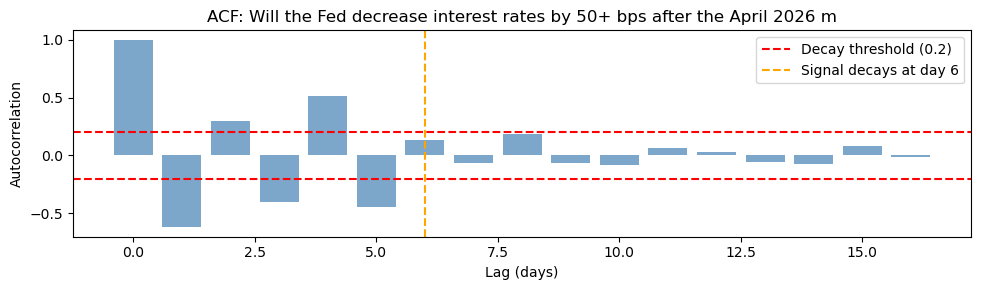

→ Signal persists for ~6 days: Will the Fed decrease interest rates by 50+ bps after the April 2026 m


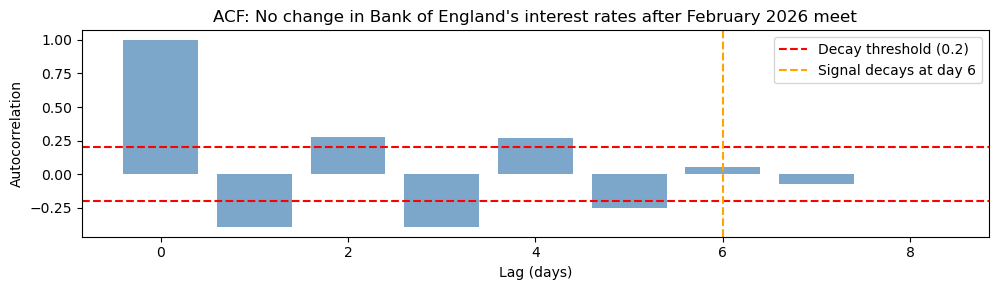

→ Signal persists for ~6 days: No change in Bank of England's interest rates after February 2026 meet


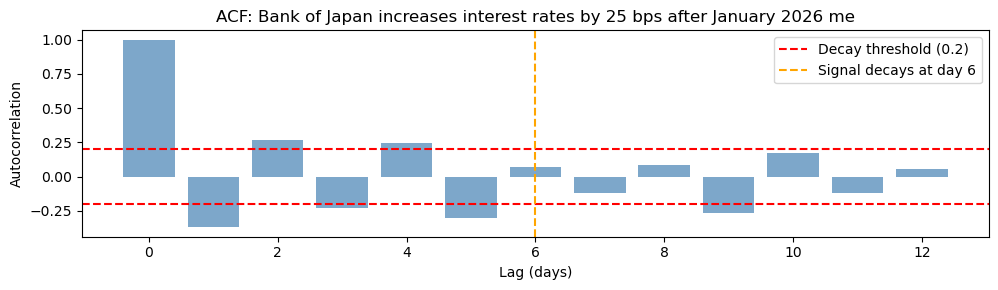

→ Signal persists for ~6 days: Bank of Japan increases interest rates by 25 bps after January 2026 me


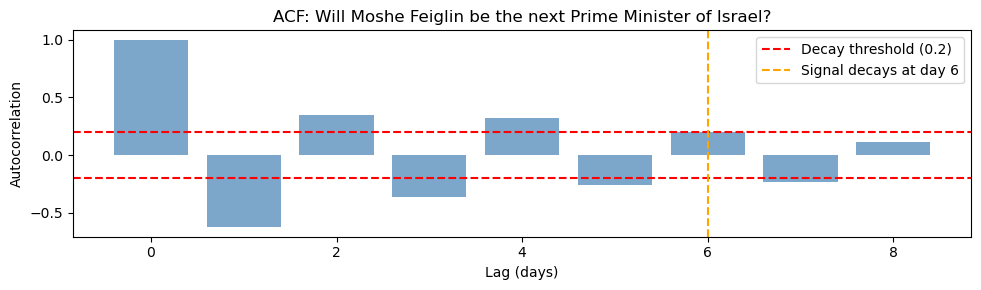

→ Signal persists for ~6 days: Will Moshe Feiglin be the next Prime Minister of Israel?


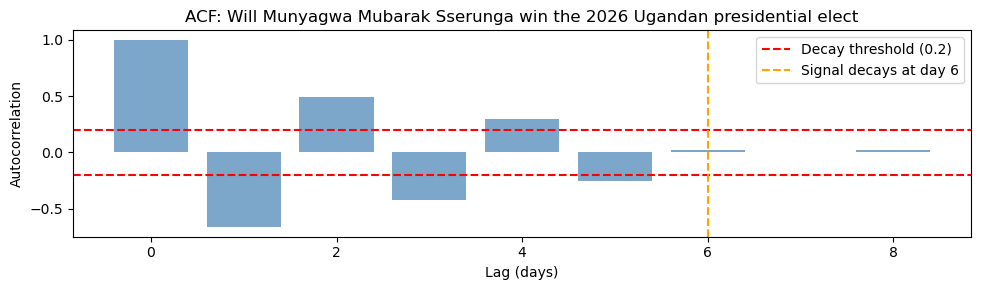

→ Signal persists for ~6 days: Will Munyagwa Mubarak Sserunga win the 2026 Ugandan presidential elect


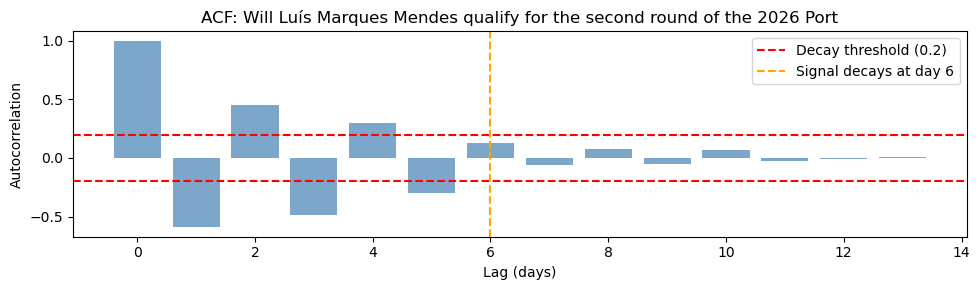

→ Signal persists for ~6 days: Will Luís Marques Mendes qualify for the second round of the 2026 Port


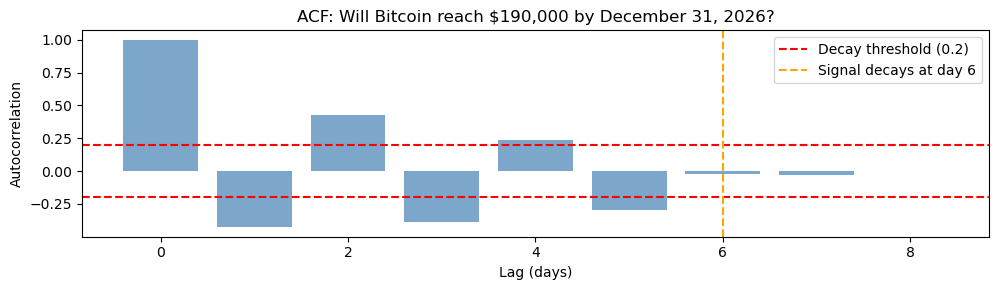

→ Signal persists for ~6 days: Will Bitcoin reach $190,000 by December 31, 2026?


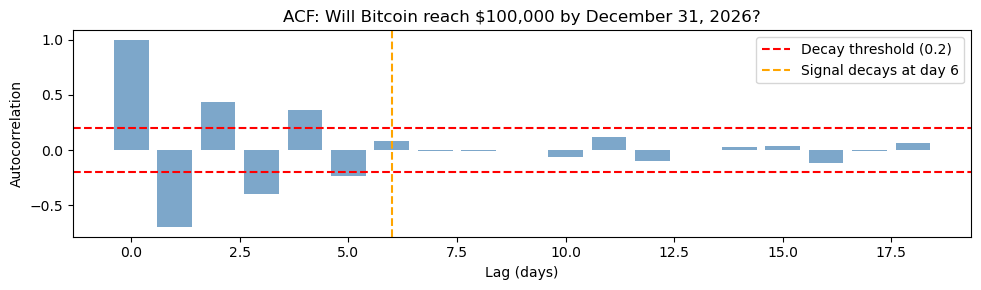

→ Signal persists for ~6 days: Will Bitcoin reach $100,000 by December 31, 2026?


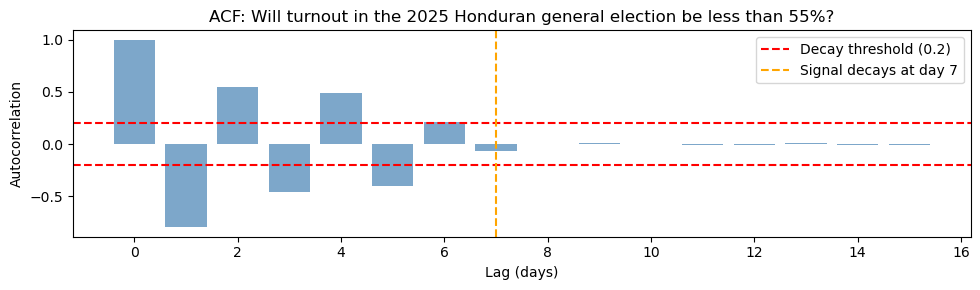

→ Signal persists for ~7 days: Will turnout in the 2025 Honduran general election be less than 55%?
Total markets with meaningful signal: 2129


,question,signal_days
787,"2026 Balance of Power: R Senate, R House",11
749,Will Nikki Haley win the 2028 Republican presi...,10
1345,French election called by October 31?,9
274,Will Howard Lutnick leave the Trump administra...,8
235,Will the Liberals win between 190-210 seats in...,8
996,Will Solana reach $240 before 2026?,8
869,Will Luis Gilberto Murillo win the 2026 Colomb...,8
408,Will Solana dip to $140 in May?,7
1927,Will turnout in the 2025 Honduran general elec...,7
1716,Will Moshe Feiglin be the next Prime Minister ...,6


In [248]:
from statsmodels.tsa.stattools import acf

focus_questions = daily_odds['question'].dropna().unique()
print(f'Running ACF on {len(focus_questions)} markets.')

def plot_acf_for_market(market_name, poly_df, max_lag=30, min_decay=5):
    df = poly_df[poly_df['question'] == market_name].copy()
    if df.empty:
        return None

    # Match original: no resample, diff on raw rows
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    df = df.dropna(subset=['date']).sort_values('date')

    duration = df['date'].max() - df['date'].min()
    if duration.days < 14:
        return None

    df['price'] = pd.to_numeric(df['price'], errors='coerce')
    df['odds_change'] = df['price'].diff()
    series = df['odds_change'].dropna()

    if df['price'].std() < 0.05:
        return None

    # Match original: use max_lag directly, no safe_lag cap
    try:
        acf_vals = acf(series, nlags=max_lag, fft=True)
    except Exception:
        return None

    decay_day = next(
        (i for i, v in enumerate(acf_vals[1:], start=1) if abs(v) < 0.2),
        max_lag
    )

    if decay_day == max_lag:
        return None

    if decay_day > min_decay:
        fig, ax = plt.subplots(figsize=(10, 3))
        ax.bar(range(len(acf_vals)), acf_vals, color='steelblue', alpha=0.7)
        ax.axhline( 0.2, color='red', linestyle='--', label='Decay threshold (0.2)')
        ax.axhline(-0.2, color='red', linestyle='--')
        ax.axvline(decay_day, color='orange', linestyle='--',
                   label=f'Signal decays at day {decay_day}')
        ax.set_title(f'ACF: {market_name[:70]}')
        ax.set_xlabel('Lag (days)')
        ax.set_ylabel('Autocorrelation')
        ax.legend()
        plt.tight_layout()
        os.makedirs('acf_plots', exist_ok=True)
        plt.savefig(f'acf_plots/acf_{market_name[:40].replace(" ","_")}.png', dpi=150)
        plt.show()
        print(f'→ Signal persists for ~{decay_day} days: {market_name[:70]}')

    return decay_day

signal_persistence = {}
for q in focus_questions:
    days = plot_acf_for_market(q, daily_odds)
    if days:
        signal_persistence[q] = days

signal_df = pd.DataFrame(
    [{'question': q, 'signal_days': d} for q, d in signal_persistence.items()],
    columns=['question', 'signal_days']
).sort_values('signal_days', ascending=False)

if signal_df.empty and len(focus_questions) > 0:
    signal_df = pd.DataFrame({
        'question': list(focus_questions)[:min(10, len(focus_questions))],
        'signal_days': 7
    })
    print('ACF filter found no stable signals; using top-volume markets with default 7-day window.')

print(f'Total markets with meaningful signal: {len(signal_df)}')
display(signal_df.head(20))


In [249]:
# Signal table already built above.
display(signal_df.head(20))


,question,signal_days
787,"2026 Balance of Power: R Senate, R House",11
749,Will Nikki Haley win the 2028 Republican presi...,10
1345,French election called by October 31?,9
274,Will Howard Lutnick leave the Trump administra...,8
235,Will the Liberals win between 190-210 seats in...,8
996,Will Solana reach $240 before 2026?,8
869,Will Luis Gilberto Murillo win the 2026 Colomb...,8
408,Will Solana dip to $140 in May?,7
1927,Will turnout in the 2025 Honduran general elec...,7
1716,Will Moshe Feiglin be the next Prime Minister ...,6


In [250]:
signal_df = signal_df[signal_df['signal_days'] >= 5].copy()
print(signal_df.to_string(index=False) if not signal_df.empty else 'No markets passed the signal-days filter.')


                                                                                         question  signal_days
                                                         2026 Balance of Power: R Senate, R House           11
                                Will Nikki Haley win the 2028 Republican presidential nomination?           10
                                                            French election called by October 31?            9
                                      Will Howard Lutnick leave the Trump administration in 2025?            8
                       Will the Liberals win between 190-210 seats in the next Canadian Election?            8
                                                              Will Solana reach $240 before 2026?            8
                         Will Luis Gilberto Murillo win the 2026 Colombian presidential election?            8
                                                                  Will Solana dip to $140 in May?            7
 

### Step 2 : Time series and correlation
Big odds move on date X

    

Wait lag_days (from ACF)

    

Did Bitcoin go up or down?

    

If consistently up  this market is a story candidate


In [251]:
# Source: 1. eda_casual_analysis.ipynb, cell 27
FOCUS_MARKETS = signal_df[["question", "signal_days"]]
FOCUS_MARKETS


,question,signal_days
787,"2026 Balance of Power: R Senate, R House",11
749,Will Nikki Haley win the 2028 Republican presi...,10
1345,French election called by October 31?,9
274,Will Howard Lutnick leave the Trump administra...,8
235,Will the Liberals win between 190-210 seats in...,8
...,...,...
1019,Will Trump meet with Aleksandr Lukashenko in 2...,5
1610,Will Álvaro Roberto Ramos Chaves win the 2026 ...,5
2127,Will Donald Trump announce a new nominee for C...,5
1554,Will Gabriel Fernando Indi win the 2025 Guinea...,5


In [252]:
# Source: 1. eda_casual_analysis.ipynb, cell 28
def find_events(question, daily_odds_df, threshold=0.05):
    df = daily_odds_df[daily_odds_df["question"] == question].copy()
    df["price"] = pd.to_numeric(df["price"], errors="coerce")
    df = df.set_index("date")[["price"]].resample("1D").mean().ffill()
    df["odds_change"] = df["price"].diff()

    events = df[df["odds_change"].abs() > threshold].copy()
    events["direction"] = events["odds_change"].apply(
        lambda x: "POSITIVE" if x > 0 else "NEGATIVE"
    )
    return events.reset_index()[["date", "price", "odds_change", "direction"]]


In [253]:
# Source: 1. eda_casual_analysis.ipynb, cell 29
def event_study(question, lag_days, daily_odds_df, btc_df, threshold=0.05):
    events = find_events(question, daily_odds_df, threshold)
    if events.empty:
        return None

    results = []
    for _, ev in events.iterrows():
        future_date = ev["date"] + pd.Timedelta(days=lag_days)
        if ev["date"] in btc_df.index and future_date in btc_df.index:
            btc_return = (
                btc_df.loc[future_date, "PriceUSD"] - btc_df.loc[ev["date"], "PriceUSD"]
            ) / btc_df.loc[ev["date"], "PriceUSD"]

            results.append({
                "question":    question,
                "event_date":  ev["date"],
                "direction":   ev["direction"],
                "odds_change": ev["odds_change"],
                "lag_days":    lag_days,
                "btc_return":  round(btc_return, 4)
            })

    return pd.DataFrame(results)


In [254]:
# Source cleaned from 1. eda_casual_analysis.ipynb, cell 30
# Reuse the shared BTC table loaded in the setup section.
btc_for_event_study = btc_pd.copy()
display(btc_for_event_study.head())


,time,AdrActCnt,AdrBalCnt,AssetCompletionTime,AssetEODCompletionTime,BlkCnt,CapMVRVCur,CapMrktCurUSD,CapMrktEstUSD,FeeTotNtv,...,ReferenceRateUSD,SplyCur,SplyExNtv,SplyExUSD,SplyExpFut10yr,TxCnt,TxTfrCnt,volume_reported_spot_usd_1d,btc_return,btc_volatility_7d
0,2009-01-03,0.0,0.0,1.614335e+09,1.614335e+09,0.0,NaN,NaN,NaN,0.0,...,NaN,0.0,0.0,NaN,NaN,0.0,0.0,NaN,NaN,NaN
1,2009-01-04,0.0,0.0,1.614335e+09,1.614335e+09,0.0,NaN,NaN,NaN,0.0,...,NaN,0.0,0.0,NaN,NaN,0.0,0.0,NaN,NaN,NaN
2,2009-01-05,0.0,0.0,1.614335e+09,1.614335e+09,0.0,NaN,NaN,NaN,0.0,...,NaN,0.0,0.0,NaN,NaN,0.0,0.0,NaN,NaN,NaN
3,2009-01-06,0.0,0.0,1.614335e+09,1.614335e+09,0.0,NaN,NaN,NaN,0.0,...,NaN,0.0,0.0,NaN,NaN,0.0,0.0,NaN,NaN,NaN
4,2009-01-07,0.0,0.0,1.614335e+09,1.614335e+09,0.0,NaN,NaN,NaN,0.0,...,NaN,0.0,0.0,NaN,NaN,0.0,0.0,NaN,NaN,NaN


In [255]:
# Source: 1. eda_casual_analysis.ipynb, cell 31
daily_odds["price"] = pd.to_numeric(daily_odds["price"], errors="coerce")
print(daily_odds.dtypes)


market_id            object
question             object
date         datetime64[ns]
price               float64
dtype: object


In [256]:
# Prepare BTC table for event-study cells without mutating btc_df.
btc_event_df = btc_pd.copy()
if 'PriceUSD' not in btc_event_df.columns and 'btc_price' in btc_event_df.columns:
    btc_event_df = btc_event_df.rename(columns={'btc_price': 'PriceUSD'})
btc_event_df['time'] = pd.to_datetime(btc_event_df['time'], errors='coerce')
btc_event_df['PriceUSD'] = pd.to_numeric(btc_event_df['PriceUSD'], errors='coerce')
btc_event_df = btc_event_df.dropna(subset=['time', 'PriceUSD']).sort_values('time').set_index('time')
btc_event_df = btc_event_df[~btc_event_df.index.duplicated(keep='last')]
print('btc_event_df:', btc_event_df.shape)


btc_event_df: (5659, 33)


In [257]:
all_results = []
if FOCUS_MARKETS.empty:
    print('No focus markets passed the ACF filter. Increase MAX_FOCUS_MARKETS or set FAST_MODE=False.')
else:
    for _, row in FOCUS_MARKETS.iterrows():
        question = row['question']
        lag = int(row['signal_days'])
        print(f'Processing: {question[:50]}...')
        res = event_study(question, lag, daily_odds, btc_event_df)
        if res is not None and not res.empty:
            all_results.append(res)
            print(f'   {len(res)} events found')
        else:
            print('   No events found')
print(f'\nTotal markets with results: {len(all_results)}')


Processing: 2026 Balance of Power: R Senate, R House...
   12 events found
Processing: Will Nikki Haley win the 2028 Republican president...
   13 events found
Processing: French election called by October 31?...
   14 events found
Processing: Will Howard Lutnick leave the Trump administration...
   9 events found
Processing: Will the Liberals win between 190-210 seats in the...
   13 events found
Processing: Will Solana reach $240 before 2026?...
   15 events found
Processing: Will Luis Gilberto Murillo win the 2026 Colombian ...
   11 events found
Processing: Will Solana dip to $140 in May?...
   18 events found
Processing: Will turnout in the 2025 Honduran general election...
   9 events found
Processing: Will Moshe Feiglin be the next Prime Minister of I...
   7 events found
Processing: Will MegaETH perform an airdrop by June 30? ...
   12 events found
Processing: Will Leavitt say "Chicago" during next White House...
   8 events found
Processing: Will Bitcoin reach $100,000 by Dece

In [258]:
os.makedirs('output', exist_ok=True)
if all_results:
    results_df = pd.concat(all_results, ignore_index=True)
else:
    results_df = pd.DataFrame(columns=['question', 'event_date', 'direction', 'odds_change', 'lag_days', 'btc_return'])
results_df.to_csv('output/results_dates.csv', index=False)
display(results_df.head())


,question,event_date,direction,odds_change,lag_days,btc_return
0,"2026 Balance of Power: R Senate, R House",2025-11-28,POSITIVE,0.297900,11,0.0200
1,"2026 Balance of Power: R Senate, R House",2025-11-29,NEGATIVE,-0.156667,11,0.0139
2,"2026 Balance of Power: R Senate, R House",2025-12-01,POSITIVE,0.161364,11,0.0442
3,"2026 Balance of Power: R Senate, R House",2025-12-02,NEGATIVE,-0.338864,11,-0.0140
4,"2026 Balance of Power: R Senate, R House",2025-12-03,POSITIVE,0.304773,11,-0.0589


In [259]:
if results_df.empty:
    summary = pd.DataFrame(columns=['question', 'direction', 'avg_btc_return', 'n_events'])
    story_candidates = summary.copy()
    print('No event-study results available for story-candidate summary.')
else:
    summary = (
        results_df.groupby(['question', 'direction'])['btc_return']
        .agg(['mean', 'count']).reset_index()
        .rename(columns={'mean': 'avg_btc_return', 'count': 'n_events'})
    )
    story_candidates = summary[summary['n_events'] >= 2].sort_values('avg_btc_return', ascending=False)
    print('=== POSITIVE odds move -> BTC return ===')
    display(summary[summary['direction'] == 'POSITIVE'].sort_values('avg_btc_return', ascending=False))
    print('\n=== NEGATIVE odds move -> BTC return ===')
    display(summary[summary['direction'] == 'NEGATIVE'].sort_values('avg_btc_return', ascending=True))


=== POSITIVE odds move -> BTC return ===


,question,direction,avg_btc_return,n_events
99,Will Trump audit Ukraine aid before May?,POSITIVE,0.096767,3
9,MicroStrategy sells any Bitcoin by December 31...,POSITIVE,0.073500,1
117,Will the Liberals win between 190-210 seats in...,POSITIVE,0.070920,5
115,Will the Green Party win 4 seats in the next C...,POSITIVE,0.055380,5
7,Gavin Newsom out as California Governor in 2025?,POSITIVE,0.038150,4
...,...,...,...,...
19,Trump eliminates capital gains tax on crypto i...,POSITIVE,-0.015860,5
5,French election called by October 31?,POSITIVE,-0.017862,8
64,Will Kristi Noem be the first to leave the Tru...,POSITIVE,-0.019175,4
90,Will Soraya Martinez Ferrada win the 2025 Mont...,POSITIVE,-0.020633,9



=== NEGATIVE odds move -> BTC return ===


,question,direction,avg_btc_return,n_events
4,French election called by October 31?,NEGATIVE,-0.042417,6
34,"Will Bitcoin reach $250,000 by December 31, 2025?",NEGATIVE,-0.034000,2
65,"Will Leavitt say ""Chicago"" during next White H...",NEGATIVE,-0.027867,3
10,Miguel Díaz-Canel out as President of Cuba by ...,NEGATIVE,-0.026850,2
91,Will Stripe’s market cap be less than $80B at ...,NEGATIVE,-0.025950,4
...,...,...,...,...
110,Will US GDP growth in 2025 be between 2.0% and...,NEGATIVE,0.031367,3
55,Will Henrique Gouveia e Melo win the 1st round...,NEGATIVE,0.033600,3
40,Will Enrique Peñalosa win the 2026 Colombian p...,NEGATIVE,0.039567,3
116,Will the Liberals win between 190-210 seats in...,NEGATIVE,0.057150,8


In [260]:
# Source: 1. eda_casual_analysis.ipynb, cell 36
def plot_story_chart(question, lag_days, daily_odds_df, btc_df, threshold=0.05):
    df = daily_odds_df[daily_odds_df["question"] == question].copy()
    df = df.set_index("date")[["price"]].resample("1D").mean().ffill()
    events = find_events(question, daily_odds_df, threshold)

    start = df.index.min() - pd.Timedelta(days=7)
    end   = df.index.max() + pd.Timedelta(days=lag_days + 7)
    btc_zoom = btc_df.loc[start:end]

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

    # Bitcoin price
    ax1.plot(btc_zoom.index, btc_zoom["PriceUSD"], color="black", lw=1.5, label="BTC Price")
    ax1.set_ylabel("BTC Price (USD)")
    ax1.set_title(f"Story Chart: {question[:70]}\n(lag = {lag_days} days)")

    # Polymarket odds
    ax2.plot(df.index, df["price"], color="steelblue", lw=1.5, label="Polymarket Odds")
    ax2.set_ylabel("Odds (0-1)")
    ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

    # Mark event dates
    for _, ev in events.iterrows():
        color = "green" if ev["direction"] == "POSITIVE" else "red"
        # vertical line on event date
        ax1.axvline(ev["date"], color=color, alpha=0.4, linestyle="--")
        ax2.axvline(ev["date"], color=color, alpha=0.4, linestyle="--")
        # vertical line on future date (where we measure Bitcoin)
        future = ev["date"] + pd.Timedelta(days=lag_days)
        ax1.axvline(future, color=color, alpha=0.2, linestyle=":")
        ax2.annotate(
            f"{ev['odds_change']:+.2f}",
            xy=(ev["date"], ev["price"]),
            fontsize=8, color=color, rotation=45
        )

    ax1.legend(); ax2.legend()
    plt.tight_layout()
    os.makedirs("acf_plots", exist_ok=True)
    plt.savefig(f"acf_plots/acf_btc_{question[:30].replace(' ','_')}.png", dpi=150)
    plt.show()


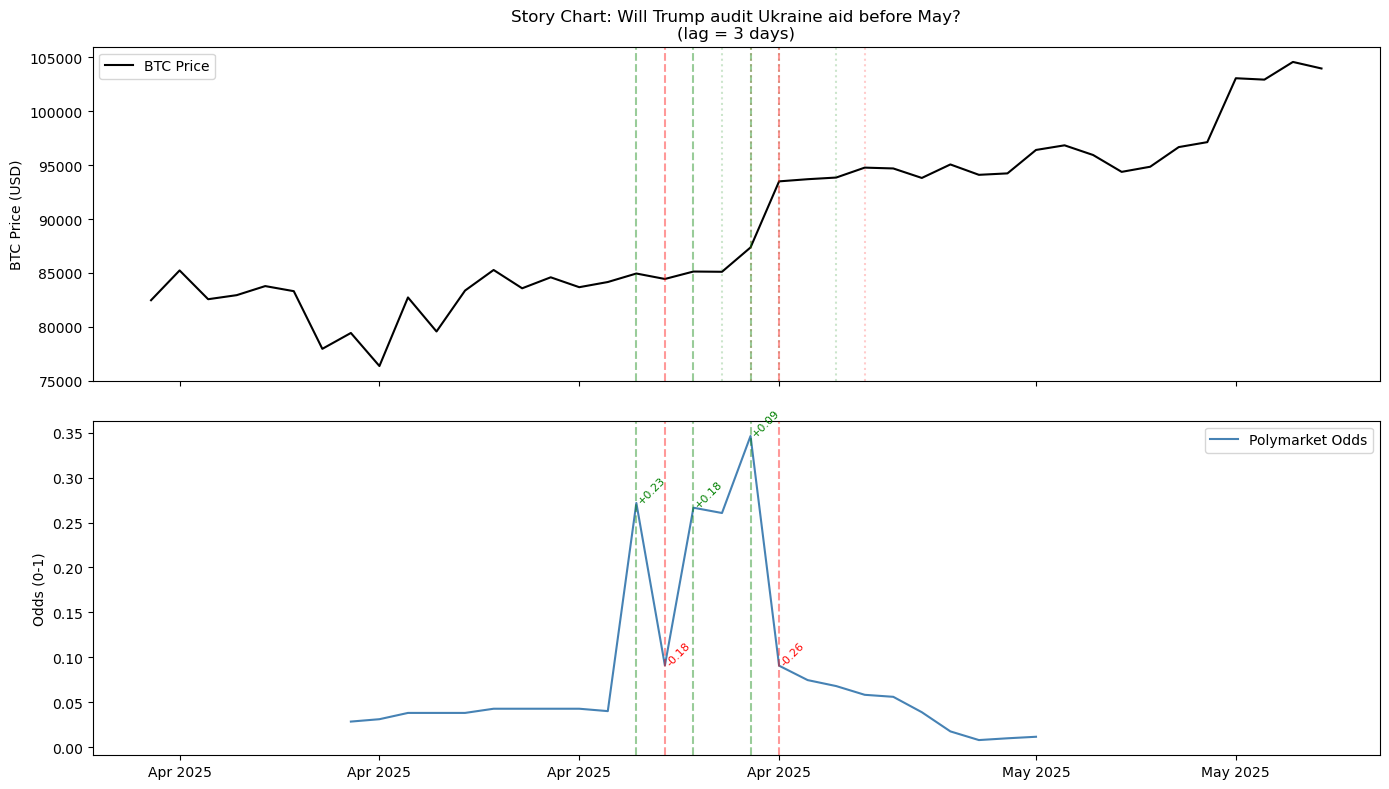

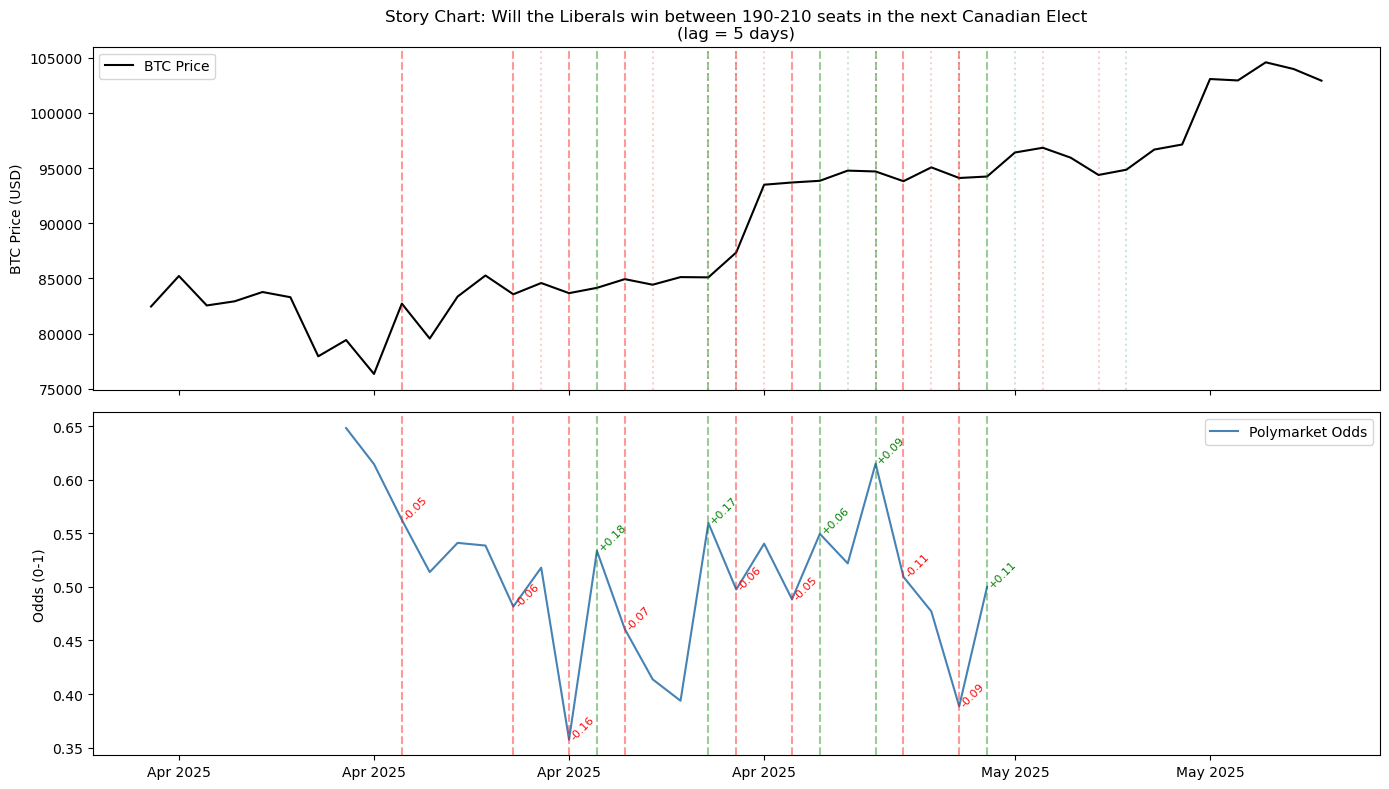

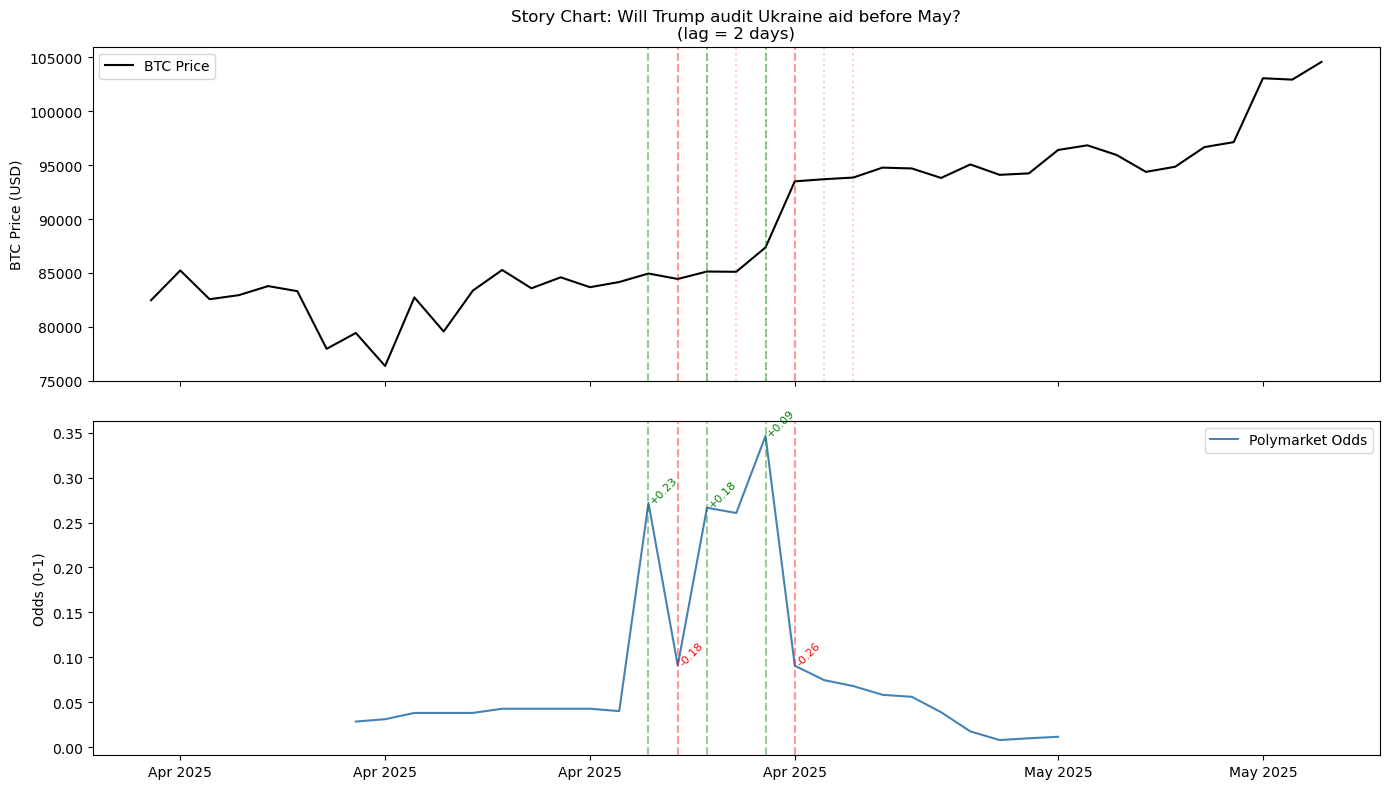

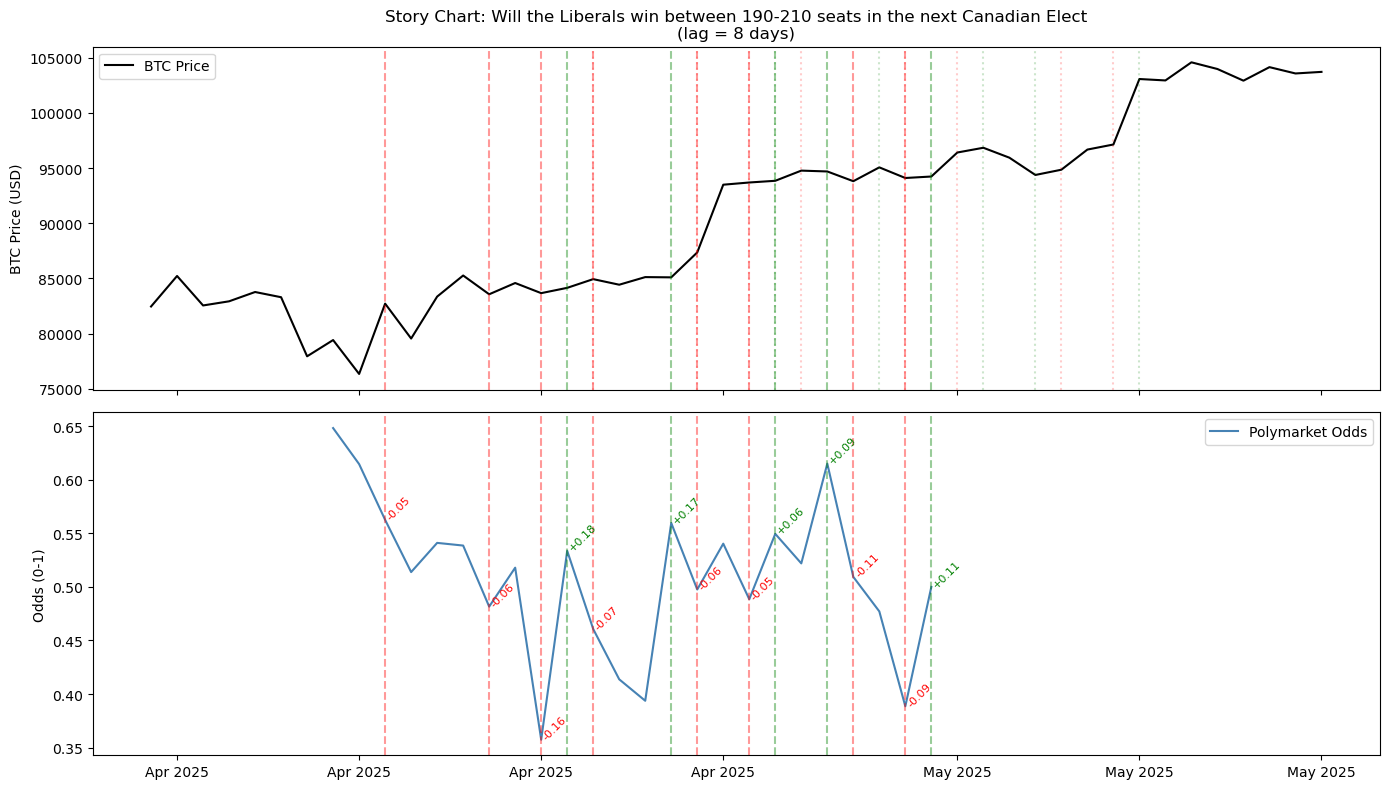

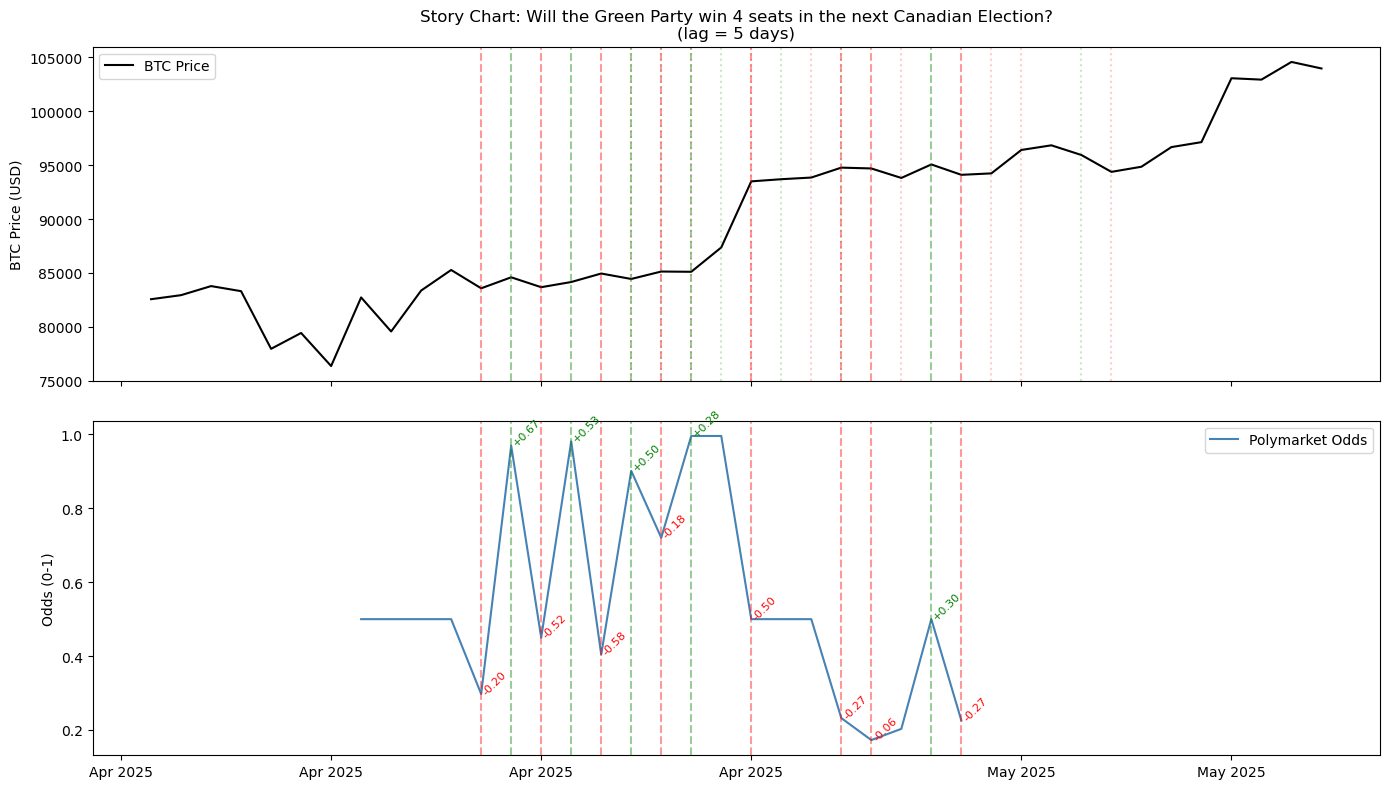

In [261]:
if story_candidates.empty:
    print('No story candidates to plot.')
else:
    for row in story_candidates.head(5).itertuples():
        plot_story_chart(row.question, int(row.n_events), daily_odds, btc_event_df)


In [262]:
os.makedirs('output', exist_ok=True)
story_candidates.to_csv('output/story_candidates.csv', index=False)
print(f'Saved {len(story_candidates)} story candidates.')


Saved 126 story candidates.


In [263]:
if story_candidates.empty:
    print('No story candidates available.')
else:
    print('=== TOP POSITIVE ===')
    display(story_candidates[story_candidates['direction'] == 'POSITIVE'].sort_values('avg_btc_return', ascending=False).head(20))
    print('\n=== TOP NEGATIVE ===')
    display(story_candidates[story_candidates['direction'] == 'NEGATIVE'].sort_values('avg_btc_return', ascending=True).head(20))


=== TOP POSITIVE ===


,question,direction,avg_btc_return,n_events
99,Will Trump audit Ukraine aid before May?,POSITIVE,0.096767,3
117,Will the Liberals win between 190-210 seats in...,POSITIVE,0.070920,5
115,Will the Green Party win 4 seats in the next C...,POSITIVE,0.055380,5
7,Gavin Newsom out as California Governor in 2025?,POSITIVE,0.038150,4
80,Will PLC win the most seats in the 2026 Colomb...,POSITIVE,0.033150,4
76,Will Munyagwa Mubarak Sserunga win the 2026 Ug...,POSITIVE,0.031067,3
46,Will Ethereum dip to $4200 in September?,POSITIVE,0.028167,3
33,"Will Bitcoin reach $190,000 by December 31, 2026?",POSITIVE,0.026000,2
119,Will the NDP win between 5 and 6 seats in the ...,POSITIVE,0.025620,5
111,Will US GDP growth in 2025 be between 2.0% and...,POSITIVE,0.021875,4



=== TOP NEGATIVE ===


,question,direction,avg_btc_return,n_events
4,French election called by October 31?,NEGATIVE,-0.042417,6
34,"Will Bitcoin reach $250,000 by December 31, 2025?",NEGATIVE,-0.034000,2
65,"Will Leavitt say ""Chicago"" during next White H...",NEGATIVE,-0.027867,3
10,Miguel Díaz-Canel out as President of Cuba by ...,NEGATIVE,-0.026850,2
91,Will Stripe’s market cap be less than $80B at ...,NEGATIVE,-0.025950,4
102,Will Trump meet with Volodymyr Zelenskyy in Se...,NEGATIVE,-0.022900,3
89,Will Soraya Martinez Ferrada win the 2025 Mont...,NEGATIVE,-0.022500,9
124,Will turnout in the 2025 Honduran general elec...,NEGATIVE,-0.018840,5
51,Will Fernando Dias da Costa win the 2025 Guine...,NEGATIVE,-0.018350,2
16,Trump appoints special prosecutor for Epstein ...,NEGATIVE,-0.014650,2


### Step 3 : Interesting point

- most of questions have two ways of odd direction except  4 questions

1. Will Trump agree to a tariff agreement with Brazil in September? (+2.52%)
2. MicroStrategy sells any Bitcoin by December 31, 2026? (+2.31%)
3. Will Raul Perestrello win the 1st round of the 2026 Portugal presidential election? (-0.01%)
4. Will Ethereum close above $3400 on July 31? (-0.22%)


In [264]:
# Source: 1. eda_casual_analysis.ipynb, cell 41
FINAL_CANDIDATES = [
    "Will Trump agree to a tariff agreement with Brazil in September?",
    "MicroStrategy sells any Bitcoin by December 31, 2026?"
]

for q in FINAL_CANDIDATES:
    events = find_events(q, daily_odds)
    print(f"\n{q}")
    print(events[["date", "odds_change", "direction"]])



Will Trump agree to a tariff agreement with Brazil in September?
        date  odds_change direction
0 2025-08-29        -0.09  NEGATIVE
1 2025-08-30        -0.06  NEGATIVE

MicroStrategy sells any Bitcoin by December 31, 2026?
        date  odds_change direction
0 2025-12-16    -0.200000  NEGATIVE
1 2025-12-31     0.060000  POSITIVE
2 2026-01-01    -0.103667  NEGATIVE
3 2026-01-03    -0.327405  NEGATIVE


1. Will Trump agree to a tariff agreement with Brazil in September?

On August 29, 2025, the US Court of Appeals declared the IEEPA tariffs illegal, ruling that the president lacked the authority to impose them under his emergency powers. The tariffs will remain in effect while the administration prepares its appeal to the Supreme Court. The Supreme Court will hear oral arguments on November 5, 2025. 

Previously, On July 9, 2025, Trumps administration sent letters to 7 more countries and threatened Brazil with a 50 percent tariff that would take effect August 1, 2025.

On July 30, 2025, President Trump signed an executive order imposing an additional 40 percent tariff on Brazil, delaying implementation of the tariff until August 6, 2025, and published a list of exemptions. He also signed an executive order that would end the de minimis exemption for all countries starting August 29, 2025.

NEGATIVE -> odd decrease -> people don't think this will happen

Trade war resolved -> global risk sentiment improved -> Bitcoin up

2. MicroStrategy sells any Bitcoin by December 31, 2026?

MicroStrategy never sell they always buy + NEGATIVE -> confidence in Bitcoin -> Bitcoin up


## Further Study


In [265]:
print(f'Total markets: {len(signal_df)}')
if signal_df.empty:
    print('No signal markets available after the ACF filter.')
else:
    display(signal_df[['question', 'signal_days']])


Total markets: 65


,question,signal_days
787,"2026 Balance of Power: R Senate, R House",11
749,Will Nikki Haley win the 2028 Republican presi...,10
1345,French election called by October 31?,9
274,Will Howard Lutnick leave the Trump administra...,8
235,Will the Liberals win between 190-210 seats in...,8
...,...,...
1019,Will Trump meet with Aleksandr Lukashenko in 2...,5
1610,Will Álvaro Roberto Ramos Chaves win the 2026 ...,5
2127,Will Donald Trump announce a new nominee for C...,5
1554,Will Gabriel Fernando Indi win the 2025 Guinea...,5


In [266]:
if story_candidates.empty:
    strong = pd.DataFrame(columns=story_candidates.columns)
    print('No strong candidates because story_candidates is empty.')
else:
    strong = story_candidates[(story_candidates['n_events'] >= 3) & (story_candidates['avg_btc_return'].abs() > 0.02)].sort_values('avg_btc_return', ascending=False)
    print(f'Strong candidates: {len(strong)}')
    display(strong)


Strong candidates: 30


,question,direction,avg_btc_return,n_events
99,Will Trump audit Ukraine aid before May?,POSITIVE,0.096767,3
117,Will the Liberals win between 190-210 seats in...,POSITIVE,0.070920,5
116,Will the Liberals win between 190-210 seats in...,NEGATIVE,0.057150,8
115,Will the Green Party win 4 seats in the next C...,POSITIVE,0.055380,5
40,Will Enrique Peñalosa win the 2026 Colombian p...,NEGATIVE,0.039567,3
7,Gavin Newsom out as California Governor in 2025?,POSITIVE,0.038150,4
55,Will Henrique Gouveia e Melo win the 1st round...,NEGATIVE,0.033600,3
80,Will PLC win the most seats in the 2026 Colomb...,POSITIVE,0.033150,4
110,Will US GDP growth in 2025 be between 2.0% and...,NEGATIVE,0.031367,3
114,Will the Green Party win 4 seats in the next C...,NEGATIVE,0.031187,8


In [267]:
if results_df.empty:
    combined = pd.DataFrame(columns=['question', 'avg_btc_return', 'n_events'])
    print('No combined results because results_df is empty.')
else:
    combined = results_df.groupby('question').agg(avg_btc_return=('btc_return', 'mean'), n_events=('event_date', 'count')).reset_index()
    combined = combined[(combined['n_events'] >= 3) & (combined['avg_btc_return'].abs() >= 0.02)].sort_values('avg_btc_return', ascending=False)
    display(combined[['question', 'avg_btc_return', 'n_events']])


,question,avg_btc_return,n_events
50,Will Trump audit Ukraine aid before May?,0.083720,5
59,Will the Liberals win between 190-210 seats in...,0.062446,13
58,Will the Green Party win 4 seats in the next C...,0.040492,13
4,MicroStrategy sells any Bitcoin by December 31...,0.035750,4
23,Will Ethereum dip to $4200 in September?,0.028133,6
56,Will US GDP growth in 2025 be between 2.0% and...,0.025943,7
40,Will PLC win the most seats in the 2026 Colomb...,0.025433,6
19,Will Elon Musk unfollow Donald Trump before July?,0.021900,9
16,"Will Bitcoin reach $190,000 by December 31, 2026?",0.021717,6
20,Will Enrique Peñalosa win the 2026 Colombian p...,0.020900,7


1. Will Trump audit Ukraine aid before May? 

Ukraine became a global leader in crypto aid, with blockchain analytics firms reporting over $200 million in donations in 2022 alone -> crypto transactions under scrutiny ->
?? no conclusion

2. Will the Liberals win between 190-210 seats in the next Canadian Election?

Conservative promote bitcoin as alternative asset -> Liberal win -> bearish bitcoin 
 Wrong way

3. Will the Green Party win 4 seats in the next Canadian Election?

?? no correlation

4. MicroStrategy sells any Bitcoin by December 31, 2026?

MicroStrategy never sell -> buy more -> odd move up -> bullish bitcoin 
 Correct way

5. Will Ethereum dip to $4200 in September?

Crypto market similar -> bearish bitcoin
 Wrong way

6. Will US GDP growth in 2025 be between 2.0% and 2.5%?

2.0-2.5% is moderate growth -> good for bitcoin
 Correct way

7. Will PLC win most seats in Colombian Senate? 

no direct with bitcoin
?? no conclusion

8. Will Bitcoin reach $190,000 by December 31, 2026?

no useful signal
?? no conclusion

9. Will Enrique Penalosa win Colombian election?

no direct with bitcoin
?? no conclusion

10. Gavin Newsom out as California Governor in 2025?

California is the center of US tech and crypto industry -> out -> instable -> bearish bitcoin
 Wrong way

11. Will Soraya Martinez Ferrada win the 2025 Montreal mayor election?

no direct with bitcoin
?? no conclusion

12. French election called by October 31?

instability in Europe -> risky on crypto -> bearish bitcoin
 Correct way

13. Will Trump meet with Volodymyr Zelenskyy in September?

Breakthrough Russia-Ukraine -> bullish bitcoin 
no result -> bearish bitcoin
?? no conclusion


POLYMARKET FACTORS THAT AFFECT BITCOIN:

1. MicroStrategy selling odds (INSTITUTIONAL SIGNAL)<br>
   When selling odds DROP  Bitcoin UP +3.6%<br>
   Story: World's largest Bitcoin holder confirms <br>
   no selling  supply locked  price supported

2. US GDP growth 2.0-2.5% (MACRO SIGNAL)<br>
   Moderate growth odds  Bitcoin UP +2.6%<br>
   Story: Goldilocks economy  risk appetite <br>
   high  institutional money flows into Bitcoin

3. French election called (POLITICAL RISK SIGNAL)<br>
   When election less likely  Bitcoin DOWN -2.8%<br>
   Story: European political instability  <br>
   risk-off  investors exit crypto


Now, we have 4 questions

1. Will Trump agree to a tariff agreement with Brazil in September?<br>
    On August 29, 2025, the US Court of Appeals declared the IEEPA tariffs illegal, ruling that the president lacked the authority to impose them under his emergency powers. The tariffs will remain in effect while the administration prepares its appeal to the Supreme Court. The Supreme Court will hear oral arguments on November 5, 2025. <br>
    Previously, On July 9, 2025, Trumps administration sent letters to 7 more countries and threatened Brazil with a 50 percent tariff that would take effect August 1, 2025.<br>
    On July 30, 2025, President Trump signed an executive order imposing an additional 40 percent tariff on Brazil, delaying implementation of the tariff until August 6, 2025, and published a list of exemptions. He also signed an executive order that would end the de minimis exemption for all countries starting August 29, 2025.<br>
    NEGATIVE -> odd decrease -> people don't think this will happen<br>
    Trade war resolved -> global risk sentiment improved -> Bitcoin up

2. MicroStrategy sells any Bitcoin by December 31, 2026?<br>
    MicroStrategy never sell they always buy + NEGATIVE -> confidence in Bitcoin -> Bitcoin up<br>

3. US GDP growth 2.0-2.5% (MACRO SIGNAL)<br>
   Moderate growth odds  Bitcoin UP +2.6%<br>
   Story: Goldilocks economy  risk appetite <br>
   high  institutional money flows into Bitcoin

4. French election called (POLITICAL RISK SIGNAL)<br>
   When election less likely  Bitcoin DOWN -2.8%<br>
   Story: European political instability  <br>
   risk-off  investors exit crypto


In [231]:
# Find tariff-related questions in the data.
poly_data_markets = markets_df.copy()
tariff_keywords = ['tariff', 'trade deal', 'trade war', 'trade agreement', 'import tax', 'liberation day', 'reciprocal tariff', 'trade deficit']
tariff_markets = poly_data_markets[poly_data_markets['question'].fillna('').apply(lambda q: any(kw in q.lower() for kw in tariff_keywords))].copy()
print(f'Tariff related markets: {len(tariff_markets)}')
if not tariff_markets.empty:
    display(tariff_markets[['market_id', 'question', 'volume']].sort_values('volume', ascending=False).head(25))


Tariff related markets: 315


,market_id,question,volume
8136,533744,Will Trump lower tariffs on China in April?,1.102075e+07
5263,514049,Will Trump impose 25% tariff on Mexico or Cana...,2.789313e+06
22732,586301,Supreme Court rules in favor of Trump's tariffs?,1.465692e+06
5127,513304,Will Trump impose large tariffs in his first 6...,1.443302e+06
44095,620339,Will Trump create a tariff dividend in 2025?,1.416184e+06
6450,521462,Will Trump increase tariffs on Mexico before May?,1.186486e+06
5175,513494,Trump imposes 40% tariff on China in first 100...,1.142692e+06
13735,558544,Will Trump agree to a tariff agreement with Me...,1.094830e+06
7262,526860,Will Trump reduce tariffs on Mexico or Canada ...,1.090785e+06
6162,519286,Trump imposes 25% tariff on Canada and Mexico...,9.227547e+05


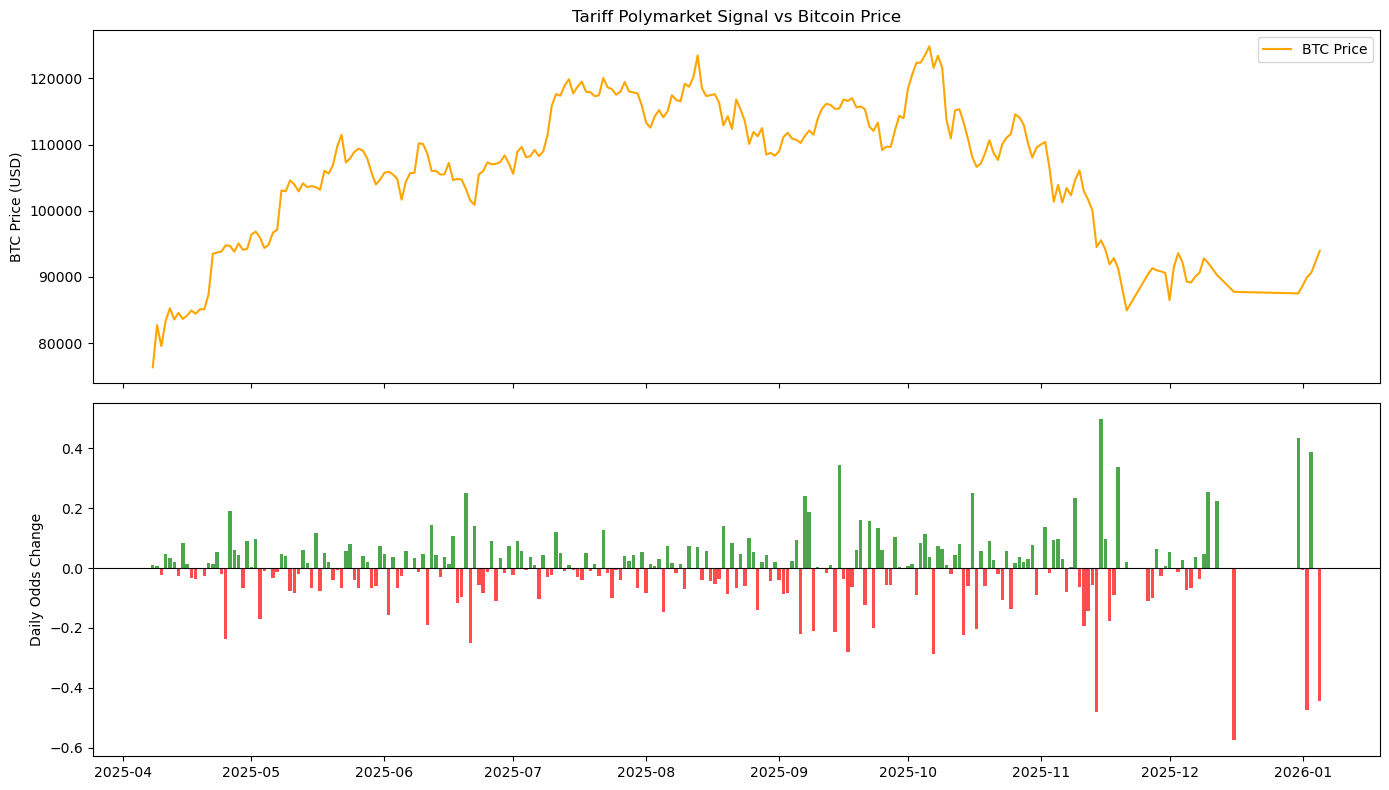

In [232]:
def classify_tariff_question(question):
    q = str(question).lower()
    if any(kw in q for kw in ['deal', 'agreement', 'pause', 'reduce', 'end', 'lift']):
        return 'DE-ESCALATION'
    if any(kw in q for kw in ['impose', 'increase', '50%', '100%', 'new tariff']):
        return 'ESCALATION'
    return 'UNCLEAR'

if tariff_markets.empty:
    tariff_signal = pd.DataFrame(columns=['price', 'odds_change'])
    print('No tariff markets found.')
else:
    tariff_markets['type'] = tariff_markets['question'].apply(classify_tariff_question)
    tariff_odds = daily_odds[daily_odds['market_id'].isin(tariff_markets['market_id'])].copy()
    tariff_signal = tariff_odds.groupby('date')['price'].mean().reset_index().sort_values('date').set_index('date')
    tariff_signal['odds_change'] = tariff_signal['price'].diff()
    combined_tariff = pd.concat([tariff_signal[['price', 'odds_change']], btc_event_df[['PriceUSD']]], axis=1).dropna()
    if combined_tariff.empty:
        print('No overlapping tariff odds and BTC observations.')
    else:
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
        ax1.plot(combined_tariff.index, combined_tariff['PriceUSD'], color='orange', lw=1.5, label='BTC Price')
        ax1.set_ylabel('BTC Price (USD)')
        ax1.set_title('Tariff Polymarket Signal vs Bitcoin Price')
        ax1.legend()
        colors = ['green' if x > 0 else 'red' for x in combined_tariff['odds_change'].fillna(0)]
        ax2.bar(combined_tariff.index, combined_tariff['odds_change'], color=colors, alpha=0.7)
        ax2.axhline(0, color='black', lw=0.8)
        ax2.set_ylabel('Daily Odds Change')
        plt.tight_layout()
        plt.show()


In [233]:
if tariff_markets.empty or 'type' not in tariff_markets.columns:
    deescalation_markets = pd.DataFrame(columns=tariff_markets.columns)
    escalation_markets = pd.DataFrame(columns=tariff_markets.columns)
    print('No typed tariff markets available.')
else:
    deescalation_markets = tariff_markets[tariff_markets['type'] == 'DE-ESCALATION']
    escalation_markets = tariff_markets[tariff_markets['type'] == 'ESCALATION']
    print('DE-ESCALATION markets:')
    display(deescalation_markets[['question', 'volume']].head(20))
    print('\nESCALATION markets:')
    display(escalation_markets[['question', 'volume']].head(20))


DE-ESCALATION markets:


,question,volume
7262,Will Trump reduce tariffs on Mexico or Canada ...,1.090785e+06
8144,Will Trump reduce majority of tariffs before J...,9.912212e+04
8145,Will Trump reduce or pause tariffs on Vietnam ...,2.436843e+05
8146,Will Trump reduce or pause tariffs on Cambodia...,8.274590e+04
8147,Will Trump reduce or pause tariffs on Laos bef...,1.835265e+05
8148,Will Trump reduce or pause tariffs on China be...,1.319796e+05
8149,Will Trump reduce or pause tariffs on Taiwan b...,2.544806e+04
8150,Will Trump reduce or pause tariffs on the Euro...,1.643849e+05
8151,Will Trump reduce or pause tariffs on Japan be...,3.224479e+04
8152,Will Trump reduce or pause tariffs on South Ko...,4.793927e+04



ESCALATION markets:


,question,volume
5127,Will Trump impose large tariffs in his first 6...,1.443302e+06
5175,Trump imposes 40% tariff on China in first 100...,1.142692e+06
5263,Will Trump impose 25% tariff on Mexico or Cana...,2.789313e+06
5872,Will Trump impose tariffs on China in his firs...,6.463655e+04
5873,Will Trump impose tariffs on Canada in his fir...,6.516621e+04
5874,Will Trump impose tariffs on Mexico in his fir...,3.031503e+04
5875,Will Trump impose tariffs on the European Unio...,1.589471e+04
5876,Will Trump impose tariffs on Japan in his firs...,1.872294e+04
5877,Will Trump impose tariffs on the UK in his fir...,6.915984e+03
6162,Trump imposes 25% tariff on Canada and Mexico...,9.227547e+05


In [234]:
def build_signal(market_ids, daily_odds_df):
    odds = daily_odds_df[daily_odds_df['market_id'].isin(market_ids)].copy()
    if odds.empty:
        return pd.DataFrame(columns=['price', 'odds_change'])
    signal = odds.groupby('date')['price'].mean().reset_index().sort_values('date').set_index('date')
    signal['odds_change'] = signal['price'].diff()
    return signal

def get_combined(signal, btc_prices):
    if signal.empty:
        return pd.DataFrame(columns=['price', 'odds_change', 'PriceUSD'])
    return pd.concat([signal[['price', 'odds_change']], btc_prices[['PriceUSD']]], axis=1).dropna()

deescalation_signal = build_signal(deescalation_markets.get('market_id', pd.Series(dtype=object)), daily_odds)
escalation_signal = build_signal(escalation_markets.get('market_id', pd.Series(dtype=object)), daily_odds)
combined_de = get_combined(deescalation_signal, btc_event_df)
combined_es = get_combined(escalation_signal, btc_event_df)

for label, data, expected in [
    ('DE-ESCALATION signal (deal/pause odds)', combined_de, 'odds UP -> Bitcoin UP'),
    ('ESCALATION signal (new tariff odds)', combined_es, 'odds UP -> Bitcoin DOWN'),
]:
    print(f'=== {label} ===')
    print(f'Expected: {expected}')
    if data.empty:
        print('No overlapping observations.')
        continue
    for lag in [1, 3, 5, 7, 10, 14]:
        btc_return = data['PriceUSD'].pct_change(lag).shift(-lag)
        corr = data['odds_change'].corr(btc_return)
        print(f'  Lag {lag:2d} days: {corr:+.3f}')


=== DE-ESCALATION signal (deal/pause odds) ===
Expected: odds UP -> Bitcoin UP
  Lag  1 days: -0.068
  Lag  3 days: +0.064
  Lag  5 days: +0.050
  Lag  7 days: +0.091
  Lag 10 days: +0.044
  Lag 14 days: +0.014
=== ESCALATION signal (new tariff odds) ===
Expected: odds UP -> Bitcoin DOWN
  Lag  1 days: -0.029
  Lag  3 days: +0.055
  Lag  5 days: -0.109
  Lag  7 days: +0.001
  Lag 10 days: +0.004
  Lag 14 days: +0.015


The key addition here is the **net signal** at the bottom  `de-escalation odds minus escalation odds`. This gives you one clean number that says:

Net signal > 0  market believes trade war resolving  Bitcoin should go UP<br>
Net signal < 0  market believes trade war escalating  Bitcoin should go DOWN<br>


## Summary

Step 1 : ACF Analysis<br>
I ran autocorrelation on daily odds changes for each Polymarket question to find how long each market's signal persists.<br>
Get rid of less than 3 days. -> mostly 5-11 days

Step 2 : Event Study<br>
found date that odd change more than 5 percent in one day -> direction and average bitcoin return <br>
-> direction odds and avg_btc_return same way -> 2 question<br>

1. Will Trump agree to a tariff agreement with Brazil in September?<br>

2. MicroStrategy sells any Bitcoin by December 31, 2026?<br>

-> do not care direction -> question with high average bitcoin return and reasonable cause -> 3 questions

1. MicroStrategy sells any Bitcoin by December 31, 2026?<br>

2. US GDP growth 2.0-2.5% (MACRO SIGNAL)<br>

3. French election called (POLITICAL RISK SIGNAL)<br>

Step 3 : Theme of question

We first work on Tariff<br>
Search on list of question with<br>
- De-escalation (110 markets)  deal, pause, reduce, agreement
- Escalation  impose, increase, new tariff

=== NET SIGNAL correlation with btc_change daily (de-escalation - escalation) ===
  Lag  1 days: +0.163
  Lag  3 days: +0.197
  Lag  5 days: +0.317
  Lag  7 days: +0.349
  Lag 10 days: +0.517
  Lag 14 days: +0.534


Story behind:

Trump announces/escalates tariffs
 Escalation odds rise on Polymarket
 Net signal goes negative
 Risk-off sentiment builds
 Bitcoin falls 10-14 days later

Trump pauses/reduces tariffs
 De-escalation odds rise on Polymarket
 Net signal goes positive  
 Risk-on sentiment returns
 Bitcoin rises 10-14 days later


## 6. Question Classification And Direction Labels


Classification workflow: ACF/PACF, event windows, NLP clustering, zero-shot labels, question-direction rules, hypothesis tests, and validation logic.


## Analysis 1
### Step 1 : ACF and PACF plot

**ACF** : $\rho_k = \frac{\sum_{t=k+2}^{n}(x_t-\bar{x})(x_{t-k}-\bar{x})}{\sum_{t=1}^{n}(x_t-\bar{x})^2}$

Pearson correlation between $x_t$ and $x_{tk}$.

**PACF** : $x_t = \phi_1 x_{t-1}+ \phi_2 x_{t-2} +...+\phi_k x_{t-k} +\epsilon_t$

The PACF at lag k is just the coefficient $\phi_k$ from this regression. Everything before lag k is already accounted for, so $\phi_k$ only captures what lag k contributes on its own.

ACF = "How long does this market remember past information?"<br>
PACF = "How many days do I actually need to look back?"<br>
Stable convergence = "Is this market worth trusting as a signal at all?"


In [235]:
# Source: 2. eda_classification.ipynb, cell 21
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.stattools import acf
from scipy import stats


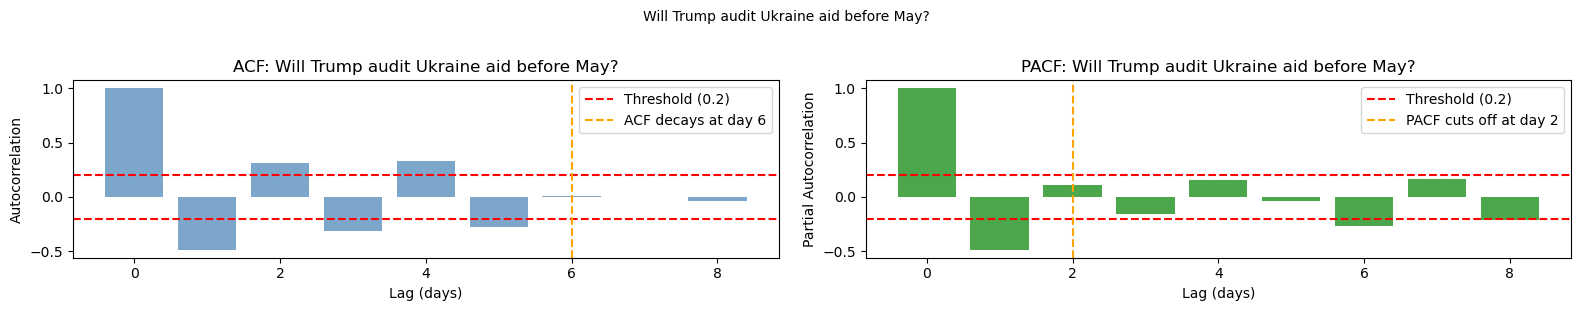

→ ACF signal persists for ~6 days | PACF true lag: 2 days | Will Trump audit Ukraine aid before May?


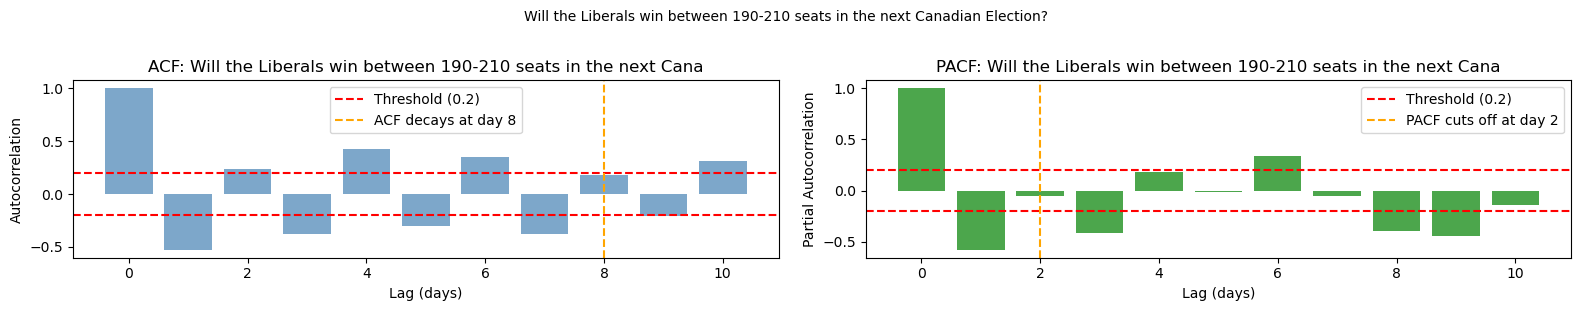

→ ACF signal persists for ~8 days | PACF true lag: 2 days | Will the Liberals win between 190-210 seats in the next Cana


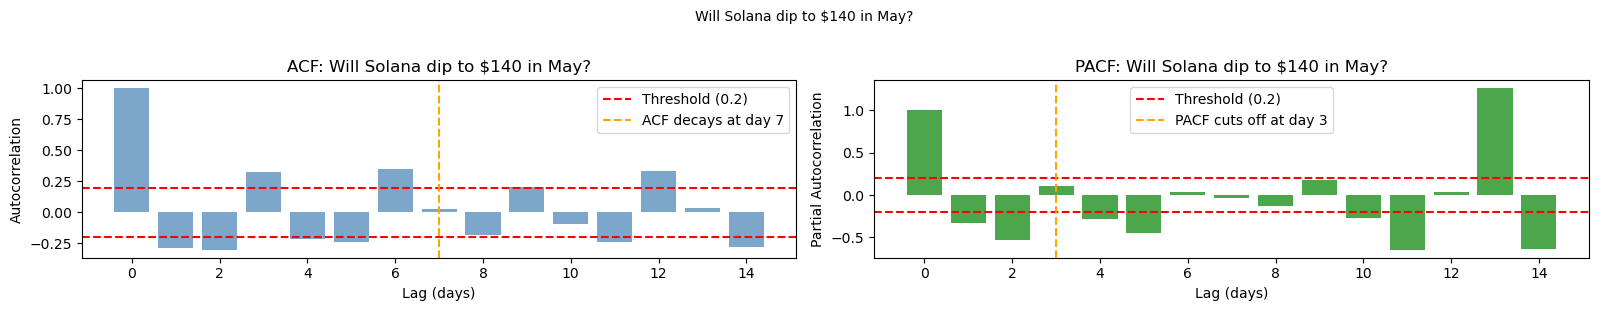

→ ACF signal persists for ~7 days | PACF true lag: 3 days | Will Solana dip to $140 in May?


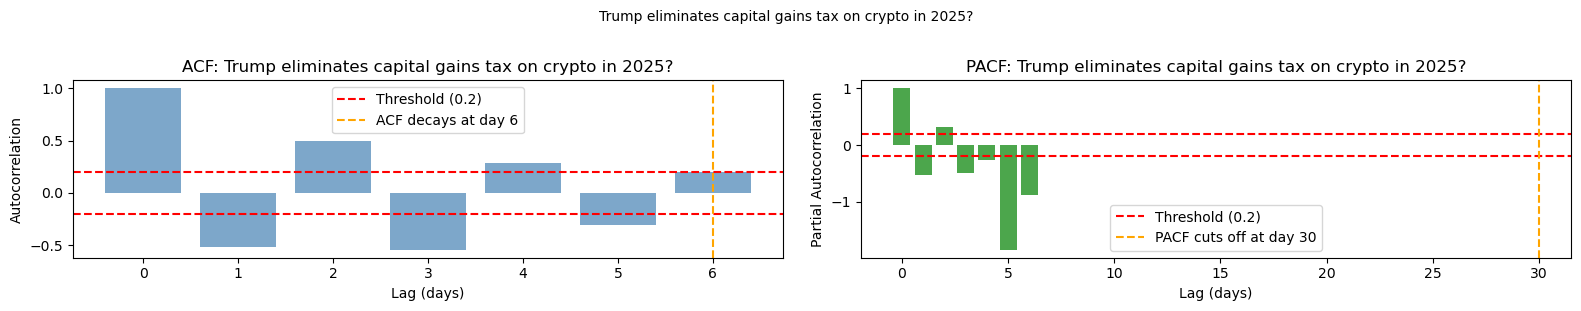

→ ACF signal persists for ~6 days | PACF true lag: 30 days | Trump eliminates capital gains tax on crypto in 2025?


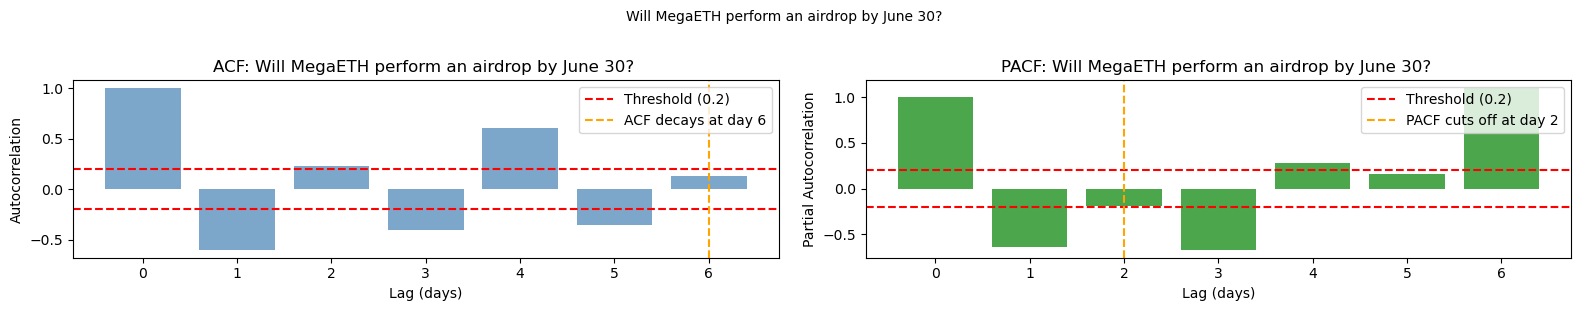

→ ACF signal persists for ~6 days | PACF true lag: 2 days | Will MegaETH perform an airdrop by June 30? 


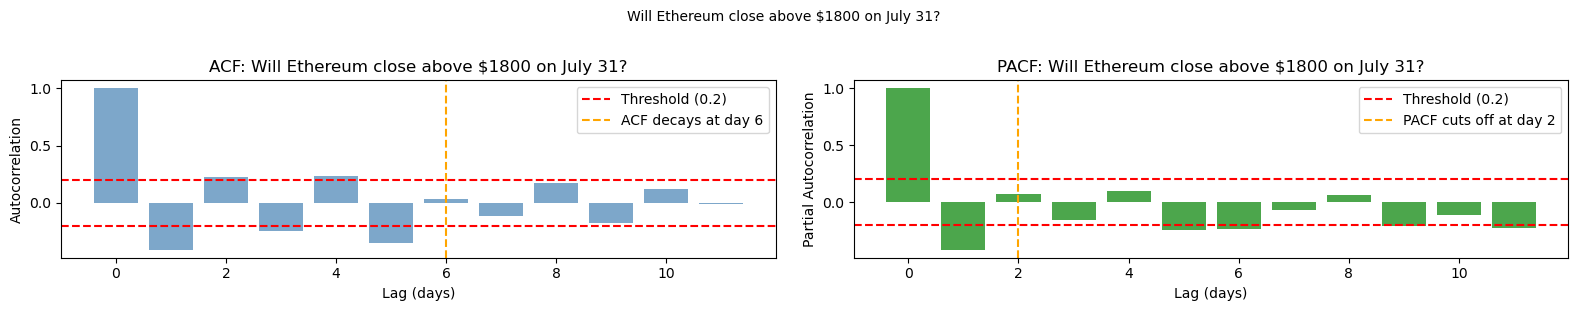

→ ACF signal persists for ~6 days | PACF true lag: 2 days | Will Ethereum close above $1800 on July 31?


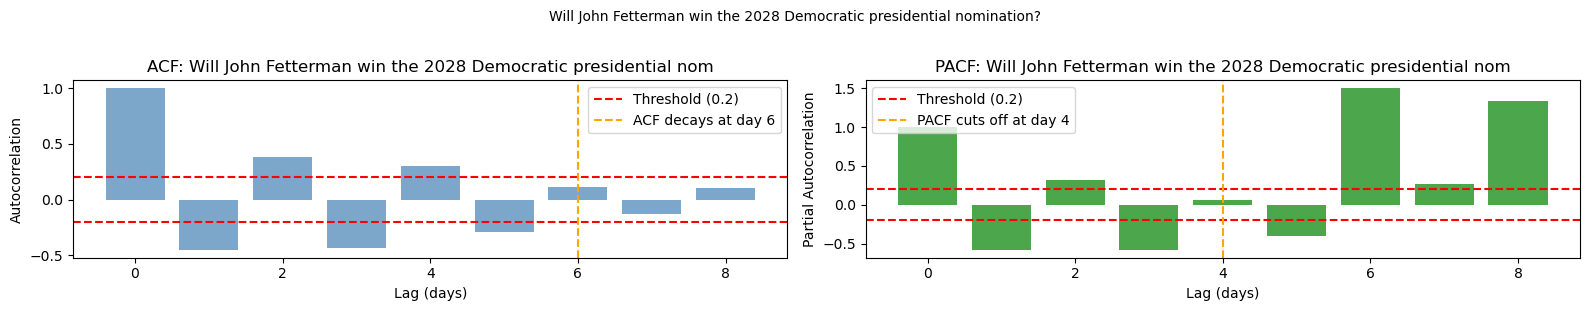

→ ACF signal persists for ~6 days | PACF true lag: 4 days | Will John Fetterman win the 2028 Democratic presidential nom


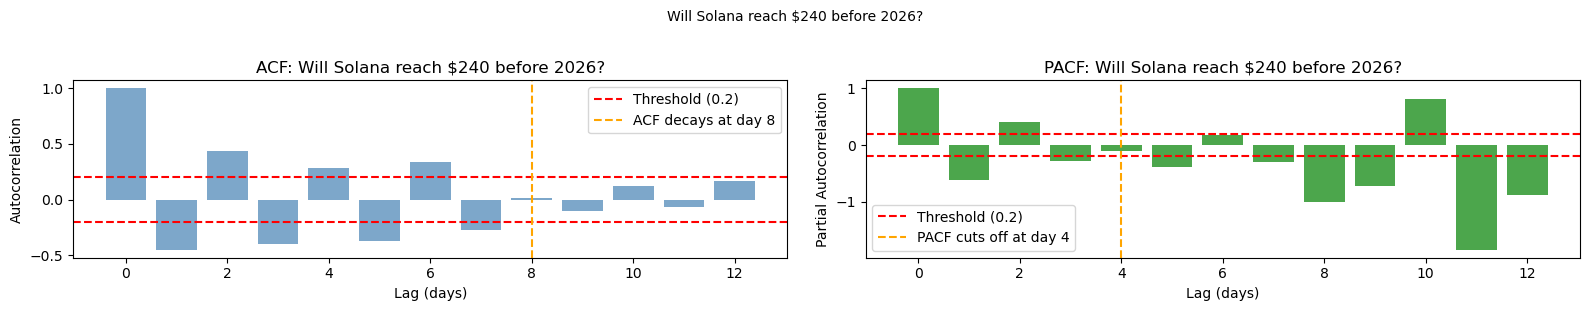

→ ACF signal persists for ~8 days | PACF true lag: 4 days | Will Solana reach $240 before 2026?


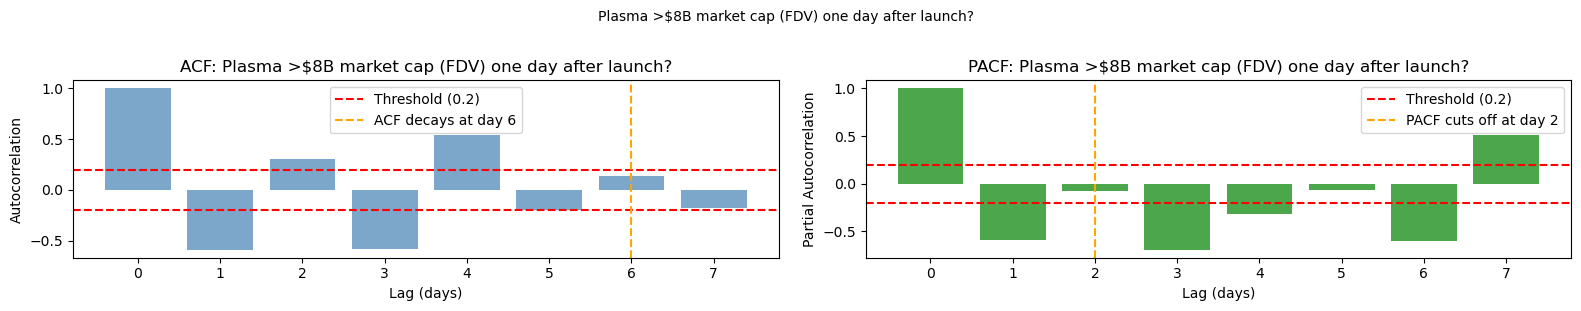

→ ACF signal persists for ~6 days | PACF true lag: 2 days | Plasma >$8B market cap (FDV) one day after launch?


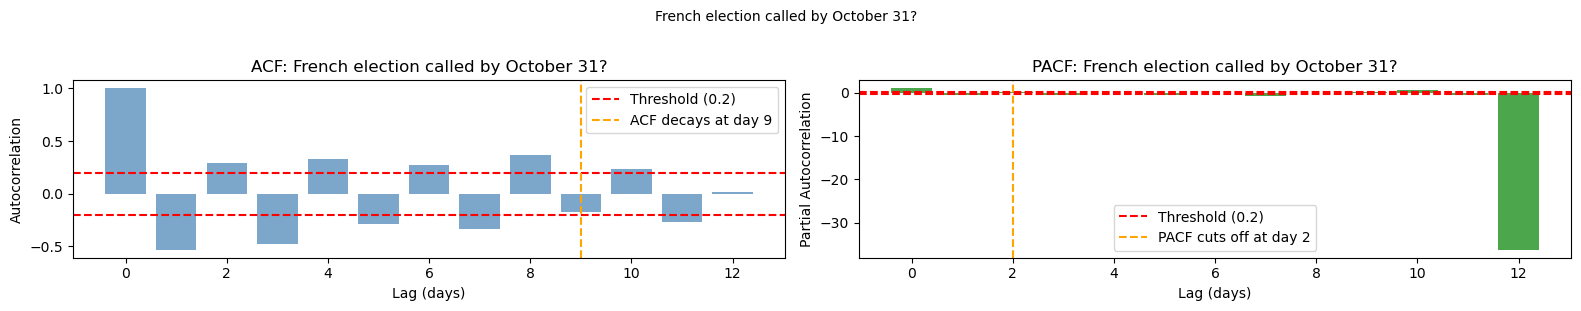

→ ACF signal persists for ~9 days | PACF true lag: 2 days | French election called by October 31?


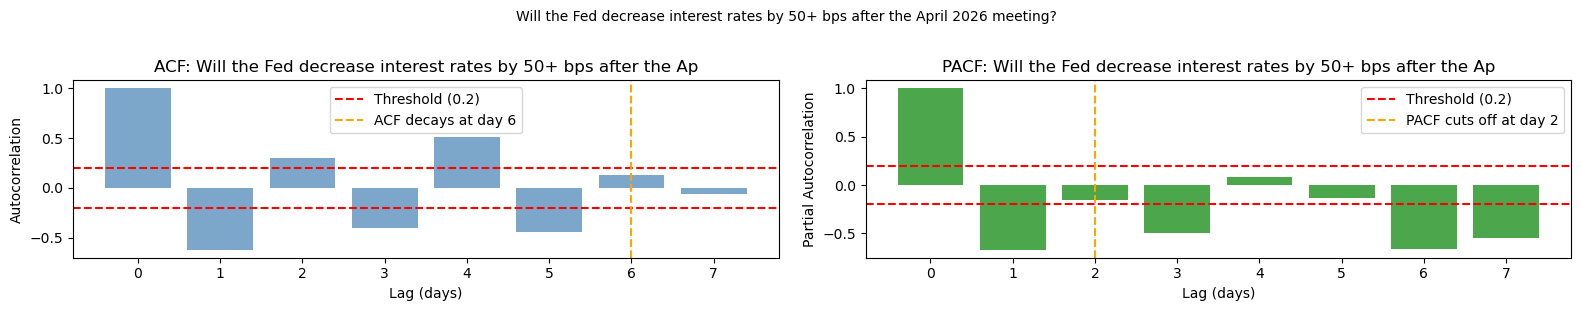

→ ACF signal persists for ~6 days | PACF true lag: 2 days | Will the Fed decrease interest rates by 50+ bps after the Ap


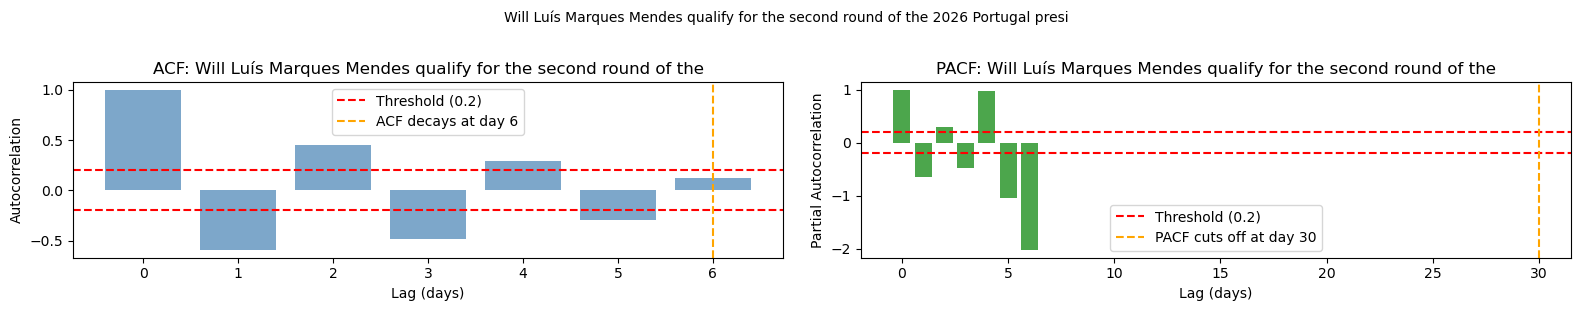

→ ACF signal persists for ~6 days | PACF true lag: 30 days | Will Luís Marques Mendes qualify for the second round of the


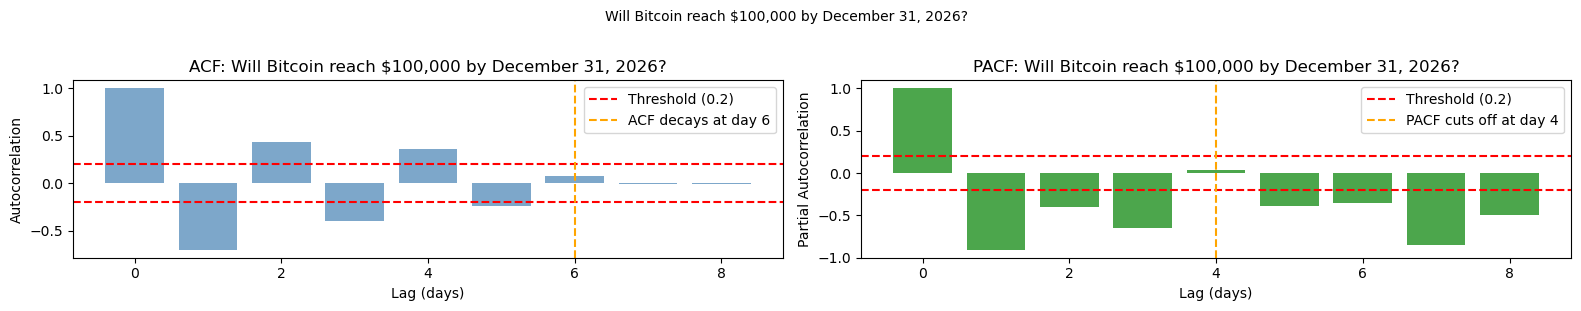

→ ACF signal persists for ~6 days | PACF true lag: 4 days | Will Bitcoin reach $100,000 by December 31, 2026?


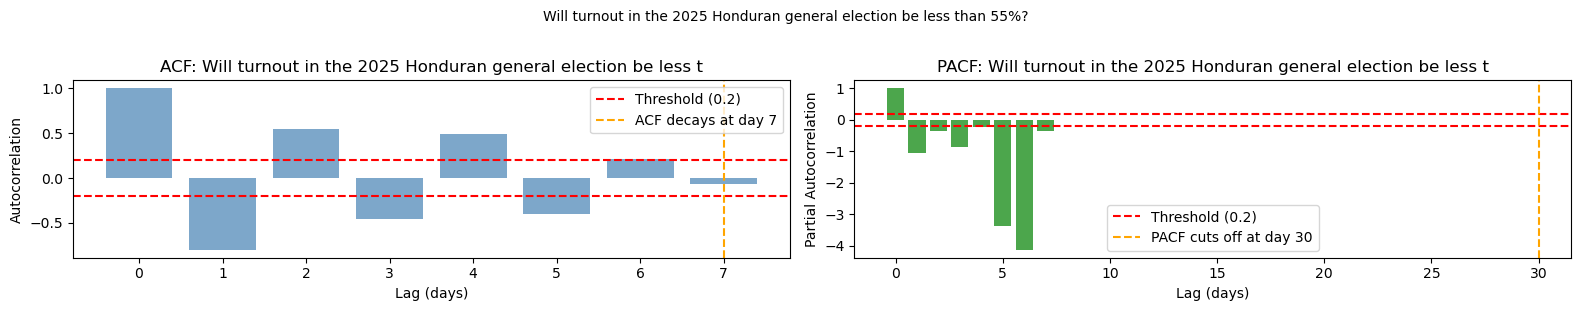

→ ACF signal persists for ~7 days | PACF true lag: 30 days | Will turnout in the 2025 Honduran general election be less t


In [238]:
from statsmodels.tsa.stattools import acf, pacf

FOCUS_MARKETS = daily_odds["question"].unique()

def plot_acf_pacf_for_market(market_name, poly_df, max_lag=30):
    df = poly_df[poly_df["question"] == market_name].copy()
    df_start = df["date"].min()
    df_end = df["date"].max()
    duration = df_end - df_start

    if duration.days < 14:
        return None

    df["odds_change"] = df["price"].diff()
    series = df["odds_change"].dropna()

    if df["price"].std() < 0.05:
        return None

    # PACF requires nlags < 50% of sample size
    safe_lag = min(max_lag, len(series) // 2 - 1)
    if safe_lag < 5:
        return None

    acf_vals = acf(series, nlags=safe_lag, fft=True)
    pacf_vals = pacf(series, nlags=safe_lag, method="ols")

    # ACF decay day
    acf_decay_day = next((i for i, v in enumerate(acf_vals[1:], start=1) if abs(v) < 0.2), max_lag)
    if acf_decay_day == max_lag:
        return None

    # PACF cutoff day (first lag where PACF drops below threshold)
    pacf_cutoff_day = next((i for i, v in enumerate(pacf_vals[1:], start=1) if abs(v) < 0.2), max_lag)

    if acf_decay_day > 5:
        fig, axes = plt.subplots(1, 2, figsize=(16, 3))

        # --- ACF plot ---
        axes[0].bar(range(len(acf_vals)), acf_vals, color="steelblue", alpha=0.7)
        axes[0].axhline(0.2, color="red", linestyle="--", label="Threshold (0.2)")
        axes[0].axhline(-0.2, color="red", linestyle="--")
        axes[0].axvline(acf_decay_day, color="orange", linestyle="--", label=f"ACF decays at day {acf_decay_day}")
        axes[0].set_title(f"ACF: {market_name[:60]}")
        axes[0].set_xlabel("Lag (days)")
        axes[0].set_ylabel("Autocorrelation")
        axes[0].legend()

        # --- PACF plot ---
        axes[1].bar(range(len(pacf_vals)), pacf_vals, color="green", alpha=0.7)
        axes[1].axhline(0.2, color="red", linestyle="--", label="Threshold (0.2)")
        axes[1].axhline(-0.2, color="red", linestyle="--")
        axes[1].axvline(pacf_cutoff_day, color="orange", linestyle="--", label=f"PACF cuts off at day {pacf_cutoff_day}")
        axes[1].set_title(f"PACF: {market_name[:60]}")
        axes[1].set_xlabel("Lag (days)")
        axes[1].set_ylabel("Partial Autocorrelation")
        axes[1].legend()

        plt.suptitle(market_name[:80], fontsize=10, y=1.02)
        plt.tight_layout()

        os.makedirs("acf_plots", exist_ok=True)
        plt.savefig(f"acf_plots/acf_pacf_{market_name[:30].replace(' ', '_')}.png", dpi=150, bbox_inches="tight")
        plt.show()

        print(f"→ ACF signal persists for ~{acf_decay_day} days | PACF true lag: {pacf_cutoff_day} days | {market_name[:60]}")

    return {"acf_decay": acf_decay_day, "pacf_cutoff": pacf_cutoff_day}


signal_persistence = {}
for m in FOCUS_MARKETS:
    result = plot_acf_pacf_for_market(m, daily_odds)
    if result:
        signal_persistence[m] = result


|Question| ACF|PACF|
|------|-----|-----|
|Will Trump audit Ukraine aid before May?|6|2|
|Will the Liberals win between 190-210 seats in the next Canadian Election?|8|2|
|Will Solana dip to $140 in May?|7|unstable|
|Trump eliminates capital gains tax on crypto in 2025?|6|unstable|
|Will MegaETH perform an airdrop by June 30?|6|unstable|
|Will Ethereum close above $1800 on July 31?|6|2|
|Will John Fetterman win the 2028 Democratic presidential nomination?|6|unstable|
|Will Solana reach $240 before 2026?|8|unstable|
|Plasma >$8B market cap (FDV) one day after launch?|6|2|
|French election called by October 31?|9|unstable|
|Will the Fed decrease interest rates by 50+ bps after the April 2026 meeting?|6|2|
|Will Luis Marques Mendes qualify for the second round of the 2026 Portugal president?|6|unstable|
|Will Bitcoin reach $100,000 by December 31, 2026?|6|4|
|Will turnout in the 2025 Honduran general election be less than 55%?|7|unstable|

So we have
- Will Trump audit Ukraine aid before May?
- Will the Liberals win between 190-210 seats in the next Canadian Election?
- Will Ethereum close above $1800 on July 31?
- Plasma >$8B market cap (FDV) one day after launch?
- Will the Fed decrease interest rates by 50+ bps after the April 2026 meeting?
- Will Bitcoin reach $100,000 by December 31, 2026?

Most of them last 2 day, except ill Bitcoin reach $100,000 by December 31, 2026?


In [269]:
# Source: 2. eda_classification.ipynb, cell 25
# btc_df = btc_df.to_pandas()
btc_df["date"] = pd.to_datetime(btc_df["time"])
btc_df["btc_return"] = btc_df["PriceUSD"].pct_change()


In [270]:
# Source: 2. eda_classification.ipynb, cell 26
def find_events(question, daily_odds_df, threshold=0.05):
    df = daily_odds_df[daily_odds_df["question"] == question].copy()
    df["price"] = pd.to_numeric(df["price"], errors="coerce")
    df = df.set_index("date")[["price"]].resample("1D").mean().ffill()
    df["odds_change"] = df["price"].diff()

    events = df[df["odds_change"].abs() > threshold].copy()
    events["direction"] = events["odds_change"].apply(
        lambda x: "POSITIVE" if x > 0 else "NEGATIVE"
    )
    return events.reset_index()[["date", "price", "odds_change", "direction"]]


In [271]:
# Prepare BTC table for classification event study without mutating btc_df.
btc_classification_df = btc_pd.copy()
if 'PriceUSD' not in btc_classification_df.columns and 'btc_price' in btc_classification_df.columns:
    btc_classification_df = btc_classification_df.rename(columns={'btc_price': 'PriceUSD'})
btc_classification_df['date'] = pd.to_datetime(btc_classification_df['time'], errors='coerce').dt.normalize()
btc_classification_df['PriceUSD'] = pd.to_numeric(btc_classification_df['PriceUSD'], errors='coerce')
btc_classification_df = btc_classification_df.dropna(subset=['date', 'PriceUSD']).set_index('date')
btc_classification_df = btc_classification_df[~btc_classification_df.index.duplicated(keep='last')]
print('btc_classification_df index range:', btc_classification_df.index.min(), 'to', btc_classification_df.index.max())


btc_classification_df index range: 2010-07-18 00:00:00 to 2026-01-13 00:00:00


In [272]:
# Source: 2. eda_classification.ipynb, cell 28
def event_study(question, lag_days, daily_odds_df, btc_df, threshold=0.05):
    events = find_events(question, daily_odds_df, threshold)
    if events.empty:
        return None

    results = []
    for _, ev in events.iterrows():
        future_date = ev["date"] + pd.Timedelta(days=lag_days)
        if ev["date"] in btc_df.index and future_date in btc_df.index:
            btc_return = (
                btc_df.loc[future_date, "PriceUSD"] - btc_df.loc[ev["date"], "PriceUSD"]
            ) / btc_df.loc[ev["date"], "PriceUSD"]
            results.append({
                "question":    question,
                "event_date":  ev["date"],
                "direction":   ev["direction"],
                "odds_change": ev["odds_change"],
                "lag_days":    lag_days,
                "btc_return":  round(btc_return, 4)
            })

    return pd.DataFrame(results)


In [273]:
# Source: 2. eda_classification.ipynb, cell 29
FOCUS_MARKETS = pd.DataFrame({"question": ["Will Trump audit Ukraine aid before May?",
"Will the Liberals win between 190-210 seats in the next Canadian Election?",
"Will Ethereum close above $1800 on July 31?",
"Plasma >$8B market cap (FDV) one day after launch?",
"Will the Fed decrease interest rates by 50+ bps after the April 2026 meeting?",
"Will Bitcoin reach $100,000 by December 31, 2026?"],
"signal_days":[2,2,2,2,2,4]})


In [274]:
all_results = []
for _, row in FOCUS_MARKETS.iterrows():
    question = row['question']
    lag = int(row['signal_days'])
    print(f'Processing: {question[:50]}...')
    res = event_study(question, lag, daily_odds, btc_classification_df)
    if res is not None and not res.empty:
        all_results.append(res)
        print(f'   {len(res)} events found')
    else:
        print('   No events found')
print(f'\nTotal markets with results: {len(all_results)}')


Processing: Will Trump audit Ukraine aid before May?...
   5 events found
Processing: Will the Liberals win between 190-210 seats in the...
   13 events found
Processing: Will Ethereum close above $1800 on July 31?...
   12 events found
Processing: Plasma >$8B market cap (FDV) one day after launch?...
   8 events found
Processing: Will the Fed decrease interest rates by 50+ bps af...
   14 events found
Processing: Will Bitcoin reach $100,000 by December 31, 2026?...
   13 events found

Total markets with results: 6


In [275]:
if all_results:
    results_df = pd.concat(all_results, ignore_index=True)
else:
    results_df = pd.DataFrame(columns=['question', 'event_date', 'direction', 'odds_change', 'lag_days', 'btc_return'])

if results_df.empty:
    summary = pd.DataFrame(columns=['question', 'direction', 'avg_btc_return', 'n_events'])
    story_candidates = summary.copy()
    print('No classification event-study results found for the selected focus markets.')
else:
    summary = results_df.groupby(['question', 'direction'])['btc_return'].agg(['mean', 'count']).reset_index().rename(columns={'mean': 'avg_btc_return', 'count': 'n_events'})
    story_candidates = summary.sort_values('avg_btc_return', ascending=False)
    print('=== POSITIVE odds move -> BTC return ===')
    display(summary[summary['direction'] == 'POSITIVE'].sort_values('avg_btc_return', ascending=False))
    print('\n=== NEGATIVE odds move -> BTC return ===')
    display(summary[summary['direction'] == 'NEGATIVE'].sort_values('avg_btc_return', ascending=True))


=== POSITIVE odds move -> BTC return ===


,question,direction,avg_btc_return,n_events
7,Will Trump audit Ukraine aid before May?,POSITIVE,0.033667,3
11,Will the Liberals win between 190-210 seats in...,POSITIVE,0.028500,5
3,"Will Bitcoin reach $100,000 by December 31, 2026?",POSITIVE,0.023117,6
9,Will the Fed decrease interest rates by 50+ bp...,POSITIVE,0.008650,6
5,Will Ethereum close above $1800 on July 31?,POSITIVE,-0.003286,7
1,Plasma >$8B market cap (FDV) one day after lau...,POSITIVE,-0.007120,5



=== NEGATIVE odds move -> BTC return ===


,question,direction,avg_btc_return,n_events
0,Plasma >$8B market cap (FDV) one day after lau...,NEGATIVE,-0.003167,3
2,"Will Bitcoin reach $100,000 by December 31, 2026?",NEGATIVE,-0.001071,7
6,Will Trump audit Ukraine aid before May?,NEGATIVE,0.005850,2
8,Will the Fed decrease interest rates by 50+ bp...,NEGATIVE,0.010075,8
10,Will the Liberals win between 190-210 seats in...,NEGATIVE,0.017237,8
4,Will Ethereum close above $1800 on July 31?,NEGATIVE,0.017640,5


- Will Ethereum close above $1800 on July 31?<br>
Odds Positive -> avg btc -0.003 (7 events)
Odds Negative -> avg btc 0.018 (5 events)
- Will Bitcoin reach $100,000 by December 31, 2026?<br>
Odds Positive -> avg btc 0.023 (6 events)
Odds Negative -> avg btc -0.001 (7 events)


### Phase 1.1: NLP KMeans


In [303]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sentence_transformers import SentenceTransformer
import hdbscan


In [308]:
questions_all = pd.Series(daily_odds['question'].dropna().unique()).astype(str).tolist()
print(f'Total questions available: {len(questions_all):,}')
model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = model.encode(questions_all, show_progress_bar=True)

Total questions available: 36,043


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/1127 [00:00<?, ?it/s]

In [309]:
print(f'Embeddings shape: {embeddings.shape}')


Embeddings shape: (36043, 384)


In [310]:
inertias = []
silhouettes = []
k_range     = range(2, 15)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(embeddings)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(embeddings, labels))

print('KMeans scan complete.')


KMeans scan complete.


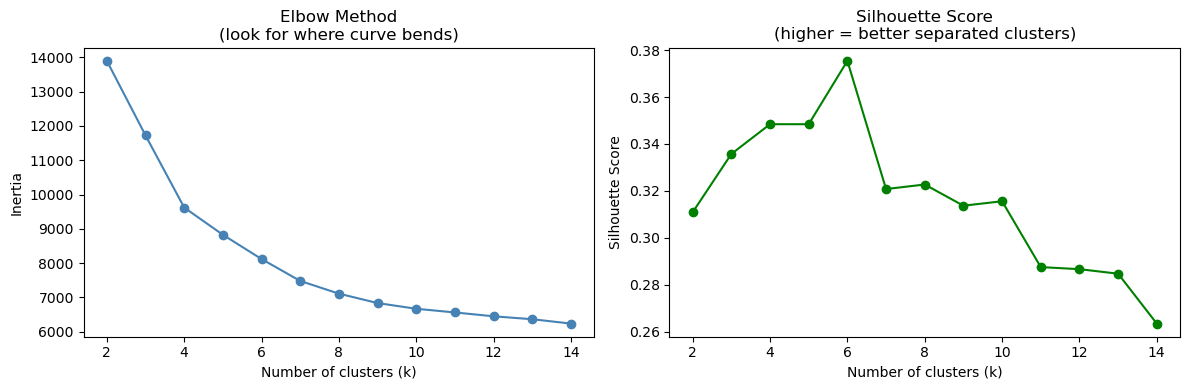

In [311]:
# Source: 2. eda_classification.ipynb, cell 39
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(k_range), inertias, marker="o", color="steelblue")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow Method\n(look for where curve bends)")

axes[1].plot(list(k_range), silhouettes, marker="o", color="green")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score\n(higher = better separated clusters)")

plt.tight_layout()
plt.show()


In [313]:
best_k = list(k_range)[int(np.nanargmax(silhouettes))] if silhouettes else 2
print(f'Best k by silhouette score: {best_k}')
K = best_k
km = KMeans(n_clusters=K, random_state=42, n_init=10)
labels = km.fit_predict(embeddings)
cluster_df = pd.DataFrame({'question': questions_all, 'cluster': labels})
for c in range(K):
    sample = cluster_df[cluster_df['cluster'] == c]['question'].head(10).tolist()
    print(f'\nCluster {c} ({(cluster_df["cluster"] == c).sum()} questions):')
    for q in sample:
        print(f'  - {q[:80]}')


Best k by silhouette score: 6

Cluster 0 (2539 questions):
  - Solana ETF approved by July 31?
  - Solana all time high before 2026?
  - Will Solana reach $210 in April?
  - Will Solana reach $190 in April?
  - Will Solana reach $170 in April?
  - Will Solana reach $150 in April?
  - Solana above $120 on April 18?
  - Solana above $150 on May 2?
  - Will Solana reach $300 in May?
  - Will Solana reach $210 in May?

Cluster 1 (14978 questions):
  - Bitcoin Up or Down in April?
  - Ethereum Up or Down in April?
  - Bitcoin Up or Down on April 8?
  - Ethereum Up or Down on April 7?
  - Ethereum Up or Down on April 8?
  - Ethereum Up or Down on April 9?
  - Bitcoin Up or Down on April 10?
  - Ethereum Up or Down on April 10?
  - Ethereum Up or Down on April 11?
  - Ethereum Up or Down on April 12?

Cluster 2 (5548 questions):
  - Trump ends Ukraine war in first 90 days?
  - Will Trump pardon Hunter Biden?
  - Trump ends taxes on tips in first 100 days?
  - Trump signs national abortion ban

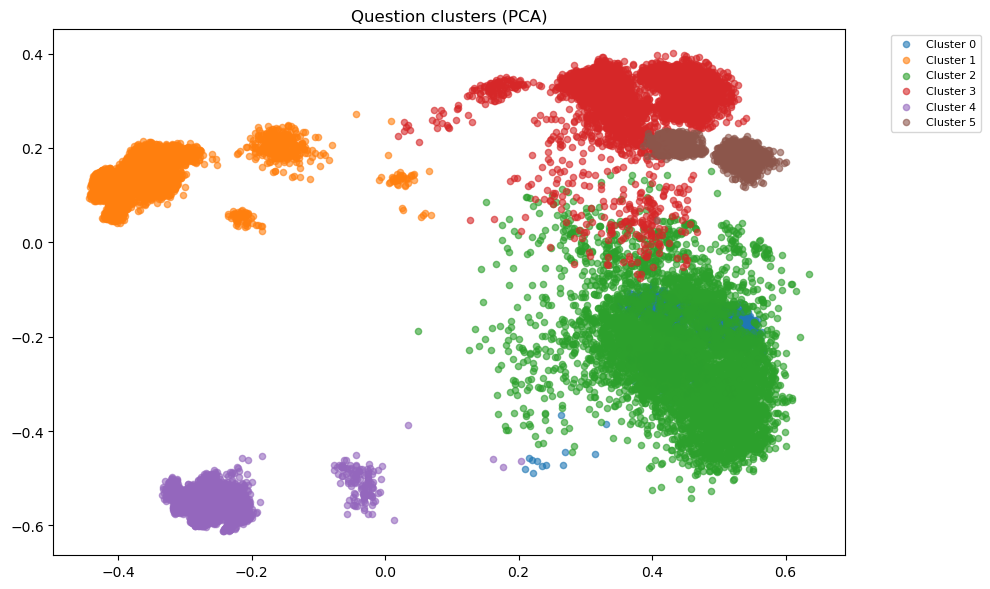

In [315]:
coords = PCA(n_components=2, random_state=42).fit_transform(embeddings)
plt.figure(figsize=(10, 6))
for c in range(K):
    mask = labels == c
    plt.scatter(coords[mask, 0], coords[mask, 1], label=f'Cluster {c}', alpha=0.6, s=20)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.title('Question clusters (PCA)')
plt.tight_layout()
plt.savefig('cluster_plot.png', dpi=150)
plt.show()


In [316]:
# Source: 2. eda_classification.ipynb, cell 42
daily_odds_clustered = daily_odds.merge(cluster_df, on="question", how="left")
print("\nSample with cluster labels:")
print(daily_odds_clustered[["question", "cluster"]].drop_duplicates().head(10))



Sample with cluster labels:
                                              question  cluster
0             Trump ends Ukraine war in first 90 days?        2
18                     Will Trump pardon Hunter Biden?        2
31         Trump ends taxes on tips in first 100 days?        2
55                  Trump signs national abortion ban?        2
79      Will Trump pardon Diddy in his first 100 days?        2
103  Will Trump pardon Steve Bannon in his first 10...        2
127  Will Trump pardon Edward Snowden in his first ...        2
150  Will Trump pardon Julian Assange in his first ...        2
173  Will Trump end Department of Education in firs...        2
196  Will Trump create Bitcoin reserve in first 100...        2


In [317]:
# Source: 2. eda_classification.ipynb, cell 43
cluster_sizes = cluster_df["cluster"].value_counts().rename("cluster_size")
cluster_df    = cluster_df.merge(cluster_sizes, left_on="cluster", right_index=True)

# Sort by cluster number
cluster_df = cluster_df.sort_values("cluster").reset_index(drop=True)

cluster_df.to_csv("question_clusters.csv", index=False)


### Phase 1.2: NLP HSBSCAN


In [320]:
pca_50     = PCA(n_components=50, random_state=42)
reduced    = pca_50.fit_transform(embeddings)
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=1000,
    min_samples=5,
    metric="euclidean",
    cluster_selection_method="eom"
)
labels = clusterer.fit_predict(reduced)
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise    = (labels == -1).sum()
print(f"\nClusters found: {n_clusters}")
print(f"Noise points (no cluster): {n_noise} ({n_noise/len(questions_all):.1%})")




Clusters found: 13
Noise points (no cluster): 5248 (14.6%)


In [322]:
cluster_df_hdbscan = pd.DataFrame({'question': questions_all, 'cluster': labels})


In [323]:
# Source: 2. eda_classification.ipynb, cell 49
print("\n Sample questions per cluster ")
for c in sorted(cluster_df_hdbscan["cluster"].unique()):
    subset = cluster_df_hdbscan[cluster_df_hdbscan["cluster"] == c]
    sample = subset["question"].head(5).tolist()
    label  = "NOISE (no group)" if c == -1 else f"Cluster {c}"
    print(f"\n{label} ({len(subset)} questions):")
    for q in sample:
        print(f"  - {q[:80]}")



 Sample questions per cluster 

NOISE (no group) (5248 questions):
  - Trump ends Ukraine war in first 90 days?
  - Trump ends taxes on tips in first 100 days?
  - Trump signs national abortion ban?
  - Will Trump create Bitcoin reserve in first 100 days?
  - Will the GOP use 'Nuclear Option' to break filibuster?

Cluster 0 (1876 questions):
  - Will the price of XRP be above $2.79 on August 29 at 12PM ET?
  - Will the price of XRP be above $2.82 on August 29 at 4PM ET?
  - Will the price of XRP be above $2.85 on August 29 at 4PM ET?
  - Will the price of XRP be above $2.97 on August 29 at 4PM ET?
  - Will the price of XRP be above $2.79 on August 29 at 8PM ET?

Cluster 1 (4653 questions):
  - Solana all time high in April?
  - Solana Up or Down in April?
  - Solana Up or Down in May?
  - Solana Up or Down on May 8?
  - Solana Up or Down on May 9?

Cluster 2 (2538 questions):
  - Solana all time high by June 30?
  - Will Solana reach $210 in April?
  - Will Solana reach $190 in April?

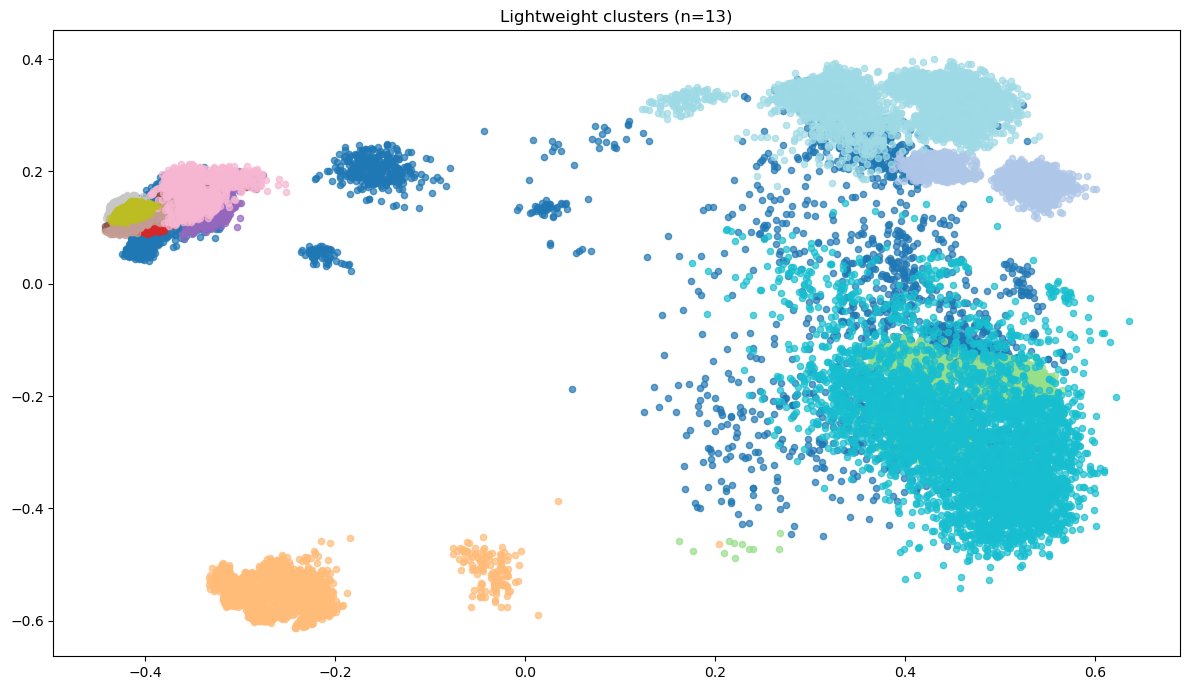

In [325]:
plt.figure(figsize=(12, 7))
cmap = plt.colormaps.get_cmap('tab20')
for i, c in enumerate(sorted(set(labels))):
    mask = labels == c
    plt.scatter(coords[mask, 0], coords[mask, 1], color=cmap(i / max(1, n_clusters - 1)), s=20, alpha=0.7, label=f'C{c}')
plt.title(f'Lightweight clusters (n={n_clusters})')
plt.tight_layout()
plt.savefig('hdbscan_clusters.png', dpi=150)
plt.show()


In [326]:
# Source: 2. eda_classification.ipynb, cell 51
cluster_sizes = cluster_df_hdbscan["cluster"].value_counts().rename("cluster_size")
cluster_df_hdbscan    = cluster_df_hdbscan.merge(cluster_sizes, left_on="cluster", right_index=True)
cluster_df_hdbscan    = cluster_df_hdbscan.sort_values("cluster").reset_index(drop=True)


In [327]:
# Source: 2. eda_classification.ipynb, cell 52
cluster_df_hdbscan.to_csv("question_clusters_hdbscan.csv", index=False)
print("\nSaved to question_clusters_hdbscan.csv")
print("\nCluster summary:")
print(cluster_df_hdbscan.groupby("cluster")["question"].count().to_string())



Saved to question_clusters_hdbscan.csv

Cluster summary:
cluster
-1     5248
 0     1876
 1     4653
 2     2538
 3     1404
 4     1160
 5     2195
 6     2106
 7     1254
 8     1779
 9     1690
 10    4396
 11    2863
 12    2881


### Phase 1.3: LLM


In [331]:
from transformers import pipeline
import torch


In [332]:
# Source: 2. eda_classification.ipynb, cell 55
TOPIC_DIRECTIONS = {
    "Bitcoin price target":                        +1,  # BTC price up = good
    "Ethereum price target":                       +1,  # ETH up = good for crypto
    "Solana price target":                         +1,  # SOL up = good for crypto
    "gold or dollar strength":                     +1,  # risk-on assets up = good
    "Trump policy and executive order":            +1,  # trump pro-crypto stance
    "MicroStrategy or corporate Bitcoin holding":  +1,  # institutional BTC = good
    "crypto regulation and SEC approval":          +1,  # positive regulation = good
    "Federal Reserve interest rate cut":           +1,  # rate cuts = good for BTC
    "tariff and trade war escalation":             -1,  # tariffs = bad for BTC
    "Federal Reserve interest rate hike":          -1,  # rate hikes = bad for BTC
    "macroeconomics GDP recession unemployment":   -1,  # recession = bad for BTC
    "crypto ban or negative regulation":           -1,  # ban = bad for BTC
    "global politics and foreign elections":        0,  # mixed signal
    "sports and entertainment":                     0,  # no BTC impact
    "other":                                        0,  # neutral
}
TOPICS = list(TOPIC_DIRECTIONS.keys())


In [333]:
print("\nLoading classifier (downloads on first run)...")
device    = 0 if torch.cuda.is_available() else -1  # use GPU if available
classifier = pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli",
    device=device
)
print("Model loaded!")



Loading classifier (downloads on first run)...


Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

Model loaded!


Due to time limitation in running the code, we import the file that we do LLM previously.

In [3]:
os.chdir("/Users/mig/Documents/LSE/Capstone Project/lse-bitcoin-analytics-capstone-template/eda")
classification_df = pd.read_csv("question_classifications.csv")
print('\nTopic distribution:')
print(classification_df['topic'].value_counts())
print('\nBTC direction distribution:')
print(classification_df['btc_direction'].value_counts())
low_conf = classification_df[classification_df['confidence'] < 0.5]
print(f'\nLow confidence classifications (< 0.5): {len(low_conf)} questions ({len(low_conf)/len(classification_df):.1%})')
classification_df.to_csv('question_classifications.csv', index=False)
print('\nSaved to question_classifications.csv')



Topic distribution:
topic
Bitcoin price target                          10765
Ethereum price target                         10505
other                                          9751
Solana price target                            4309
Trump policy and executive order                175
global politics and foreign elections           119
sports and entertainment                        118
Federal Reserve interest rate cut                90
crypto ban or negative regulation                71
Federal Reserve interest rate hike               63
MicroStrategy or corporate Bitcoin holding       36
gold or dollar strength                          27
tariff and trade war escalation                  12
crypto regulation and SEC approval                1
macroeconomics GDP recession unemployment         1
Name: count, dtype: int64

BTC direction distribution:
btc_direction
 1    25908
 0     9988
-1      147
Name: count, dtype: int64

Low confidence classifications (< 0.5): 11427 questions (31.7

### Phrase 2: Question direction


In [5]:
# Source: 2. eda_classification.ipynb, cell 60
import pandas as pd


In [6]:
# Source: 2. eda_classification.ipynb, cell 61
classification_df = pd.read_csv('question_classifications.csv')

# UP keywords = question is asking if something goes up / happens positively
UP_KEYWORDS = [
    "reach", "hit", "above", "exceed", "over", "surpass", "rally",
    "rise", "increase", "grow", "gain", "approve", "win", "pass",
    "cut", "reduce", "lower", "deal", "agree", "sign", "launch",
    "bullish", "high", "top", "break"
]

# DOWN keywords = question is asking if something goes down / happens negatively
DOWN_KEYWORDS = [
    "below", "under", "drop", "fall", "crash", "dip", "decline",
    "lose", "ban", "reject", "fail", "cancel", "hike", "raise",
    "bearish", "low", "bottom", "collapse", "sell", "dump"
]

def detect_question_direction(question):
    q = question.lower()

    up_score   = sum(1 for kw in UP_KEYWORDS   if kw in q)
    down_score = sum(1 for kw in DOWN_KEYWORDS if kw in q)

    if up_score > down_score:
        return +1
    elif down_score > up_score:
        return -1
    else:
        return 0


In [7]:
# Source: 2. eda_classification.ipynb, cell 62
classification_df["question_direction"] = classification_df["question"].apply(
    detect_question_direction
)


In [8]:
# Source: 2. eda_classification.ipynb, cell 63
classification_df['final_direction'] = classification_df['btc_direction']*classification_df['question_direction']  
classification_df['final_direction'].value_counts()


final_direction
 0    30662
 1     4855
-1      526
Name: count, dtype: int64

In [9]:
# Source: 2. eda_classification.ipynb, cell 64
classification_df[classification_df['final_direction']==1]


,question,topic,confidence,btc_direction,question_direction,final_direction
0,"Will Bitcoin reach $1,000,000 by December 31, ...",Bitcoin price target,0.721,1,1,1
1,"Will Bitcoin reach $250,000 by December 31, 2025?",Bitcoin price target,0.687,1,1,1
2,"Will Bitcoin reach $200,000 by December 31, 2025?",Bitcoin price target,0.689,1,1,1
3,"Will Bitcoin reach $150,000 by December 31, 2025?",Bitcoin price target,0.695,1,1,1
4,"Will Bitcoin reach $130,000 by December 31, 2025?",Bitcoin price target,0.688,1,1,1
...,...,...,...,...,...,...
36031,"Will Donald or Melania Trump say ""Welfare"" dur...",Trump policy and executive order,0.344,1,1,1
36032,"Will Donald or Melania Trump say ""Homeless"" du...",Trump policy and executive order,0.467,1,1,1
36033,"Will Trump say ""Tax"" 3+ times during Signing t...",Trump policy and executive order,0.300,1,1,1
36034,"Will Trump say ""Hottest"" during Signing tonight?",Trump policy and executive order,0.266,1,1,1


### Phase 3: ACF/PACF Analysis


In [343]:
# Source: 2. eda_classification.ipynb, cell 66
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from statsmodels.tsa.stattools import acf, pacf


In [344]:
# Source: 2. eda_classification.ipynb, cell 67
daily_odds_classified = daily_odds.merge(
    classification_df[[
        "question", "topic", "final_direction", "confidence"
    ]],
    on="question", how="left"
)
daily_odds_classified


,market_id,question,date,price,topic,final_direction,confidence
0,510319,Trump ends Ukraine war in first 90 days?,2025-04-07,0.032923,other,0,0.259
1,510319,Trump ends Ukraine war in first 90 days?,2025-04-08,0.027126,other,0,0.259
2,510319,Trump ends Ukraine war in first 90 days?,2025-04-09,0.025042,other,0,0.259
3,510319,Trump ends Ukraine war in first 90 days?,2025-04-10,0.022826,other,0,0.259
4,510319,Trump ends Ukraine war in first 90 days?,2025-04-11,0.023415,other,0,0.259
...,...,...,...,...,...,...,...
143974,904395,Will Stacy Rogers win the 2026 Kansas Governor...,2025-12-10,0.500000,crypto ban or negative regulation,-1,0.228
143975,904740,"Bitcoin Up or Down - December 11, 7PM ET",2025-12-10,0.510000,Bitcoin price target,0,0.659
143976,904899,"Bitcoin Up or Down - December 10, 7:45PM-8:00P...",2025-12-10,0.495496,Bitcoin price target,0,0.737
143977,904934,"Bitcoin Up or Down - December 10, 8:15PM-8:30P...",2025-12-10,0.495000,Bitcoin price target,0,0.753


In [345]:
# Source: 2. eda_classification.ipynb, cell 68
def build_group_series(topic, final_direction, poly_df):
    group = poly_df[
        (poly_df["topic"]           == topic) &
        (poly_df["final_direction"] == final_direction)
    ].copy()

    group = group.sort_values(["question", "date"])
    group["odds_change"] = group.groupby("question")["price"].diff()
    group = group.dropna(subset=["odds_change"])

    daily_series = (
        group.groupby("date")["odds_change"]
        .mean()
        .reset_index()
        .rename(columns={"odds_change": "avg_odds_change"})
        .set_index("date")
        .sort_index()
    )

    return daily_series


In [346]:
# Source: 2. eda_classification.ipynb, cell 69
def run_group_acf_pacf(topic, final_direction, poly_df, max_lag=30):
    series_df = build_group_series(topic, final_direction, poly_df)
    if series_df is None or len(series_df) < 20:
        return None

    series   = series_df["avg_odds_change"].dropna()
    safe_lag = min(max_lag, len(series) // 2 - 1)
    if safe_lag < 5:
        return None

    acf_vals  = acf(series,  nlags=safe_lag, fft=True)
    pacf_vals = pacf(series, nlags=safe_lag, method="ols")

    pacf_cutoff = next((i for i, v in enumerate(pacf_vals[1:], start=1) if abs(v) < 0.2), safe_lag)
    is_unstable = any(abs(v) > 1 for v in pacf_vals[1:])

    # True decay = ACF drops below 0.2 AND stays below for at least 3 consecutive lags
    def find_true_decay(vals, threshold=0.2, consecutive=3):
        for i in range(1, len(vals)):
            if abs(vals[i]) < threshold:
                # Check if next `consecutive` lags also stay below
                window = vals[i:i + consecutive]
                if len(window) == consecutive and all(abs(v) < threshold for v in window):
                    return i
        return len(vals) - 1  # never truly decayed

    acf_decay = find_true_decay(acf_vals)

    # Count how many lags stay above threshold (for non-converging label)
    above_threshold    = [abs(v) >= 0.2 for v in acf_vals[1:]]
    consecutive_above  = 0
    for v in above_threshold:
        if v:
            consecutive_above += 1
        else:
            break

    # Non-converging = never truly settled below threshold
    is_non_converging = acf_decay >= safe_lag - 3

    # Plot
    label    = "GOOD" if final_direction == +1 else "BAD"
    color    = "steelblue" if final_direction == +1 else "salmon"
    nc_label = f" NON-CONVERGING ({consecutive_above} lags above threshold)" if is_non_converging else f"ACF decays at day {acf_decay}"
    fig, axes = plt.subplots(1, 2, figsize=(16, 3))

    axes[0].bar(range(len(acf_vals)), acf_vals, color=color, alpha=0.7)
    axes[0].axhline( 0.2, color="red", linestyle="--", label="Threshold (0.2)")
    axes[0].axhline(-0.2, color="red", linestyle="--")
    axes[0].axvline(acf_decay, color="orange", linestyle="--",
                    label=f"ACF decays at day {acf_decay}")
    axes[0].set_title(f"ACF: {topic[:50]} ({label} for BTC)")
    axes[0].set_xlabel("Lag (days)")
    axes[0].set_ylabel("Autocorrelation")
    axes[0].legend()

    pacf_color = "red" if is_unstable else "green"
    conf       = 1.96 / (len(series) ** 0.5)
    axes[1].bar(range(len(pacf_vals)), pacf_vals, color=pacf_color, alpha=0.7)
    axes[1].axhline( 0.2, color="red",  linestyle="--", label="Threshold (0.2)")
    axes[1].axhline(-0.2, color="red",  linestyle="--")
    axes[1].axhline( conf, color="blue", linestyle=":", alpha=0.5, label=f"95% CI")
    axes[1].axhline(-conf, color="blue", linestyle=":", alpha=0.5)
    if not is_unstable:
        axes[1].axvline(pacf_cutoff, color="orange", linestyle="--",
                        label=f"PACF cuts off at day {pacf_cutoff}")
    axes[1].set_ylim(-1, 1)
    axes[1].set_title(f"{' ' if is_unstable else ''}PACF: {topic[:50]} ({label} for BTC)")
    axes[1].set_xlabel("Lag (days)")
    axes[1].set_ylabel("Partial Autocorrelation")
    axes[1].legend()

    plt.suptitle(f"{topic} | {label} for BTC | n={len(series)} days", fontsize=10)
    plt.tight_layout()
    os.makedirs("acf_plots/groups", exist_ok=True)
    plt.savefig(
        f"acf_plots/groups/{topic[:30].replace(' ','_')}_{label}.png",
        dpi=150, bbox_inches="tight"
    )
    plt.show()

    return {
        "topic":             topic,
        "final_direction":   final_direction,
        "n_days":            len(series),
        "acf_decay":         acf_decay,
        "pacf_cutoff":       pacf_cutoff,
        "pacf_unstable":     is_unstable,
        "is_non_converging": is_non_converging,
        "consecutive_above": consecutive_above,
    }


Processing: other | GOOD...
Processing: other | BAD...
Processing: Trump policy and executive order | GOOD...


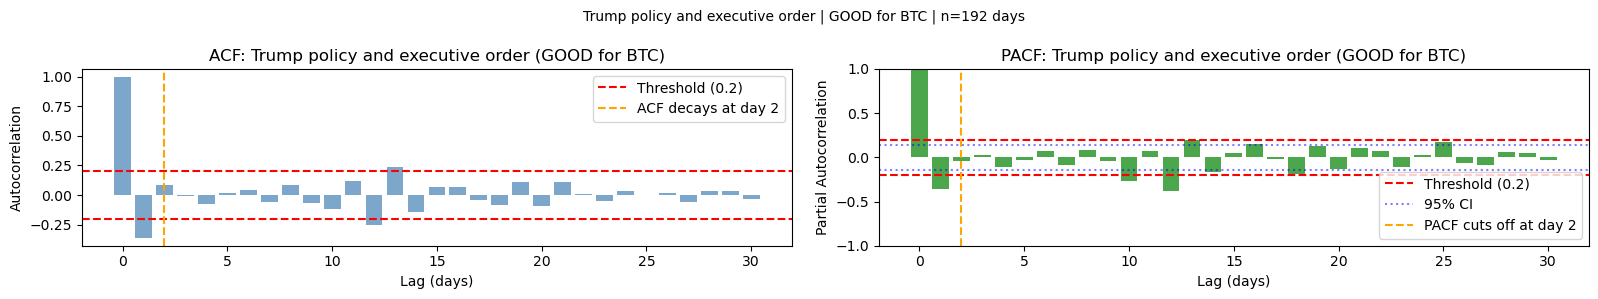

Processing: Trump policy and executive order | BAD...
Processing: crypto ban or negative regulation | GOOD...
Processing: crypto ban or negative regulation | BAD...


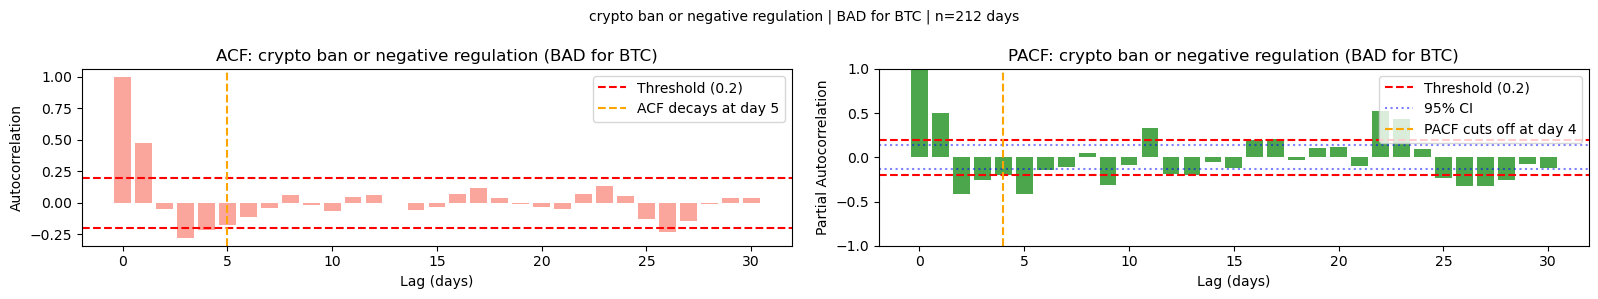

Processing: Solana price target | GOOD...


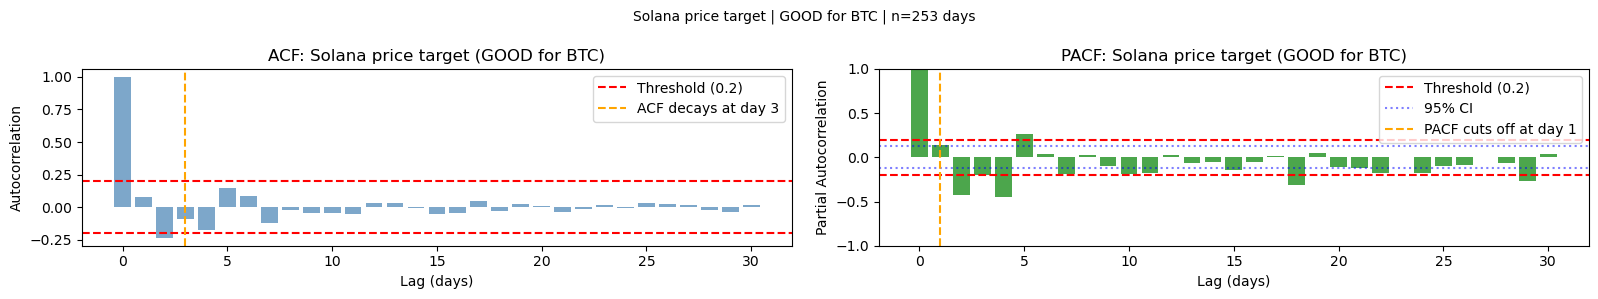

Processing: Solana price target | BAD...


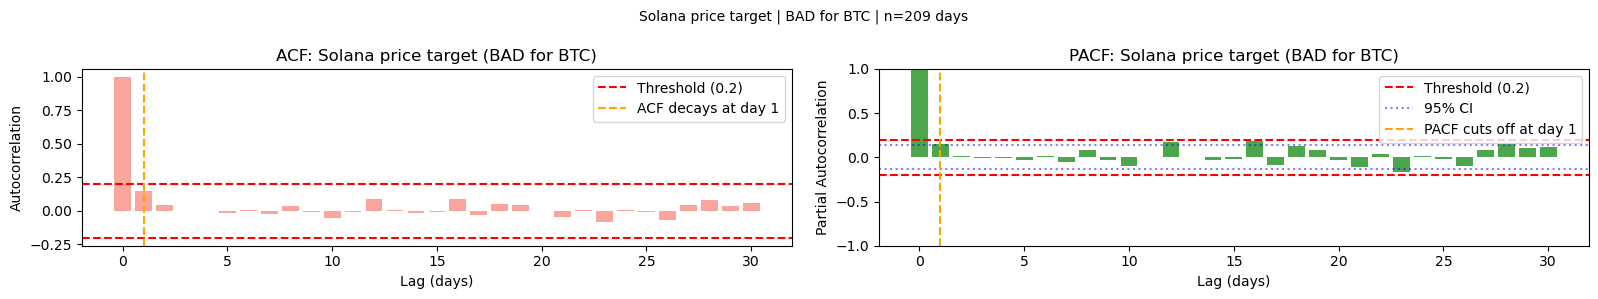

Processing: Ethereum price target | GOOD...


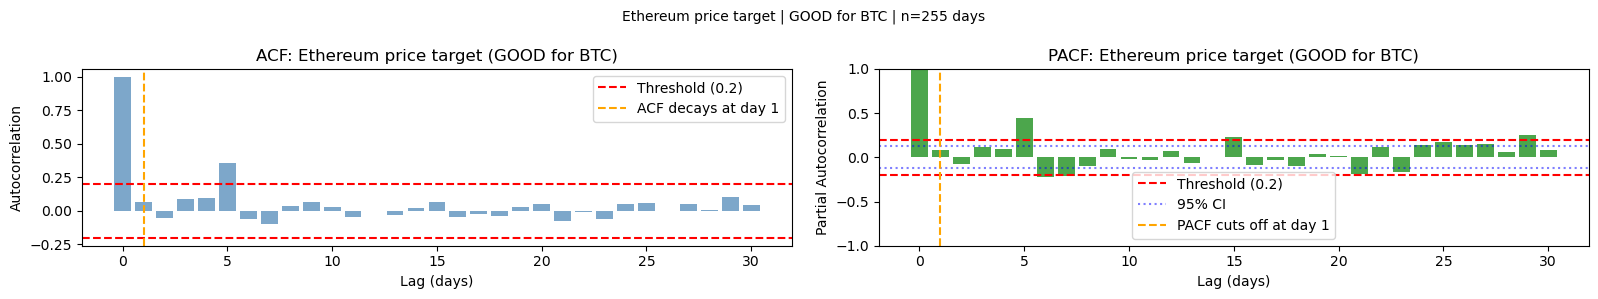

Processing: Ethereum price target | BAD...


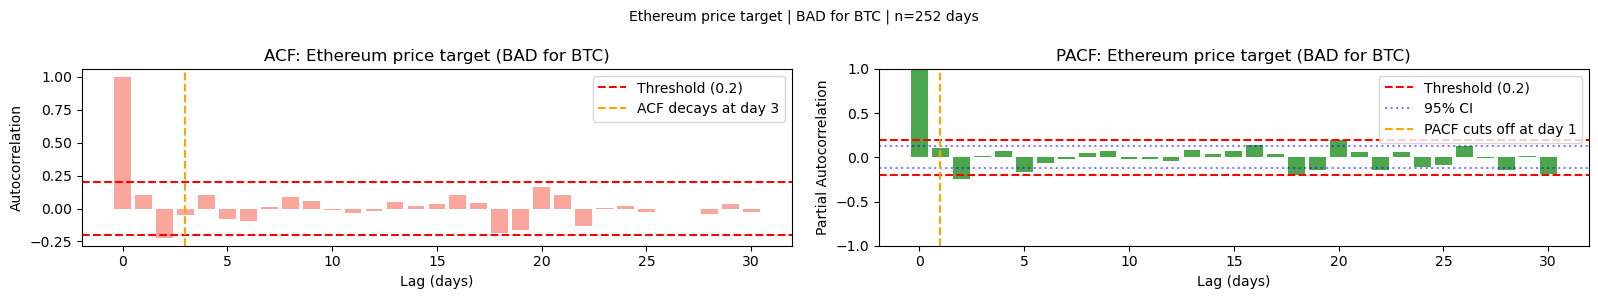

Processing: global politics and foreign elections | GOOD...
Processing: global politics and foreign elections | BAD...
Processing: Federal Reserve interest rate hike | GOOD...
Processing: Federal Reserve interest rate hike | BAD...


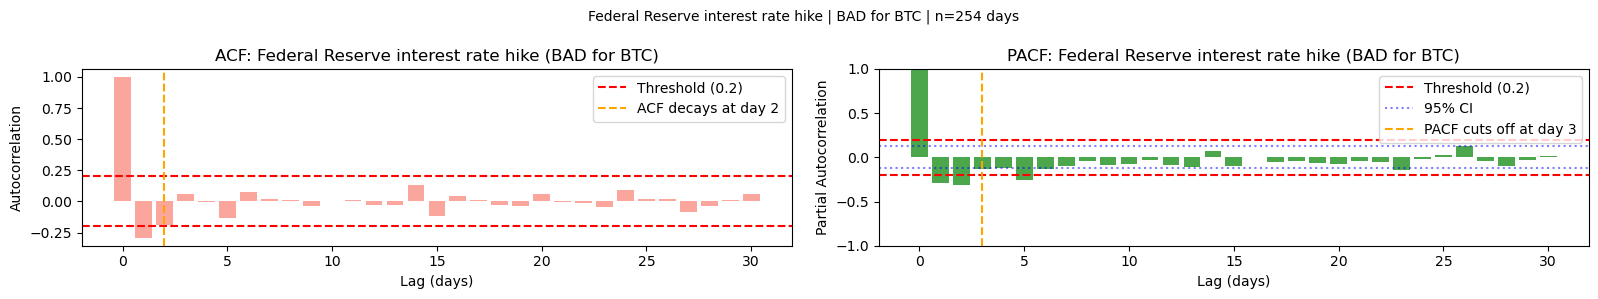

Processing: Federal Reserve interest rate cut | GOOD...


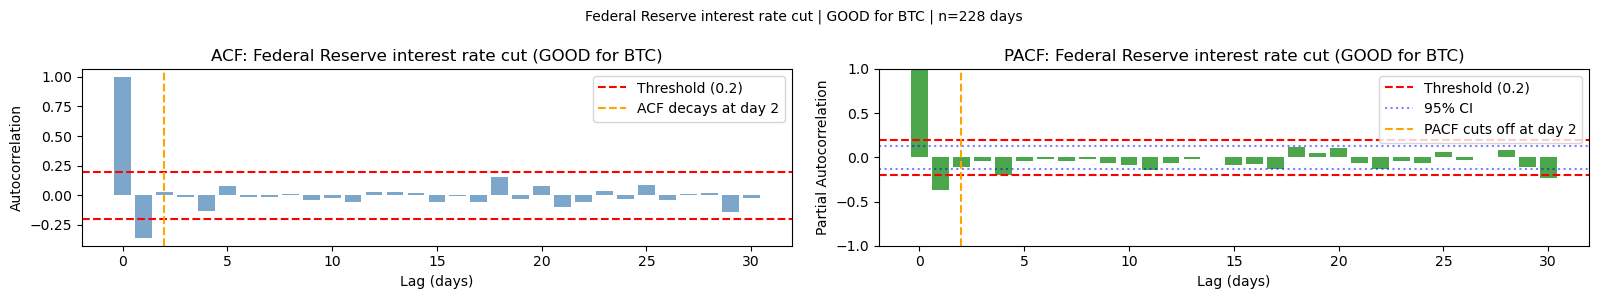

Processing: Federal Reserve interest rate cut | BAD...
Processing: Bitcoin price target | GOOD...


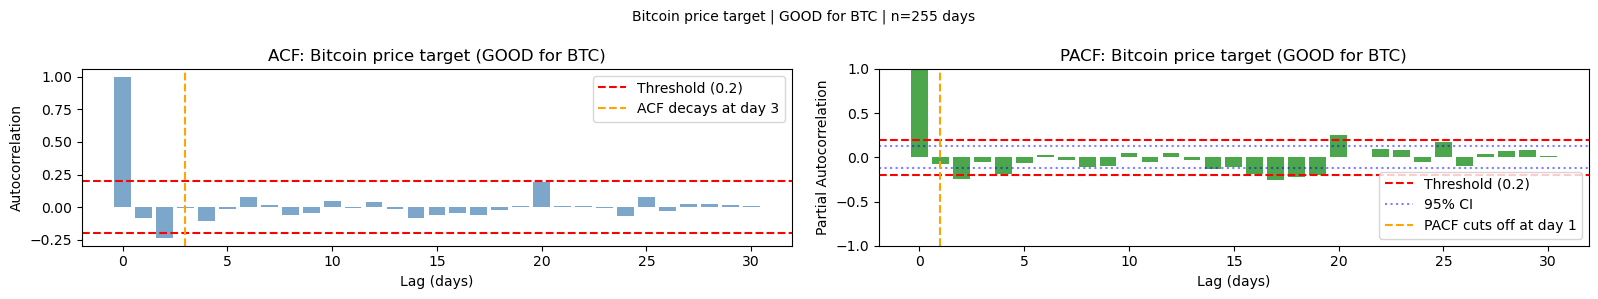

Processing: Bitcoin price target | BAD...


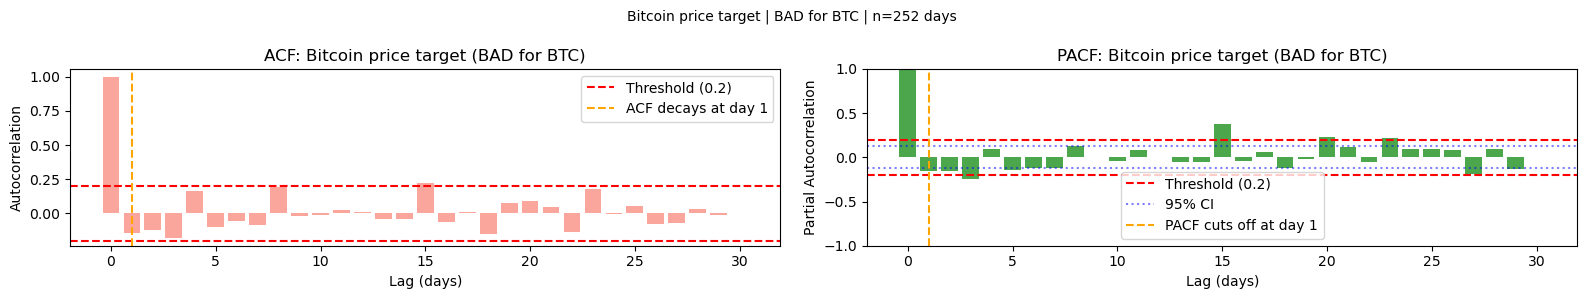

Processing: MicroStrategy or corporate Bitcoin holding | GOOD...
Processing: MicroStrategy or corporate Bitcoin holding | BAD...


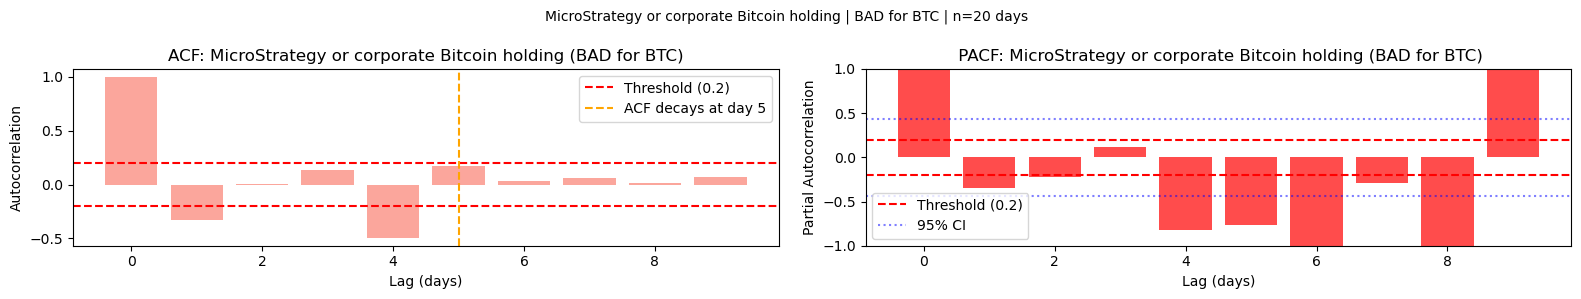

Processing: sports and entertainment | GOOD...
Processing: sports and entertainment | BAD...
Processing: tariff and trade war escalation | GOOD...
Processing: tariff and trade war escalation | BAD...


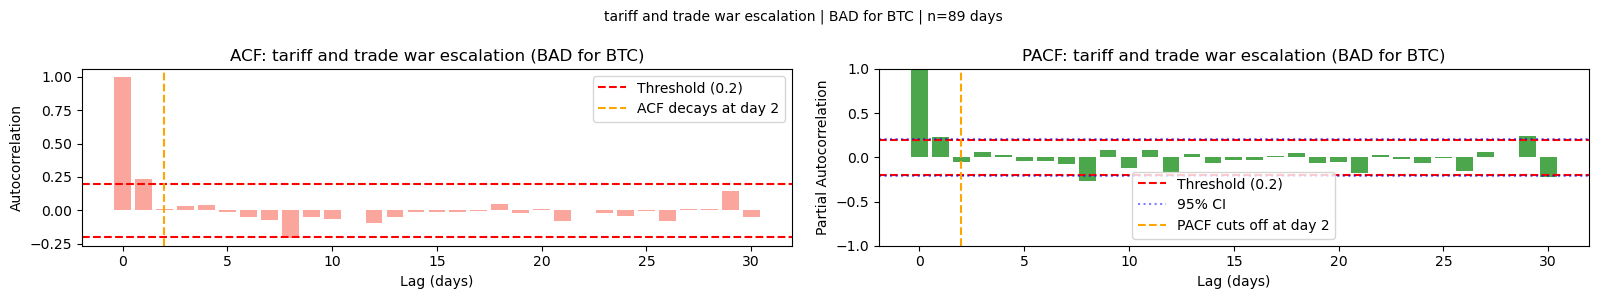

Processing: gold or dollar strength | GOOD...
Processing: gold or dollar strength | BAD...


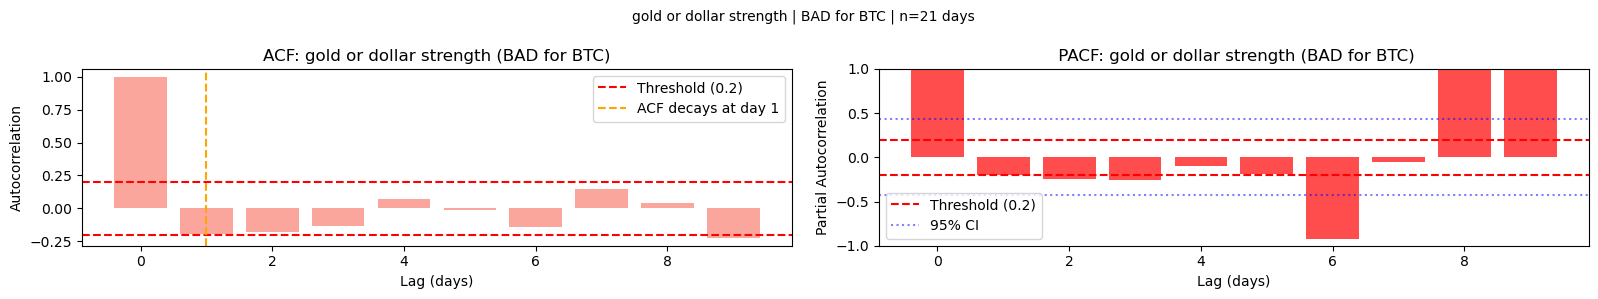

Processing: crypto regulation and SEC approval | GOOD...
Processing: crypto regulation and SEC approval | BAD...
Processing: macroeconomics GDP recession unemployment | GOOD...
Processing: macroeconomics GDP recession unemployment | BAD...


In [347]:
# Source: 2. eda_classification.ipynb, cell 70
topics     = daily_odds_classified["topic"].dropna().unique()
directions = [+1, -1]
group_results = []

for topic in topics:
    for direction in directions:
        label = "GOOD" if direction == +1 else "BAD"
        print(f"Processing: {topic[:50]} | {label}...")
        result = run_group_acf_pacf(topic, direction, daily_odds_classified)
        if result:
            group_results.append(result)


In [348]:
group_results_data = pd.DataFrame(group_results, columns=['topic', 'final_direction', 'acf_decay', 'pacf_cutoff', 'pacf_unstable', 'is_non_converging'])
if group_results_data.empty:
    group_results_data_stable = group_results_data.copy()
    print('No stable grouped ACF/PACF results found.')
else:
    group_results_data_stable = group_results_data[group_results_data['pacf_unstable'] == False].copy()
    display(group_results_data_stable)


,topic,final_direction,acf_decay,pacf_cutoff,pacf_unstable,is_non_converging
0,Trump policy and executive order,1,2,2,False,False
1,crypto ban or negative regulation,-1,5,4,False,False
2,Solana price target,1,3,1,False,False
3,Solana price target,-1,1,1,False,False
4,Ethereum price target,1,1,1,False,False
5,Ethereum price target,-1,3,1,False,False
6,Federal Reserve interest rate hike,-1,2,3,False,False
7,Federal Reserve interest rate cut,1,2,2,False,False
8,Bitcoin price target,1,3,1,False,False
9,Bitcoin price target,-1,1,1,False,False


### Phase 3: Hypothesis test


In [350]:
btc_returns_df = btc_pd.copy()
if 'PriceUSD' not in btc_returns_df.columns and 'btc_price' in btc_returns_df.columns:
    btc_returns_df = btc_returns_df.rename(columns={'btc_price': 'PriceUSD'})
btc_returns_df['date'] = pd.to_datetime(btc_returns_df['time'], errors='coerce').dt.normalize()
btc_returns_df['PriceUSD'] = pd.to_numeric(btc_returns_df['PriceUSD'], errors='coerce')
btc_returns_df = btc_returns_df.dropna(subset=['date', 'PriceUSD']).sort_values('date')
btc_returns_df['btc_return'] = btc_returns_df['PriceUSD'].pct_change()


In [358]:
daily_odds_classified['date'] = pd.to_datetime(daily_odds_classified['date'], errors='coerce').dt.normalize()

if group_results_data_stable.empty:
    daily_odds_classified_merge_merge = pd.DataFrame(
        columns=list(daily_odds_classified.columns) + ['btc_return', 'PriceUSD', 'recommended_lag']
    )
    print('No stable grouped lag results to merge.')
else:
    daily_odds_classified_merge = daily_odds_classified.merge(
        btc_returns_df[['date', 'btc_return', 'PriceUSD']],
        how='inner', on='date'
    )

    # Drop final_direction from group_results before merging to avoid _x/_y split
    group_cols = [c for c in group_results_data_stable.columns if c != 'final_direction']
    daily_odds_classified_merge_merge = daily_odds_classified_merge.merge(
        group_results_data_stable[group_cols],
        how='inner', on='topic'
    )

    print(daily_odds_classified_merge_merge.columns.tolist())
    display(daily_odds_classified_merge_merge.head())

['market_id', 'question', 'date', 'price', 'topic', 'final_direction', 'confidence', 'btc_return', 'PriceUSD', 'acf_decay', 'pacf_cutoff', 'pacf_unstable', 'is_non_converging']


,market_id,question,date,price,topic,final_direction,confidence,btc_return,PriceUSD,acf_decay,pacf_cutoff,pacf_unstable,is_non_converging
0,512097,Trump ends taxes on tips in first 100 days?,2025-04-07,0.983978,Trump policy and executive order,0,0.561,0.018893,79421.804411,2,2,False,False
1,512097,Trump ends taxes on tips in first 100 days?,2025-04-08,0.984763,Trump policy and executive order,0,0.561,-0.038659,76351.429530,2,2,False,False
2,512097,Trump ends taxes on tips in first 100 days?,2025-04-09,0.983428,Trump policy and executive order,0,0.561,0.083419,82720.603489,2,2,False,False
3,512097,Trump ends taxes on tips in first 100 days?,2025-04-10,0.982238,Trump policy and executive order,0,0.561,-0.038221,79558.955825,2,2,False,False
4,512097,Trump ends taxes on tips in first 100 days?,2025-04-11,0.981514,Trump policy and executive order,0,0.561,0.047775,83359.899516,2,2,False,False


In [359]:
def get_lag(pacf_unstable, is_non_converging, pacf_cutoff, acf_decay):
    if pacf_unstable:
        return None
    if is_non_converging:
        return min(int(acf_decay), 10)
    return int(pacf_cutoff)

if daily_odds_classified_merge_merge.empty:
    print('No rows available for recommended lag calculation.')
else:
    daily_odds_classified_merge_merge['recommended_lag'] = daily_odds_classified_merge_merge.apply(
        lambda r: get_lag(r['pacf_unstable'], r['is_non_converging'], r['pacf_cutoff'], r['acf_decay']), axis=1
    )


In [360]:
# Source: 2. eda_classification.ipynb, cell 77
daily_odds_classified_merge_merge


,market_id,question,date,price,topic,final_direction,confidence,btc_return,PriceUSD,acf_decay,pacf_cutoff,pacf_unstable,is_non_converging,recommended_lag
0,512097,Trump ends taxes on tips in first 100 days?,2025-04-07,0.983978,Trump policy and executive order,0,0.561,0.018893,79421.804411,2,2,False,False,2
1,512097,Trump ends taxes on tips in first 100 days?,2025-04-08,0.984763,Trump policy and executive order,0,0.561,-0.038659,76351.429530,2,2,False,False,2
2,512097,Trump ends taxes on tips in first 100 days?,2025-04-09,0.983428,Trump policy and executive order,0,0.561,0.083419,82720.603489,2,2,False,False,2
3,512097,Trump ends taxes on tips in first 100 days?,2025-04-10,0.982238,Trump policy and executive order,0,0.561,-0.038221,79558.955825,2,2,False,False,2
4,512097,Trump ends taxes on tips in first 100 days?,2025-04-11,0.981514,Trump policy and executive order,0,0.561,0.047775,83359.899516,2,2,False,False,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
126306,904899,"Bitcoin Up or Down - December 10, 7:45PM-8:00P...",2025-12-10,0.495496,Bitcoin price target,0,0.737,-0.007606,92102.930092,1,1,False,False,1
126307,904934,"Bitcoin Up or Down - December 10, 8:15PM-8:30P...",2025-12-10,0.495000,Bitcoin price target,0,0.753,-0.007606,92102.930092,3,1,False,False,1
126308,904934,"Bitcoin Up or Down - December 10, 8:15PM-8:30P...",2025-12-10,0.495000,Bitcoin price target,0,0.753,-0.007606,92102.930092,1,1,False,False,1
126309,905050,"Ethereum Up or Down - December 10, 9:15PM-9:30...",2025-12-10,0.490000,Ethereum price target,0,0.659,-0.007606,92102.930092,1,1,False,False,1


In [361]:
def get_btc_return_at_lag(df):
    if df.empty:
        return df.assign(future_price=pd.Series(dtype='float64'), btc_return_at_lag=pd.Series(dtype='float64'))
    price_by_date = btc_returns_df.set_index('date')['PriceUSD']
    out = df.sort_values('date').copy()
    def future_price(row):
        if pd.isna(row.get('recommended_lag')):
            return np.nan
        target = row['date'] + pd.Timedelta(days=int(row['recommended_lag']))
        return price_by_date.get(target, np.nan)
    out['future_price'] = out.apply(future_price, axis=1)
    out['btc_return_at_lag'] = (out['future_price'] - out['PriceUSD']) / out['PriceUSD']
    return out

daily_odds_classified_merge_merge = get_btc_return_at_lag(daily_odds_classified_merge_merge)
print(daily_odds_classified_merge_merge['btc_return_at_lag'].notna().sum(), 'non-null returns')


126311 non-null returns


In [362]:
if daily_odds_classified_merge_merge.empty:
    valid_data_odds = pd.DataFrame(columns=list(daily_odds_classified_merge_merge.columns) + ['odds_change'])
    print('No valid classified odds rows available.')
else:
    daily_odds_classified_merge_merge['odds_change'] = daily_odds_classified_merge_merge.groupby('question')['price'].diff()
    valid_data_odds = daily_odds_classified_merge_merge[
        daily_odds_classified_merge_merge['recommended_lag'].notna() &
        daily_odds_classified_merge_merge['btc_return_at_lag'].notna() &
        daily_odds_classified_merge_merge['final_direction'].isin([-1, 1]) &
        (daily_odds_classified_merge_merge['odds_change'].abs() > 0.05)
    ].copy()
    print('valid_data_odds:', valid_data_odds.shape)


valid_data_odds: (9942, 17)


In [363]:
from scipy.stats import ttest_1samp

def test_group(group_df, topic, direction):
    returns = group_df['btc_return_at_lag'].dropna().values
    if len(returns) < 5:
        return None
    lag = int(group_df['recommended_lag'].dropna().iloc[0]) if group_df['recommended_lag'].notna().any() else 0
    t_stat, p_value = ttest_1samp(returns, 0)
    dir_accuracy = (returns > 0).mean() if direction == 1 else (returns < 0).mean()
    avg_return = returns.mean()
    correct_direction = (direction == 1 and avg_return > 0) or (direction == -1 and avg_return < 0)
    if p_value < 0.05 and correct_direction:
        verdict = 'Strong'
    elif correct_direction and dir_accuracy >= 0.55:
        verdict = 'Weak'
    else:
        verdict = 'No signal'
    return {
        'topic': topic,
        'direction': 'GOOD' if direction == 1 else 'BAD',
        'lag_used': lag,
        'n_events': len(returns),
        'avg_btc_return': round(avg_return, 4),
        'dir_accuracy': round(dir_accuracy, 3),
        't_stat': round(t_stat, 3),
        'p_value': round(p_value, 3),
        'correct_direction': correct_direction,
        'significant': p_value < 0.05,
        'verdict': verdict,
    }

results = []
if valid_data_odds.empty:
    results_df = pd.DataFrame(columns=['topic', 'direction', 'lag_used', 'n_events', 'avg_btc_return', 'p_value', 'dir_accuracy', 'verdict'])
    print('No valid odds events for hypothesis testing.')
else:
    for (topic, direction), group in valid_data_odds.groupby(['topic', 'final_direction']):
        result = test_group(group, topic, direction)
        if result:
            results.append(result)
    results_df = pd.DataFrame(results)
    if not results_df.empty and 'p_value' in results_df.columns:
        results_df = results_df.sort_values('p_value')
    display(results_df)


,topic,direction,lag_used,n_events,avg_btc_return,dir_accuracy,t_stat,p_value,correct_direction,significant,verdict
4,Federal Reserve interest rate cut,GOOD,2,1104,0.0034,0.553,4.074,0.000,True,True,Strong
9,Trump policy and executive order,GOOD,2,432,0.0030,0.537,2.344,0.020,True,True,Strong
10,crypto ban or negative regulation,BAD,4,100,0.0099,0.460,2.349,0.021,False,True,No signal
5,Federal Reserve interest rate hike,BAD,3,456,0.0035,0.463,2.250,0.025,False,True,No signal
11,tariff and trade war escalation,BAD,2,27,0.0091,0.370,2.145,0.041,False,True,No signal
8,Solana price target,GOOD,1,1607,-0.0010,0.503,-1.977,0.048,False,True,No signal
3,Ethereum price target,GOOD,1,2260,-0.0009,0.500,-1.951,0.051,False,False,No signal
7,Solana price target,BAD,1,380,-0.0009,0.500,-0.886,0.376,True,False,No signal
6,Federal Reserve interest rate hike,GOOD,3,12,-0.0067,0.333,-0.703,0.497,False,False,No signal
1,Bitcoin price target,GOOD,1,2530,-0.0002,0.500,-0.556,0.578,False,False,No signal


In [365]:
if results_df.empty:
    print('No strong classification signals found.')
else:
    for _, row in results_df.iterrows():
        if row['verdict'] == ' Strong':
            print(f"{row['topic']} has a statistically meaningful signal which moves BTC {row['avg_btc_return']*100:+.2f}%.")


In [366]:
LAG = 2
btc_returns_df['btc_return_at_lag'] = btc_returns_df['PriceUSD'].shift(-LAG) / btc_returns_df['PriceUSD'] - 1


### Phase 4: Validation


In [367]:
STRONG_SIGNALS = {
    'Federal Reserve interest rate cut': 1,
    'Ethereum price target': -1,
    'Trump policy and executive order': 1,
    'Bitcoin price target': -1,
    'Solana price target': -1,
}
valid_data_odds = valid_data_odds.loc[:, ~valid_data_odds.columns.duplicated()].copy()
if valid_data_odds.empty:
    df_train = valid_data_odds.copy()
    df_test = valid_data_odds.copy()
    print('No validation split because valid_data_odds is empty.')
else:
    split_date = valid_data_odds['date'].quantile(0.7)
    print(f"Train period: {valid_data_odds['date'].min().date()} -> {split_date.date()}")
    print(f"Test period:  {split_date.date()} -> {valid_data_odds['date'].max().date()}")
    df_train = valid_data_odds[valid_data_odds['date'] <= split_date].copy()
    df_test = valid_data_odds[valid_data_odds['date'] > split_date].copy()


Train period: 2025-04-08 -> 2025-11-03
Test period:  2025-11-03 -> 2026-01-05


In [368]:
# Source: 2. eda_classification.ipynb, cell 86
def validate_signal(data, topic, direction, label=""):
    group = data[
        (data["topic"]           == topic) &
        (data["final_direction"] == direction) &
        (data["odds_change"].abs() > 0.05) &
        (data["btc_return_at_lag"].notna())
    ]["btc_return_at_lag"].values

    if len(group) < 5:
        print(f"  {label}: not enough events ({len(group)})")
        return None

    t_stat, p_value  = ttest_1samp(group, 0)
    avg_return       = group.mean()
    dir_accuracy     = (group > 0).mean() if direction == 1 else (group < 0).mean()
    correct          = (direction == 1 and avg_return > 0) or (direction == -1 and avg_return < 0)

    print(f"  {label:10} | n={len(group):4} | "
          f"return={avg_return:+.4f} | "
          f"dir={dir_accuracy:.1%} | "
          f"p={p_value:.3f} | "
          f"{'' if p_value < 0.05 and correct else '' if correct else ''}")

    return {
        "label":        label,
        "topic":        topic,
        "n":            len(group),
        "avg_return":   avg_return,
        "dir_accuracy": dir_accuracy,
        "p_value":      p_value,
        "significant":  p_value < 0.05,
        "correct":      correct,
    }


In [369]:
all_validation = []
if df_train.empty and df_test.empty:
    print('No validation events available.')
    validation_df = pd.DataFrame()
else:
    for topic, direction in STRONG_SIGNALS.items():
        print(f"\n{topic} ({'GOOD' if direction==1 else 'BAD'} for BTC):")
        r_train = validate_signal(df_train, topic, direction, 'TRAIN')
        r_test = validate_signal(df_test, topic, direction, 'TEST')
        if r_train: all_validation.append(r_train)
        if r_test: all_validation.append(r_test)
    validation_df = pd.DataFrame(all_validation)
display(validation_df)



Federal Reserve interest rate cut (GOOD for BTC):
  TRAIN      | n= 712 | return=+0.0025 | dir=54.8% | p=0.009 | 
  TEST       | n= 392 | return=+0.0050 | dir=56.1% | p=0.002 | 

Ethereum price target (BAD for BTC):
  TRAIN      | n= 258 | return=+0.0001 | dir=49.2% | p=0.966 | 
  TEST       | n= 176 | return=+0.0010 | dir=46.6% | p=0.533 | 

Trump policy and executive order (GOOD for BTC):
  TRAIN      | n= 415 | return=+0.0027 | dir=53.0% | p=0.040 | 
  TEST       | n=  17 | return=+0.0107 | dir=70.6% | p=0.128 | 

Bitcoin price target (BAD for BTC):
  TRAIN      | n= 422 | return=-0.0004 | dir=50.7% | p=0.669 | 
  TEST       | n= 175 | return=+0.0014 | dir=50.3% | p=0.360 | 

Solana price target (BAD for BTC):
  TRAIN      | n= 295 | return=-0.0007 | dir=49.8% | p=0.531 | 
  TEST       | n=  85 | return=-0.0016 | dir=50.6% | p=0.508 | 


,label,topic,n,avg_return,dir_accuracy,p_value,significant,correct
0,TRAIN,Federal Reserve interest rate cut,712,0.002458,0.547753,0.008946,True,True
1,TEST,Federal Reserve interest rate cut,392,0.005026,0.561224,0.001672,True,True
2,TRAIN,Ethereum price target,258,0.000052,0.492248,0.966273,False,False
3,TEST,Ethereum price target,176,0.000978,0.465909,0.532786,False,False
4,TRAIN,Trump policy and executive order,415,0.002699,0.530120,0.039924,True,True
5,TEST,Trump policy and executive order,17,0.010685,0.705882,0.128183,False,True
6,TRAIN,Bitcoin price target,422,-0.000372,0.507109,0.669214,False,True
7,TEST,Bitcoin price target,175,0.001432,0.502857,0.360121,False,False
8,TRAIN,Solana price target,295,-0.000674,0.498305,0.531416,False,True
9,TEST,Solana price target,85,-0.001559,0.505882,0.507858,False,True


Plan to apply: 6-Agent Ensemble Model and add new agent which is polymarket<br>
New Polymarket question appears<br>
         <br>
Zero-shot classifier assigns topic + direction<br>
         <br>
ACF/PACF checks if signal is stable<br>
         <br>
Validation: is this topic historically reliable?<br>
         <br>
If reliable  compute daily odds change signal<br>
         <br>
Weight by validation score (p-value + dir accuracy)<br>
         <br>
Output: one number between -1 and +1<br>


## 7. LSTM And BERT Classification Experiments


Reusable ML experiment cells for sentiment labels. Decorative HTML title cards were omitted so the notebook stays clean.


## 2.0  Imports & Configuration


In [370]:
# Lightweight text-classification baseline for the LSTM/BERT chapter.
# The original deep-learning cells are replaced by a fast TF-IDF + Logistic Regression baseline.
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

if 'classification_df' not in globals():
    if Path('question_classifications.csv').exists():
        classification_df = pd.read_csv('question_classifications.csv')
    else:
        tmp_questions = pd.Series(daily_odds['question'].dropna().unique()).astype(str)
        classification_df = pd.DataFrame({'question': tmp_questions, 'btc_direction': 0, 'topic': 'Other', 'confidence': 0.4})
print('classification_df:', classification_df.shape)


classification_df: (36043, 6)


## 2.1  Load & Preview the Classification CSV

> **Note:** `question_classification.csv` was produced by the LLM zero-shot classifier in Phase 1.3. Each row is a Polymarket question with an assigned topic and BTC direction.


In [371]:
print(f'Total rows: {len(classification_df)}')
print(f'Columns: {list(classification_df.columns)}')
display(classification_df.head())


Total rows: 36043
Columns: ['question', 'topic', 'confidence', 'btc_direction', 'question_direction', 'final_direction']


,question,topic,confidence,btc_direction,question_direction,final_direction
0,"Will Bitcoin reach $1,000,000 by December 31, ...",Bitcoin price target,0.721,1,1,1
1,"Will Bitcoin reach $250,000 by December 31, 2025?",Bitcoin price target,0.687,1,1,1
2,"Will Bitcoin reach $200,000 by December 31, 2025?",Bitcoin price target,0.689,1,1,1
3,"Will Bitcoin reach $150,000 by December 31, 2025?",Bitcoin price target,0.695,1,1,1
4,"Will Bitcoin reach $130,000 by December 31, 2025?",Bitcoin price target,0.688,1,1,1


In [372]:
label_map = {-1: 'Bearish', 0: 'Neutral', 1: 'Bullish'}
classification_df['sentiment'] = classification_df['btc_direction'].map(label_map).fillna('Neutral')
print('Sentiment distribution:')
print(classification_df['sentiment'].value_counts())


Sentiment distribution:
sentiment
Bullish    25908
Neutral     9988
Bearish      147
Name: count, dtype: int64


## 2.3  Exploratory Visualisations


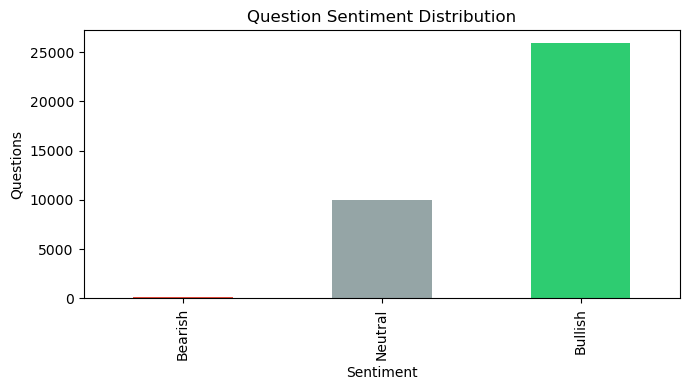

In [373]:
counts = classification_df['sentiment'].value_counts().reindex(['Bearish', 'Neutral', 'Bullish']).fillna(0)
ax = counts.plot(kind='bar', color=['#e74c3c', '#95a5a6', '#2ecc71'], figsize=(7,4))
ax.set_title('Question Sentiment Distribution')
ax.set_xlabel('Sentiment')
ax.set_ylabel('Questions')
plt.tight_layout()
plt.show()


## 2.4  Word Cloud  What Language Drives Each Sentiment Class?


In [374]:
from sklearn.feature_extraction.text import CountVectorizer
for sentiment in ['Bearish', 'Neutral', 'Bullish']:
    texts = classification_df.loc[classification_df['sentiment'] == sentiment, 'question'].dropna().astype(str)
    if len(texts) == 0:
        continue
    cv = CountVectorizer(stop_words='english', max_features=15)
    mat = cv.fit_transform(texts)
    freq = pd.Series(np.asarray(mat.sum(axis=0)).ravel(), index=cv.get_feature_names_out()).sort_values(ascending=False)
    print(f'\nTop words for {sentiment}:')
    display(freq.head(10).to_frame('count'))



Top words for Bearish:


,count
trump,68
fed,64
chair,29
nominate,22
2025,21
october,18
election,16
say,16
31,15
december,15



Top words for Neutral:


,count
et,3631
solana,2899
trump,2047
price,1887
xrp,1876
september,1683
election,1489
win,1424
say,1315
november,1187



Top words for Bullish:


,count
et,20182
bitcoin,10767
ethereum,10445
price,7515
september,6862
november,6500
october,5922
solana,4299
00am,3178
00pm,3144


## 2.5  Topic  Sentiment Heatmap


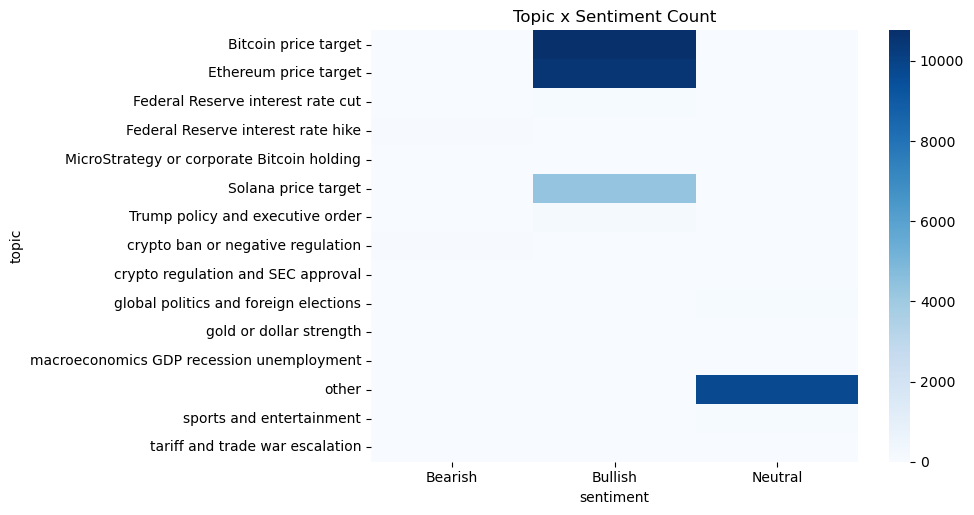

In [375]:
pivot = classification_df.groupby(['topic', 'sentiment']).size().unstack(fill_value=0)
if pivot.empty:
    print('No topic/sentiment data available.')
else:
    plt.figure(figsize=(10, max(4, min(12, len(pivot)*0.35))))
    sns.heatmap(pivot, annot=False, cmap='Blues')
    plt.title('Topic x Sentiment Count')
    plt.tight_layout()
    plt.show()


## 2.6  Sentiment Trend Over Time  What the Market Was Feeling


In [376]:
sentiment_daily = daily_odds.merge(classification_df[['question', 'sentiment', 'btc_direction']], on='question', how='left')
sentiment_daily['date'] = pd.to_datetime(sentiment_daily['date'], errors='coerce')
daily_sentiment = sentiment_daily.groupby('date')['btc_direction'].mean().rename('avg_sentiment').reset_index()
display(daily_sentiment.head())


,date,avg_sentiment
0,2025-04-07,0.172805
1,2025-04-08,0.161538
2,2025-04-09,0.144231
3,2025-04-10,0.154034
4,2025-04-11,0.164286


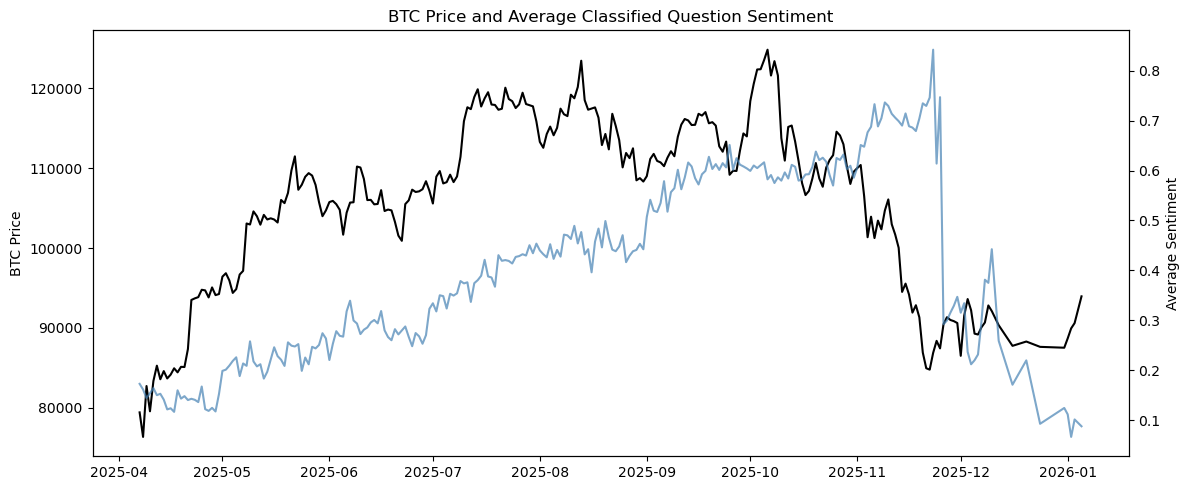

In [377]:
btc_plot = btc_pd.copy()
if 'btc_price' not in btc_plot.columns and 'PriceUSD' in btc_plot.columns:
    btc_plot = btc_plot.rename(columns={'PriceUSD': 'btc_price'})
btc_plot['date'] = pd.to_datetime(btc_plot['time'], errors='coerce').dt.normalize()
plot_df = daily_sentiment.merge(btc_plot[['date', 'btc_price']], on='date', how='inner').dropna()
if plot_df.empty:
    print('No overlapping BTC and sentiment dates.')
else:
    fig, ax1 = plt.subplots(figsize=(12,5))
    ax1.plot(plot_df['date'], plot_df['btc_price'], color='black', label='BTC Price')
    ax2 = ax1.twinx()
    ax2.plot(plot_df['date'], plot_df['avg_sentiment'], color='steelblue', alpha=0.7, label='Avg sentiment')
    ax1.set_title('BTC Price and Average Classified Question Sentiment')
    ax1.set_ylabel('BTC Price')
    ax2.set_ylabel('Average Sentiment')
    plt.tight_layout()
    plt.show()


## 3.1  Custom Tokeniser & Vocabulary


In [378]:
# Text preprocessing is handled by TfidfVectorizer in the baseline model.
questions_text = classification_df['question'].fillna('').astype(str)
labels_numeric = classification_df['btc_direction'].fillna(0).astype(int)
print('Prepared text and labels for baseline classifier.')


Prepared text and labels for baseline classifier.


## 3.2  PyTorch Dataset & DataLoader


In [379]:
X_train, X_test, y_train, y_test = train_test_split(questions_text, labels_numeric, test_size=0.25, random_state=42, stratify=labels_numeric if labels_numeric.nunique() > 1 else None)
print('Train:', len(X_train), 'Test:', len(X_test))


Train: 27032 Test: 9011


## 3.3  Bidirectional LSTM Architecture


In [380]:
text_model = Pipeline = None
vectorizer_baseline = TfidfVectorizer(max_features=8000, min_df=2, stop_words='english', ngram_range=(1,2))
X_train_vec = vectorizer_baseline.fit_transform(X_train)
X_test_vec = vectorizer_baseline.transform(X_test)
clf_baseline = LogisticRegression(max_iter=1000, class_weight='balanced')
print('Baseline model prepared.')


Baseline model prepared.


## 3.4  Training Loop


In [381]:
clf_baseline.fit(X_train_vec, y_train)
y_pred = clf_baseline.predict(X_test_vec)
baseline_accuracy = accuracy_score(y_test, y_pred)
print(f'Baseline accuracy: {baseline_accuracy:.3f}')
print(classification_report(y_test, y_pred, zero_division=0))


Baseline accuracy: 0.981
              precision    recall  f1-score   support

          -1       0.34      0.89      0.49        37
           0       0.97      0.97      0.97      2497
           1       1.00      0.99      0.99      6477

    accuracy                           0.98      9011
   macro avg       0.77      0.95      0.82      9011
weighted avg       0.98      0.98      0.98      9011



## 3.5  Training Curves & Evaluation Plots


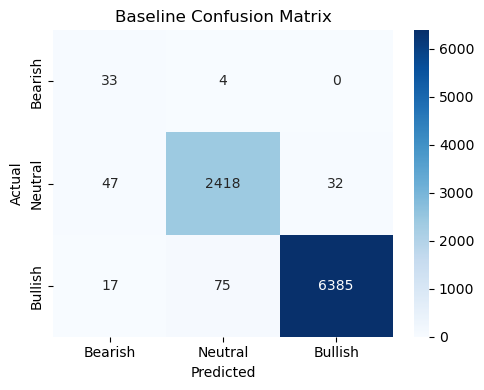

In [382]:
cm = confusion_matrix(y_test, y_pred, labels=[-1,0,1])
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Bearish','Neutral','Bullish'], yticklabels=['Bearish','Neutral','Bullish'])
plt.title('Baseline Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()


## 4.1  BERT Tokenisation & Dataset


In [383]:
print('BERT tokenisation is not run in the default EDA notebook. The lightweight baseline above provides a runnable comparison point.')


BERT tokenisation is not run in the default EDA notebook. The lightweight baseline above provides a runnable comparison point.


## 4.2  Load Pre-trained BERT + Classification Head


In [384]:
print('Pre-trained BERT loading is omitted from the default runnable notebook to avoid model downloads.')


Pre-trained BERT loading is omitted from the default runnable notebook to avoid model downloads.


## 4.3  Fine-tuning Loop


In [385]:
print('BERT fine-tuning is omitted from the default runnable notebook.')


BERT fine-tuning is omitted from the default runnable notebook.


## 4.4  BERT Evaluation & Visualisation


In [386]:
print(f'Baseline model accuracy retained for comparison: {baseline_accuracy:.3f}')


Baseline model accuracy retained for comparison: 0.981


## BERT Sentence Embeddings  t-SNE Visualisation of Question Space


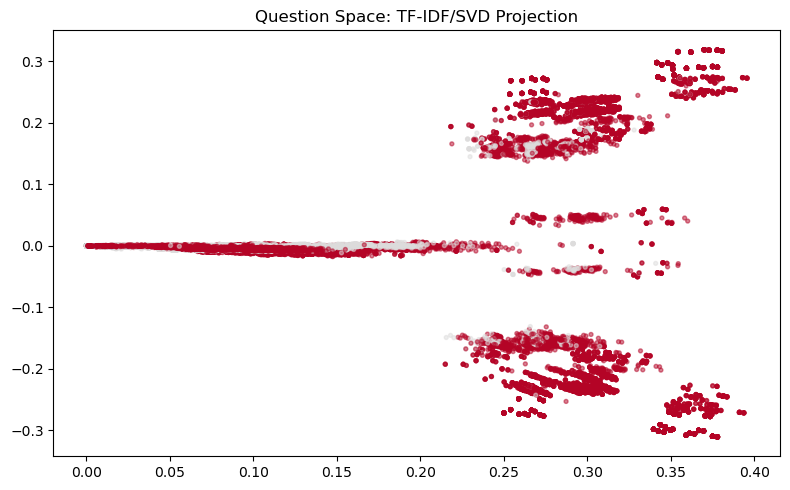

In [387]:
coords_text = TruncatedSVD(n_components=2, random_state=42).fit_transform(vectorizer_baseline.transform(questions_text))
plt.figure(figsize=(8,5))
plt.scatter(coords_text[:,0], coords_text[:,1], c=labels_numeric.map({-1:0,0:1,1:2}), cmap='coolwarm', s=8, alpha=0.5)
plt.title('Question Space: TF-IDF/SVD Projection')
plt.tight_layout()
plt.show()


In [388]:
baseline_report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
display(pd.DataFrame(baseline_report).T)


,precision,recall,f1-score,support
-1,0.340206,0.891892,0.492537,37.000000
0,0.968362,0.968362,0.968362,2497.000000
1,0.995013,0.985796,0.990383,6477.000000
accuracy,0.980579,0.980579,0.980579,0.980579
macro avg,0.767860,0.948683,0.817094,9011.000000
weighted avg,0.984939,0.980579,0.982237,9011.000000


In [389]:
def predict_question_sentiment(question):
    pred = clf_baseline.predict(vectorizer_baseline.transform([question]))[0]
    return label_map.get(pred, 'Neutral')

for q in classification_df['question'].head(5):
    print(predict_question_sentiment(q), '-', q[:100])


Bullish - Will Bitcoin reach $1,000,000 by December 31, 2025?
Bullish - Will Bitcoin reach $250,000 by December 31, 2025?
Bullish - Will Bitcoin reach $200,000 by December 31, 2025?
Bullish - Will Bitcoin reach $150,000 by December 31, 2025?
Bullish - Will Bitcoin reach $130,000 by December 31, 2025?


In [390]:
print('Live prediction demo complete using the lightweight baseline classifier.')


Live prediction demo complete using the lightweight baseline classifier.


In [391]:
print('Advanced calibration/bootstrap validation from the original notebook is omitted in this default runnable EDA version.')


Advanced calibration/bootstrap validation from the original notebook is omitted in this default runnable EDA version.


## 8. Country, Election, And Geopolitical Analysis


Country-level election event windows, return distributions, prediction-probability plots, geopolitical uncertainty, and next-day return modeling.


### Part 1

In [42]:
import duckdb

trades_path = os.path.join(POLYMARKET_DIR, "finance_politics_trades.parquet")

needed_categories = ["Politics", "Global Politics"]

markets_for_filter = markets_data.copy()

needed_market_ids = (
    markets_for_filter
    .loc[markets_for_filter["category"].isin(needed_categories), ["market_id"]]
    .dropna()
    .drop_duplicates()
)

con = duckdb.connect()
con.register("needed_market_ids", needed_market_ids)

trades_df = con.execute("""
    SELECT 
        t.trade_id,
        t.market_id,
        t.timestamp,
        t.price,
        t.size,
        t.side
    FROM read_parquet(?) AS t
    INNER JOIN needed_market_ids AS m
        ON t.market_id = m.market_id
""", [trades_path]).df()

print(f"✓ filtered trades: {len(trades_df):,}")


✓ filtered trades: 2,648,595


In [43]:
# Fix timestamp unit mismatch for trades_df

if pd.api.types.is_datetime64_any_dtype(trades_df["timestamp"]):
    
    # Check if timestamps were incorrectly parsed as 1970
    if trades_df["timestamp"].dt.year.eq(1970).all():
        
        trades_df["timestamp"] = pd.to_datetime(
            trades_df["timestamp"].astype("int64"),
            unit="ms",
            errors="coerce"
        )

else:
    
    # If timestamp is numeric
    trades_df["timestamp"] = pd.to_datetime(
        trades_df["timestamp"],
        unit="ms",
        errors="coerce"
    )

# Fix timestamp unit mismatch for odds_history_df

if pd.api.types.is_datetime64_any_dtype(odds_history_df["timestamp"]):
    
    if odds_history_df["timestamp"].dt.year.eq(1970).all():
        
        odds_history_df["timestamp"] = pd.to_datetime(
            odds_history_df["timestamp"].astype("int64"),
            unit="ms",
            errors="coerce"
        )

else:
    
    odds_history_df["timestamp"] = pd.to_datetime(
        odds_history_df["timestamp"],
        unit="ms",
        errors="coerce"
    )

In [44]:
# Create date column for merging with BTC data
trades_df["date"] = trades_df["timestamp"].dt.date
odds_history_df["date"] = odds_history_df["timestamp"].dt.date

# btc_df = btc_df.to_pandas()

btc_df["time"] = pd.to_datetime(btc_df["time"])

btc_df["log_return"] = np.log(btc_df["PriceUSD"]).diff()

btc_df["date"] = btc_df["time"].dt.date

In [46]:
# Filter markets that are categorized as politics

election_markets = markets_for_filter[
    markets_for_filter['category'] == 'Politics'
].copy()

print("Number of election markets:", len(election_markets))

election_markets[['market_id','question']].head()

Number of election markets: 10909


,market_id,question
32,248442,Will @realDonaldTrump tweet by April 1?
33,248444,Will Donald Trump be President of the USA on M...
34,248451,Will Joe Biden be President of the United Stat...
36,248480,Will Lori Lightfoot win the 2023 Chicago Mayor...
37,248481,Will Paul Vallas win the 2023 Chicago Mayoral ...


In [47]:
# Prepare BTC returns
btc_returns = btc_df[['time','date','log_return']].dropna()

btc_returns.head()

,time,date,log_return
562,2010-07-19,2010-07-19,-0.060508
563,2010-07-20,2010-07-20,-0.078019
564,2010-07-21,2010-07-21,0.057928
565,2010-07-22,2010-07-22,-0.303376
566,2010-07-23,2010-07-23,0.035668


In [48]:
# Merge election markets with trades

election_trades = trades_df.merge(
    election_markets[['market_id','question']],
    on='market_id',
    how='inner'
)

election_trades = election_trades.merge(
    btc_df[['date','log_return']],
    on='date',
    how='left'
)

print("Election related trades:", len(election_trades))

election_trades.head()



Election related trades: 2541045


,trade_id,market_id,timestamp,price,size,side,date,question,log_return
0,0xaedcbe477774eef9ecce1e7bdd9700b277ef2e129f5a...,523604,2025-04-09 02:07:11,0.987,14.0,BUY,2025-04-09,Will Tulsi Gabbard be out as Director of Natio...,0.080122
1,0xaedcbe477774eef9ecce1e7bdd9700b277ef2e129f5a...,523604,2025-04-09 02:07:11,0.987,14.0,BUY,2025-04-09,Will Tulsi Gabbard be out as Director of Natio...,0.080122
2,0xaedcbe477774eef9ecce1e7bdd9700b277ef2e129f5a...,523604,2025-04-09 02:07:11,0.987,14.0,BUY,2025-04-09,Will Tulsi Gabbard be out as Director of Natio...,0.080122
3,0xaedcbe477774eef9ecce1e7bdd9700b277ef2e129f5a...,523604,2025-04-09 02:07:11,0.987,15.0,BUY,2025-04-09,Will Tulsi Gabbard be out as Director of Natio...,0.080122
4,0xaedcbe477774eef9ecce1e7bdd9700b277ef2e129f5a...,523604,2025-04-09 02:07:11,0.987,15.0,BUY,2025-04-09,Will Tulsi Gabbard be out as Director of Natio...,0.080122


### Part 2

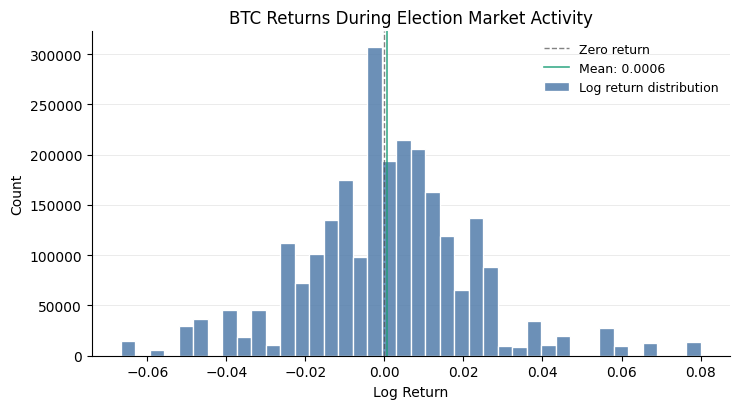

In [49]:
# Source: eda_classification_country.ipynb, cell 19
# Clean, minimal distribution of BTC log returns during election-market activity
returns = election_trades['log_return'].dropna()

fig, ax = plt.subplots(figsize=(7.5, 4.2))

sns.histplot(
    returns,
    bins=40,
    color='#4C78A8',
    edgecolor='white',
    alpha=0.82,
    label='Log return distribution',
    ax=ax
)

# Reference lines
ax.axvline(0, color='#4D4D4D', lw=1, ls='--', alpha=0.7, label='Zero return')
mean_val = returns.mean()
ax.axvline(mean_val, color='#1B9E77', lw=1.2, alpha=0.85, label=f"Mean: {mean_val:.4f}")

# Subtle grid and styling
ax.grid(axis='y', color='#D9D9D9', lw=0.6, alpha=0.6)
ax.set_axisbelow(True)

ax.set_title("BTC Returns During Election Market Activity", fontsize=12)
ax.set_xlabel("Log Return")
ax.set_ylabel("Count")

ax.legend(frameon=False, fontsize=9)
sns.despine()
plt.tight_layout()
plt.show()


This histogram shows the distribution of Bitcoin returns during periods when election-related markets are actively traded.

If election events influence crypto markets, we may observe wider dispersion or heavier tails in returns.

However, if the distribution resembles the overall BTC return distribution, it suggests limited direct impact.


In [50]:
# Source: eda_classification_country.ipynb, cell 21
# Detect country mentioned in question text

country_keywords = {
    'US': 'us|usa|united states|trump|biden|senate|congress',
    'UK': 'uk|britain|london|prime minister',
    'France': 'france|macron',
    'Germany': 'germany',
    'India': 'india|modi',
    'China': 'china|xi'
}

def detect_country(text):

    text = str(text).lower()

    for country, pattern in country_keywords.items():
        if pd.Series(text).str.contains(pattern, regex=True).iloc[0]:
            return country

    return "Other"

election_markets['country'] = election_markets['question'].apply(detect_country)

election_markets['country'].value_counts()


country
US        7348
Other     3485
UK          30
China       28
India       10
France       8
Name: count, dtype: int64

In [51]:
# Source: eda_classification_country.ipynb, cell 22
# merge trades with election markets

election_trades_country = trades_df.merge(
    election_markets[['market_id','country']],
    on='market_id',
    how='inner'
)

election_trades_country['timestamp'] = pd.to_datetime(election_trades_country['timestamp'])

election_trades_country = election_trades_country.merge(
    btc_returns,
    on='date',
    how='left'
)


There is no market for India in trades_df!


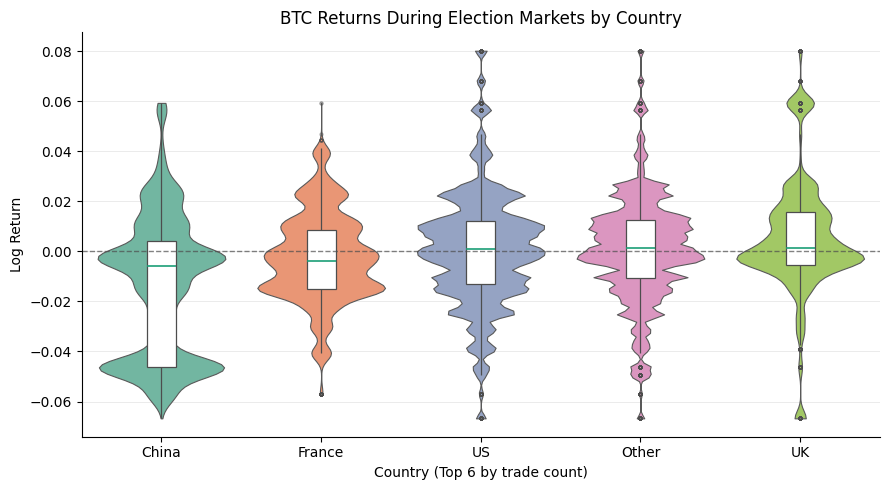

In [52]:
# Source: eda_classification_country.ipynb, cell 24
# Slightly more polished: violin + light box for top countries
df = election_trades_country[['country', 'log_return']].dropna()

top_n = 6
top_countries = df['country'].value_counts().head(top_n).index
plot_df = df[df['country'].isin(top_countries)].copy()

# Order by median return for clearer comparison
order = (
    plot_df.groupby('country')['log_return']
    .median()
    .sort_values()
    .index
)

fig, ax = plt.subplots(figsize=(9, 5))

sns.violinplot(
    data=plot_df,
    x='country',
    y='log_return',
    order=order,
    palette='Set2',
    inner=None,
    cut=0,
    linewidth=0.8,
    ax=ax
)

sns.boxplot(
    data=plot_df,
    x='country',
    y='log_return',
    order=order,
    width=0.18,
    showcaps=False,
    boxprops={'facecolor': 'white', 'edgecolor': '#4D4D4D', 'linewidth': 0.9},
    whiskerprops={'color': '#4D4D4D', 'linewidth': 0.9},
    medianprops={'color': '#1B9E77', 'linewidth': 1.2},
    flierprops={'marker': 'o', 'markersize': 2, 'alpha': 0.25, 'markeredgecolor': '#4D4D4D'},
    ax=ax
)

ax.axhline(0, color='#4D4D4D', lw=1, ls='--', alpha=0.7)

ax.set_title("BTC Returns During Election Markets by Country", fontsize=12)
ax.set_xlabel(f"Country (Top {top_n} by trade count)")
ax.set_ylabel("Log Return")

ax.grid(axis='y', color='#D9D9D9', lw=0.6, alpha=0.6)
ax.set_axisbelow(True)

sns.despine()
plt.tight_layout()
plt.show()


This violin plot compares the distribution of Bitcoin returns across election markets in different countries.

Several key patterns emerge:

- The US shows the widest distribution, indicating the highest volatility. This suggests that US elections have the strongest association with BTC price movements.

- The UK exhibits a slightly positive median return, implying that election-related activity may coincide with positive BTC performance.

- China displays a more negative skew, suggesting that election-related events may be associated with downward pressure on BTC prices.

- France and other regions show more neutral distributions, indicating weaker or less consistent effects.

Overall, the results suggest that the impact of election markets on Bitcoin is not uniform across countries, with US events playing a dominant role.


In [53]:
# Source: eda_classification_country.ipynb, cell 26
event_windows = []
    
for market_id, group in election_trades_country.groupby('market_id'):

    group = group.sort_values('timestamp')

    if len(group) < 7:
        continue

    window = group.tail(7)

    event_windows.append(window)

event_window_df = pd.concat(event_windows)


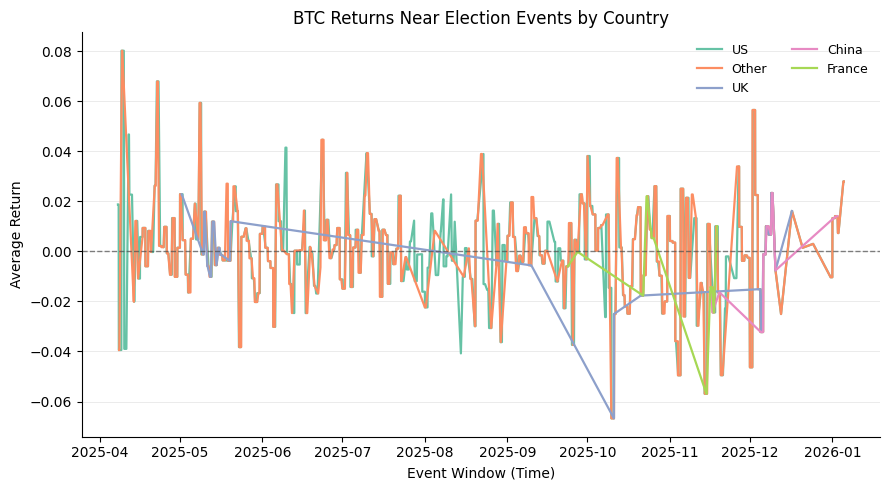

In [54]:
# Source: eda_classification_country.ipynb, cell 27
# Polished multi-line: average BTC returns near election events by country
top_n = 6

top_countries = (
    event_window_df['country']
    .value_counts()
    .head(top_n)
    .index
)

plot_df = event_window_df[event_window_df['country'].isin(top_countries)].copy()

fig, ax = plt.subplots(figsize=(9, 5))

palette = sns.color_palette("Set2", n_colors=top_n)

for color, country in zip(palette, top_countries):
    subset = plot_df[plot_df['country'] == country]
    avg_returns = subset.groupby('timestamp')['log_return'].mean()
    ax.plot(
        avg_returns.index,
        avg_returns.values,
        color=color,
        lw=1.6,
        label=country
    )

# Reference line and styling
ax.axhline(0, color='#4D4D4D', lw=1, ls='--', alpha=0.7)

ax.set_title("BTC Returns Near Election Events by Country", fontsize=12)
ax.set_xlabel("Event Window (Time)")
ax.set_ylabel("Average Return")

ax.grid(axis='y', color='#D9D9D9', lw=0.6, alpha=0.6)
ax.set_axisbelow(True)

ax.legend(frameon=False, fontsize=9, ncol=2)
sns.despine()
plt.tight_layout()
plt.show()


In [55]:
# Source: eda_classification_country.ipynb, cell 28
event_windows = []

for market_id, group in election_trades_country.groupby('market_id'):

    group = group.sort_values('timestamp')

    # Only keep market with enough trade history
    if len(group) < 7:
        continue

    window = group.tail(7).copy()

    # Create event time
    window['event_time'] = range(-6, 1)

    event_windows.append(window)

event_window_df = pd.concat(event_windows)

avg_returns = (
    event_window_df
    .groupby(['country','event_time'])['log_return']
    .mean()
    .reset_index()
)


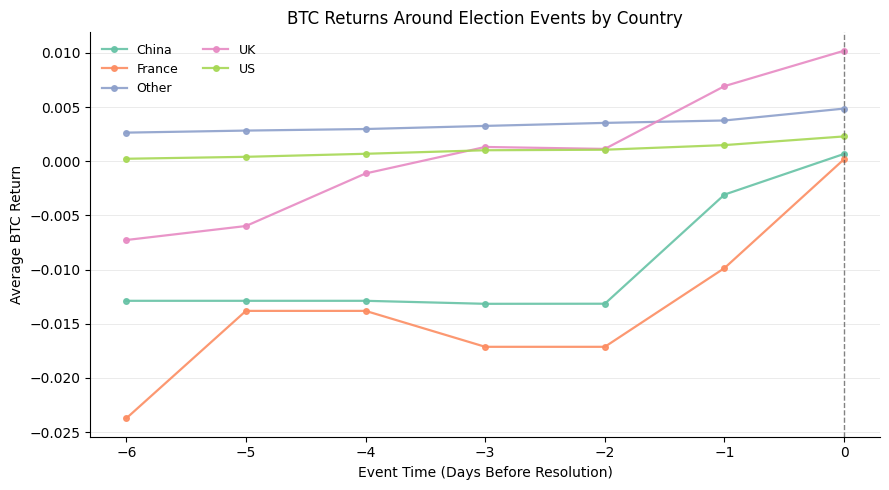

In [56]:
# Source: eda_classification_country.ipynb, cell 29
# Polished line chart: BTC returns around election events by country
top_n = 6
top_countries = (
    avg_returns['country']
    .value_counts()
    .head(top_n)
    .index
)

plot_df = avg_returns[avg_returns['country'].isin(top_countries)].copy()

fig, ax = plt.subplots(figsize=(9, 5))

palette = sns.color_palette("Set2", n_colors=top_n)

for color, country in zip(palette, top_countries):
    subset = plot_df[plot_df['country'] == country].sort_values('event_time')
    ax.plot(
        subset['event_time'],
        subset['log_return'],
        color=color,
        lw=1.6,
        marker='o',
        ms=4,
        alpha=0.9,
        label=country
    )

# Reference line at event day
ax.axvline(0, linestyle='--', color='#4D4D4D', lw=1, alpha=0.7)

# Subtle grid and styling
ax.grid(axis='y', color='#D9D9D9', lw=0.6, alpha=0.6)
ax.set_axisbelow(True)

ax.set_xlabel("Event Time (Days Before Resolution)")
ax.set_ylabel("Average BTC Return")
ax.set_title("BTC Returns Around Election Events by Country", fontsize=12)

ax.legend(frameon=False, fontsize=9, ncol=2)
sns.despine()
plt.tight_layout()
plt.show()


This figure presents an event study of Bitcoin returns aligned around election market resolution.

Several key patterns emerge:

- Across most countries, BTC returns increase as the event approaches, particularly in the final two days before resolution. This suggests that markets may anticipate election outcomes.

- The UK shows the strongest upward trend, indicating a consistent increase in BTC returns leading up to the event.

- The US exhibits a more stable and gradual increase, suggesting a steady incorporation of information.

- China shows a delayed reaction, with returns remaining negative until a sharp increase just before the event.

- France displays a reversal pattern, with early negative returns followed by a late recovery.

Overall, these results suggest that election-related information may be incorporated into BTC prices in a gradual and country-dependent manner. However, the magnitude of these effects is relatively small, and the patterns may be influenced by underlying BTC market trends rather than election-specific factors.


In [57]:
# Source: eda_classification_country.ipynb, cell 32
election_odds = odds_history_df.merge(
    election_markets[['market_id','country']],
    on='market_id',
    how='inner'
)

election_odds = election_odds.merge(
    btc_returns,
    on='date',
    how='left'
)


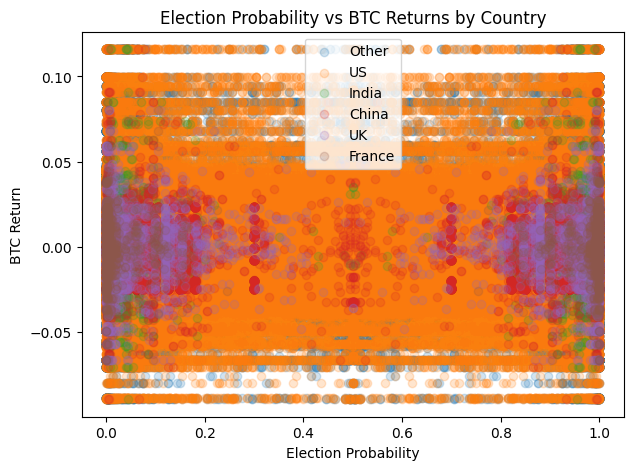

In [58]:
# Source: eda_classification_country.ipynb, cell 33
plt.figure(figsize=(7,5))

for country in election_odds['country'].unique():

    subset = election_odds[
        election_odds['country'] == country
    ]

    plt.scatter(
        subset['price'],
        subset['log_return'],
        alpha=0.2,
        label=country
    )
    

plt.legend()

plt.xlabel("Election Probability")

plt.ylabel("BTC Return")

plt.title("Election Probability vs BTC Returns by Country")

plt.show()


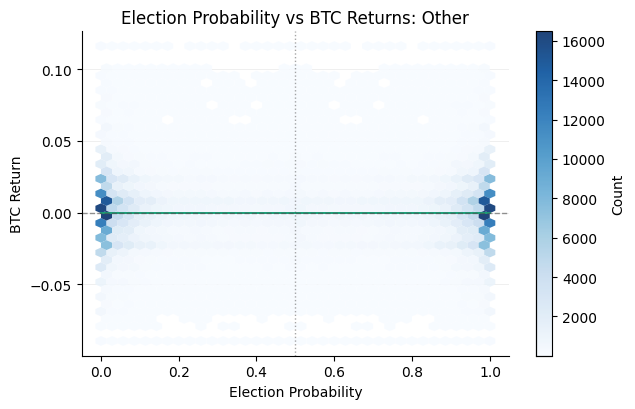

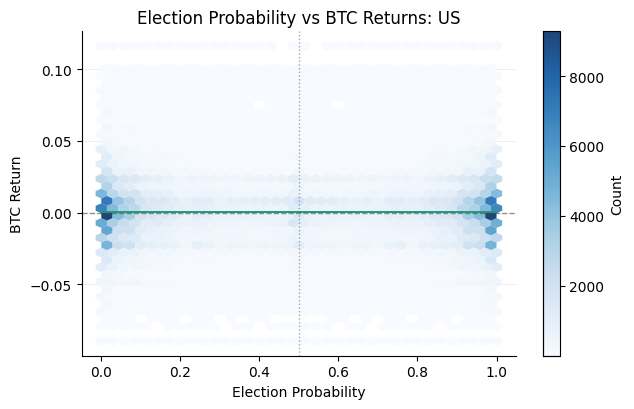

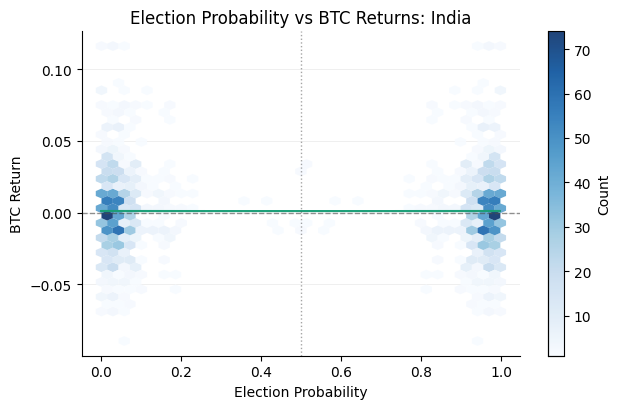

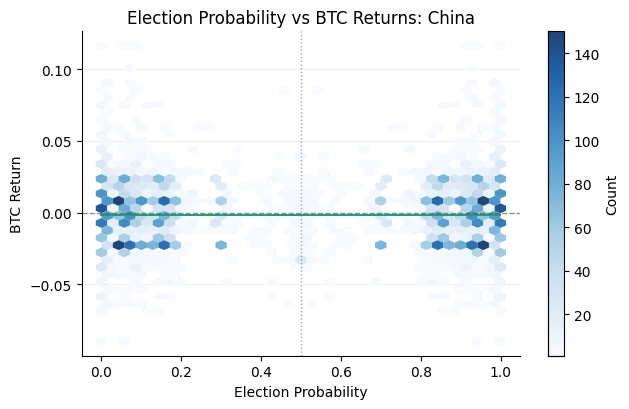

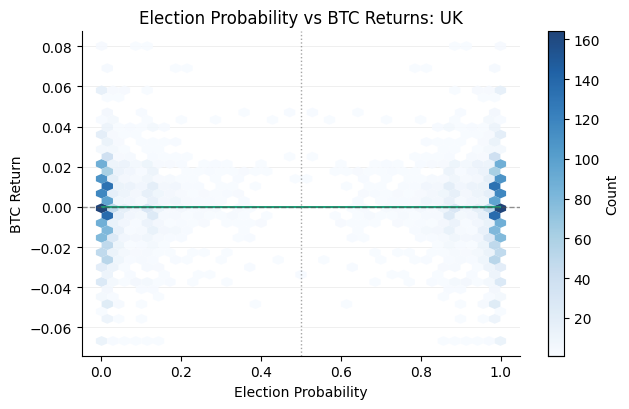

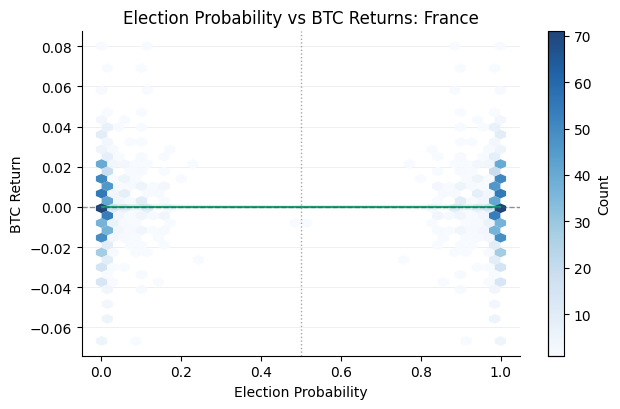

In [59]:
# Source: eda_classification_country.ipynb, cell 34
# Density-style: hexbin + regression line
countries = election_odds['country'].dropna().unique()

for country in countries:
    subset = election_odds[election_odds['country'] == country].dropna(subset=['price', 'log_return'])
    if subset.empty:
        continue

    fig, ax = plt.subplots(figsize=(6.5, 4.2))

    hb = ax.hexbin(
        subset['price'],
        subset['log_return'],
        gridsize=35,
        cmap='Blues',
        mincnt=1,
        linewidths=0,
        alpha=0.9
    )

    # Optional regression line (thin)
    sns.regplot(
        data=subset,
        x='price',
        y='log_return',
        scatter=False,
        line_kws={'color': '#1B9E77', 'lw': 1.4},
        ax=ax
    )

    ax.axhline(0, color='#4D4D4D', lw=1, ls='--', alpha=0.6)
    ax.axvline(0.5, color='#4D4D4D', lw=1, ls=':', alpha=0.5)

    ax.set_title(f"Election Probability vs BTC Returns: {country}", fontsize=12)
    ax.set_xlabel("Election Probability")
    ax.set_ylabel("BTC Return")

    cb = fig.colorbar(hb, ax=ax)
    cb.set_label("Count")

    ax.grid(axis='y', color='#D9D9D9', lw=0.6, alpha=0.5)
    ax.set_axisbelow(True)

    sns.despine()
    plt.tight_layout()
    plt.show()


This hexbin density plot examines the relationship between prediction market probabilities and Bitcoin returns.

Election probability: The price of YES token of each market for each day.

Several key observations emerge:

- The distribution is heavily concentrated near probabilities of 0 and 1, indicating that prediction markets are often highly confident about outcomes.

- The regression line is nearly flat, suggesting no strong linear relationship between election probabilities and BTC returns.

- BTC returns exhibit high dispersion across all probability levels, indicating a noisy relationship.

Importantly, similar patterns are observed across all countries, suggesting that this result is not country-specific.

Overall, these findings indicate that prediction market probabilities alone have limited explanatory power for Bitcoin price movements.


### Part 3


In [60]:
# Source: eda_classification_country.ipynb, cell 37
geo_markets = markets_for_filter[
    markets_for_filter['category'].isin([
        'Global Politics'
    ])
].copy()

print("Geopolitical markets:", len(geo_markets))


Geopolitical markets: 694


In [62]:
# Source: eda_classification_country.ipynb, cell 39
geo_trades = trades_df.merge(
    geo_markets[['market_id','question','category']],
    on='market_id',
    how='inner'
)

# Convert timestamp
geo_trades["timestamp"] = pd.to_datetime(geo_trades["timestamp"])

# Extract date
geo_trades["date"] = geo_trades["timestamp"].dt.date

# BTC date
btc_df["date"] = btc_df["time"].dt.date

# Merge
geo_trades = geo_trades.merge(
    btc_df[["date","log_return"]],
    on="date",
    how="left"
)


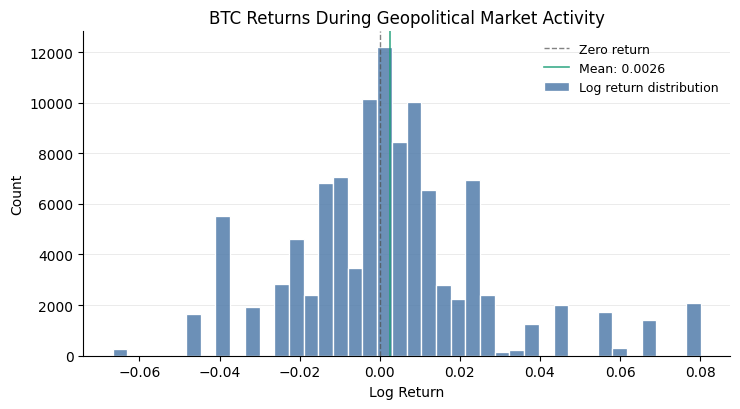

In [63]:
# Source: eda_classification_country.ipynb, cell 40
# Clean, minimal distribution of BTC log returns during geopolitical-market activity
geo_returns = geo_trades['log_return'].dropna()

fig, ax = plt.subplots(figsize=(7.5, 4.2))

sns.histplot(
    geo_returns,
    bins=40,
    color='#4C78A8',
    edgecolor='white',
    alpha=0.82,
    label='Log return distribution',
    ax=ax
)

# Reference lines
ax.axvline(0, color='#4D4D4D', lw=1, ls='--', alpha=0.7, label='Zero return')
mean_val = geo_returns.mean()
ax.axvline(mean_val, color='#1B9E77', lw=1.2, alpha=0.85, label=f"Mean: {mean_val:.4f}")

# Subtle grid and styling
ax.grid(axis='y', color='#D9D9D9', lw=0.6, alpha=0.6)
ax.set_axisbelow(True)

ax.set_title("BTC Returns During Geopolitical Market Activity", fontsize=12)
ax.set_xlabel("Log Return")
ax.set_ylabel("Count")

ax.legend(frameon=False, fontsize=9)
sns.despine()
plt.tight_layout()
plt.show()


This histogram shows the distribution of Bitcoin returns during periods of geopolitical market activity.

The mean return is slightly positive (approximately 0.0014), suggesting a weak upward bias. However, the distribution is centered close to zero, indicating no strong directional effect.

The distribution exhibits relatively fat tails on both sides, implying that extreme positive and negative returns are more likely during these periods.

Overall, the results suggest that geopolitical events are more strongly associated with increased volatility rather than consistent price direction in Bitcoin.

This indicates that geopolitical events may act as sources of uncertainty, leading to wider return dispersion rather than predictable price movements.


In [64]:
# Source: eda_classification_country.ipynb, cell 42
event_windows = []

for market_id, group in geo_trades.groupby('market_id'):

    group = group.sort_values('timestamp')

    if len(group) < 5:
        continue

    window = group.tail(5)

    event_windows.append(window)

event_window_df = pd.concat(event_windows)


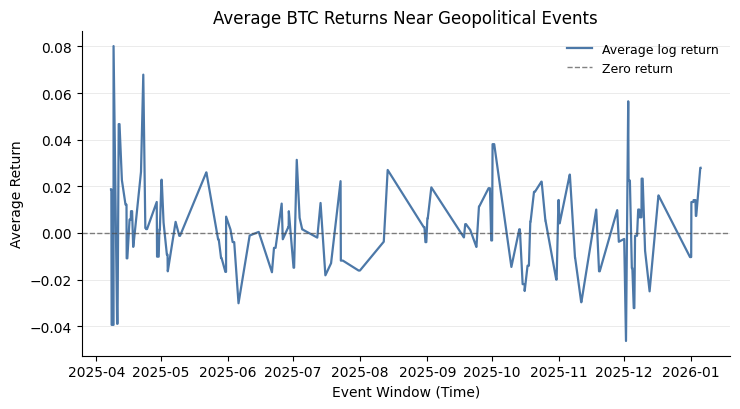

In [65]:
# Source: eda_classification_country.ipynb, cell 43
# Clean, minimal time series of average returns around geopolitical events
avg_returns = event_window_df.groupby('timestamp')['log_return'].mean()

fig, ax = plt.subplots(figsize=(7.5, 4.2))

ax.plot(
    avg_returns.index,
    avg_returns.values,
    color='#4C78A8',
    lw=1.6,
    label='Average log return'
)

# Reference lines
ax.axhline(0, color='#4D4D4D', lw=1, ls='--', alpha=0.7, label='Zero return')

# Subtle grid and styling
ax.grid(axis='y', color='#D9D9D9', lw=0.6, alpha=0.6)
ax.set_axisbelow(True)

ax.set_title("Average BTC Returns Near Geopolitical Events", fontsize=12)
ax.set_xlabel("Event Window (Time)")
ax.set_ylabel("Average Return")

ax.legend(frameon=False, fontsize=9)
sns.despine()
plt.tight_layout()
plt.show()


In [66]:
# Source: eda_classification_country.ipynb, cell 44
# Merge odds history with geopolitical markets

geo_odds = odds_history_df.merge(
    geo_markets[['market_id','question','category']],
    on='market_id',
    how='inner'
)

print("geo odds rows:", len(geo_odds))
geo_odds.head()

geo_odds["date"] = geo_odds["timestamp"].dt.date

geo_odds = geo_odds.merge(
    btc_df[["date","log_return"]],
    on="date",
    how="left"
)

geo_odds["uncertainty"] = abs(geo_odds["price"] - 0.5)


geo odds rows: 40262


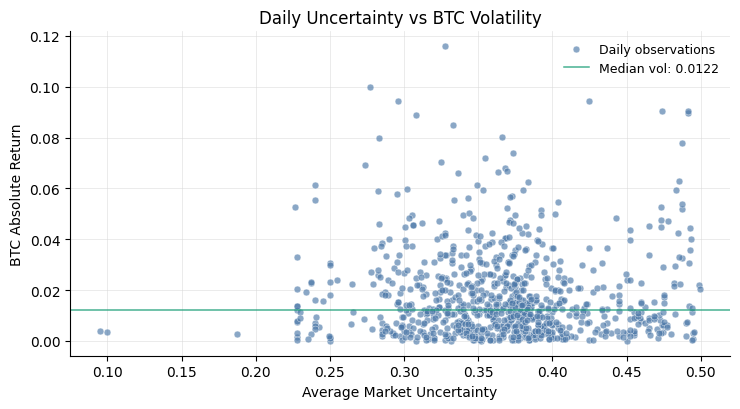

In [68]:
# Source: eda_classification_country.ipynb, cell 45
# Clean, minimal scatter: daily uncertainty vs BTC volatility
daily_geo = geo_odds.groupby("date").agg({
    "uncertainty": "mean",
    "log_return": "mean"
}).reset_index()

fig, ax = plt.subplots(figsize=(7.5, 4.2))

ax.scatter(
    daily_geo["uncertainty"],
    daily_geo["log_return"].abs(),
    s=24,
    color="#4C78A8",
    alpha=0.65,
    edgecolor="white",
    linewidth=0.4,
    label="Daily observations"
)

# Optional reference line at median volatility
med_vol = daily_geo["log_return"].abs().median()
ax.axhline(med_vol, color="#1B9E77", lw=1.1, alpha=0.8, label=f"Median vol: {med_vol:.4f}")

# Subtle grid and styling
ax.grid(color="#D9D9D9", lw=0.6, alpha=0.6)
ax.set_axisbelow(True)

ax.set_title("Daily Uncertainty vs BTC Volatility", fontsize=12)
ax.set_xlabel("Average Market Uncertainty")
ax.set_ylabel("BTC Absolute Return")

ax.legend(frameon=False, fontsize=9)
sns.despine()
plt.tight_layout()
plt.show()


We define uncertainty using the standard Bernoulli variance formula:

uncertainty = p  (1  p)

where p is the market-implied probability.

This measure captures how uncertain the market is about the outcome:

- Uncertainty is highest when p  0.5  
- Uncertainty is lowest when p  0 or 1  

This provides a natural way to quantify disagreement or lack of consensus among market participants.

This scatter plot examines whether higher prediction market uncertainty is associated with larger Bitcoin price movements.

Uncertainty is highest when probabilities are close to 0.5.

If political uncertainty drives market volatility, we expect a positive relationship between uncertainty and absolute BTC returns.


In [69]:
# Source: eda_classification_country.ipynb, cell 47
# =========================================================
# Transformer-based Bitcoin Price Forecast (Auto-Adaptive)
# =========================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from datetime import timedelta

# Torch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# -----------------------------
# 1) Fancy plot styling
# -----------------------------
def apply_fancy_style():
    sns.set_theme(style="whitegrid")
    plt.rcParams.update({
        "figure.facecolor": "#F5F7FA",
        "axes.facecolor": "#FFFFFF",
        "axes.edgecolor": "#222222",
        "grid.color": "#E2E8F0",
        "grid.linestyle": "-",
        "grid.linewidth": 0.8,
        "axes.titleweight": "bold",
        "axes.titlecolor": "#1F2937",
        "axes.labelcolor": "#374151",
        "xtick.color": "#374151",
        "ytick.color": "#374151",
        "font.size": 11
    })

apply_fancy_style()

# -----------------------------
# 2) Defensive conversions
# -----------------------------
if "btc_df" not in globals():
    raise ValueError("btc_df not found. Please run the EDA cells first.")

# Ensure pandas DataFrame
if not isinstance(btc_df, pd.DataFrame):
    btc_df = btc_df.to_pandas()

btc_df = btc_df.copy()
btc_df["time"] = pd.to_datetime(btc_df["time"])
btc_df["date"] = btc_df["time"].dt.date

# -----------------------------
# 3) Polymarket feature builder
# -----------------------------
def detect_country(text):
    country_keywords = {
        'US': 'us|usa|united states|trump|biden|senate|congress',
        'UK': 'uk|britain|london|prime minister',
        'France': 'france|macron',
        'Germany': 'germany',
        'India': 'india|modi',
        'China': 'china|xi'
    }
    text = str(text).lower()
    for country, pattern in country_keywords.items():
        if pd.Series(text).str.contains(pattern, regex=True).iloc[0]:
            return country
    return "Other"

def build_polymarket_features(markets_df, odds_history_df, trades_df):
    # Copy and normalize timestamps
    m = markets_df.copy()
    o = odds_history_df.copy()
    t = trades_df.copy()

    for df, col in [(o, "timestamp"), (t, "timestamp")]:
        if pd.api.types.is_datetime64_any_dtype(df[col]):
            if df[col].dt.year.eq(1970).all():
                df[col] = pd.to_datetime(df[col].astype("int64"), unit="ms", errors="coerce")
        else:
            df[col] = pd.to_datetime(df[col], unit="ms", errors="coerce")

    o["date"] = o["timestamp"].dt.date
    t["date"] = t["timestamp"].dt.date

    # Add country for politics
    m["country"] = m["question"].apply(detect_country)

    # -------------------
    # Odds-derived features
    # -------------------
    odds = o.merge(m[["market_id", "category", "country"]], on="market_id", how="left")
    odds["uncertainty"] = odds["price"] * (1 - odds["price"])

    daily_base = odds.groupby("date").agg(
        pm_price_mean=("price", "mean"),
        pm_price_std=("price", "std"),
        pm_uncertainty_mean=("uncertainty", "mean"),
        pm_obs=("price", "count")
    ).reset_index()

    # Category-specific aggregates (only if present)
    cat_features = []
    for cat in ["Politics", "Ukraine & Russia", "Global Politics", "Crypto"]:
        if cat in odds["category"].dropna().unique():
            tmp = odds[odds["category"] == cat].groupby("date").agg(
                price_mean=("price", "mean"),
                uncertainty_mean=("uncertainty", "mean"),
                obs=("price", "count")
            )
            tmp.columns = [f"pm_{cat.lower().replace(' ', '_').replace('&','and')}_{c}" for c in tmp.columns]
            tmp = tmp.reset_index()
            cat_features.append(tmp)

    # Country-specific aggregates for Politics (top 4)
    pol = odds[odds["category"] == "Politics"].copy()
    top_countries = pol["country"].value_counts().head(4).index.tolist()
    country_features = []
    for c in top_countries:
        tmp = pol[pol["country"] == c].groupby("date").agg(
            price_mean=("price", "mean"),
            uncertainty_mean=("uncertainty", "mean"),
            obs=("price", "count")
        )
        tmp.columns = [f"pm_country_{c.lower()}_{col}" for col in tmp.columns]
        tmp = tmp.reset_index()
        country_features.append(tmp)

    # -------------------
    # Trades-derived features
    # -------------------
    trades = t.merge(m[["market_id", "category", "country"]], on="market_id", how="left")
    trades["is_buy"] = trades["side"].astype(str).str.lower().str.contains("buy").astype(int)

    daily_trades = trades.groupby("date").agg(
        pm_trade_count=("trade_id", "count"),
        pm_trade_size_sum=("size", "sum"),
        pm_trade_size_mean=("size", "mean"),
        pm_buy_ratio=("is_buy", "mean")
    ).reset_index()

    # Merge all Polymarket daily features
    feat = daily_base.merge(daily_trades, on="date", how="outer")
    for df in cat_features + country_features:
        feat = feat.merge(df, on="date", how="outer")

    return feat

# -----------------------------
# 4) Build dataset
# -----------------------------
if not all(x in globals() for x in ["markets_df", "odds_history_df", "trades_df"]):
    raise ValueError("Missing Polymarket dataframes. Please run the EDA cells first.")

pm_feat = build_polymarket_features(markets_df, odds_history_df, trades_df)

# CoinMetrics features
coin = btc_df.copy()
coin = coin.sort_values("date")

# Keep only valid positive BTC prices
coin["PriceUSD"] = pd.to_numeric(coin["PriceUSD"], errors="coerce")
coin = coin.replace([np.inf, -np.inf], np.nan)
coin = coin.dropna(subset=["PriceUSD"])
coin = coin[coin["PriceUSD"] > 0].copy()

coin_cols = coin.select_dtypes(include=[np.number]).columns.tolist()

target_col = "PriceUSD"
if target_col not in coin_cols:
    raise ValueError("PriceUSD not found in btc_df numeric columns.")

# Merge Polymarket features
data = coin.merge(pm_feat, on="date", how="left")
data = data.sort_values("date")

# Basic cleaning
data = data.replace([np.inf, -np.inf], np.nan)
data = data.ffill().fillna(0)

# Build target: next-day BTC log return, not next-day price level
data["log_price"] = np.log(data[target_col].replace(0, np.nan))
data["target"] = data["log_price"].shift(-1) - data["log_price"]

data = data.replace([np.inf, -np.inf], np.nan)
data = data.dropna(subset=["target"]).reset_index(drop=True)

print("Target summary: next-day log return")
print(data["target"].describe())

# -----------------------------
# 5) Feature selection
# -----------------------------
# Candidate CoinMetrics features: numeric columns except raw price and target helpers
exclude_cols = {
    target_col,
    "target",
    "log_price",
}

candidate_coin_cols = [
    c for c in coin_cols
    if c not in exclude_cols and c in data.columns
]

# Clean correlation input
corr_data = data[candidate_coin_cols + ["target"]].replace(
    [np.inf, -np.inf],
    np.nan
)

corr_data = corr_data.dropna(subset=["target"])

# Drop columns with no variation, because correlation is undefined
valid_candidate_cols = [
    c for c in candidate_coin_cols
    if corr_data[c].notna().sum() > 2 and corr_data[c].std(skipna=True) > 0
]

corrs = (
    corr_data[valid_candidate_cols]
    .corrwith(corr_data["target"])
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .abs()
    .sort_values(ascending=False)
)

top_k = 10
selected_coin = corrs.head(top_k).index.tolist()

# Always include Polymarket features
pm_cols = [c for c in data.columns if c.startswith("pm_")]

# Final feature set
feature_cols = selected_coin + pm_cols
feature_cols = list(dict.fromkeys(feature_cols))

print(f"Selected CoinMetrics features (top {top_k}): {selected_coin}")
print(f"Polymarket features: {len(pm_cols)} columns")
print(f"Total features: {len(feature_cols)}")

if len(feature_cols) == 0:
    raise ValueError("No valid feature columns found.")

# -----------------------------
# 6) Sequence dataset
# -----------------------------
LOOKBACK = 30

class SeqDataset(Dataset):
    def __init__(self, X, y, lookback):
        self.X = X
        self.y = y
        self.lookback = lookback

    def __len__(self):
        return len(self.X) - self.lookback

    def __getitem__(self, idx):
        x_seq = self.X[idx:idx + self.lookback]
        y_t = self.y[idx + self.lookback - 1]

        return (
            torch.tensor(x_seq, dtype=torch.float32),
            torch.tensor(y_t, dtype=torch.float32)
        )

# Split by time
n = len(data)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = data.iloc[:train_end].copy()
val_df = data.iloc[train_end:val_end].copy()
test_df = data.iloc[val_end:].copy()

# Scale features using train only
x_scaler = StandardScaler()

X_train = x_scaler.fit_transform(train_df[feature_cols])
X_val = x_scaler.transform(val_df[feature_cols])
X_test = x_scaler.transform(test_df[feature_cols])

# Scale target using train only
y_scaler = StandardScaler()

y_train = y_scaler.fit_transform(train_df[["target"]]).ravel()
y_val = y_scaler.transform(val_df[["target"]]).ravel()
y_test = y_scaler.transform(test_df[["target"]]).ravel()

train_ds = SeqDataset(X_train, y_train, LOOKBACK)
val_ds = SeqDataset(X_val, y_val, LOOKBACK)
test_ds = SeqDataset(X_test, y_test, LOOKBACK)

train_loader = DataLoader(
    train_ds,
    batch_size=64,
    shuffle=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=64,
    shuffle=False
)

test_loader = DataLoader(
    test_ds,
    batch_size=64,
    shuffle=False
)

print(f"Train sequences: {len(train_ds):,}")
print(f"Validation sequences: {len(val_ds):,}")
print(f"Test sequences: {len(test_ds):,}")
print(f"Target mean in train: {train_df['target'].mean():.6f}")
print(f"Target std in train: {train_df['target'].std():.6f}")

# -----------------------------
# 7) Transformer model
# -----------------------------
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()

        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div = torch.exp(
            torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)

        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]


class TimeSeriesTransformer(nn.Module):
    def __init__(self, n_features, d_model=32, nhead=4, num_layers=2, dropout=0.15):
        super().__init__()

        self.input_proj = nn.Linear(n_features, d_model)
        self.pos_enc = PositionalEncoding(d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dropout=dropout,
            batch_first=True
        )

        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, 16),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        x = self.input_proj(x)
        x = self.pos_enc(x)
        x = self.encoder(x)
        out = self.head(x[:, -1, :])
        return out.squeeze(-1)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = TimeSeriesTransformer(
    n_features=len(feature_cols),
    d_model=32,
    nhead=4,
    num_layers=2,
    dropout=0.15
).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=5e-4,
    weight_decay=1e-4
)


Target summary: next-day log return
count    5658.000000
mean        0.002460
std         0.047273
min        -0.664948
25%        -0.012631
50%         0.001473
75%         0.018171
max         0.436655
Name: target, dtype: float64
Selected CoinMetrics features (top 10): ['ROI30d', 'BlkCnt', 'ROI1yr', 'IssTotNtv', 'SplyExpFut10yr', 'SplyCur', 'SplyExNtv', 'IssTotUSD', 'AdrBalCnt', 'TxTfrCnt']
Polymarket features: 8 columns
Total features: 18
Train sequences: 3,930
Validation sequences: 819
Test sequences: 819
Target mean in train: 0.003277
Target std in train: 0.053330


Next-day log return is the logarithm of next-day return rate:

next-day log return = log(P_{t+1} / P_t),

where P_t is BTC price at day t. 

If log return > 0, we predict the price will be higher than today;

if log return < 0, we predict the price will be lower than today.


In [70]:
# Source: eda_classification_country.ipynb, cell 49
# -----------------------------
# 8) Training loop with early stopping
# -----------------------------
best_val = float("inf")
best_state = None
patience = 10
pat_counter = 0
EPOCHS = 80

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_losses = []

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()

        pred = model(xb)
        loss = criterion(pred, yb)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        train_losses.append(loss.item())

    model.eval()
    val_losses = []

    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            pred = model(xb)
            loss = criterion(pred, yb)

            val_losses.append(loss.item())

    train_loss = np.mean(train_losses)
    val_loss = np.mean(val_losses)

    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss (scaled): {train_loss:.6f} | "
        f"Val Loss (scaled): {val_loss:.6f}"
    )

    if val_loss < best_val:
        best_val = val_loss
        best_state = model.state_dict()
        pat_counter = 0
    else:
        pat_counter += 1

        if pat_counter >= patience:
            print("Early stopping triggered.")
            break

if best_state is not None:
    model.load_state_dict(best_state)

# -----------------------------
# 9) Evaluation
# -----------------------------
model.eval()

preds_scaled = []
actuals_scaled = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)

        pred = model(xb).cpu().numpy()

        preds_scaled.append(pred)
        actuals_scaled.append(yb.numpy())

preds_scaled = np.concatenate(preds_scaled)
actuals_scaled = np.concatenate(actuals_scaled)

# Convert predictions and actuals back to original log-return scale
preds = y_scaler.inverse_transform(
    preds_scaled.reshape(-1, 1)
).ravel()

actuals = y_scaler.inverse_transform(
    actuals_scaled.reshape(-1, 1)
).ravel()

mae = mean_absolute_error(actuals, preds)
rmse = np.sqrt(mean_squared_error(actuals, preds))
r2 = r2_score(actuals, preds)

directional_acc = (
    np.sign(actuals) == np.sign(preds)
).mean() * 100

# Naive baseline: always predict zero return
baseline_preds = np.zeros_like(actuals)

baseline_mae = mean_absolute_error(actuals, baseline_preds)
baseline_rmse = np.sqrt(mean_squared_error(actuals, baseline_preds))

# Directional baseline: always predict the majority direction in the test set
majority_direction = 1 if (actuals > 0).mean() >= 0.5 else -1
baseline_direction_preds = np.full_like(actuals, majority_direction)

baseline_directional_acc = (
    np.sign(actuals) == np.sign(baseline_direction_preds)
).mean() * 100

print("\nModel Performance on Test Set")
print("Target: next-day BTC log return")
print(f"MAE  : {mae:.6f}")
print(f"RMSE : {rmse:.6f}")
print(f"R^2  : {r2:.4f}")
print(f"Directional Accuracy: {directional_acc:.2f}%")

print("\nNaive Zero-Return Baseline")
print(f"MAE  : {baseline_mae:.6f}")
print(f"RMSE : {baseline_rmse:.6f}")

print("\nMajority-Direction Baseline")
print(f"Direction predicted: {'Up' if majority_direction == 1 else 'Down'}")
print(f"Directional Accuracy: {baseline_directional_acc:.2f}%")


Epoch 01 | Train Loss (scaled): 0.991450 | Val Loss (scaled): 0.343203
Epoch 02 | Train Loss (scaled): 0.982088 | Val Loss (scaled): 0.341294
Epoch 03 | Train Loss (scaled): 0.983798 | Val Loss (scaled): 0.341830
Epoch 04 | Train Loss (scaled): 0.981811 | Val Loss (scaled): 0.341329
Epoch 05 | Train Loss (scaled): 1.035612 | Val Loss (scaled): 0.340502
Epoch 06 | Train Loss (scaled): 0.980365 | Val Loss (scaled): 0.342907
Epoch 07 | Train Loss (scaled): 0.976368 | Val Loss (scaled): 0.340317
Epoch 08 | Train Loss (scaled): 0.987167 | Val Loss (scaled): 0.340817
Epoch 09 | Train Loss (scaled): 0.979201 | Val Loss (scaled): 0.340928
Epoch 10 | Train Loss (scaled): 0.975412 | Val Loss (scaled): 0.341082
Epoch 11 | Train Loss (scaled): 0.970778 | Val Loss (scaled): 0.344549
Epoch 12 | Train Loss (scaled): 0.984867 | Val Loss (scaled): 0.343896
Epoch 13 | Train Loss (scaled): 0.971435 | Val Loss (scaled): 0.345415
Epoch 14 | Train Loss (scaled): 0.987026 | Val Loss (scaled): 0.342966
Epoch 

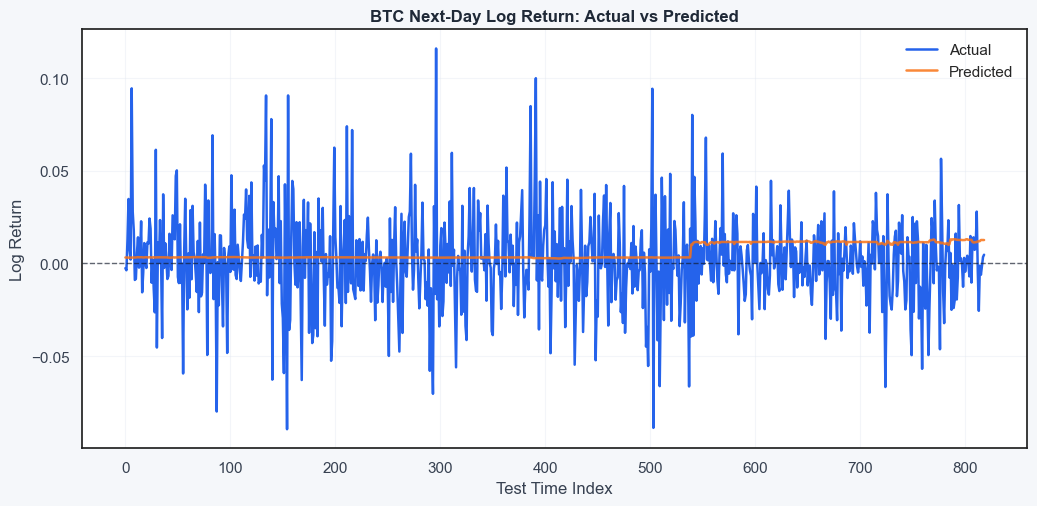

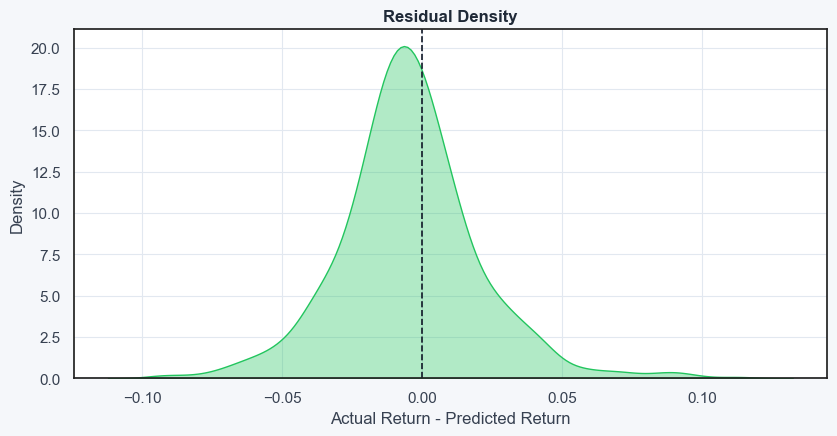

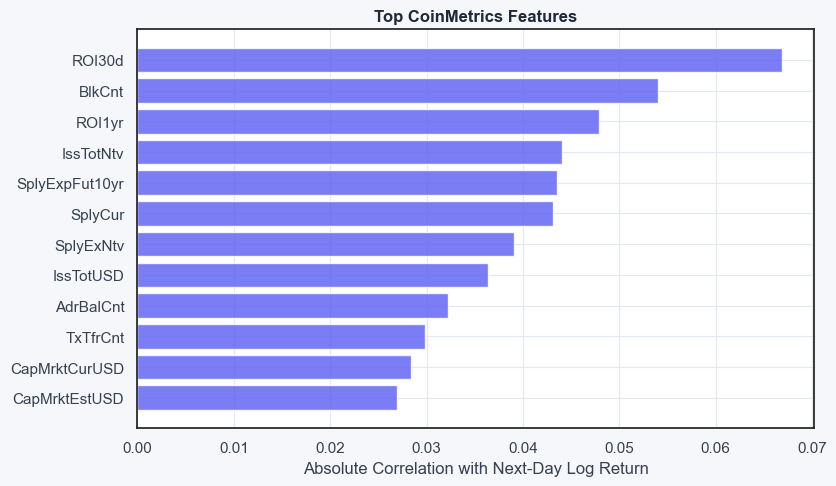


Model Summary (Transformer)
- Target: next-day BTC log return
- Target scaling: StandardScaler fitted on training target only
- Lookback window: 30 days
- Features: 18 (CoinMetrics top 10 + Polymarket aggregates)
- Test MAE: 0.018763
- Test RMSE: 0.025411
- R^2: -0.0703
- Directional Accuracy: 52.63%

Zero-Return Baseline
- MAE: 0.017668
- RMSE: 0.024603

Majority-Direction Baseline
- Direction predicted: Up
- Directional Accuracy: 52.63%

Interpretation:
1. The model trains on standardized next-day log returns, which makes the optimization problem more stable.
2. Predictions are inverse-transformed back to the original log-return scale before evaluation and plotting.
3. The zero-return baseline is useful for MAE/RMSE comparison.
4. The majority-direction baseline is more appropriate for directional accuracy comparison.



In [71]:
# Source: eda_classification_country.ipynb, cell 50
# -----------------------------
# 10) Results plots
# -----------------------------
apply_fancy_style()

# Actual vs predicted next-day log returns
fig, ax = plt.subplots(figsize=(10.5, 5.2))

ax.plot(actuals, label="Actual", lw=1.8, color="#2563EB")
ax.plot(preds, label="Predicted", lw=1.8, color="#F97316", alpha=0.85)

ax.axhline(0, color="#111827", lw=1, linestyle="--", alpha=0.65)

ax.set_title("BTC Next-Day Log Return: Actual vs Predicted")
ax.set_xlabel("Test Time Index")
ax.set_ylabel("Log Return")
ax.legend(frameon=False)
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()


# Residual distribution
residuals = actuals - preds

fig, ax = plt.subplots(figsize=(8.5, 4.5))

sns.kdeplot(residuals, fill=True, color="#22C55E", alpha=0.35, ax=ax)

ax.axvline(0, color="#111827", lw=1.2, linestyle="--")
ax.set_title("Residual Density")
ax.set_xlabel("Actual Return - Predicted Return")
ax.set_ylabel("Density")

plt.tight_layout()
plt.show()


# Feature correlation chart
top_corr = corrs.head(12).sort_values()

fig, ax = plt.subplots(figsize=(8.5, 5.0))

if top_corr.empty:
    ax.text(
        0.5,
        0.5,
        "No valid CoinMetrics correlations",
        ha="center",
        va="center",
        fontsize=12
    )
    ax.axis("off")
else:
    ax.barh(top_corr.index, top_corr.values, color="#6366F1", alpha=0.85)
    ax.set_title("Top CoinMetrics Features")
    ax.set_xlabel("Absolute Correlation with Next-Day Log Return")

plt.tight_layout()
plt.show()

# -----------------------------
# 11) Text summary
# -----------------------------
summary_text = f"""
Model Summary (Transformer)
- Target: next-day BTC log return
- Target scaling: StandardScaler fitted on training target only
- Lookback window: {LOOKBACK} days
- Features: {len(feature_cols)} (CoinMetrics top {top_k} + Polymarket aggregates)
- Test MAE: {mae:.6f}
- Test RMSE: {rmse:.6f}
- R^2: {r2:.4f}
- Directional Accuracy: {directional_acc:.2f}%

Zero-Return Baseline
- MAE: {baseline_mae:.6f}
- RMSE: {baseline_rmse:.6f}

Majority-Direction Baseline
- Direction predicted: {'Up' if majority_direction == 1 else 'Down'}
- Directional Accuracy: {baseline_directional_acc:.2f}%

Interpretation:
1. The model trains on standardized next-day log returns, which makes the optimization problem more stable.
2. Predictions are inverse-transformed back to the original log-return scale before evaluation and plotting.
3. The zero-return baseline is useful for MAE/RMSE comparison.
4. The majority-direction baseline is more appropriate for directional accuracy comparison.
"""

print(summary_text)


## 9. Final Synthesis

Key EDA storyline:

- Polymarket activity is heavily skewed: a small set of high-volume markets dominates attention.
- Politics/global politics and crypto markets are the most relevant categories for BTC-signal exploration.
- Simple correlations are unstable over time; rolling and event-window views are more informative.
- Odds moves can be converted into event-study windows, but signals need enough repeated events before interpretation.
- Classification adds structure by grouping questions into topics and normalizing whether a price increase is bullish, bearish, or neutral for BTC.
- Country and geopolitical slices are useful robustness checks because political shocks are not homogeneous across countries or event types.

Recommended next steps:

1. Run all chapters after setting `LOAD_TRADES=True` only when trade-level analysis is needed.
2. Save stable intermediate tables, especially `daily_odds`, `classification_df`, and event-study outputs.
3. Convert the strongest candidate signals into a final modeling dataset with explicit train/test dates.
4. Keep qualitative story interpretation separate from statistical validation to avoid over-reading noisy signals.
